# 21. Fundamental Equity Research, Scoring and Reporting

In [1]:
from dataclasses import replace
from pathlib import Path as path_cls
import importlib.metadata as metadata
import json
import platform
import random
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.dataset as ds
import pyarrow.parquet as pq
import statsmodels.api as sm
from cycler import cycler
from IPython.display import display

from quantfinlab.backtest.portfolio import (
    run_many_weights_backtests, run_strategy_backtest,
)
from quantfinlab.dataio import load_par_yield_curve, risk_free_returns
from quantfinlab.dataio.panel import prices_to_returns_panel as price_returns
from quantfinlab.ml.evaluation import forecast_buckets, rank_metrics, rolling_rank_ic
from quantfinlab.plotting import portfolio as portfolio_plots
from quantfinlab.portfolio import covariance, expected_returns, optimizers, selection
from quantfinlab.portfolio.cvar import mean_cvar_weight_frame
from quantfinlab.portfolio.factors import excess_returns
from quantfinlab.portfolio.hrp import hrp_weight_frame, nco_mv_weight_frame
from quantfinlab.portfolio.risk_parity import risk_parity_weight_frame
from quantfinlab.portfolio.robust import wasserstein_weight_frame
from quantfinlab.portfolio.walkforward import (
    run_equal_weight_walkforward, run_walkforward_grid,
)
from quantfinlab.reports.risk_report import risk_report

palette = ["#069AF3", "#FE420F", "#00008B", "#008080", "#CC79A7",
           "#9614fa", "#DC143C", "#7BC8F6", "#0072B2", "#04D8B2",
           "#800080", "#FF8072"]
plt.rcParams["axes.prop_cycle"] = cycler(color=palette)
plt.rcParams.update({
    "figure.figsize": (6, 3),
    "figure.dpi": 200,
    "savefig.dpi": 300,
    "axes.grid": True,
    "grid.alpha": 0.20,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 7,
})
colors = palette
blue, gold, navy, teal, pink, coral, violet = colors[:7]
ink = navy
muted = "0.40"
grid = "0.85"

def finish_axes(ax, axis="y"):
    ax.set_axisbelow(True)
    ax.margins(x=0.01)
    return ax

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
pd.set_option("display.max_rows", 40)

project_title = "Project 21 — Fundamental Analysis and Equity Selection"
print(project_title)
print({"python": platform.python_version(), "pandas": pd.__version__,
       "numpy": np.__version__, "pyarrow": pa.__version__,
       "quantfinlab": metadata.version("quantfinlab")})

Project 21 — Fundamental Analysis and Equity Selection
{'python': '3.11.0', 'pandas': '3.0.0', 'numpy': '2.4.2', 'pyarrow': '23.0.0', 'quantfinlab': '0.0.1'}


In [2]:
repo_root = path_cls.cwd()
if not (repo_root / "data" / "sp500_market_data.parquet").exists():
    repo_root = repo_root.parent

market_path = repo_root / "data" / "sp500_market_data.parquet"
fundamentals_path = repo_root / "data" / "sp500_fundamentals.parquet"
treasury_path = repo_root / "data" / "us_treasury_yields.csv"
treasury_curve = load_par_yield_curve(treasury_path, source="us_treasury")
monthly_filing_cache = (
    repo_root / "data" / "datasets" / "project21"
    / "monthly_filing_financials_v2.parquet"
)
monthly_filing_cache.parent.mkdir(parents=True, exist_ok=True)

warmup_start = pd.Timestamp("2012-01-01")
selection_start = pd.Timestamp("2013-01-01")
selection_end = pd.Timestamp("2019-12-31")
holdout_start = pd.Timestamp("2020-01-01")
backtest_start = selection_start
annualization = 252.0
top_n_values = (15, 50, 100)
cov_lookback = 189
mu_lookback = 189
min_model_obs = 177
max_weight = 0.15
mv_lambda = 10.0
cost_bps = 10.0
turnover_penalty_bps = 10.0
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)

market_parquet = pq.ParquetFile(market_path)
fundamentals_parquet = pq.ParquetFile(fundamentals_path)
market_meta = {key.decode(): value.decode() for key, value in market_parquet.schema_arrow.metadata.items()}
fundamentals_meta = {key.decode(): value.decode() for key, value in fundamentals_parquet.schema_arrow.metadata.items()}
market_validation = json.loads(market_meta["validation"])
market_sec_validation = json.loads(market_meta["sec_enrichment_validation"])
fundamentals_validation = json.loads(fundamentals_meta["validation"])
assert market_validation["status"] == "pass"
assert market_sec_validation["status"] == "pass"
assert fundamentals_validation["status"] == "pass"

market_columns = [
    "date", "ticker", "adj_close", "close", "volume",
    "is_sp500_member", "industry", "market_cap",
]
market = pq.read_table(
    market_path,
    columns=market_columns,
    filters=[("date", ">=", warmup_start)],
).to_pandas()
market["date"] = pd.to_datetime(market["date"])
market = market.sort_values(["date", "ticker"]).reset_index(drop=True)

build_summary = pd.DataFrame({
    "value": [
        "validated Parquet metadata",
        f"{market_parquet.metadata.num_rows:,}",
        f"{fundamentals_parquet.metadata.num_rows:,}",
        market_validation["status"],
        market_sec_validation["status"],
        fundamentals_validation["status"],
        f"3-month Treasury · latest {treasury_curve['3M'].last_valid_index():%Y-%m-%d}",
        str(monthly_filing_cache.relative_to(repo_root)),
    ]
}, index=[
    "data handoff", "market rows", "fundamental rows", "market validation",
    "SEC enrichment validation", "fundamental validation", "risk-free rate", "statement cache",
])
display(build_summary)

,value
data handoff,validated Parquet metadata
market rows,"3,233,115"
fundamental rows,"13,652,286"
market validation,pass
SEC enrichment validation,pass
fundamental validation,pass
risk-free rate,3-month Treasury · latest 2026-07-31
output folder,data\datasets\project21


In [3]:
member_counts = market.loc[market["is_sp500_member"]].groupby("date")["ticker"].nunique()
recent_full_count = float(member_counts.iloc[-21:-1].median())
partial_dates = member_counts[member_counts < 0.90 * recent_full_count].index
if len(partial_dates) and partial_dates[-1] == market["date"].max():
    market = market[market["date"] < partial_dates[-1]].copy()

assert not market.duplicated(["date", "ticker"]).any()
assert market["adj_close"].dropna().gt(0).all()
assert market["close"].dropna().gt(0).all()
assert market["volume"].dropna().ge(0).all()

adj_close = market.pivot(index="date", columns="ticker", values="adj_close").sort_index()
adj_close_filled = adj_close.ffill(limit=3)
returns = price_returns(
    adj_close, kind="simple", ffill_limit=3, fill_isolated_with=None
).astype("float32")
rf_daily = risk_free_returns(treasury_curve["3M"], returns.index).ffill().ffill().ffill().ffill()
backtest_rf = rf_daily.loc[rf_daily.index >= backtest_start]
assert backtest_rf.notna().all()

market_summary = pd.DataFrame({
    "value": [
        market["date"].min().date(), market["date"].max().date(),
        market["ticker"].nunique(), f"{market['is_sp500_member'].mean():.1%}",
        f"{market['adj_close'].notna().mean():.1%}", f"{returns.notna().mean().mean():.1%}",
        "adjusted close only", "not added to adjusted-close returns",
    ]
}, index=[
    "first date", "last complete session", "tickers", "member-row share",
    "price coverage", "return-panel coverage", "return source", "dividends",
])
assert len(market_summary) == 8

In [4]:
trading_dates = pd.DatetimeIndex(adj_close.index)
month_last_dates = pd.Series(trading_dates, index=trading_dates.to_period("M")).groupby(level=0).max()
decision_dates = pd.DatetimeIndex(month_last_dates.values)
decision_dates = decision_dates[decision_dates < trading_dates.max()]
execution_positions = trading_dates.searchsorted(decision_dates, side="right")
execution_dates = trading_dates[execution_positions]
date_map = pd.DataFrame({"decision_date": decision_dates, "execution_date": execution_dates})
date_map = date_map[date_map["decision_date"] >= warmup_start].reset_index(drop=True)

monthly_market = market[
    market["date"].isin(date_map["decision_date"]) & market["is_sp500_member"]
].copy()
monthly_market = monthly_market.rename(columns={"date": "decision_date", "adj_close": "price"})
assert (date_map["execution_date"] > date_map["decision_date"]).all()

date_map["execution_lag_days"] = (
    date_map["execution_date"] - date_map["decision_date"]
).dt.days

In [5]:
fundamentals_data = ds.dataset(fundamentals_path, format='parquet')
catalog_parts = []
year_rows = []
year_ciks = {}
scanner = fundamentals_data.scanner(columns=['concept', 'label', 'unit', 'period_type', 'period_end', 'cik'], batch_size=524288, use_threads=True)
for batch in scanner.to_batches():
    frame = batch.to_pandas()
    catalog_parts.append(frame.groupby(['concept', 'label', 'unit', 'period_type'], dropna=False).size().rename('rows').reset_index())
    years = frame['period_end'].dt.year
    year_rows.append(years.value_counts())
    for year, ciks in frame.groupby(years)['cik']:
        year_ciks.setdefault(int(year), set()).update(ciks.unique())
concept_catalog = pd.concat(catalog_parts, ignore_index=True).groupby(['concept', 'label', 'unit', 'period_type'], dropna=False)['rows'].sum().reset_index().sort_values('rows', ascending=False)
fact_coverage = pd.concat(year_rows, axis=1).fillna(0).sum(axis=1).sort_index().rename('facts').to_frame()
fact_coverage['issuers'] = pd.Series({year: len(ciks) for year, ciks in year_ciks.items()})
industry_catalog = monthly_market.groupby('industry', dropna=False).agg(monthly_rows=('ticker', 'size'), tickers=('ticker', 'nunique')).sort_values(['tickers', 'monthly_rows'], ascending=False)
display(fact_coverage)

pa.default_memory_pool().release_unused()


,facts,issuers
period_end,,
2012,897653.0,537
2013,919617.0,542
2014,930064.0,551
2015,944081.0,561
2016,962183.0,570
2017,963696.0,576
2018,997665.0,583
2019,1056082.0,585
2020,1016649.0,589


0

In [6]:
mapping_parts = []
mapping_scanner = fundamentals_data.scanner(columns=['ticker', 'cik', 'entity_name', 'mapping_source', 'mapping_confidence', 'mapping_valid_from', 'mapping_valid_to'], batch_size=524288)
for batch in mapping_scanner.to_batches():
    mapping_parts.append(batch.to_pandas().drop_duplicates())
ticker_mapping = pd.concat(mapping_parts, ignore_index=True).drop_duplicates()
financial_industries = {'ACCIDENT & HEALTH INSURANCE', 'FINANCE SERVICES', 'FIRE, MARINE & CASUALTY INSURANCE', 'HOSPITAL & MEDICAL SERVICE PLANS', 'INSURANCE AGENTS, BROKERS & SERVICE', 'INSURANCE CARRIERS, NEC', 'INVESTMENT ADVICE', 'LIFE INSURANCE', 'NATIONAL COMMERCIAL BANKS', 'PERSONAL CREDIT INSTITUTIONS', 'SAVINGS INSTITUTIONS, NOT FEDERALLY CHARTERED', 'SECURITY & COMMODITY BROKERS, DEALERS, EXCHANGES & SERVICES', 'SECURITY BROKERS, DEALERS & FLOTATION COMPANIES', 'STATE COMMERCIAL BANKS'}
reit_industries = {'REAL ESTATE INVESTMENT TRUSTS'}
observed_industries = set(monthly_market['industry'].dropna().unique())
corporate_industries = observed_industries - financial_industries - reit_industries
industry_route = {industry: 'corporate' for industry in corporate_industries}
industry_route.update({industry: 'financial' for industry in financial_industries})
industry_route.update({industry: 'reit' for industry in reit_industries})
monthly_mapped = monthly_market.merge(ticker_mapping, on='ticker', how='left')
monthly_mapped = monthly_mapped[monthly_mapped['cik'].notna() & (monthly_mapped['mapping_valid_from'] <= monthly_mapped['decision_date']) & (monthly_mapped['mapping_valid_to'] >= monthly_mapped['decision_date'])].copy()
monthly_mapped['cik'] = monthly_mapped['cik'].astype('int64')
monthly_mapped['score_family'] = monthly_mapped['industry'].map(industry_route).fillna('unclassified')
mapping_summary = pd.DataFrame({'monthly rows': [len(monthly_market), len(monthly_mapped)], 'tickers': [monthly_market['ticker'].nunique(), monthly_mapped['ticker'].nunique()]}, index=['member market rows', 'valid ticker–CIK rows'])
display(mapping_summary)

pa.default_memory_pool().release_unused()


,monthly rows,tickers
member market rows,76505,634
valid ticker–CIK rows,74603,614


0

In [7]:
ticker_renames = {'ABC': 'COR', 'ANTM': 'ELV', 'BLL': 'BALL', 'CTL': 'LUMN', 'FB': 'META', 'HRS': 'LHX', 'KORS': 'CPRI', 'LB': 'BBWI', 'MYL': 'VTRS', 'PKI': 'RVTY', 'RE': 'EG', 'UTX': 'RTX', 'WLTW': 'WTW'}
dual_class_preferences = {frozenset({'GOOG', 'GOOGL'}): 'GOOG', frozenset({'FOX', 'FOXA'}): 'FOXA', frozenset({'NWS', 'NWSA'}): 'NWSA', frozenset({'UA', 'UAA'}): 'UAA', frozenset({'CPRI', 'KORS'}): 'KORS'}
issuer_ticker_count = monthly_mapped.groupby(
    ['decision_date', 'cik']
)['ticker'].transform('nunique')
duplicate_issuers = monthly_mapped[issuer_ticker_count.gt(1)]
duplicate_summary = duplicate_issuers.groupby('cik').agg(entity=('entity_name', 'first'), first_month=('decision_date', 'min'), last_month=('decision_date', 'max'), months=('decision_date', 'nunique'), tickers=('ticker', lambda values: ', '.join(sorted(values.unique()))))
display(duplicate_summary)
monthly_mapped['keep_ticker'] = True
for (decision_date, cik), group in duplicate_issuers.groupby(['decision_date', 'cik']):
    pair = frozenset(group['ticker'])
    preferred = dual_class_preferences[pair]
    monthly_mapped.loc[group.index, 'keep_ticker'] = group['ticker'].eq(preferred)
removed_share_classes = monthly_mapped[~monthly_mapped['keep_ticker']].copy()
monthly_mapped = monthly_mapped[monthly_mapped['keep_ticker']].drop(columns='keep_ticker')
monthly_mapped['display_ticker'] = monthly_mapped['ticker'].replace(ticker_renames)
monthly_mapped['issuer_label'] = monthly_mapped['entity_name'].str.title()
assert not monthly_mapped.duplicated(['decision_date', 'cik']).any()
assert monthly_mapped.groupby(['decision_date', 'cik'])['ticker'].nunique().max() == 1
display(removed_share_classes[['decision_date', 'cik', 'ticker', 'entity_name']].tail(12))

,entity,first_month,last_month,months,tickers
cik,,,,,
1336917,"Under Armour, Inc.",2016-04-29,2022-05-31,74,"UA, UAA"
1530721,Capri Holdings Ltd,2016-01-29,2018-08-31,32,"CPRI, KORS"
1564708,NEWS CORP,2015-09-30,2026-07-31,131,"NWS, NWSA"
1652044,Alphabet Inc.,2015-10-30,2026-07-31,130,"GOOG, GOOGL"
1754301,Fox Corp,2019-03-29,2026-07-31,89,"FOX, FOXA"


,decision_date,cik,ticker,entity_name
74690,2026-04-30,1754301,FOX,Fox Corp
74709,2026-04-30,1652044,GOOGL,Alphabet Inc.
74837,2026-04-30,1564708,NWS,NEWS CORP
75191,2026-05-29,1754301,FOX,Fox Corp
75210,2026-05-29,1652044,GOOGL,Alphabet Inc.
75338,2026-05-29,1564708,NWS,NEWS CORP
75693,2026-06-30,1754301,FOX,Fox Corp
75712,2026-06-30,1652044,GOOGL,Alphabet Inc.
75842,2026-06-30,1564708,NWS,NEWS CORP
76196,2026-07-31,1754301,FOX,Fox Corp


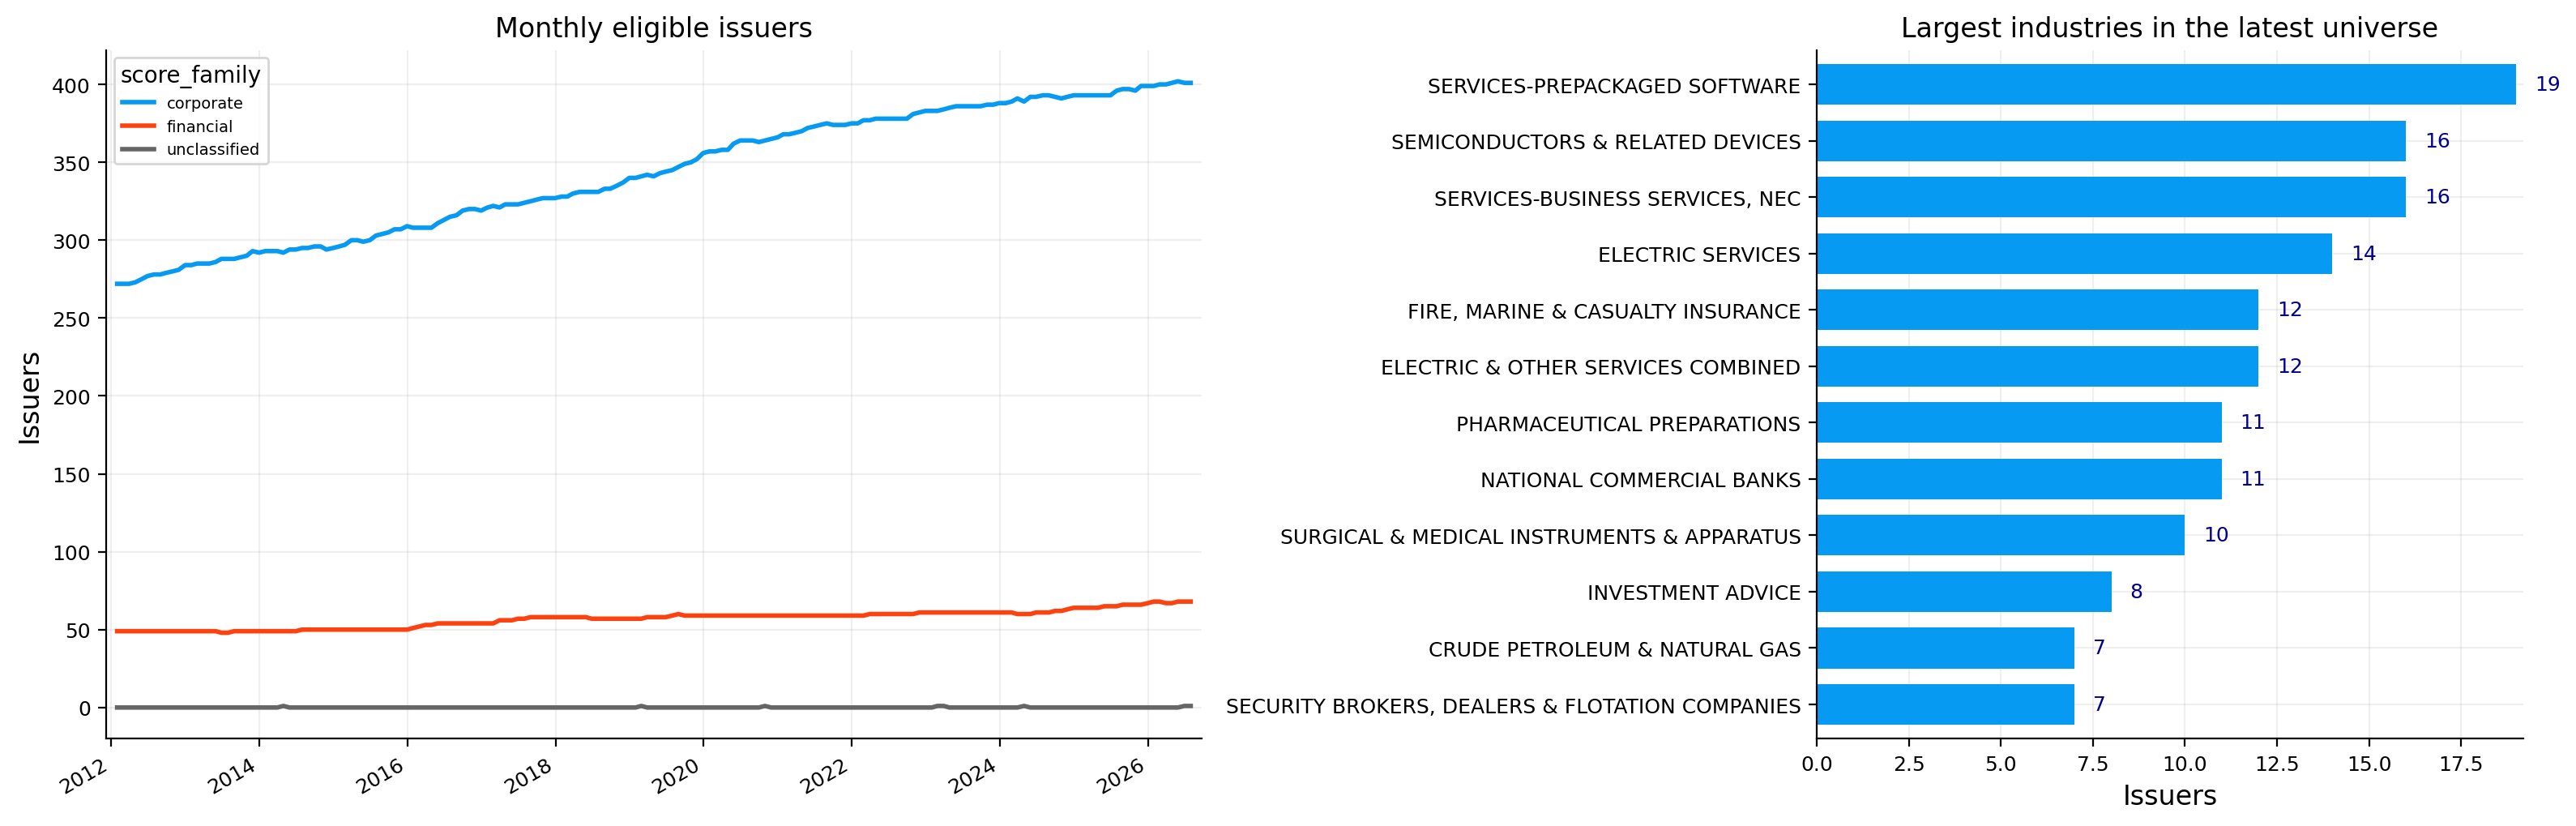

In [8]:
monthly_universe = monthly_mapped[monthly_mapped["score_family"] != "reit"].copy()
monthly_universe = monthly_universe.sort_values(["decision_date", "cik"]).reset_index(drop=True)

assert not monthly_universe.duplicated(["decision_date", "cik"]).any()
assert not monthly_universe["industry"].isin(reit_industries).any()

universe_counts = (
    monthly_universe.groupby(["decision_date", "score_family"]).size()
    .unstack(fill_value=0)
)
latest_universe = monthly_universe[monthly_universe["decision_date"] == monthly_universe["decision_date"].max()]
universe_summary = pd.DataFrame({
    "latest count": latest_universe.groupby("score_family").size(),
    "market-cap coverage": latest_universe.groupby("score_family")["market_cap"].apply(lambda s: s.notna().mean()),
})
latest_industry_counts = (
    latest_universe.groupby("industry").size().sort_values().tail(12)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.2), gridspec_kw={"width_ratios": [1.55, 1]})
universe_counts.plot(ax=axes[0], color=[blue, gold, muted], linewidth=2.0)
axes[0].set_title("Monthly eligible issuers")
axes[0].set_ylabel("Issuers")
axes[0].set_xlabel("")
finish_axes(axes[0])
latest_industry_counts.plot.barh(ax=axes[1], color=blue, width=0.72)
axes[1].set_title("Largest industries in the latest universe")
axes[1].set_xlabel("Issuers")
axes[1].set_ylabel("")
for y, value in enumerate(latest_industry_counts):
    axes[1].text(value + 0.5, y, f"{value}", va="center", color=ink, fontsize=9)
finish_axes(axes[1], axis="x")
plt.tight_layout()
plt.show()



In [9]:
duration_concepts = {'revenue': ['us-gaap:RevenueFromContractWithCustomerExcludingAssessedTax', 'us-gaap:Revenues', 'us-gaap:SalesRevenueNet', 'us-gaap:SalesRevenueGoodsNet', 'us-gaap:SalesRevenueServicesNet'], 'cost_of_revenue': ['us-gaap:CostOfRevenue', 'us-gaap:CostOfGoodsAndServicesSold', 'us-gaap:CostOfGoodsSold'], 'gross_profit': ['us-gaap:GrossProfit'], 'operating_income': ['us-gaap:OperatingIncomeLoss'], 'pretax_income': ['us-gaap:IncomeLossFromContinuingOperationsBeforeIncomeTaxesExtraordinaryItemsNoncontrollingInterest', 'us-gaap:IncomeLossFromContinuingOperationsBeforeIncomeTaxesMinorityInterestAndIncomeLossFromEquityMethodInvestments'], 'net_income': ['us-gaap:NetIncomeLoss', 'us-gaap:ProfitLoss'], 'interest_expense': ['us-gaap:InterestExpense', 'us-gaap:InterestExpenseNonoperating', 'us-gaap:InterestExpenseDebt'], 'tax_expense': ['us-gaap:IncomeTaxExpenseBenefit'], 'eps_diluted': ['us-gaap:EarningsPerShareDiluted'], 'cfo': ['us-gaap:NetCashProvidedByUsedInOperatingActivities', 'us-gaap:NetCashProvidedByUsedInOperatingActivitiesContinuingOperations'], 'capex': ['us-gaap:PaymentsToAcquirePropertyPlantAndEquipment', 'us-gaap:PaymentsToAcquireProductiveAssets'], 'depreciation': ['us-gaap:DepreciationDepletionAndAmortization', 'us-gaap:Depreciation'], 'dividends': ['us-gaap:PaymentsOfDividendsCommonStock', 'us-gaap:PaymentsOfDividends', 'us-gaap:PaymentsOfOrdinaryDividends'], 'repurchases': ['us-gaap:PaymentsForRepurchaseOfCommonStock'], 'share_issuance': ['us-gaap:ProceedsFromIssuanceOfCommonStock', 'us-gaap:ProceedsFromIssuanceOfSharesUnderIncentiveAndShareBasedCompensationPlansIncludingStockOptions', 'us-gaap:ProceedsFromStockOptionsExercised'], 'rd_expense': ['us-gaap:ResearchAndDevelopmentExpense'], 'operating_expenses': ['us-gaap:OperatingExpenses', 'us-gaap:NoninterestExpense'], 'sga_expense': ['us-gaap:SellingGeneralAndAdministrativeExpense', 'us-gaap:GeneralAndAdministrativeExpense'], 'credit_loss_provision': ['us-gaap:ProvisionForLoanLeaseAndOtherLosses', 'us-gaap:ProvisionForLoanAndLeaseLosses', 'us-gaap:ProvisionForLoanLossesExpensed']}
instant_concepts = {'cash': ['us-gaap:CashAndCashEquivalentsAtCarryingValue', 'us-gaap:CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents'], 'receivables': ['us-gaap:AccountsReceivableNetCurrent'], 'inventory': ['us-gaap:InventoryNet'], 'current_assets': ['us-gaap:AssetsCurrent'], 'total_assets': ['us-gaap:Assets'], 'current_liabilities': ['us-gaap:LiabilitiesCurrent'], 'accounts_payable': ['us-gaap:AccountsPayableCurrent'], 'total_debt_reported': ['us-gaap:LongTermDebtAndCapitalLeaseObligations'], 'long_term_debt_noncurrent': ['us-gaap:LongTermDebtNoncurrent'], 'debt_current': ['us-gaap:DebtCurrent', 'us-gaap:LongTermDebtCurrent', 'us-gaap:LongTermDebtAndCapitalLeaseObligationsCurrent'], 'short_term_borrowings': ['us-gaap:ShortTermBorrowings', 'us-gaap:CommercialPaper'], 'total_liabilities': ['us-gaap:Liabilities'], 'common_equity': ['us-gaap:StockholdersEquity'], 'retained_earnings': ['us-gaap:RetainedEarningsAccumulatedDeficit'], 'goodwill': ['us-gaap:Goodwill'], 'intangibles': ['us-gaap:IntangibleAssetsNetExcludingGoodwill', 'us-gaap:FiniteLivedIntangibleAssetsNet', 'us-gaap:IndefiniteLivedIntangibleAssetsExcludingGoodwill'], 'shares_outstanding': ['dei:EntityCommonStockSharesOutstanding', 'us-gaap:CommonStockSharesOutstanding'], 'ppe': ['us-gaap:PropertyPlantAndEquipmentNet'], 'loans': ['us-gaap:LoansAndLeasesReceivableNetReportedAmount', 'us-gaap:LoansAndLeasesReceivableNetOfDeferredIncome', 'us-gaap:LoansReceivableNet'], 'deposits': ['us-gaap:Deposits']}
concepts = {**duration_concepts, **instant_concepts}
concept_lookup = {concept: (field, priority) for field, concepts in concepts.items() for priority, concept in enumerate(concepts)}
required_concepts = sorted(concept_lookup)
candidate_coverage = concept_catalog[concept_catalog['concept'].isin(required_concepts)].copy()
candidate_coverage[['field', 'priority']] = candidate_coverage['concept'].map(concept_lookup).apply(pd.Series)
candidate_coverage = candidate_coverage.sort_values(['field', 'priority', 'rows'])
display(candidate_coverage[['field', 'priority', 'concept', 'period_type', 'unit', 'rows']])

,field,priority,concept,period_type,unit,rows
516,accounts_payable,0,us-gaap:AccountsPayableCurrent,instant,USD,45408
8163,capex,0,us-gaap:PaymentsToAcquirePropertyPlantAndEquip...,instant,USD,7
8162,capex,0,us-gaap:PaymentsToAcquirePropertyPlantAndEquip...,duration,USD,52097
8160,capex,1,us-gaap:PaymentsToAcquireProductiveAssets,instant,USD,5
8159,capex,1,us-gaap:PaymentsToAcquireProductiveAssets,duration,USD,15563
...,...,...,...,...,...,...
5018,tax_expense,0,us-gaap:IncomeTaxExpenseBenefit,instant,USD,14
5017,tax_expense,0,us-gaap:IncomeTaxExpenseBenefit,duration,USD,107777
885,total_assets,0,us-gaap:Assets,instant,USD,70324
6152,total_debt_reported,0,us-gaap:LongTermDebtAndCapitalLeaseObligations,instant,USD,17341


In [10]:
fact_columns = ['cik', 'concept', 'label', 'value', 'unit', 'period_type', 'period_start', 'period_end', 'fiscal_year', 'fiscal_period', 'filed_date', 'form_type', 'accession', 'statement_type', 'taxonomy', 'is_annual_filing', 'is_amendment', 'filing_version']
periodic_forms = ['10-Q', '10-Q/A', '10-K', '10-K/A', '20-F', '20-F/A', '40-F', '40-F/A', '6-K', '6-K/A']
eligible_ciks = sorted(monthly_universe['cik'].unique().tolist())
facts_table = fundamentals_data.to_table(columns=fact_columns, filter=ds.field('concept').isin(required_concepts) & ds.field('cik').isin(eligible_ciks) & (ds.field('period_end') >= warmup_start) & ds.field('form_type').isin(periodic_forms))
facts = facts_table.to_pandas()
facts_table = None
pa.default_memory_pool().release_unused()
facts['field'] = facts['concept'].map(lambda concept: concept_lookup[concept][0])
facts['concept_priority'] = facts['concept'].map(lambda concept: concept_lookup[concept][1]).astype('int16')
fact_load_summary = pd.DataFrame({'value': [f'{len(facts):,}', facts['cik'].nunique(), facts['concept'].nunique(), f'{facts.memory_usage(deep=True).sum() / 1024 ** 2:,.1f} MB', ', '.join(sorted(facts['form_type'].unique()))]}, index=['selected rows', 'issuers', 'concepts', 'pandas memory', 'forms'])
display(fact_load_summary)
display(facts.groupby(['field', 'period_type']).size().unstack(fill_value=0))

,value
selected rows,"2,468,207"
issuers,569
concepts,69
pandas memory,644.6 MB
forms,"10-K, 10-K/A, 10-Q, 10-Q/A, 20-F, 20-F/A"


period_type,duration,instant
field,,
accounts_payable,0,44562
capex,65641,8
cash,0,143919
cfo,72897,0
common_equity,0,81414
cost_of_revenue,68552,0
credit_loss_provision,9866,2
current_assets,0,54984
current_liabilities,0,54933


In [11]:
date_columns = ['period_start', 'period_end', 'filed_date']
for column in date_columns:
    facts[column] = pd.to_datetime(facts[column])
facts['form_type'] = facts['form_type'].str.upper().str.strip()
facts['taxonomy'] = facts['taxonomy'].str.lower().str.strip()
facts['value'] = pd.to_numeric(facts['value'], errors='coerce')
unit_valid = (
    facts["field"].eq("shares_outstanding") & facts["unit"].eq("shares")
    | facts["field"].eq("eps_diluted") & facts["unit"].isin(["USD per share", "USD/shares"])
    | ~facts["field"].isin(["shares_outstanding", "eps_diluted"]) & facts["unit"].eq("USD")
)
facts = facts[
    np.isfinite(facts["value"])
    & (facts["filed_date"] >= facts["period_end"])
    & unit_valid
].copy()
fact_version_key = ['cik', 'concept', 'unit', 'period_start', 'period_end']
exact_version_key = fact_version_key + ['filed_date', 'accession', 'filing_version']
facts = facts.sort_values(exact_version_key).drop_duplicates(exact_version_key, keep='last').reset_index(drop=True)
assert (facts['filed_date'] >= facts['period_end']).all()
assert np.isfinite(facts['value']).all()
display(facts[['cik', 'field', 'concept', 'value', 'unit', 'period_start', 'period_end', 'filed_date', 'form_type', 'filing_version']].sample(12, random_state=random_seed).sort_values(['cik', 'filed_date']))

,cik,field,concept,value,unit,period_start,period_end,filed_date,form_type,filing_version
258053,40545,dividends,us-gaap:PaymentsOfOrdinaryDividends,1.400000e+08,USD,2022-01-01,2022-03-31,2022-04-26,10-Q,1
539132,91440,eps_diluted,us-gaap:EarningsPerShareDiluted,2.160000e+00,USD per share,2016-01-03,2016-04-02,2016-04-21,10-Q,1
619216,103379,pretax_income,us-gaap:IncomeLossFromContinuingOperationsBefo...,3.674230e+08,USD,2020-03-29,2020-12-26,2022-01-28,10-Q,2
984097,814453,operating_income,us-gaap:OperatingIncomeLoss,4.618000e+08,USD,2013-01-01,2013-09-30,2013-11-08,10-Q,1
1291610,916076,retained_earnings,us-gaap:RetainedEarningsAccumulatedDeficit,8.513540e+08,USD,NaT,2017-03-31,2017-05-10,10-Q,1
1295452,916365,operating_income,us-gaap:OperatingIncomeLoss,2.631250e+08,USD,2023-12-31,2024-03-30,2024-05-09,10-Q,1
1596739,1067701,net_income,us-gaap:NetIncomeLoss,4.810000e+08,USD,2021-10-01,2021-12-31,2022-01-26,10-K,1
1632658,1090012,capex,us-gaap:PaymentsToAcquirePropertyPlantAndEquip...,1.300000e+07,USD,2019-04-01,2019-06-30,2019-08-07,10-Q,1
1645076,1091667,operating_income,us-gaap:OperatingIncomeLoss,4.930000e+08,USD,2014-01-01,2014-06-30,2014-07-31,10-Q,1
1763523,1133421,ppe,us-gaap:PropertyPlantAndEquipmentNet,9.653000e+09,USD,NaT,2023-12-31,2025-01-30,10-K,5


In [12]:
duration_mask = facts['period_type'].eq('duration') & facts['period_start'].notna()
facts['period_days'] = (facts['period_end'] - facts['period_start']).dt.days + 1
facts['duration_class'] = 'instant'
facts.loc[duration_mask & facts['period_days'].between(70, 120), 'duration_class'] = 'quarter'
facts.loc[duration_mask & facts['period_days'].between(150, 220), 'duration_class'] = 'six_month_ytd'
facts.loc[duration_mask & facts['period_days'].between(230, 310), 'duration_class'] = 'nine_month_ytd'
facts.loc[duration_mask & facts['period_days'].between(320, 410), 'duration_class'] = 'annual'
facts.loc[duration_mask & ~facts['period_days'].between(70, 410), 'duration_class'] = 'irregular'
classification = facts.groupby(['period_type', 'duration_class']).size().rename('facts').to_frame()
display(classification)

facts
period_type duration_class        
duration    annual          328550
            instant             97
            irregular          967
            nine_month_ytd  208392
            quarter         660505
            six_month_ytd   217837
instant     instant         978661

In [13]:
facts_by_filing = facts.sort_values(
    ["filed_date", "filing_version", "accession"]
).reset_index(drop=True)
economic_key = ["cik", "field", "unit", "period_start", "period_end"]


def select_filing_facts(available_facts):
    latest = available_facts.drop_duplicates(fact_version_key, keep="last")
    best_priority = latest.groupby(
        economic_key, sort=False, dropna=False
    )["concept_priority"].transform("min")
    return latest[
        latest["concept_priority"].eq(best_priority)
    ].drop_duplicates(economic_key, keep="last")


def reconstruct_quarters(selected_facts):
    duration = selected_facts[
        selected_facts["period_type"].eq("duration")
        & selected_facts["duration_class"].isin(
            ["quarter", "six_month_ytd", "nine_month_ytd", "annual"]
        )
    ]
    columns = [
        "cik", "field", "unit", "fiscal_year", "period_start",
        "period_end", "value", "filed_date", "concept", "source_class",
    ]
    direct = duration[duration["duration_class"].eq("quarter")].copy()
    direct["source_class"] = "direct"
    candidates = [direct[columns]]
    previous_class = {
        "six_month_ytd": "quarter",
        "nine_month_ytd": "six_month_ytd",
        "annual": "nine_month_ytd",
    }
    join_columns = ["cik", "field", "unit", "fiscal_year", "period_start"]
    for current_class, prior_class in previous_class.items():
        current = duration[duration["duration_class"].eq(current_class)]
        prior = duration[duration["duration_class"].eq(prior_class)]
        pairs = current.merge(
            prior[join_columns + ["period_end", "value", "filed_date"]],
            on=join_columns, how="inner", suffixes=("", "_prior"),
        )
        pairs = pairs[pairs["period_end_prior"].lt(pairs["period_end"])]
        pairs = (
            pairs.sort_values(join_columns + ["period_end", "period_end_prior"])
            .drop_duplicates(join_columns + ["period_end"], keep="last")
        )
        quarter_gap = (pairs["period_end"] - pairs["period_end_prior"]).dt.days
        quarter_value = pairs["value"] - pairs["value_prior"]
        scale = pairs[["value", "value_prior"]].abs().max(axis=1).clip(lower=1.0)
        pairs = pairs[
            quarter_gap.between(55, 140)
            & quarter_value.abs().le(10.0 * scale)
        ].copy()
        pairs["period_start"] = pairs["period_end_prior"] + pd.Timedelta(days=1)
        pairs["value"] = quarter_value.loc[pairs.index]
        pairs["filed_date"] = pairs[["filed_date", "filed_date_prior"]].max(axis=1)
        pairs["source_class"] = f"reconstructed_{current_class}"
        candidates.append(pairs[columns])
    quarter_candidates = pd.concat(candidates, ignore_index=True)
    quarter_candidates["source_rank"] = quarter_candidates[
        "source_class"
    ].ne("direct")
    quarterly = (
        quarter_candidates.sort_values([
            "cik", "field", "period_end", "source_rank", "filed_date",
        ])
        .drop_duplicates(["cik", "field", "period_end"], keep="first")
        .drop(columns="source_rank")
    )
    return quarterly, quarter_candidates


latest_selected = select_filing_facts(facts_by_filing)
quarterly_latest, quarter_candidates_latest = reconstruct_quarters(
    latest_selected
)
display(
    quarterly_latest.groupby(["field", "source_class"]).size()
    .unstack(fill_value=0)
)


source_class,direct,reconstructed_annual,reconstructed_nine_month_ytd,reconstructed_six_month_ytd
field,,,,
capex,8498,1060,5788,6226
cfo,8455,1324,6765,7294
cost_of_revenue,15502,802,1,2
credit_loss_provision,1794,171,182,187
depreciation,10345,871,2852,2991
dividends,6810,871,4870,5164
eps_diluted,26157,1004,0,4
gross_profit,12666,404,3,4
interest_expense,17153,1211,11,13


In [14]:
def duration_ttm_frame(selected_facts):
    duration = selected_facts[
        selected_facts["period_type"].eq("duration")
        & selected_facts["duration_class"].isin(
            ["quarter", "six_month_ytd", "nine_month_ytd", "annual"]
        )
    ]
    keys = ["cik", "field", "unit"]
    annual = (
        duration[duration["duration_class"].eq("annual")]
        .sort_values("period_end").groupby(keys, sort=False).tail(1)
    )
    annual = annual[
        keys + ["period_end", "value"]
    ].rename(columns={
        "period_end": "annual_end", "value": "annual_value",
    })
    current = duration[
        duration["duration_class"].isin(
            ["quarter", "six_month_ytd", "nine_month_ytd"]
        )
    ].merge(annual, on=keys, how="inner")
    distance = (current["period_end"] - current["annual_end"]).dt.days
    current = current[
        current["period_end"].gt(current["annual_end"])
        & distance.between(40, 320)
    ]
    current = (
        current.sort_values("period_end")
        .groupby(keys + ["duration_class"], sort=False).tail(1)
    )
    current = current[
        keys + [
            "duration_class", "period_end", "value",
            "annual_end", "annual_value",
        ]
    ].rename(columns={
        "period_end": "current_end", "value": "current_value",
    })
    prior = duration[
        duration["duration_class"].isin(
            ["quarter", "six_month_ytd", "nine_month_ytd"]
        )
    ][
        keys + ["duration_class", "period_end", "value"]
    ].rename(columns={
        "period_end": "prior_end", "value": "prior_value",
    })
    updates = current.merge(
        prior, on=keys + ["duration_class"], how="inner"
    )
    year_gap = (updates["current_end"] - updates["prior_end"]).dt.days
    updates = updates[year_gap.between(300, 430)]
    updates = (
        updates.sort_values("prior_end")
        .groupby(keys + ["duration_class", "current_end"], sort=False).tail(1)
    )
    updates["ttm_fallback"] = (
        updates["annual_value"]
        + updates["current_value"]
        - updates["prior_value"]
    )
    updates["period_end"] = updates["current_end"]
    updates["ttm_fallback_method"] = "annual + current YTD - prior YTD"

    candidates = annual.rename(columns={
        "annual_end": "period_end", "annual_value": "ttm_fallback",
    })
    candidates["ttm_fallback_method"] = "annual"
    candidates = pd.concat([
        candidates[
            keys + [
                "period_end", "ttm_fallback", "ttm_fallback_method",
            ]
        ],
        updates[
            keys + [
                "period_end", "ttm_fallback", "ttm_fallback_method",
            ]
        ],
    ], ignore_index=True)
    chosen = (
        candidates.sort_values("period_end")
        .groupby(["cik", "field"], sort=False).tail(1)
    )
    if chosen.empty:
        return pd.DataFrame(columns=["cik"])
    amount = chosen.pivot(
        index="cik", columns="field", values="ttm_fallback"
    )
    amount.columns = [f"{field}_ttm_fallback" for field in amount]
    method = chosen.pivot(
        index="cik", columns="field", values="ttm_fallback_method"
    )
    method.columns = [
        f"{field}_ttm_fallback_method" for field in method
    ]
    result = pd.concat([amount, method], axis=1).reset_index()
    duration_end = chosen.groupby("cik")["period_end"].max()
    result["latest_duration_end"] = duration_end.reindex(
        result["cik"]
    ).to_numpy()
    return result


def duration_frame(quarters, selected_facts):
    values = (
        quarters.sort_values(["cik", "field", "period_end", "filed_date"])
        .drop_duplicates(["cik", "field", "period_end"], keep="last")
        .copy()
    )
    grouped = values.groupby(["cik", "field"], sort=False)
    previous_value = grouped["value"].shift(1)
    previous_end = grouped["period_end"].shift(1)
    year_ago_value = grouped["value"].shift(4)
    year_ago_end = grouped["period_end"].shift(4)
    gap = (values["period_end"] - previous_end).dt.days
    year_gap = (values["period_end"] - year_ago_end).dt.days
    values["q"] = values["value"]
    values["qoq"] = values["value"].div(
        previous_value.where(previous_value.abs() > 1e-12)
    ) - 1.0
    values.loc[~gap.between(55, 140), "qoq"] = np.nan
    values["q_yoy"] = values["value"].div(
        year_ago_value.where(year_ago_value.abs() > 1e-12)
    ) - 1.0
    values.loc[~year_gap.between(300, 430), "q_yoy"] = np.nan
    values["ttm"] = (
        grouped["value"].rolling(4, min_periods=4).sum()
        .reset_index(level=[0, 1], drop=True)
    )
    valid_ttm = (
        gap.between(55, 140)
        .groupby([values["cik"], values["field"]])
        .rolling(3, min_periods=3).sum()
        .reset_index(level=[0, 1], drop=True).eq(3)
    )
    values.loc[~valid_ttm.fillna(False), "ttm"] = np.nan
    prior_ttm = values.groupby(
        ["cik", "field"], sort=False
    )["ttm"].shift(4)
    values["ttm_yoy"] = values["ttm"].div(
        prior_ttm.where(prior_ttm.abs() > 1e-12)
    ) - 1.0
    values.loc[~year_gap.between(300, 430), "ttm_yoy"] = np.nan

    latest = values.groupby(["cik", "field"], sort=False).tail(1)
    measures = ["q", "qoq", "q_yoy", "ttm", "ttm_yoy"]
    result = latest.pivot(
        index="cik", columns="field", values=measures
    )
    result.columns = [
        f"{field}_{measure}" for measure, field in result.columns
    ]
    result = result.reset_index()
    quarter_end = latest.groupby("cik")["period_end"].max()
    result["latest_quarter_end"] = quarter_end.reindex(
        result["cik"]
    ).to_numpy()
    revenue_periods = (
        values[values["field"].eq("revenue")]
        .groupby("cik", sort=False).tail(4)
        .groupby("cik")["period_end"]
        .agg(lambda dates: "|".join(dates.dt.strftime("%Y-%m-%d")))
    )
    result["ttm_quarter_ends"] = revenue_periods.reindex(
        result["cik"]
    ).to_numpy(dtype=object)

    fallback = duration_ttm_frame(selected_facts)
    result = result.merge(fallback, on="cik", how="outer")
    for field in duration_concepts:
        ttm = f"{field}_ttm"
        fallback_value = f"{field}_ttm_fallback"
        fallback_method = f"{field}_ttm_fallback_method"
        if ttm not in result:
            result[ttm] = np.nan
        if fallback_value not in result:
            continue
        scale = result[[ttm, fallback_value]].abs().max(axis=1).clip(lower=1.0)
        result[f"{field}_ttm_reconciliation"] = (
            result[ttm] - result[fallback_value]
        ).div(scale).where(
            result[ttm].notna() & result[fallback_value].notna()
        )
        result[f"{field}_ttm_method"] = np.where(
            result[ttm].notna(),
            "four standalone quarters",
            result[fallback_method],
        )
        result[ttm] = result[ttm].combine_first(result[fallback_value])
    return result.drop(columns=[
        column for column in result if "_ttm_fallback" in column
    ]).copy()


latest_duration = duration_frame(quarterly_latest, latest_selected)
ttm_columns = [
    column for column in latest_duration if column.endswith("_ttm")
]
display(
    latest_duration[ttm_columns].notna().mean()
    .sort_values(ascending=False)
    .rename("latest issuer coverage").to_frame()
)


,latest issuer coverage
cfo_ttm,0.998243
tax_expense_ttm,0.998243
net_income_ttm,0.998243
revenue_ttm,0.982425
eps_diluted_ttm,0.982425
pretax_income_ttm,0.977153
repurchases_ttm,0.947276
capex_ttm,0.934974
depreciation_ttm,0.899824
interest_expense_ttm,0.896309


In [15]:
def instant_frame(selected_facts):
    instant = selected_facts[
        selected_facts["period_type"].eq("instant")
    ].sort_values(["cik", "field", "period_end", "filed_date"])
    grouped = instant.groupby(["cik", "field"], sort=False)
    instant = instant.copy()
    instant["prior_value"] = grouped["value"].shift(1)
    instant["prior_period_end"] = grouped["period_end"].shift(1)
    latest = instant.groupby(["cik", "field"], sort=False).tail(1)
    values = ["value", "period_end", "prior_value", "prior_period_end"]
    result = latest.pivot(
        index="cik", columns="field", values=values
    )
    names = {
        "value": lambda field: field,
        "period_end": lambda field: f"{field}_period_end",
        "prior_value": lambda field: f"{field}_prior",
        "prior_period_end": lambda field: f"{field}_prior_period_end",
    }
    result.columns = [
        names[measure](field) for measure, field in result.columns
    ]
    result = result.reset_index()
    balance_end = latest.groupby("cik")["period_end"].max()
    result["latest_balance_end"] = balance_end.reindex(
        result["cik"]
    ).to_numpy()
    return result


latest_instant = instant_frame(latest_selected)
instant_columns = list(instant_concepts)
display(
    latest_instant.reindex(columns=instant_columns).notna().mean()
    .sort_values(ascending=False)
    .rename("latest_issuer_coverage").to_frame()
)


,latest_issuer_coverage
cash,1.000000
total_assets,1.000000
retained_earnings,0.991213
common_equity,0.978910
ppe,0.964851
goodwill,0.954306
shares_outstanding,0.952548
intangibles,0.913884
current_assets,0.880492
current_liabilities,0.880492


In [16]:
if monthly_filing_cache.exists():
    monthly_filing_financials = pd.read_parquet(monthly_filing_cache)
else:
    filing_dates = facts_by_filing["filed_date"]
    latest_records = pd.DataFrame()
    monthly_records = []
    cursor = 0
    for decision_date in date_map["decision_date"]:
        stop = filing_dates.searchsorted(decision_date, side="left")
        new_facts = facts_by_filing.iloc[cursor:stop]
        cursor = stop
        changed_ciks = new_facts["cik"].drop_duplicates()
        if not changed_ciks.empty:
            oldest_period = decision_date - pd.DateOffset(years=3)
            available = facts_by_filing.iloc[:stop]
            available = available[
                available["cik"].isin(changed_ciks)
                & available["period_end"].ge(oldest_period)
            ]
            selected = select_filing_facts(available)
            quarters, _ = reconstruct_quarters(selected)
            duration_values = duration_frame(quarters, selected)
            instant_values = instant_frame(selected)
            current = duration_values.merge(
                instant_values, on="cik", how="outer"
            )
            latest_filed = available.groupby("cik")["filed_date"].max()
            current["filed_date"] = latest_filed.reindex(
                current["cik"]
            ).to_numpy()
            period_dates = current.reindex(columns=[
                "latest_quarter_end", "latest_duration_end",
                "latest_balance_end",
            ]).apply(pd.to_datetime)
            current["latest_period_end"] = period_dates.max(axis=1)
            current = current.set_index("cik")
            latest_records = pd.concat([
                latest_records.drop(index=changed_ciks, errors="ignore"),
                current,
            ]).copy()
            latest_records.index.name = "cik"
        current_ciks = pd.Index(
            monthly_universe.loc[
                monthly_universe["decision_date"].eq(decision_date), "cik"
            ].unique()
        )
        available_ciks = current_ciks.intersection(latest_records.index)
        month = (
            latest_records.loc[available_ciks]
            .rename_axis("cik").reset_index()
        )
        month["decision_date"] = decision_date
        monthly_records.append(month)
    monthly_filing_financials = (
        pd.concat(monthly_records, ignore_index=True)
        .sort_values(["decision_date", "cik"])
    )
    monthly_filing_financials.to_parquet(monthly_filing_cache, index=False)
assert not monthly_filing_financials.duplicated(["decision_date", "cik"]).any()
display(pd.DataFrame({
    "value": [
        len(monthly_filing_financials),
        monthly_filing_financials["cik"].nunique(),
        monthly_filing_financials["decision_date"].min(),
        monthly_filing_financials["decision_date"].max(),
        monthly_filing_financials.shape[1],
        monthly_filing_cache.name,
    ]
}, index=[
    "monthly filing records", "issuers", "first decision", "last decision",
    "columns", "cache",
]))


,value
monthly filing records,69360
issuers,567
first decision,2012-01-31 00:00:00
last decision,2026-07-31 00:00:00
columns,257
cache,monthly_filing_financials_v2.parquet


In [17]:
monthly_financials = monthly_universe.merge(monthly_filing_financials, on=['decision_date', 'cik'], how='left', validate='one_to_one')
monthly_financials = monthly_financials.sort_values(['decision_date', 'cik']).reset_index(drop=True)
known = monthly_financials['filed_date'].notna()
assert (monthly_financials.loc[known, 'filed_date'] < monthly_financials.loc[known, 'decision_date']).all()
assert (monthly_financials['mapping_valid_from'] <= monthly_financials['decision_date']).all()
assert (monthly_financials['mapping_valid_to'] >= monthly_financials['decision_date']).all()
assert not monthly_financials.duplicated(['decision_date', 'cik']).any()
assert not monthly_financials['industry'].isin(reit_industries).any()
display(pd.DataFrame({'value': [len(monthly_financials), monthly_financials['cik'].nunique(), monthly_financials['decision_date'].min(), monthly_financials['decision_date'].max(), f'{known.mean():.1%}', monthly_financials.shape[1]]}, index=['monthly rows', 'issuers', 'first decision', 'last decision', 'filing coverage', 'columns']))

,value
monthly rows,69889
issuers,569
first decision,2012-01-31 00:00:00
last decision,2026-07-31 00:00:00
filing coverage,99.2%
columns,272


In [18]:
direct_reconstructed = quarter_candidates_latest[
    quarter_candidates_latest.duplicated(["cik", "field", "period_end"], keep=False)
].pivot_table(
    index=["cik", "field", "period_end"],
    columns="source_class",
    values="value",
    aggfunc="last",
)
reconstructed_columns = [column for column in direct_reconstructed if str(column).startswith("reconstructed_")]
reconciliation_rows = []
for column in reconstructed_columns:
    pairs = direct_reconstructed[["direct", column]].dropna()
    scale = pairs[["direct", column]].abs().max(axis=1).clip(lower=1.0)
    error = (pairs["direct"] - pairs[column]) / scale
    reconciliation_rows.append({
        "comparison": f"direct vs {column.replace('reconstructed_', '')}",
        "pairs": len(pairs), "median_abs_error": error.abs().median(),
        "p90_abs_error": error.abs().quantile(0.90),
    })
reconstruction_validation = pd.DataFrame(reconciliation_rows).set_index("comparison")

coverage_fields = ["revenue_ttm", "operating_income_ttm", "net_income_ttm", "cfo_ttm",
                   "total_assets", "common_equity", "shares_outstanding"]
coverage_by_year_family = (
    monthly_financials.assign(year=monthly_financials["decision_date"].dt.year)
    .groupby(["year", "score_family"])[coverage_fields]
    .agg(lambda values: values.notna().mean())
)
display(reconstruction_validation.style.format({
    "median_abs_error": "{:.2%}", "p90_abs_error": "{:.2%}",
}).set_caption("Standalone-quarter reconstruction checks"))

,pairs,median_abs_error,p90_abs_error
comparison,,,
direct vs annual,772,0.00%,21.05%
direct vs nine_month_ytd,65492,0.00%,0.02%
direct vs six_month_ytd,70212,0.00%,0.00%


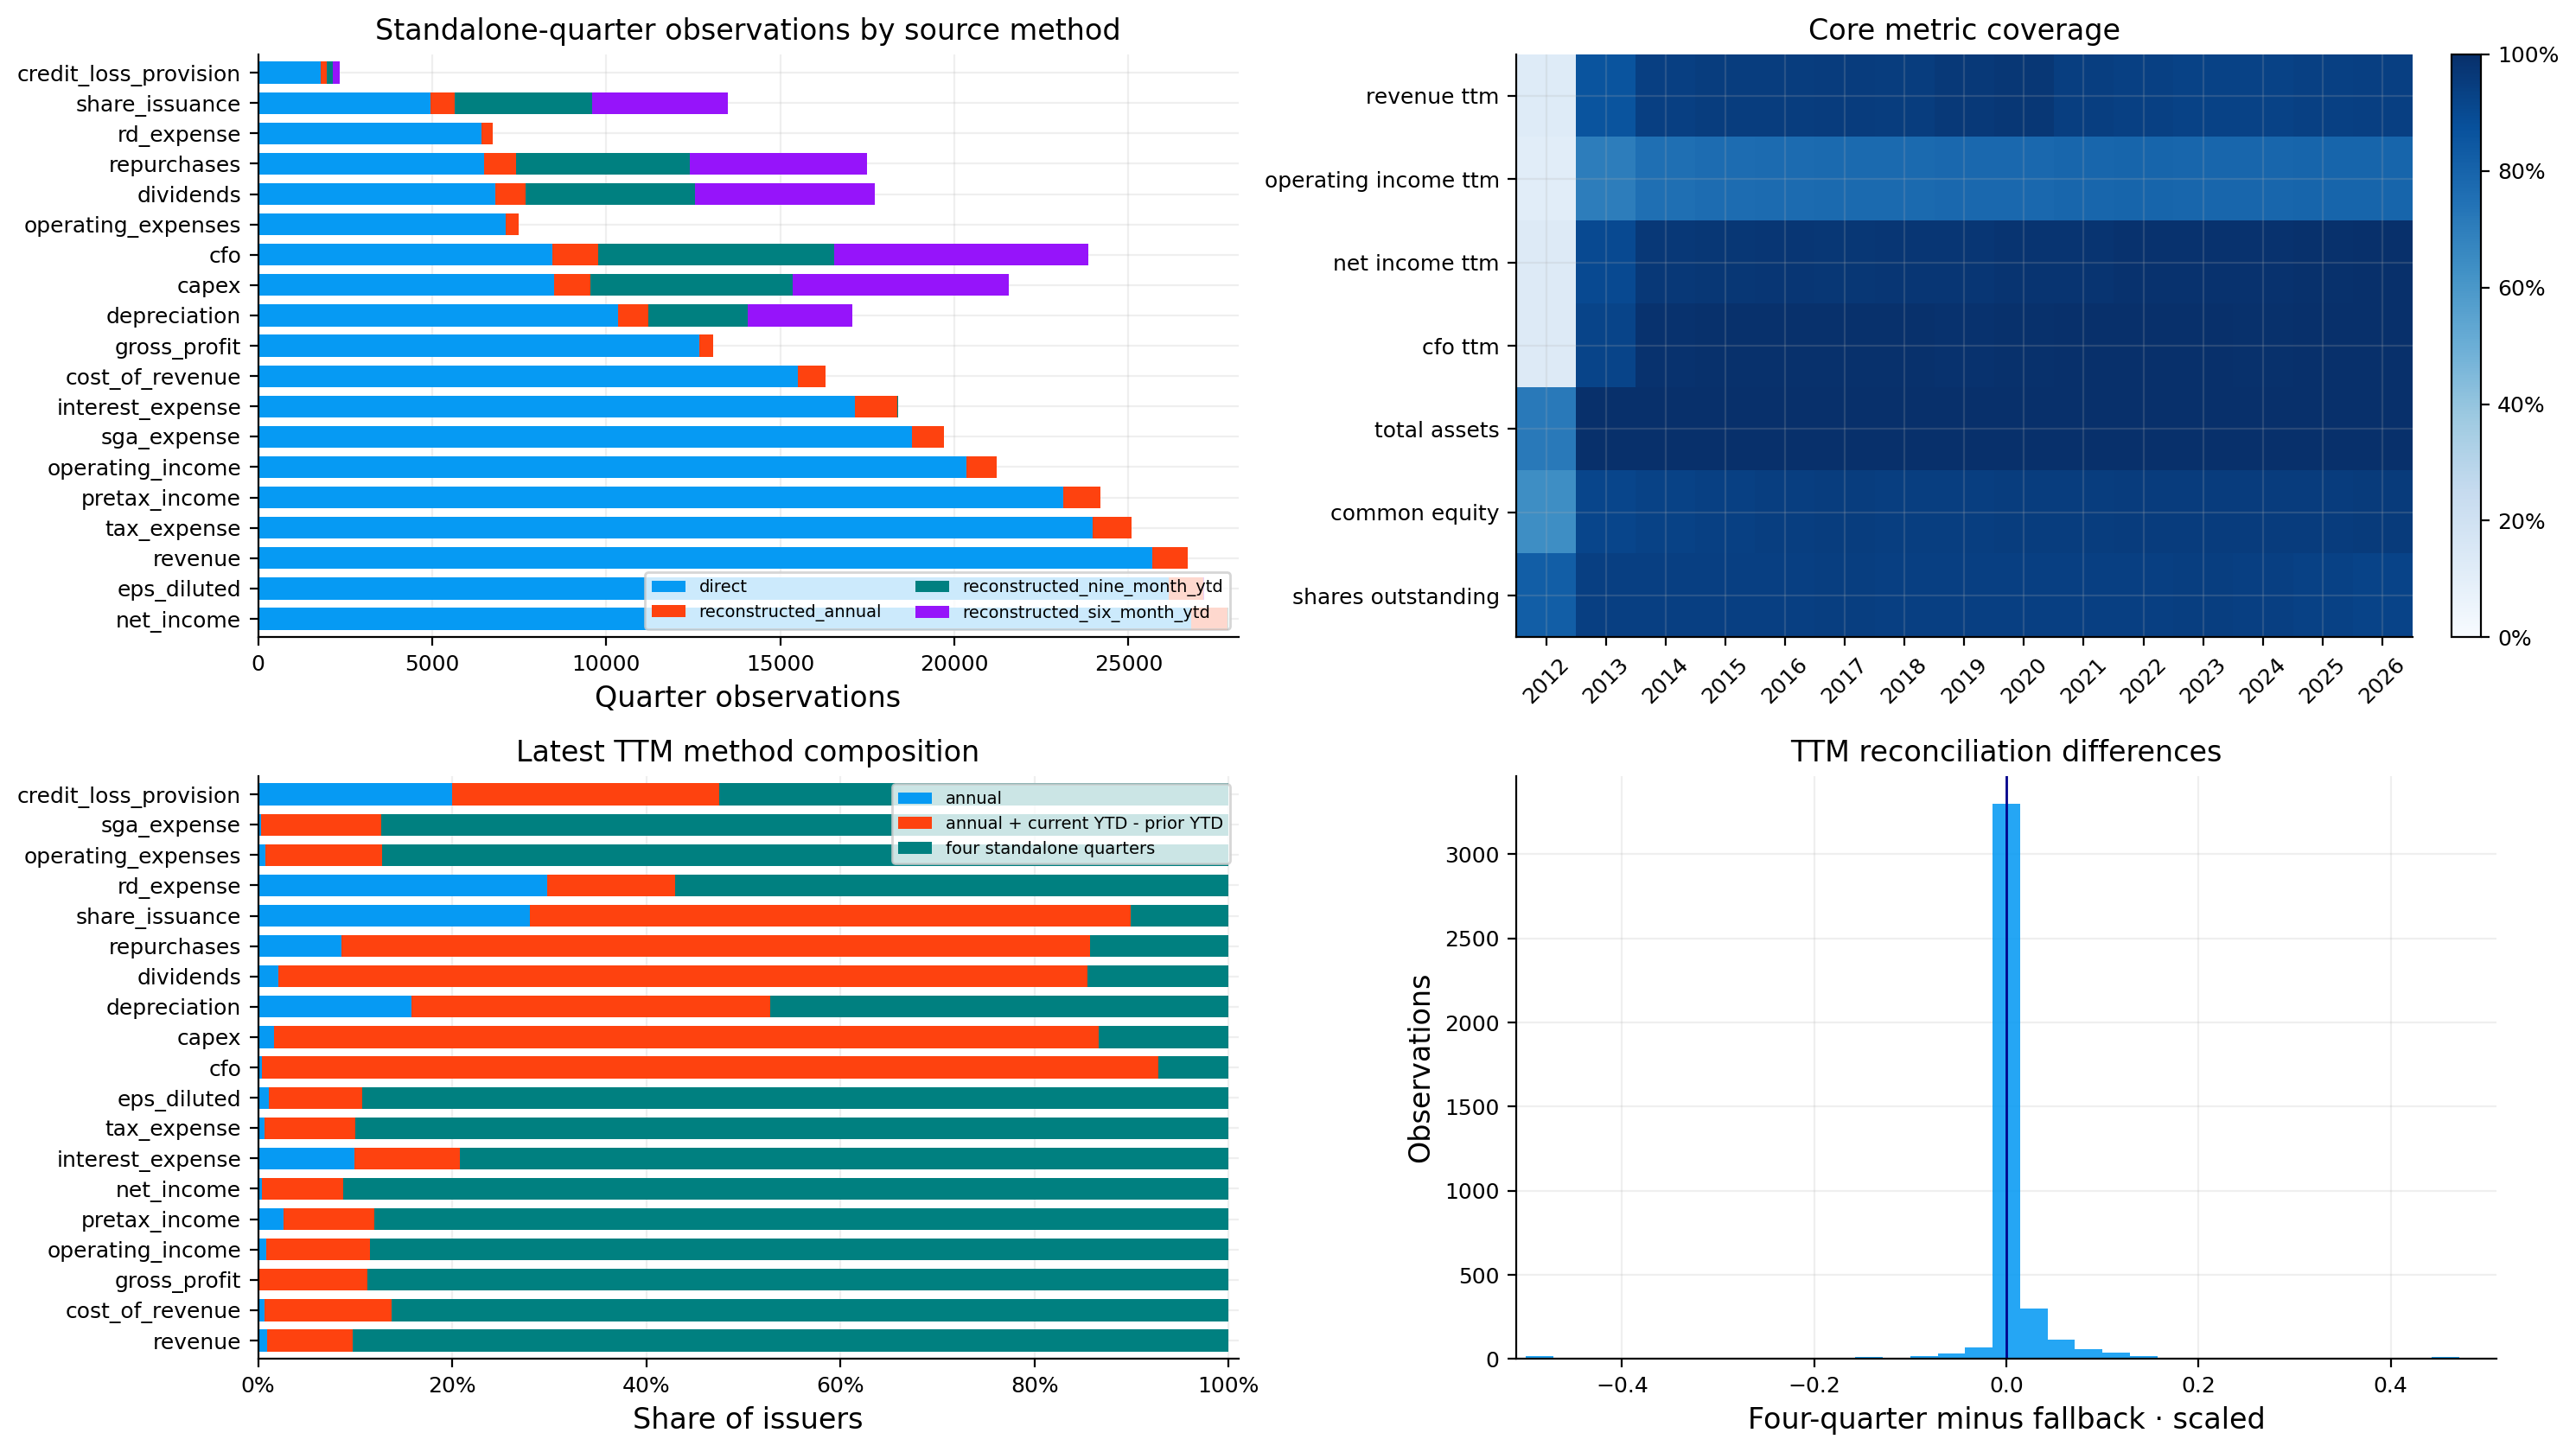

,ticker,entity_name,score_family,filed_date,latest_period_end,revenue_ttm,operating_income_ttm,net_income_ttm,cfo_ttm,total_assets,common_equity,market_cap
69700,NVDA,NVIDIA CORP,corporate,2026-05-20 00:00:00,2026-05-15 00:00:00,"$253,491,000,000","$162,285,000,000","$159,613,000,000","$125,648,000,000","$259,474,000,000","$195,474,000,000","$4,858,150,000,000"
69557,AAPL,Apple Inc.,corporate,2026-05-01 00:00:00,2026-04-17 00:00:00,"$451,442,000,000","$147,366,000,000","$122,575,000,000","$140,222,000,000","$371,082,000,000","$106,491,000,000","$4,537,071,195,747"
69843,GOOG,Alphabet Inc.,corporate,2026-07-23 00:00:00,2026-06-30 00:00:00,"$445,867,000,000","$147,628,000,000","$244,205,000,000","$185,675,000,000","$921,983,000,000","$640,480,000,000","$4,361,829,425,354"
69594,MSFT,MICROSOFT CORP,corporate,2026-07-29 00:00:00,2026-07-23 00:00:00,"$331,839,000,000","$155,237,000,000","$133,749,000,000","$182,935,000,000","$758,376,000,000","$442,387,000,000","$3,450,799,509,642"
69685,AMZN,AMAZON COM INC,corporate,2026-04-30 00:00:00,2026-04-22 00:00:00,"$742,776,000,000","$85,422,000,000","$90,798,000,000","$148,531,000,000","$916,630,000,000","$441,914,000,000","$2,921,415,636,185"
69857,AVGO,Broadcom Inc.,corporate,2026-06-09 00:00:00,2026-05-29 00:00:00,"$75,465,000,000","$32,746,000,000","$29,317,000,000","$33,622,000,000","$179,158,000,000",—,"$1,852,030,813,670"
69772,TSLA,"Tesla, Inc.",corporate,2026-07-23 00:00:00,2026-07-16 00:00:00,"$103,619,000,000","$4,372,000,000","$3,804,000,000","$18,685,000,000","$148,524,000,000","$86,858,000,000","$1,229,138,610,738"
69485,LLY,ELI LILLY & Co,corporate,2026-04-30 00:00:00,2026-04-27 00:00:00,"$72,249,500,000",—,"$25,276,700,000","$20,480,000,000","$116,576,000,000","$31,198,000,000","$1,081,910,164,681"
69441,JPM,JPMORGAN CHASE & CO,financial,2026-05-01 00:00:00,2026-03-31 00:00:00,"$182,447,000,000",—,"$58,899,000,000","$-107,704,000,000","$4,900,475,000,000","$364,038,000,000","$942,625,344,634"
69572,MU,MICRON TECHNOLOGY INC,corporate,2026-06-25 00:00:00,2026-06-17 00:00:00,"$69,533,000,000","$59,243,000,000","$50,469,000,000","$51,432,000,000","$134,112,000,000","$100,724,000,000","$929,524,478,155"


9450

In [19]:
source_mix = (
    quarterly_latest.groupby(["field", "source_class"]).size()
    .unstack(fill_value=0).sort_values("direct", ascending=False)
)
coverage_heatmap = (
    monthly_financials.assign(year=monthly_financials["decision_date"].dt.year)
    .groupby("year")[coverage_fields]
    .agg(lambda values: values.notna().mean())
)
latest_date = monthly_financials["decision_date"].max()
latest_month = monthly_financials[monthly_financials["decision_date"].eq(latest_date)]
method_columns = [
    column for column in latest_month
    if column.endswith("_ttm_method")
    and column.split("_ttm_method")[0] in duration_concepts
]
method_mix = pd.DataFrame({
    column.replace("_ttm_method", ""): latest_month[column].value_counts(normalize=True)
    for column in method_columns
}).T.fillna(0.0)
reconciliation_columns = [
    column for column in latest_month if column.endswith("_ttm_reconciliation")
]
reconciliation = latest_month[reconciliation_columns].stack().rename("difference")

fig, axes = plt.subplots(2, 2, figsize=(15, 8.5))
source_mix[["direct"] + reconstructed_columns].plot.barh(
    stacked=True, ax=axes[0, 0],
    color=[blue, gold, teal, coral][:1 + len(reconstructed_columns)], width=0.72,
)
axes[0, 0].set_title("Standalone-quarter observations by source method")
axes[0, 0].set_xlabel("Quarter observations")
axes[0, 0].set_ylabel("")
finish_axes(axes[0, 0], axis="x")
axes[0, 0].legend(loc="lower right", ncol=2)

coverage_view = coverage_heatmap.T
coverage_image = axes[0, 1].imshow(
    coverage_view, aspect="auto", cmap="Blues", vmin=0, vmax=1
)
axes[0, 1].set_title("Core metric coverage")
axes[0, 1].set_yticks(range(len(coverage_view)))
axes[0, 1].set_yticklabels([label.replace("_", " ") for label in coverage_view.index])
axes[0, 1].set_xticks(range(len(coverage_view.columns)))
axes[0, 1].set_xticklabels(coverage_view.columns, rotation=45)
fig.colorbar(
    coverage_image, ax=axes[0, 1], fraction=0.046, pad=0.04,
    format=lambda value, _: f"{value:.0%}",
)

method_mix.plot.barh(
    stacked=True, ax=axes[1, 0],
    color=[blue, gold, teal], width=0.72,
)
axes[1, 0].set_title("Latest TTM method composition")
axes[1, 0].set_xlabel("Share of issuers")
axes[1, 0].set_ylabel("")
axes[1, 0].xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
finish_axes(axes[1, 0], axis="x")

axes[1, 1].hist(reconciliation.clip(-0.5, 0.5), bins=35, color=blue, alpha=0.88)
axes[1, 1].axvline(0, color=ink, linewidth=1)
axes[1, 1].set_title("TTM reconciliation differences")
axes[1, 1].set_xlabel("Four-quarter minus fallback · scaled")
axes[1, 1].set_ylabel("Observations")
finish_axes(axes[1, 1])
plt.tight_layout()
plt.show()

latest_standardized = latest_month[[
    "ticker", "entity_name", "score_family", "filed_date", "latest_period_end",
    "revenue_ttm", "operating_income_ttm", "net_income_ttm", "cfo_ttm",
    "total_assets", "common_equity", "market_cap",
]].sort_values("market_cap", ascending=False).head(15)
display(latest_standardized.style.format({
    "revenue_ttm": "${:,.0f}", "operating_income_ttm": "${:,.0f}",
    "net_income_ttm": "${:,.0f}", "cfo_ttm": "${:,.0f}",
    "total_assets": "${:,.0f}", "common_equity": "${:,.0f}",
    "market_cap": "${:,.0f}",
}, na_rep="—"))


pa.default_memory_pool().release_unused()


In [20]:
financial_history = monthly_financials.copy()

def ratio(numerator, denominator, positive_denominator=True):
    numerator = pd.to_numeric(numerator, errors="coerce")
    denominator = pd.to_numeric(denominator, errors="coerce")
    valid = denominator.gt(0) if positive_denominator else denominator.abs().gt(1e-12)
    return (numerator / denominator).where(valid).replace([np.inf, -np.inf], np.nan)

for field in duration_concepts:
    ttm_column = f"{field}_ttm"
    if ttm_column in financial_history:
        financial_history[field] = financial_history[ttm_column]

financial_history["gross_profit"] = financial_history["gross_profit"].combine_first(
    financial_history["revenue"] - financial_history["cost_of_revenue"]
)
financial_history["free_cash_flow"] = financial_history["cfo"] - financial_history["capex"]
financial_history["total_liabilities"] = financial_history["total_liabilities"].combine_first(
    financial_history["total_assets"] - financial_history["common_equity"]
)
current_debt = financial_history["debt_current"].combine_first(
    financial_history["short_term_borrowings"]
)
debt_components = (
    financial_history["long_term_debt_noncurrent"] + current_debt
).where(
    financial_history["long_term_debt_noncurrent"].notna() & current_debt.notna()
)
financial_history["total_debt"] = financial_history["total_debt_reported"].combine_first(
    debt_components
)
financial_history["total_debt_source"] = np.select(
    [financial_history["total_debt_reported"].notna(), debt_components.notna()],
    ["reported total", "long-term plus current"],
    default="missing",
)
tangible_known = (
    financial_history["common_equity"].notna()
    & financial_history["goodwill"].notna()
    & financial_history["intangibles"].notna()
)
financial_history["tangible_equity"] = (
    financial_history["common_equity"]
    - financial_history["goodwill"]
    - financial_history["intangibles"]
).where(tangible_known)
financial_history["tangible_equity_approx"] = (
    financial_history["common_equity"]
    - financial_history["goodwill"].fillna(0.0)
    - financial_history["intangibles"].fillna(0.0)
).where(financial_history["common_equity"].notna())
financial_history["tangible_equity_source"] = np.where(
    tangible_known, "reported components", "approximation"
)
financial_history["enterprise_value"] = (
    financial_history["market_cap"]
    + financial_history["total_debt"]
    - financial_history["cash"]
)
financial_history["net_debt"] = financial_history["total_debt"] - financial_history["cash"]
financial_history["working_capital"] = (
    financial_history["current_assets"] - financial_history["current_liabilities"]
)
payout_known = financial_history[
    ["dividends", "repurchases", "share_issuance"]
].notna().all(axis=1)
financial_history["net_payout_amount"] = (
    financial_history["dividends"]
    + financial_history["repurchases"]
    - financial_history["share_issuance"]
).where(payout_known)

financial_history["average_assets"] = (
    financial_history["total_assets"] + financial_history["total_assets_prior"]
) / 2.0
financial_history["average_equity"] = (
    financial_history["common_equity"] + financial_history["common_equity_prior"]
) / 2.0
prior_tangible_known = (
    financial_history["common_equity_prior"].notna()
    & financial_history["goodwill_prior"].notna()
    & financial_history["intangibles_prior"].notna()
)
prior_tangible_equity = (
    financial_history["common_equity_prior"]
    - financial_history["goodwill_prior"]
    - financial_history["intangibles_prior"]
).where(prior_tangible_known)
financial_history["average_tangible_equity"] = (
    financial_history["tangible_equity"] + prior_tangible_equity
) / 2.0
financial_history["average_receivables"] = (
    financial_history["receivables"] + financial_history["receivables_prior"]
) / 2.0
financial_history["average_inventory"] = (
    financial_history["inventory"] + financial_history["inventory_prior"]
) / 2.0
financial_history["average_payables"] = (
    financial_history["accounts_payable"] + financial_history["accounts_payable_prior"]
) / 2.0
financial_history["average_debt"] = (
    financial_history["total_debt"]
    + financial_history["total_debt"].groupby(financial_history["cik"]).shift(12)
) / 2.0

financial_history["revenue_per_share"] = ratio(
    financial_history["revenue"], financial_history["shares_outstanding"]
)
eps_approx = ratio(financial_history["net_income"], financial_history["shares_outstanding"])
financial_history["earnings_per_share"] = financial_history["eps_diluted"].combine_first(
    eps_approx
)
financial_history["eps_source"] = np.where(
    financial_history["eps_diluted"].notna(),
    "reported diluted EPS",
    "point-in-time share approximation",
)
financial_history["fcf_per_share"] = ratio(
    financial_history["free_cash_flow"], financial_history["shares_outstanding"]
)
financial_history["book_value_per_share"] = ratio(
    financial_history["common_equity"], financial_history["shares_outstanding"]
)
financial_history["tangible_book_value_per_share"] = ratio(
    financial_history["tangible_equity"], financial_history["shares_outstanding"]
)
financial_history["shareholder_yield"] = ratio(
    financial_history["net_payout_amount"], financial_history["market_cap"]
)

display(
    financial_history[[
        "ticker", "decision_date", "free_cash_flow", "total_debt",
        "total_debt_source", "tangible_equity", "tangible_equity_source",
        "earnings_per_share", "eps_source", "shareholder_yield",
    ]].tail(12).style.format({
        "free_cash_flow": "${:,.0f}", "total_debt": "${:,.0f}",
        "tangible_equity": "${:,.0f}", "earnings_per_share": "${:,.2f}",
        "shareholder_yield": "{:.2%}",
    }, na_rep="—")
)


,ticker,decision_date,free_cash_flow,total_debt,total_debt_source,tangible_equity,tangible_equity_source,earnings_per_share,eps_source,shareholder_yield
69877,KVUE,2026-07-31 00:00:00,"$1,823,000,000",—,missing,"$-7,308,000,000",reported components,$0.85,reported diluted EPS,4.33%
69878,SOLV,2026-07-31 00:00:00,"$-203,000,000","$5,080,000,000",long-term plus current,"$-3,154,000,000",reported components,$8.15,reported diluted EPS,—
69879,VLTO,2026-07-31 00:00:00,"$1,042,000,000","$2,662,000,000",long-term plus current,"$-787,000,000",reported components,$3.88,reported diluted EPS,—
69880,TKO,2026-07-31 00:00:00,—,"$4,639,920,000",long-term plus current,"$-8,280,487,000",reported components,$2.68,reported diluted EPS,—
69881,GEV,2026-07-31 00:00:00,"$12,438,000,000","$2,794,000,000",reported total,"$-2,239,000,000",reported components,$34.83,reported diluted EPS,2.18%
69882,BG,2026-07-31 00:00:00,"$-1,161,000,000","$14,553,000,000",long-term plus current,"$12,450,000,000",reported components,$4.29,reported diluted EPS,5.07%
69883,SW,2026-07-31 00:00:00,"$1,022,000,000","$13,275,000,000",reported total,"$9,836,000,000",reported components,$0.73,reported diluted EPS,—
69884,BLK,2026-07-31 00:00:00,"$3,672,000,000",—,missing,"$-6,299,000,000",reported components,$39.78,reported diluted EPS,2.85%
69885,SNDK,2026-07-31 00:00:00,"$4,460,000,000",$0,long-term plus current,—,approximation,$29.26,reported diluted EPS,—
69886,PSKY,2026-07-31 00:00:00,"$489,000,000","$14,821,000,000",reported total,"$4,129,000,000",reported components,$-9.34,reported diluted EPS,—


In [21]:
income_common_size = {
    "gross_profit": "gross_profit_margin_cs",
    "operating_income": "operating_income_margin_cs",
    "pretax_income": "pretax_income_margin_cs",
    "net_income": "net_income_margin_cs",
    "cfo": "cfo_margin_cs",
    "free_cash_flow": "fcf_margin_cs",
}
balance_common_size = {
    "cash": "cash_assets_cs", "receivables": "receivables_assets_cs",
    "inventory": "inventory_assets_cs", "current_assets": "current_assets_cs",
    "total_debt": "debt_assets_cs", "total_liabilities": "liabilities_assets_cs",
    "common_equity": "equity_assets_cs", "tangible_equity": "tangible_equity_assets_cs",
}
for source, target in income_common_size.items():
    financial_history[target] = ratio(financial_history[source], financial_history["revenue"])
for source, target in balance_common_size.items():
    financial_history[target] = ratio(financial_history[source], financial_history["total_assets"])

def lag_12(column):
    return financial_history.groupby("cik", sort=False)[column].shift(12)

def annual_growth(column):
    prior = lag_12(column)
    return ratio(financial_history[column], prior) - 1.0

financial_history["assets_growth"] = annual_growth("total_assets")
financial_history["equity_growth"] = annual_growth("common_equity")
financial_history["shares_growth"] = annual_growth("shares_outstanding")
financial_history["working_capital_change"] = financial_history["working_capital"] - lag_12("working_capital")

latest_common_size = financial_history[financial_history["decision_date"].eq(financial_history["decision_date"].max())]
display(
    latest_common_size.groupby("score_family")[
        list(income_common_size.values()) + list(balance_common_size.values())
    ].median().T.style.format("{:.1%}", na_rep="—")
)

score_family,corporate,financial,unclassified
gross_profit_margin_cs,46.4%,42.9%,—
operating_income_margin_cs,17.9%,21.6%,—
pretax_income_margin_cs,15.3%,27.0%,—
net_income_margin_cs,12.4%,20.4%,—
cfo_margin_cs,20.0%,22.9%,—
fcf_margin_cs,13.3%,18.5%,—
cash_assets_cs,5.7%,5.0%,—
receivables_assets_cs,7.5%,7.6%,—
inventory_assets_cs,7.3%,2.0%,—
current_assets_cs,29.1%,53.7%,—


In [22]:
financial_history["gross_margin"] = ratio(financial_history["gross_profit"], financial_history["revenue"])
financial_history["operating_margin"] = ratio(financial_history["operating_income"], financial_history["revenue"])
financial_history["pretax_margin"] = ratio(financial_history["pretax_income"], financial_history["revenue"])
financial_history["net_margin"] = ratio(financial_history["net_income"], financial_history["revenue"])
financial_history["fcf_margin"] = ratio(financial_history["free_cash_flow"], financial_history["revenue"])
financial_history["gross_profitability_assets"] = ratio(financial_history["gross_profit"], financial_history["average_assets"])
financial_history["roa"] = ratio(financial_history["net_income"], financial_history["average_assets"])
financial_history["roe"] = ratio(financial_history["net_income"], financial_history["average_equity"])
financial_history["return_on_tangible_equity"] = ratio(financial_history["net_income"], financial_history["average_tangible_equity"])
financial_history["asset_turnover"] = ratio(financial_history["revenue"], financial_history["average_assets"])

effective_tax_rate = ratio(financial_history["tax_expense"], financial_history["pretax_income"]).clip(0.0, 0.50)
financial_history["nopat"] = financial_history["operating_income"] * (1.0 - effective_tax_rate.fillna(0.21))
invested_capital = financial_history["average_debt"] + financial_history["average_equity"] - financial_history["cash"]
financial_history["roic_proxy"] = ratio(financial_history["nopat"], invested_capital)

corporate_latest = financial_history[
    financial_history["decision_date"].eq(financial_history["decision_date"].max())
    & financial_history["score_family"].eq("corporate")
]
display(
    corporate_latest[[
        "ticker", "gross_margin", "operating_margin", "net_margin", "fcf_margin",
        "gross_profitability_assets", "roa", "roe", "roic_proxy", "asset_turnover",
    ]].sort_values("roic_proxy", ascending=False).head(15).style.format({
        column: "{:.1%}" for column in [
            "gross_margin", "operating_margin", "net_margin", "fcf_margin",
            "gross_profitability_assets", "roa", "roe", "roic_proxy",
        ]
    }, na_rep="—")
)

,ticker,gross_margin,operating_margin,net_margin,fcf_margin,gross_profitability_assets,roa,roe,roic_proxy,asset_turnover
69769,DPZ,40.0%,19.5%,11.9%,13.0%,111.5%,33.1%,—,316.5%,2.787184
69775,EXPE,—,14.4%,9.8%,27.0%,—,5.8%,160.0%,243.3%,0.595981
69602,FICO,83.4%,58.1%,38.3%,46.8%,86.9%,39.9%,—,124.3%,1.042016
69866,OTIS,—,15.4%,10.2%,11.5%,—,14.0%,—,114.1%,1.374412
69751,MA,—,58.3%,46.3%,47.6%,—,29.5%,263.7%,99.4%,0.637062
69571,CAH,3.7%,1.0%,0.7%,2.2%,16.0%,2.9%,—,89.5%,4.318610
69557,AAPL,47.9%,32.6%,27.2%,28.6%,57.6%,32.7%,125.9%,87.9%,1.203237
69700,NVDA,74.1%,64.0%,63.0%,47.0%,80.6%,68.5%,90.5%,79.7%,1.087298
69698,YUM,68.9%,31.5%,20.5%,19.4%,71.3%,21.2%,—,77.3%,1.034373
69572,MU,94.2%,85.2%,72.6%,37.6%,55.6%,42.8%,58.3%,70.6%,0.590211


In [23]:
financial_history["cfo_assets"] = ratio(financial_history["cfo"], financial_history["average_assets"])
financial_history["fcf_assets"] = ratio(financial_history["free_cash_flow"], financial_history["average_assets"])
financial_history["cfo_net_income"] = ratio(financial_history["cfo"], financial_history["net_income"])
financial_history["fcf_conversion"] = ratio(financial_history["free_cash_flow"], financial_history["net_income"])
financial_history["total_accruals"] = ratio(financial_history["net_income"] - financial_history["cfo"], financial_history["average_assets"])
financial_history["working_capital_accruals"] = ratio(financial_history["working_capital_change"], financial_history["average_assets"])
financial_history["cash_earnings_gap"] = financial_history["net_income"] - financial_history["cfo"]

positive_cfo = financial_history["cfo"].gt(0).where(financial_history["cfo"].notna())
positive_fcf = financial_history["free_cash_flow"].gt(0).where(financial_history["free_cash_flow"].notna())
financial_history["positive_cfo_frequency"] = (
    positive_cfo.groupby(financial_history["cik"]).transform(
        lambda values: values.rolling(24, min_periods=12).mean()
    )
)
financial_history["positive_fcf_frequency"] = (
    positive_fcf.groupby(financial_history["cik"]).transform(
        lambda values: values.rolling(24, min_periods=12).mean()
    )
)

display(
    financial_history[financial_history["decision_date"].eq(financial_history["decision_date"].max())][[
        "ticker", "cfo_assets", "fcf_assets", "cfo_net_income", "fcf_conversion",
        "total_accruals", "positive_cfo_frequency", "positive_fcf_frequency",
    ]].sort_values("total_accruals").head(15).style.format({
        "cfo_assets": "{:.1%}", "fcf_assets": "{:.1%}", "cfo_net_income": "{:.2f}",
        "fcf_conversion": "{:.2f}", "total_accruals": "{:.1%}",
        "positive_cfo_frequency": "{:.0%}", "positive_fcf_frequency": "{:.0%}",
    }, na_rep="—")
)

,ticker,cfo_assets,fcf_assets,cfo_net_income,fcf_conversion,total_accruals,positive_cfo_frequency,positive_fcf_frequency
69803,ECHO,-0.2%,-2.2%,—,—,-34.1%,—,—
69737,TPR,29.3%,27.0%,2.87,2.65,-19.1%,100%,100%
69717,CNC,11.9%,10.9%,—,—,-18.1%,100%,92%
69446,TAP,7.8%,4.7%,—,—,-17.2%,100%,100%
69821,CRWD,16.3%,13.5%,—,—,-16.5%,100%,100%
69684,VRSN,71.1%,68.8%,1.30,1.25,-16.2%,100%,100%
69481,IP,7.0%,1.5%,—,—,-16.0%,100%,50%
69886,PSKY,1.7%,1.1%,—,—,-15.8%,—,—
69784,CBOE,27.5%,26.7%,2.27,2.21,-15.4%,88%,88%
69869,VTRS,5.9%,4.8%,—,—,-15.4%,100%,100%


In [24]:
financial_history = financial_history.copy()
financial_history["revenue_growth"] = financial_history["revenue_ttm_yoy"].combine_first(annual_growth("revenue"))
financial_history["gross_profit_growth"] = financial_history["gross_profit_ttm_yoy"].combine_first(annual_growth("gross_profit"))
financial_history["operating_income_growth"] = financial_history["operating_income_ttm_yoy"].combine_first(annual_growth("operating_income"))
financial_history["net_income_growth"] = financial_history["net_income_ttm_yoy"].combine_first(annual_growth("net_income"))
financial_history["cfo_growth"] = financial_history["cfo_ttm_yoy"].combine_first(annual_growth("cfo"))
financial_history["fcf_growth"] = annual_growth("free_cash_flow")
financial_history["eps_growth"] = annual_growth("earnings_per_share")
financial_history["book_value_per_share_growth"] = annual_growth("book_value_per_share")
financial_history["tangible_book_value_per_share_growth"] = annual_growth("tangible_book_value_per_share")
financial_history["gross_margin_change"] = financial_history["gross_margin"] - lag_12("gross_margin")
financial_history["operating_margin_change"] = financial_history["operating_margin"] - lag_12("operating_margin")
financial_history["roa_change"] = financial_history["roa"] - lag_12("roa")
financial_history["roe_change"] = financial_history["roe"] - lag_12("roe")
financial_history["roic_change"] = financial_history["roic_proxy"] - lag_12("roic_proxy")
financial_history["cash_conversion_change"] = financial_history["cfo_net_income"] - lag_12("cfo_net_income")

growth_columns = [
    "revenue_growth", "gross_profit_growth", "operating_income_growth",
    "net_income_growth", "cfo_growth", "fcf_growth", "eps_growth",
    "book_value_per_share_growth", "operating_margin_change", "roa_change",
    "roic_change", "cash_conversion_change",
]
display(
    financial_history[financial_history["decision_date"].eq(financial_history["decision_date"].max())][["ticker"] + growth_columns]
    .sort_values("revenue_growth", ascending=False).head(15)
    .style.format({column: "{:.1%}" for column in growth_columns}, na_rep="—")
)

,ticker,revenue_growth,gross_profit_growth,operating_income_growth,net_income_growth,cfo_growth,fcf_growth,eps_growth,book_value_per_share_growth,operating_margin_change,roa_change,roic_change,cash_conversion_change
69645,EXE,167.8%,—,-487.1%,-426.3%,82.5%,156.9%,—,8.5%,24.4%,10.4%,—,-1381.8%
69572,MU,151.9%,798.8%,2051.2%,2065.1%,238.4%,1291.4%,451.0%,96.7%,75.2%,39.8%,66.4%,-550.2%
69700,NVDA,70.7%,80.5%,88.3%,107.9%,65.0%,65.2%,110.0%,135.1%,6.0%,3.6%,-19.3%,-20.5%
69773,PLTR,67.7%,76.2%,391.2%,299.8%,104.1%,103.9%,282.6%,53.3%,25.1%,15.2%,—,-114.5%
69861,APP,66.4%,—,99.1%,106.4%,—,—,—,—,—,—,—,—
69860,AMCR,64.8%,57.7%,-5.2%,-16.0%,37.0%,5.2%,-105.4%,845.8%,-3.8%,-2.5%,-5.6%,81.4%
69606,APH,54.4%,69.9%,90.9%,70.9%,53.5%,64.4%,38.6%,20.4%,3.4%,-1.7%,-2.2%,11.0%
69851,CVNA,54.0%,36.2%,48.9%,178.5%,—,—,—,—,—,—,—,—
69665,COF,49.4%,—,—,-33.9%,46.7%,47.4%,-71.5%,8.8%,—,-0.5%,—,495.5%
69882,BG,48.4%,14.9%,—,-37.6%,-5.3%,—,-45.6%,5.1%,—,-2.8%,—,29.3%


In [25]:
financial_history["current_ratio"] = ratio(financial_history["current_assets"], financial_history["current_liabilities"])
financial_history["cash_ratio"] = ratio(financial_history["cash"], financial_history["current_liabilities"])
financial_history["debt_equity"] = ratio(financial_history["total_debt"], financial_history["common_equity"])
financial_history["debt_assets"] = ratio(financial_history["total_debt"], financial_history["total_assets"])
financial_history["net_debt_assets"] = ratio(financial_history["net_debt"], financial_history["total_assets"])
financial_history["liabilities_assets"] = ratio(financial_history["total_liabilities"], financial_history["total_assets"])
financial_history["interest_coverage"] = ratio(financial_history["operating_income"], financial_history["interest_expense"])
financial_history["cfo_debt"] = ratio(financial_history["cfo"], financial_history["total_debt"])
financial_history["fcf_debt"] = ratio(financial_history["free_cash_flow"], financial_history["total_debt"])
financial_history["cash_assets"] = ratio(financial_history["cash"], financial_history["total_assets"])
financial_history["tangible_equity_assets"] = ratio(financial_history["tangible_equity"], financial_history["total_assets"])
financial_history["leverage_improvement"] = -(financial_history["net_debt_assets"] - lag_12("net_debt_assets"))

display(
    financial_history[
        financial_history["decision_date"].eq(financial_history["decision_date"].max())
        & financial_history["score_family"].eq("corporate")
    ][[
        "ticker", "current_ratio", "cash_ratio", "debt_equity", "debt_assets",
        "net_debt_assets", "interest_coverage", "cfo_debt", "cash_assets",
        "tangible_equity_assets",
    ]].sort_values("net_debt_assets").head(15).style.format({
        "current_ratio": "{:.2f}", "cash_ratio": "{:.2f}", "debt_equity": "{:.2f}",
        "debt_assets": "{:.1%}", "net_debt_assets": "{:.1%}",
        "interest_coverage": "{:.1f}×", "cfo_debt": "{:.1%}",
        "cash_assets": "{:.1%}", "tangible_equity_assets": "{:.1%}",
    }, na_rep="—")
)

,ticker,current_ratio,cash_ratio,debt_equity,debt_assets,net_debt_assets,interest_coverage,cfo_debt,cash_assets,tangible_equity_assets
69652,CPRT,7.61,4.89,0.00,0.0%,-34.8%,—,—,34.8%,56.1%
69762,FTNT,1.28,0.61,0.32,4.6%,-22.5%,135.7×,683.5%,27.0%,11.2%
69885,SNDK,4.78,1.95,0.00,0.0%,-21.9%,101.3×,—,21.9%,—
69693,FIX,1.21,0.39,0.02,0.7%,-21.1%,49.7×,4092.2%,21.9%,18.6%
69581,ROST,1.54,0.84,0.16,6.5%,-20.0%,—,339.1%,26.6%,—
69827,ABNB,1.44,0.43,0.32,9.2%,-17.0%,—,184.4%,26.2%,25.6%
69626,MNST,3.26,1.12,0.02,1.8%,-17.0%,—,1103.0%,18.8%,55.5%
69654,COST,1.07,0.45,0.17,6.6%,-15.4%,76.9×,264.6%,21.9%,—
69572,MU,3.42,1.28,0.05,3.8%,-14.8%,167.4×,1000.6%,18.6%,73.9%
69881,GEV,0.85,0.23,0.23,3.5%,-12.8%,—,506.0%,16.2%,-2.8%


In [26]:
financial_history["receivable_turnover"] = ratio(financial_history["revenue"], financial_history["average_receivables"])
financial_history["days_sales_outstanding"] = 365.0 * ratio(financial_history["average_receivables"], financial_history["revenue"])
financial_history["inventory_turnover"] = ratio(financial_history["cost_of_revenue"], financial_history["average_inventory"])
financial_history["inventory_days"] = 365.0 * ratio(financial_history["average_inventory"], financial_history["cost_of_revenue"])
financial_history["payable_days"] = 365.0 * ratio(financial_history["average_payables"], financial_history["cost_of_revenue"])
financial_history["cash_conversion_cycle"] = (
    financial_history["days_sales_outstanding"] + financial_history["inventory_days"] - financial_history["payable_days"]
)
financial_history["working_capital_revenue"] = ratio(financial_history["working_capital"], financial_history["revenue"])

efficiency_coverage = financial_history[
    ["asset_turnover", "receivable_turnover", "days_sales_outstanding",
     "inventory_turnover", "inventory_days", "payable_days",
     "cash_conversion_cycle", "working_capital_revenue"]
].notna().mean().rename("coverage").to_frame()
display(efficiency_coverage.style.format("{:.1%}"))
display(
    financial_history[
        financial_history["decision_date"].eq(financial_history["decision_date"].max())
        & financial_history["ticker"].isin(["AAPL", "LLY", "CAT"])
    ][[
        "ticker", "asset_turnover", "days_sales_outstanding", "inventory_days",
        "payable_days", "cash_conversion_cycle", "working_capital_revenue",
    ]].style.format({
        "asset_turnover": "{:.2f}", "days_sales_outstanding": "{:.0f}",
        "inventory_days": "{:.0f}", "payable_days": "{:.0f}",
        "cash_conversion_cycle": "{:.0f}", "working_capital_revenue": "{:.1%}",
    }, na_rep="—")
)

,coverage
asset_turnover,89.3%
receivable_turnover,58.8%
days_sales_outstanding,58.8%
inventory_turnover,49.4%
inventory_days,49.4%
payable_days,50.6%
cash_conversion_cycle,30.5%
working_capital_revenue,78.9%


,ticker,asset_turnover,days_sales_outstanding,inventory_days,payable_days,cash_conversion_cycle,working_capital_revenue
69440,CAT,0.73,58,146,72,132,17.9%
69485,LLY,0.63,91,416,153,354,25.2%
69557,AAPL,1.20,28,10,99,-61,2.1%


In [27]:
financial_history["capex_revenue"] = ratio(financial_history["capex"], financial_history["revenue"])
financial_history["capex_depreciation"] = ratio(financial_history["capex"], financial_history["depreciation"])
financial_history["rd_revenue"] = ratio(financial_history["rd_expense"], financial_history["revenue"])
financial_history["reinvestment_proxy"] = ratio(
    financial_history["capex"] - financial_history["depreciation"] + financial_history["working_capital_change"],
    financial_history["nopat"],
)
financial_history["dividend_payout_ratio"] = ratio(financial_history["dividends"], financial_history["net_income"])
financial_history["dividend_coverage_cfo"] = ratio(financial_history["cfo"], financial_history["dividends"])
financial_history["dividend_coverage_fcf"] = ratio(financial_history["free_cash_flow"], financial_history["dividends"])
financial_history["repurchase_yield"] = ratio(financial_history["repurchases"], financial_history["market_cap"])
financial_history["issuance_yield"] = ratio(financial_history["share_issuance"], financial_history["market_cap"])
financial_history["net_shareholder_yield"] = financial_history["shareholder_yield"]
financial_history["share_count_dilution"] = financial_history["shares_growth"]
financial_history["per_share_growth_spread"] = financial_history["eps_growth"] - financial_history["net_income_growth"]
financial_history["book_per_share_growth_spread"] = financial_history["book_value_per_share_growth"] - financial_history["equity_growth"]
financial_history["reinvestment_quality"] = financial_history["reinvestment_proxy"].where(
    financial_history["reinvestment_proxy"].between(-1.0, 3.0)
)

capital_allocation_columns = [
    "capex_revenue", "capex_depreciation", "rd_revenue", "reinvestment_proxy",
    "dividend_payout_ratio", "dividend_coverage_cfo", "dividend_coverage_fcf",
    "repurchase_yield", "issuance_yield", "net_shareholder_yield",
    "share_count_dilution", "per_share_growth_spread",
]
display(
    financial_history[financial_history["decision_date"].eq(financial_history["decision_date"].max())][
        ["ticker"] + capital_allocation_columns
    ].sort_values("net_shareholder_yield", ascending=False).head(15)
    .style.format({
        column: "{:.1%}" for column in [
            "capex_revenue", "rd_revenue", "dividend_payout_ratio",
            "repurchase_yield", "issuance_yield", "net_shareholder_yield",
            "share_count_dilution", "per_share_growth_spread",
        ]
    } | {
        "capex_depreciation": "{:.2f}", "reinvestment_proxy": "{:.2f}",
        "dividend_coverage_cfo": "{:.2f}", "dividend_coverage_fcf": "{:.2f}",
    }, na_rep="—")
)

,ticker,capex_revenue,capex_depreciation,rd_revenue,reinvestment_proxy,dividend_payout_ratio,dividend_coverage_cfo,dividend_coverage_fcf,repurchase_yield,issuance_yield,net_shareholder_yield,share_count_dilution,per_share_growth_spread
69826,ZTS,5.8%,1.14,—,—,33.6%,3.14,2.52,10.5%,0.0%,13.2%,-5.8%,2.1%
69839,PYPL,2.6%,0.93,—,-0.53,5.1%,24.58,21.17,12.0%,0.2%,12.3%,-7.7%,2.8%
69426,AIG,0.9%,—,—,—,31.1%,3.59,3.34,9.9%,0.4%,11.9%,-8.0%,—
69462,MTB,15.3%,0.80,—,—,30.7%,3.75,3.47,8.9%,0.1%,11.4%,-8.8%,8.6%
69844,FTV,2.9%,0.26,7.2%,-1.39,15.3%,12.91,11.44,10.6%,0.4%,10.6%,-9.9%,7.0%
69770,LVS,7.5%,—,1.6%,—,54.3%,3.98,2.88,8.0%,0.8%,10.1%,-5.6%,7.5%
69580,T,17.5%,1.09,—,0.42,37.2%,4.97,2.20,5.0%,0.0%,10.0%,-4.2%,2.6%
69484,KR,2.8%,1.25,—,-1.26,84.4%,7.80,3.19,7.7%,0.2%,10.0%,-7.3%,4.5%
69467,GIS,2.9%,0.97,1.4%,0.93,—,1.65,1.24,2.6%,0.0%,9.5%,-1.6%,-0.6%
69639,DHI,0.4%,1.34,—,—,16.6%,6.62,6.32,7.2%,0.0%,8.5%,-6.2%,0.1%


In [28]:
financial_history = financial_history.copy()
financial_history["earnings_yield"] = ratio(financial_history["net_income"], financial_history["market_cap"])
financial_history["price_earnings"] = ratio(financial_history["market_cap"], financial_history["net_income"])
financial_history["fcf_yield"] = ratio(financial_history["free_cash_flow"], financial_history["market_cap"])
financial_history["price_fcf"] = ratio(financial_history["market_cap"], financial_history["free_cash_flow"])
financial_history["sales_yield"] = ratio(financial_history["revenue"], financial_history["market_cap"])
financial_history["price_sales"] = ratio(financial_history["market_cap"], financial_history["revenue"])
financial_history["book_to_market"] = ratio(financial_history["common_equity"], financial_history["market_cap"])
financial_history["price_book"] = ratio(financial_history["market_cap"], financial_history["common_equity"])
financial_history["tangible_book_to_market"] = ratio(financial_history["tangible_equity"], financial_history["market_cap"])
financial_history["price_tangible_book"] = ratio(financial_history["market_cap"], financial_history["tangible_equity"])
financial_history["ebit_ev"] = ratio(financial_history["operating_income"], financial_history["enterprise_value"])
financial_history["ev_ebit"] = ratio(financial_history["enterprise_value"], financial_history["operating_income"])
financial_history["ev_sales"] = ratio(financial_history["enterprise_value"], financial_history["revenue"])
financial_history["sales_ev"] = ratio(financial_history["revenue"], financial_history["enterprise_value"])
financial_history["ev_fcf"] = ratio(financial_history["enterprise_value"], financial_history["free_cash_flow"])

valuation_columns = [
    "earnings_yield", "price_earnings", "fcf_yield", "price_fcf",
    "price_sales", "price_book", "price_tangible_book", "ebit_ev", "ev_ebit", "ev_sales",
]
display(
    financial_history[
        financial_history["decision_date"].eq(financial_history["decision_date"].max())
        & financial_history["score_family"].eq("corporate")
    ][["ticker"] + valuation_columns].sort_values("earnings_yield", ascending=False).head(15)
    .style.format({
        "earnings_yield": "{:.1%}", "fcf_yield": "{:.1%}", "ebit_ev": "{:.1%}",
        "price_earnings": "{:.1f}×", "price_fcf": "{:.1f}×",
        "price_sales": "{:.1f}×", "price_book": "{:.1f}×",
        "price_tangible_book": "{:.1f}×", "ev_ebit": "{:.1f}×", "ev_sales": "{:.1f}×",
    }, na_rep="—")
)

,ticker,earnings_yield,price_earnings,fcf_yield,price_fcf,price_sales,price_book,price_tangible_book,ebit_ev,ev_ebit,ev_sales
69645,EXE,14.3%,7.0×,13.3%,7.5×,1.6×,1.2×,—,16.9%,5.9×,1.8×
69580,T,13.5%,7.4×,11.1%,9.0×,1.3×,—,—,9.3%,10.8×,2.2×
69631,AES,12.9%,7.7×,-14.1%,—,0.8×,2.4×,5.1×,—,—,—
69611,EIX,12.6%,7.9×,-2.3%,—,1.4×,1.6×,—,8.8%,11.3×,3.5×
69659,TSCO,12.1%,8.3×,3.4%,29.2×,1.0×,6.4×,7.6×,—,—,—
69873,APA,11.6%,8.6×,—,—,—,2.0×,—,19.1%,5.2×,—
69745,FIS,11.5%,8.7×,11.7%,8.6×,2.0×,1.4×,—,4.6%,21.6×,3.4×
69794,LULU,11.3%,8.8×,9.9%,10.1×,1.2×,2.7×,2.8×,—,—,—
69598,FISV,11.1%,9.0×,14.3%,7.0×,1.4×,1.1×,—,9.6%,10.4×,2.6×
69774,CF,11.0%,9.1×,8.4%,11.9×,2.6×,3.6×,8.1×,—,—,—


In [29]:
financial_mask = financial_history["score_family"].eq("financial")
financial_history["fin_roa"] = financial_history["roa"].where(financial_mask)
financial_history["fin_roe"] = financial_history["roe"].where(financial_mask)
financial_history["fin_pretax_assets"] = ratio(financial_history["pretax_income"], financial_history["average_assets"]).where(financial_mask)
financial_history["fin_net_margin"] = financial_history["net_margin"].where(financial_mask)
financial_history["fin_equity_assets"] = ratio(financial_history["common_equity"], financial_history["total_assets"]).where(financial_mask)
financial_history["fin_tangible_equity_assets"] = ratio(financial_history["tangible_equity"], financial_history["total_assets"]).where(financial_mask)
financial_history["fin_liabilities_assets"] = ratio(financial_history["total_liabilities"], financial_history["total_assets"]).where(financial_mask)
financial_history["fin_assets_equity"] = ratio(financial_history["total_assets"], financial_history["common_equity"]).where(financial_mask)
financial_history["fin_tangible_bvps"] = financial_history["tangible_book_value_per_share"].where(financial_mask)

display(
    financial_history[
        financial_history["decision_date"].eq(financial_history["decision_date"].max()) & financial_mask
    ][[
        "ticker", "fin_roa", "fin_roe", "fin_pretax_assets", "fin_net_margin",
        "fin_equity_assets", "fin_tangible_equity_assets", "fin_assets_equity",
        "book_value_per_share", "fin_tangible_bvps",
    ]].sort_values("fin_roe", ascending=False).style.format({
        "fin_roa": "{:.2%}", "fin_roe": "{:.1%}", "fin_pretax_assets": "{:.2%}",
        "fin_net_margin": "{:.1%}", "fin_equity_assets": "{:.1%}",
        "fin_tangible_equity_assets": "{:.1%}", "fin_assets_equity": "{:.1f}×",
        "book_value_per_share": "${:,.2f}", "fin_tangible_bvps": "${:,.2f}",
    }, na_rep="—")
)

,ticker,fin_roa,fin_roe,fin_pretax_assets,fin_net_margin,fin_equity_assets,fin_tangible_equity_assets,fin_assets_equity,book_value_per_share,fin_tangible_bvps
69786,IBKR,2.16%,83.4%,2.37%,179.2%,2.6%,—,39.2×,—,—
69605,AMP,2.08%,61.0%,2.64%,20.2%,3.4%,2.4%,29.7×,$69.10,$49.12
69552,AON,7.47%,40.3%,9.70%,22.3%,18.0%,-22.4%,5.6×,$45.25,$-56.30
69651,ALL,9.97%,39.0%,10.80%,17.8%,25.5%,22.5%,3.9×,$122.78,$108.50
69513,PGR,9.43%,37.1%,11.87%,12.9%,26.2%,26.0%,3.8×,$54.83,$54.31
69792,BX,6.36%,35.9%,14.94%,20.7%,17.3%,13.2%,5.8×,$11.27,$8.56
69424,AXP,3.71%,33.5%,4.78%,26.6%,11.1%,9.5%,9.0×,$50.76,$43.41
69515,TRV,5.81%,25.5%,7.23%,17.0%,23.1%,20.0%,4.3×,$158.80,$137.77
69868,HOOD,4.06%,24.9%,4.73%,42.0%,15.1%,13.8%,6.6×,—,—
69663,ERIE,16.64%,23.9%,21.16%,14.0%,69.4%,—,1.4×,—,—


In [30]:
financial_history["fin_revenue_growth"] = financial_history["revenue_growth"].where(financial_mask)
financial_history["fin_net_income_growth"] = financial_history["net_income_growth"].where(financial_mask)
financial_history["fin_asset_growth"] = financial_history["assets_growth"].where(financial_mask)
financial_history["fin_equity_growth"] = financial_history["equity_growth"].where(financial_mask)
financial_history["fin_bvps_growth"] = financial_history["book_value_per_share_growth"].where(financial_mask)
financial_history["fin_tbvps_growth"] = financial_history["tangible_book_value_per_share_growth"].where(financial_mask)
financial_history["fin_roa_change"] = financial_history["roa_change"].where(financial_mask)
financial_history["fin_roe_change"] = financial_history["roe_change"].where(financial_mask)
financial_history["fin_equity_assets_change"] = (
    financial_history["fin_equity_assets"] - financial_history.groupby("cik")["fin_equity_assets"].shift(12)
).where(financial_mask)

for source, target in [
    ("fin_roa", "fin_roa_variability"),
    ("fin_roe", "fin_roe_variability"),
    ("net_income", "fin_net_income_variability"),
]:
    rolling_std = financial_history[source].groupby(financial_history["cik"]).transform(
        lambda values: values.rolling(36, min_periods=24).std()
    )
    scale = financial_history[source].abs().groupby(financial_history["cik"]).transform(
        lambda values: values.rolling(36, min_periods=24).mean()
    )
    financial_history[target] = ratio(rolling_std, scale).where(financial_mask)

positive_earnings = financial_history["net_income"].gt(0).where(financial_history["net_income"].notna())
financial_history["fin_positive_earnings_frequency"] = positive_earnings.groupby(financial_history["cik"]).transform(
    lambda values: values.rolling(36, min_periods=24).mean()
).where(financial_mask)

financial_stability_columns = [
    "fin_revenue_growth", "fin_net_income_growth", "fin_asset_growth",
    "fin_equity_growth", "fin_bvps_growth", "fin_tbvps_growth",
    "fin_roa_change", "fin_roe_change", "fin_equity_assets_change",
    "fin_roa_variability", "fin_roe_variability",
    "fin_net_income_variability", "fin_positive_earnings_frequency",
]
display(
    financial_history[
        financial_history["decision_date"].eq(financial_history["decision_date"].max()) & financial_mask
    ][["ticker"] + financial_stability_columns].style.format({
        column: "{:.1%}" for column in financial_stability_columns
    }, na_rep="—")
)

,ticker,fin_revenue_growth,fin_net_income_growth,fin_asset_growth,fin_equity_growth,fin_bvps_growth,fin_tbvps_growth,fin_roa_change,fin_roe_change,fin_equity_assets_change,fin_roa_variability,fin_roe_variability,fin_net_income_variability,fin_positive_earnings_frequency
69424,AXP,8.8%,12.8%,4.3%,6.1%,9.3%,7.9%,0.2%,1.6%,0.2%,6.5%,6.1%,12.3%,100.0%
69425,AFL,7.2%,29.0%,-3.3%,13.8%,20.8%,—,1.0%,1.9%,3.9%,25.2%,27.0%,25.4%,100.0%
69426,AIG,-2.3%,-264.5%,-0.2%,-2.5%,6.0%,—,3.1%,12.3%,-0.6%,88.1%,75.3%,75.7%,75.0%
69435,WRB,6.6%,8.4%,7.2%,9.3%,11.3%,—,0.0%,-0.7%,0.4%,4.7%,5.3%,9.9%,100.0%
69441,JPM,2.8%,-1.3%,12.5%,3.6%,7.4%,8.2%,-0.2%,-0.9%,-0.6%,5.5%,5.1%,8.3%,100.0%
69442,CINF,19.6%,82.8%,11.3%,16.6%,18.8%,—,3.1%,7.6%,1.7%,44.9%,44.8%,45.8%,88.9%
69460,FITB,—,-5.9%,39.7%,67.2%,23.1%,9.5%,-0.2%,-3.7%,1.9%,8.2%,13.7%,4.6%,100.0%
69461,USB,4.7%,16.7%,3.6%,9.5%,9.9%,15.1%,0.1%,0.6%,0.5%,13.6%,8.5%,14.7%,100.0%
69462,MTB,6.8%,11.0%,2.1%,-3.5%,5.8%,4.3%,0.1%,1.2%,-0.8%,8.1%,10.8%,7.7%,100.0%
69464,BEN,3.8%,81.4%,6.6%,-1.8%,-0.7%,9.5%,0.9%,2.8%,-3.1%,43.6%,41.4%,40.1%,100.0%


In [31]:
financial_history["fin_operating_expense_ratio"] = ratio(financial_history["operating_expenses"], financial_history["revenue"]).where(financial_mask)
financial_history["fin_pretax_margin"] = financial_history["pretax_margin"].where(financial_mask)
financial_history["fin_revenue_assets"] = ratio(financial_history["revenue"], financial_history["average_assets"]).where(financial_mask)
financial_history["fin_earnings_yield"] = financial_history["earnings_yield"].where(financial_mask)
financial_history["fin_price_book"] = financial_history["price_book"].where(financial_mask)
financial_history["fin_book_to_market"] = financial_history["book_to_market"].where(financial_mask)
financial_history["fin_price_tangible_book"] = financial_history["price_tangible_book"].where(financial_mask)
financial_history["fin_tangible_book_to_market"] = financial_history["tangible_book_to_market"].where(financial_mask)
financial_history["fin_revenue_market_cap"] = financial_history["sales_yield"].where(financial_mask)
financial_history["fin_dividend_yield"] = ratio(financial_history["dividends"], financial_history["market_cap"]).where(financial_mask)
financial_history["fin_repurchase_yield"] = financial_history["repurchase_yield"].where(financial_mask)
financial_history["fin_issuance_yield"] = financial_history["issuance_yield"].where(financial_mask)
financial_history["fin_net_payout_yield"] = financial_history["net_shareholder_yield"].where(financial_mask)
financial_history["fin_share_dilution"] = financial_history["share_count_dilution"].where(financial_mask)

financial_value_columns = [
    "fin_operating_expense_ratio", "fin_pretax_margin", "fin_revenue_assets",
    "fin_earnings_yield", "fin_price_book", "fin_price_tangible_book",
    "fin_dividend_yield", "fin_repurchase_yield", "fin_issuance_yield",
    "fin_net_payout_yield", "fin_share_dilution",
]
display(
    financial_history[
        financial_history["decision_date"].eq(financial_history["decision_date"].max()) & financial_mask
    ][["ticker"] + financial_value_columns].style.format({
        "fin_operating_expense_ratio": "{:.1%}", "fin_pretax_margin": "{:.1%}",
        "fin_revenue_assets": "{:.2f}", "fin_earnings_yield": "{:.1%}",
        "fin_price_book": "{:.1f}×", "fin_price_tangible_book": "{:.1f}×",
        "fin_dividend_yield": "{:.1%}", "fin_repurchase_yield": "{:.1%}",
        "fin_issuance_yield": "{:.1%}", "fin_net_payout_yield": "{:.1%}",
        "fin_share_dilution": "{:.1%}",
    }, na_rep="—")
)

,ticker,fin_operating_expense_ratio,fin_pretax_margin,fin_revenue_assets,fin_earnings_yield,fin_price_book,fin_price_tangible_book,fin_dividend_yield,fin_repurchase_yield,fin_issuance_yield,fin_net_payout_yield,fin_share_dilution
69424,AXP,130.3%,34.3%,0.14,5.0%,6.6×,7.7×,1.1%,3.3%,0.0%,4.3%,-3.0%
69425,AFL,29.4%,31.0%,0.16,7.1%,2.2×,—,1.8%,5.6%,0.0%,7.4%,-5.9%
69426,AIG,—,14.7%,0.17,7.6%,1.0×,—,2.4%,9.9%,0.4%,11.9%,-8.0%
69435,WRB,—,15.9%,0.34,7.0%,2.8×,2.9×,2.6%,1.9%,—,—,-1.9%
69441,JPM,54.2%,40.9%,0.04,6.2%,2.6×,3.0×,1.8%,3.4%,—,—,-3.6%
69442,CINF,—,29.8%,0.33,12.2%,1.6×,—,2.0%,2.0%,0.1%,4.0%,-1.9%
69460,FITB,—,—,—,4.2%,1.5×,2.2×,2.3%,0.6%,0.0%,2.9%,35.8%
69461,USB,58.2%,33.7%,0.04,8.0%,1.5×,2.0×,3.3%,0.6%,0.0%,3.8%,-0.4%
69462,MTB,328.7%,226.1%,0.01,8.1%,1.3×,1.9×,2.5%,8.9%,0.1%,11.4%,-8.8%
69464,BEN,90.7%,14.7%,0.27,4.2%,1.5×,10.1×,3.9%,1.8%,0.2%,5.6%,-1.1%


In [32]:
financial_history = financial_history.copy()
financial_history["dupont_net_margin"] = financial_history["net_margin"].where(financial_history["score_family"].eq("corporate"))
financial_history["dupont_asset_turnover"] = financial_history["asset_turnover"].where(financial_history["score_family"].eq("corporate"))
financial_history["dupont_equity_multiplier"] = ratio(financial_history["average_assets"], financial_history["average_equity"]).where(
    financial_history["score_family"].eq("corporate")
)
financial_history["dupont_roe"] = (
    financial_history["dupont_net_margin"]
    * financial_history["dupont_asset_turnover"]
    * financial_history["dupont_equity_multiplier"]
)
financial_history["dupont_gap"] = financial_history["roe"] - financial_history["dupont_roe"]
financial_history["cash_earnings_accrual"] = financial_history["net_income"] - financial_history["cfo"]
financial_history["cash_conversion_ratio"] = financial_history["cfo_net_income"]

display(
    financial_history[
        financial_history["decision_date"].eq(financial_history["decision_date"].max())
        & financial_history["ticker"].isin(["AAPL", "GOOG", "LLY", "CAT"])
    ][[
        "ticker", "dupont_net_margin", "dupont_asset_turnover",
        "dupont_equity_multiplier", "dupont_roe", "roe", "dupont_gap",
        "net_income", "cfo", "free_cash_flow", "cash_earnings_accrual",
        "cash_conversion_ratio",
    ]].style.format({
        "dupont_net_margin": "{:.1%}", "dupont_asset_turnover": "{:.2f}",
        "dupont_equity_multiplier": "{:.2f}", "dupont_roe": "{:.1%}",
        "roe": "{:.1%}", "dupont_gap": "{:.1%}",
        "net_income": "${:,.0f}", "cfo": "${:,.0f}", "free_cash_flow": "${:,.0f}",
        "cash_earnings_accrual": "${:,.0f}", "cash_conversion_ratio": "{:.2f}",
    }, na_rep="—")
)

,ticker,dupont_net_margin,dupont_asset_turnover,dupont_equity_multiplier,dupont_roe,roe,dupont_gap,net_income,cfo,free_cash_flow,cash_earnings_accrual,cash_conversion_ratio
69440,CAT,13.3%,0.73,—,—,—,—,"$9,427,000,000","$12,320,000,000","$9,481,000,000","$-2,893,000,000",1.31
69485,LLY,35.0%,0.63,3.97,87.6%,87.6%,0.0%,"$25,276,700,000","$20,480,000,000",—,"$4,796,700,000",0.81
69557,AAPL,27.2%,1.20,3.85,125.9%,125.9%,0.0%,"$122,575,000,000","$140,222,000,000","$129,174,000,000","$-17,647,000,000",1.14
69843,GOOG,54.8%,0.55,1.45,43.6%,43.6%,0.0%,"$244,205,000,000","$185,675,000,000","$53,273,000,000","$58,530,000,000",0.76


In [33]:
def binary_component(valid, condition):
    result = pd.Series(np.nan, index=financial_history.index, dtype=float)
    result.loc[valid] = condition.loc[valid].astype(int)
    return result

corporate_mask = financial_history["score_family"].eq("corporate")
prior_roa = lag_12("roa")
prior_debt_assets = lag_12("debt_assets")
prior_current_ratio = lag_12("current_ratio")
prior_gross_margin = lag_12("gross_margin")
prior_asset_turnover = lag_12("asset_turnover")

financial_history["f_roa_positive"] = binary_component(corporate_mask & financial_history["roa"].notna(), financial_history["roa"].gt(0))
financial_history["f_cfo_positive"] = binary_component(corporate_mask & financial_history["cfo"].notna(), financial_history["cfo"].gt(0))
financial_history["f_roa_improved"] = binary_component(
    corporate_mask & financial_history["roa"].notna() & prior_roa.notna(), financial_history["roa"].gt(prior_roa)
)
financial_history["f_accrual_quality"] = binary_component(
    corporate_mask & financial_history["cfo"].notna() & financial_history["net_income"].notna(),
    financial_history["cfo"].gt(financial_history["net_income"]),
)
financial_history["f_leverage_down"] = binary_component(
    corporate_mask & financial_history["debt_assets"].notna() & prior_debt_assets.notna(),
    financial_history["debt_assets"].lt(prior_debt_assets),
)
financial_history["f_liquidity_up"] = binary_component(
    corporate_mask & financial_history["current_ratio"].notna() & prior_current_ratio.notna(),
    financial_history["current_ratio"].gt(prior_current_ratio),
)
financial_history["f_no_dilution"] = binary_component(
    corporate_mask & financial_history["share_count_dilution"].notna(),
    financial_history["share_count_dilution"].le(0),
)
financial_history["f_margin_up"] = binary_component(
    corporate_mask & financial_history["gross_margin"].notna() & prior_gross_margin.notna(),
    financial_history["gross_margin"].gt(prior_gross_margin),
)
financial_history["f_turnover_up"] = binary_component(
    corporate_mask & financial_history["asset_turnover"].notna() & prior_asset_turnover.notna(),
    financial_history["asset_turnover"].gt(prior_asset_turnover),
)
piotroski_components = [
    "f_roa_positive", "f_cfo_positive", "f_roa_improved", "f_accrual_quality",
    "f_leverage_down", "f_liquidity_up", "f_no_dilution", "f_margin_up", "f_turnover_up",
]
financial_history["piotroski_f_score"] = financial_history[piotroski_components].sum(axis=1, min_count=9)

component_coverage = financial_history.loc[corporate_mask, piotroski_components].notna().mean().rename("coverage").to_frame()
display(component_coverage.style.format("{:.1%}"))
display(
    financial_history[
        financial_history["decision_date"].eq(financial_history["decision_date"].max()) & corporate_mask
    ][["ticker"] + piotroski_components + ["piotroski_f_score"]]
    .sort_values("piotroski_f_score", ascending=False).head(20)
)

,coverage
f_roa_positive,92.8%
f_cfo_positive,94.4%
f_roa_improved,83.2%
f_accrual_quality,92.9%
f_leverage_down,73.8%
f_liquidity_up,86.6%
f_no_dilution,83.9%
f_margin_up,62.5%
f_turnover_up,81.6%


,ticker,f_roa_positive,f_cfo_positive,f_roa_improved,f_accrual_quality,f_leverage_down,f_liquidity_up,f_no_dilution,f_margin_up,f_turnover_up,piotroski_f_score
69498,NDSN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,9.0
69564,LRCX,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,9.0
69538,WST,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,9.0
69557,AAPL,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,9.0
69526,SWK,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,9.0
69456,EMR,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,9.0
69444,KO,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,9.0
69725,TDY,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,9.0
69670,LMT,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,9.0
69688,ROK,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,9.0


In [34]:
altman_parts = pd.DataFrame({
    "working_capital_assets": ratio(financial_history["working_capital"], financial_history["total_assets"]),
    "retained_earnings_assets": ratio(financial_history["retained_earnings"], financial_history["total_assets"]),
    "ebit_assets": ratio(financial_history["operating_income"], financial_history["total_assets"]),
    "market_equity_liabilities": ratio(financial_history["market_cap"], financial_history["total_liabilities"]),
    "sales_assets": ratio(financial_history["revenue"], financial_history["total_assets"]),
})
altman_valid = corporate_mask & altman_parts.notna().all(axis=1)
financial_history["altman_z"] = (
    1.2 * altman_parts["working_capital_assets"]
    + 1.4 * altman_parts["retained_earnings_assets"]
    + 3.3 * altman_parts["ebit_assets"]
    + 0.6 * altman_parts["market_equity_liabilities"]
    + altman_parts["sales_assets"]
).where(altman_valid)
financial_history["altman_class"] = pd.cut(
    financial_history["altman_z"], [-np.inf, 1.81, 2.99, np.inf],
    labels=["distress", "grey", "safe"], right=False,
)

prior_revenue = lag_12("revenue")
prior_receivables = lag_12("receivables")
prior_gross_margin = lag_12("gross_margin")
prior_current_assets = lag_12("current_assets")
prior_ppe = lag_12("ppe")
prior_total_assets = lag_12("total_assets")
prior_depreciation = lag_12("depreciation")
prior_sga = lag_12("sga_expense")
prior_debt_assets = lag_12("debt_assets")

financial_history["beneish_dsri"] = ratio(
    ratio(financial_history["receivables"], financial_history["revenue"]),
    ratio(prior_receivables, prior_revenue),
)
financial_history["beneish_gmi"] = ratio(prior_gross_margin, financial_history["gross_margin"])
financial_history["beneish_aqi"] = ratio(
    1.0 - ratio(financial_history["current_assets"] + financial_history["ppe"], financial_history["total_assets"]),
    1.0 - ratio(prior_current_assets + prior_ppe, prior_total_assets),
)
financial_history["beneish_sgi"] = ratio(financial_history["revenue"], prior_revenue)
financial_history["beneish_depi"] = ratio(
    ratio(prior_depreciation, prior_depreciation + prior_ppe),
    ratio(financial_history["depreciation"], financial_history["depreciation"] + financial_history["ppe"]),
)
financial_history["beneish_sgai"] = ratio(
    ratio(financial_history["sga_expense"], financial_history["revenue"]),
    ratio(prior_sga, prior_revenue),
)
financial_history["beneish_lvgi"] = ratio(financial_history["debt_assets"], prior_debt_assets)
financial_history["beneish_tata"] = ratio(financial_history["net_income"] - financial_history["cfo"], financial_history["total_assets"])
beneish_components = [
    "beneish_dsri", "beneish_gmi", "beneish_aqi", "beneish_sgi",
    "beneish_depi", "beneish_sgai", "beneish_lvgi", "beneish_tata",
]
beneish_valid = corporate_mask & financial_history[beneish_components].notna().all(axis=1)
financial_history["beneish_m"] = (
    -4.84
    + 0.920 * financial_history["beneish_dsri"]
    + 0.528 * financial_history["beneish_gmi"]
    + 0.404 * financial_history["beneish_aqi"]
    + 0.892 * financial_history["beneish_sgi"]
    + 0.115 * financial_history["beneish_depi"]
    - 0.172 * financial_history["beneish_sgai"]
    + 4.679 * financial_history["beneish_tata"]
    - 0.327 * financial_history["beneish_lvgi"]
).where(beneish_valid)
financial_history["beneish_warning"] = financial_history["beneish_m"].gt(-1.78).where(financial_history["beneish_m"].notna())

latest_models = financial_history[financial_history["decision_date"].eq(financial_history["decision_date"].max()) & corporate_mask]
display(latest_models["altman_class"].value_counts(dropna=False).rename("companies").to_frame())
display(pd.DataFrame({
    "Altman coverage": [latest_models["altman_z"].notna().mean()],
    "Beneish coverage": [latest_models["beneish_m"].notna().mean()],
    "Beneish warnings": [int(latest_models["beneish_warning"].fillna(False).sum())],
}).style.format({"Altman coverage": "{:.1%}", "Beneish coverage": "{:.1%}"}))

,companies
altman_class,
safe,185
NaN,105
distress,56
grey,55


,Altman coverage,Beneish coverage,Beneish warnings
0,73.8%,31.2%,10


In [35]:
def warning_value(valid, condition):
    result = pd.Series(pd.NA, index=financial_history.index, dtype="boolean")
    result.loc[valid] = condition.loc[valid]
    return result

financial_history["warning_earnings_without_cash"] = warning_value(
    corporate_mask & financial_history["net_income"].notna() & financial_history["cfo"].notna(),
    financial_history["net_income"].gt(0) & financial_history["cfo"].lt(0),
)
financial_history["warning_persistent_negative_cfo"] = warning_value(
    corporate_mask & financial_history["positive_cfo_frequency"].notna(),
    financial_history["positive_cfo_frequency"].lt(0.25),
)
financial_history["warning_persistent_negative_fcf"] = warning_value(
    corporate_mask & financial_history["positive_fcf_frequency"].notna(),
    financial_history["positive_fcf_frequency"].lt(0.25),
)
financial_history["warning_extreme_accruals"] = warning_value(
    corporate_mask & financial_history["total_accruals"].notna(),
    financial_history["total_accruals"].abs().gt(0.10),
)
financial_history["warning_low_interest_coverage"] = warning_value(
    corporate_mask & financial_history["interest_coverage"].notna(),
    financial_history["interest_coverage"].lt(1.0),
)
financial_history["warning_rising_debt_falling_cash"] = warning_value(
    corporate_mask & financial_history["debt_assets"].notna() & lag_12("debt_assets").notna() & financial_history["cfo_growth"].notna(),
    financial_history["debt_assets"].gt(lag_12("debt_assets") + 0.03) & financial_history["cfo_growth"].lt(0),
)
financial_history["warning_negative_equity"] = warning_value(
    corporate_mask & financial_history["common_equity"].notna(), financial_history["common_equity"].le(0)
)
financial_history["warning_severe_dilution"] = warning_value(
    corporate_mask & financial_history["share_count_dilution"].notna(), financial_history["share_count_dilution"].gt(0.10)
)
financial_history["warning_unsupported_payout"] = warning_value(
    corporate_mask & financial_history["dividends"].notna() & financial_history["cfo"].notna() & financial_history["free_cash_flow"].notna(),
    financial_history["dividends"].gt(financial_history["cfo"].clip(lower=0)) | financial_history["dividends"].gt(financial_history["free_cash_flow"].clip(lower=0)),
)
financial_history["warning_altman_distress"] = warning_value(
    corporate_mask & financial_history["altman_z"].notna(), financial_history["altman_z"].lt(1.81)
)
financial_history["warning_beneish_warning"] = warning_value(
    corporate_mask & financial_history["beneish_m"].notna(), financial_history["beneish_m"].gt(-1.78)
)
financial_history["warning_profitability_deterioration"] = warning_value(
    corporate_mask & financial_history["operating_margin_change"].notna() & financial_history["roa_change"].notna(),
    financial_history["operating_margin_change"].lt(-0.05) | financial_history["roa_change"].lt(-0.03),
)

financial_leverage_cutoff = financial_history.groupby("decision_date")["fin_assets_equity"].transform(lambda values: values.quantile(0.95))
financial_history["warning_fin_negative_earnings"] = warning_value(
    financial_mask & financial_history["net_income"].notna() & financial_history["fin_positive_earnings_frequency"].notna(),
    financial_history["net_income"].lt(0) & financial_history["fin_positive_earnings_frequency"].lt(0.50),
)
financial_history["warning_fin_roa_deterioration"] = warning_value(
    financial_mask & financial_history["fin_roa_change"].notna(), financial_history["fin_roa_change"].lt(-0.01)
)
financial_history["warning_fin_roe_deterioration"] = warning_value(
    financial_mask & financial_history["fin_roe_change"].notna(), financial_history["fin_roe_change"].lt(-0.05)
)
financial_history["warning_fin_capital_deterioration"] = warning_value(
    financial_mask & financial_history["fin_equity_assets_change"].notna(), financial_history["fin_equity_assets_change"].lt(-0.02)
)
financial_history["warning_fin_nonpositive_tangible_equity"] = warning_value(
    financial_mask & financial_history["tangible_equity"].notna(), financial_history["tangible_equity"].le(0)
)
financial_history["warning_fin_extreme_leverage"] = warning_value(
    financial_mask & financial_history["fin_assets_equity"].notna(),
    financial_history["fin_assets_equity"].gt(financial_leverage_cutoff),
)
financial_history["warning_fin_severe_dilution"] = warning_value(
    financial_mask & financial_history["fin_share_dilution"].notna(), financial_history["fin_share_dilution"].gt(0.10)
)
financial_history["warning_fin_falling_bvps"] = warning_value(
    financial_mask & financial_history["fin_bvps_growth"].notna(), financial_history["fin_bvps_growth"].lt(-0.10)
)
financial_history["warning_fin_weak_payout_capital"] = warning_value(
    financial_mask & financial_history["fin_net_payout_yield"].notna() & financial_history["fin_equity_assets_change"].notna(),
    financial_history["fin_net_payout_yield"].gt(0.08) & financial_history["fin_equity_assets_change"].lt(0),
)
financial_history["warning_fin_earnings_instability"] = warning_value(
    financial_mask & financial_history["fin_net_income_variability"].notna(),
    financial_history["fin_net_income_variability"].gt(1.5),
)

warning_penalties = {
    "warning_altman_distress": 6, "warning_beneish_warning": 5,
    "warning_earnings_without_cash": 4, "warning_persistent_negative_cfo": 4,
    "warning_persistent_negative_fcf": 3, "warning_extreme_accruals": 3,
    "warning_low_interest_coverage": 5, "warning_rising_debt_falling_cash": 4,
    "warning_negative_equity": 4, "warning_severe_dilution": 4,
    "warning_unsupported_payout": 3, "warning_profitability_deterioration": 3,
    "warning_fin_negative_earnings": 5, "warning_fin_roa_deterioration": 4,
    "warning_fin_roe_deterioration": 4, "warning_fin_capital_deterioration": 5,
    "warning_fin_nonpositive_tangible_equity": 6, "warning_fin_extreme_leverage": 4,
    "warning_fin_severe_dilution": 4, "warning_fin_falling_bvps": 4,
    "warning_fin_weak_payout_capital": 3, "warning_fin_earnings_instability": 3,
}
financial_history["warning_penalty"] = sum(
    financial_history[column].fillna(False).astype(int) * penalty
    for column, penalty in warning_penalties.items()
)
financial_history["severe_warning_count"] = sum(
    financial_history[column].fillna(False).astype(int)
    for column, penalty in warning_penalties.items() if penalty >= 4
)

latest_warnings = financial_history[financial_history["decision_date"].eq(financial_history["decision_date"].max())]
warning_counts = pd.Series({
    column: int(latest_warnings[column].fillna(False).sum())
    for column in warning_penalties
}).sort_values(ascending=False)
display(warning_counts.rename("latest warnings").to_frame())

,latest warnings
warning_altman_distress,56
warning_profitability_deterioration,48
warning_unsupported_payout,43
warning_extreme_accruals,43
warning_negative_equity,29
warning_persistent_negative_fcf,24
warning_rising_debt_falling_cash,23
warning_low_interest_coverage,21
warning_severe_dilution,17
warning_beneish_warning,10


In [36]:
fundamental_metrics = financial_history.replace([np.inf, -np.inf], np.nan).copy()
assert not fundamental_metrics.duplicated(["decision_date", "cik"]).any()
assert not fundamental_metrics["industry"].isin(reit_industries).any()
assert (
    fundamental_metrics.loc[fundamental_metrics["filed_date"].notna(), "filed_date"]
    < fundamental_metrics.loc[fundamental_metrics["filed_date"].notna(), "decision_date"]
).all()

display(pd.DataFrame({
    "value": [
        len(fundamental_metrics), fundamental_metrics["cik"].nunique(),
        fundamental_metrics.shape[1],
        fundamental_metrics["decision_date"].min(),
        fundamental_metrics["decision_date"].max(),
        f"{fundamental_metrics['market_cap'].notna().mean():.1%}",
        f"{fundamental_metrics['revenue'].notna().mean():.1%}",
        f"{fundamental_metrics['net_income'].notna().mean():.1%}",
    ]
}, index=[
    "rows", "issuers", "analytical columns", "first month", "last month",
    "market-cap coverage", "revenue coverage", "net-income coverage",
]))



,value
rows,69889
issuers,569
analytical columns,497
first month,2012-01-31 00:00:00
last month,2026-07-31 00:00:00
market-cap coverage,92.4%
revenue coverage,89.4%
net-income coverage,92.9%


38

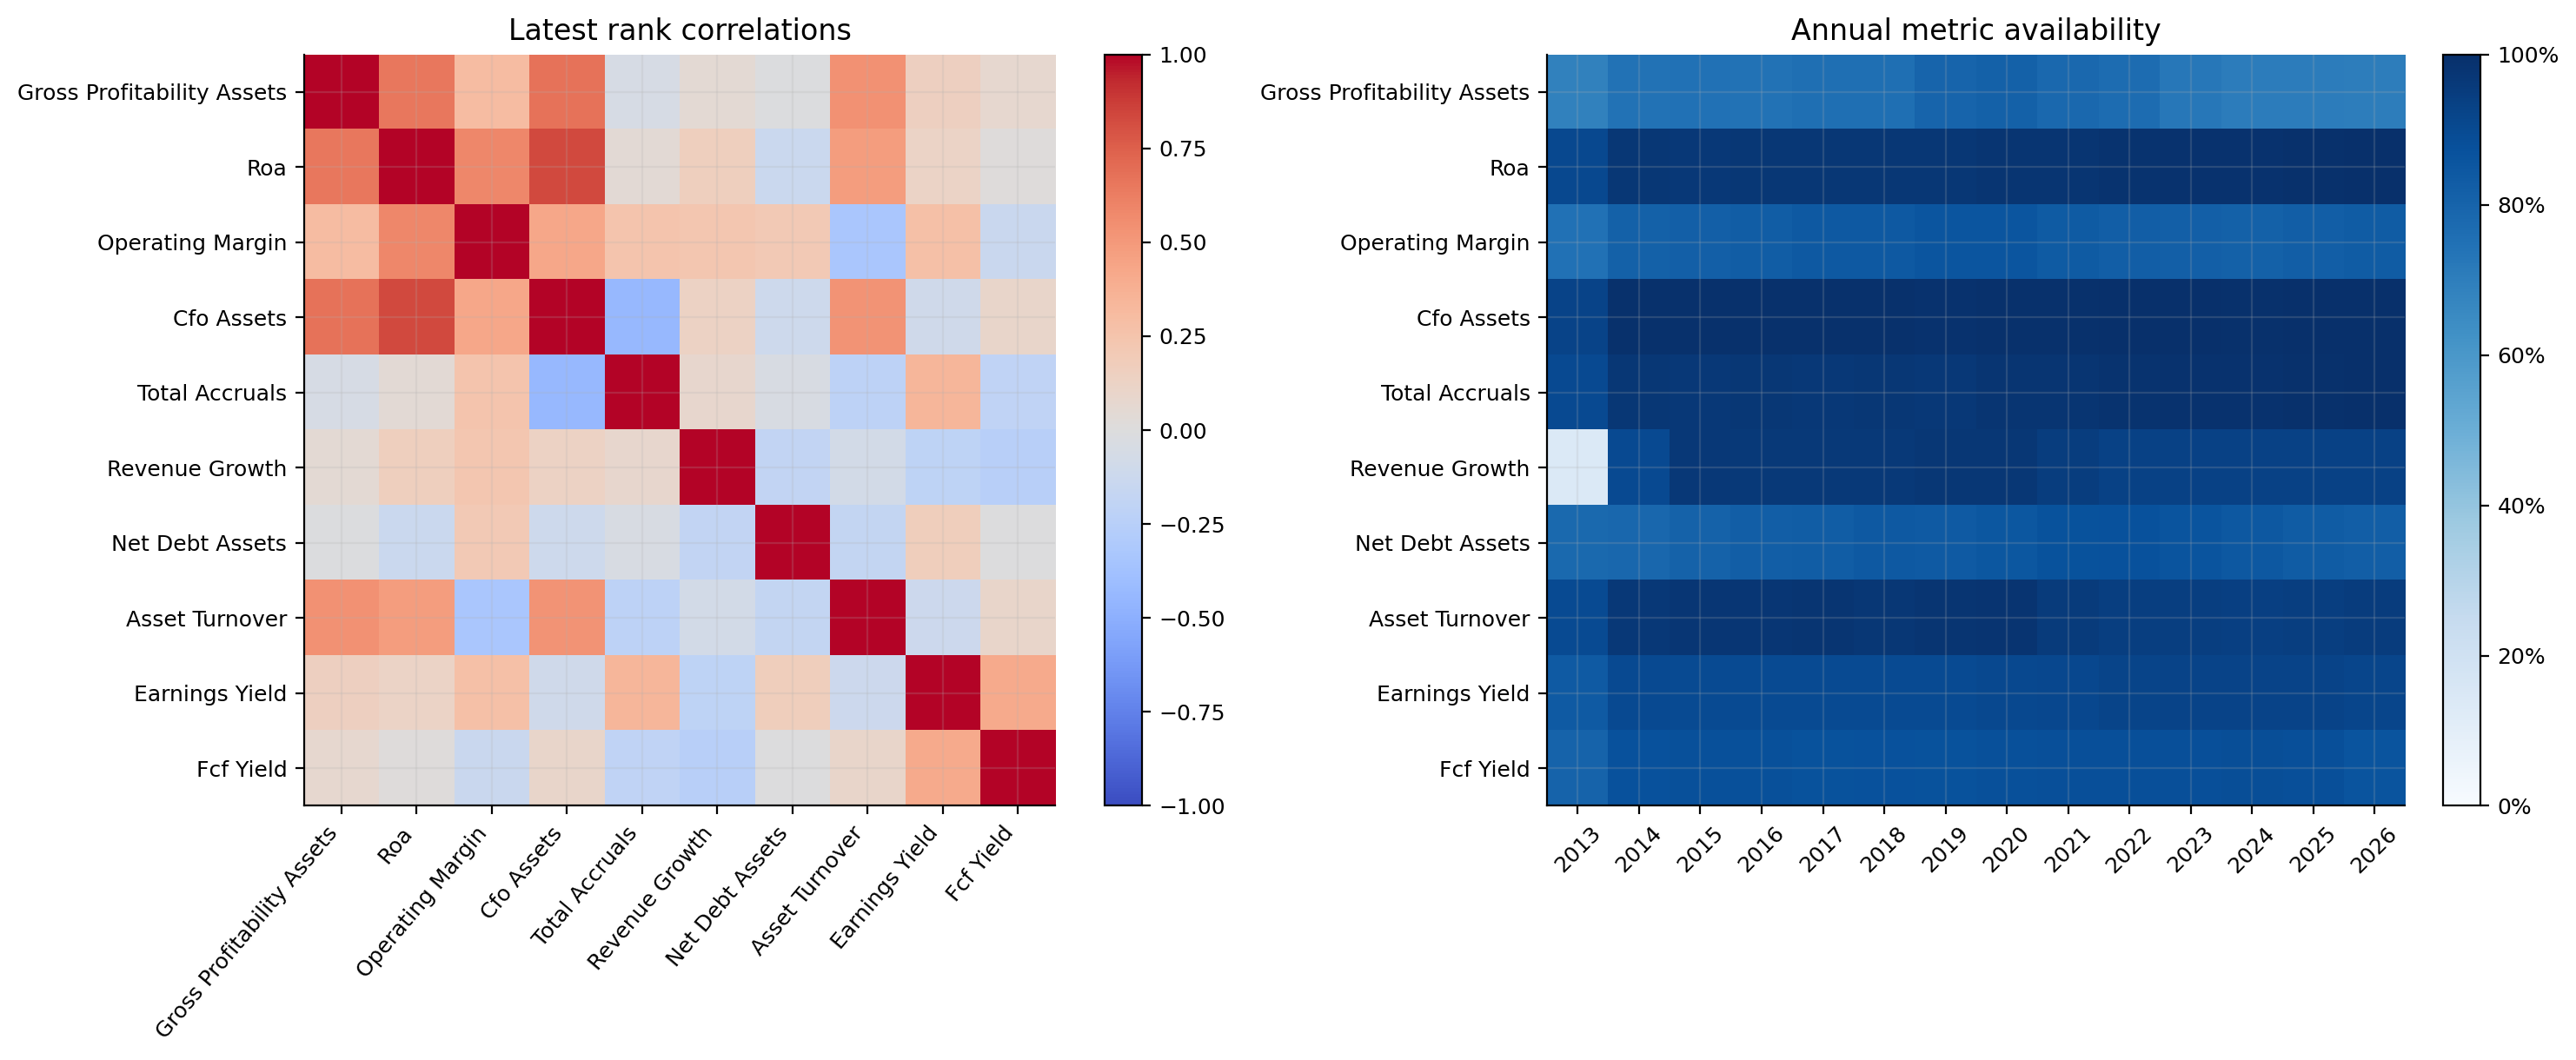

In [37]:
diagnostic_metrics = [
    "gross_profitability_assets", "roa", "roe", "roic_proxy", "operating_margin",
    "cfo_assets", "fcf_assets", "cfo_net_income", "total_accruals",
    "revenue_growth", "operating_income_growth", "cfo_growth", "eps_growth",
    "net_debt_assets", "interest_coverage", "current_ratio", "cash_assets",
    "asset_turnover", "receivable_turnover", "inventory_turnover",
    "net_shareholder_yield", "share_count_dilution", "earnings_yield", "fcf_yield",
    "book_to_market", "ebit_ev",
    "fin_roa", "fin_roe", "fin_equity_assets", "fin_assets_equity",
    "fin_bvps_growth", "fin_roa_variability", "fin_operating_expense_ratio",
    "fin_earnings_yield", "fin_book_to_market", "fin_net_payout_yield",
]
diagnostic_metrics = [column for column in diagnostic_metrics if column in fundamental_metrics]
coverage_diagnostics = (
    fundamental_metrics.assign(year=fundamental_metrics["decision_date"].dt.year)
    .groupby(["year", "score_family"])[diagnostic_metrics]
    .agg(lambda values: values.notna().mean())
)
latest_metrics = fundamental_metrics[
    fundamental_metrics["decision_date"].eq(fundamental_metrics["decision_date"].max())
]
distribution_summary = latest_metrics[diagnostic_metrics].describe(
    percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]
).T
peer_medians = latest_metrics.groupby("score_family")[diagnostic_metrics].median().T

corr_columns = [
    column for column in [
        "gross_profitability_assets", "roa", "operating_margin", "cfo_assets",
        "total_accruals", "revenue_growth", "net_debt_assets",
        "asset_turnover", "earnings_yield", "fcf_yield",
    ] if latest_metrics[column].notna().sum() >= 30
]
corr = latest_metrics[corr_columns].corr(method="spearman")
coverage_plot = (
    fundamental_metrics[
        fundamental_metrics["score_family"].eq("corporate")
        & fundamental_metrics["decision_date"].dt.year.ge(2013)
    ]
    .assign(year=lambda frame: frame["decision_date"].dt.year)
    .groupby("year")[corr_columns]
    .agg(lambda values: values.notna().mean())
)
fig, axes = plt.subplots(1, 2, figsize=(16, 6.2), gridspec_kw={"width_ratios": [1.3, 1]})
im = axes[0].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
axes[0].set_xticks(range(len(corr_columns)))
axes[0].set_xticklabels([column.replace("_", " ").title() for column in corr_columns], rotation=50, ha="right")
axes[0].set_yticks(range(len(corr_columns)))
axes[0].set_yticklabels([column.replace("_", " ").title() for column in corr_columns])
axes[0].set_title("Latest rank correlations")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
coverage_view = coverage_plot.T
coverage_image = axes[1].imshow(coverage_view, aspect="auto", cmap="Blues", vmin=0, vmax=1)
axes[1].set_yticks(range(len(coverage_view)), [column.replace("_", " ").title() for column in coverage_view.index])
axes[1].set_xticks(range(len(coverage_view.columns)), coverage_view.columns, rotation=45)
axes[1].set_title("Annual metric availability")
fig.colorbar(coverage_image, ax=axes[1], fraction=0.046, pad=0.04, format=lambda value, _: f"{value:.0%}")
plt.tight_layout()
plt.show()

extremes = latest_metrics.nlargest(12, "warning_penalty")[
    ["ticker", "entity_name", "score_family", "industry", "warning_penalty",
     "severe_warning_count", "piotroski_f_score", "altman_z", "beneish_m"]
]

In [38]:
def money(value):
    if pd.isna(value):
        return "—"
    magnitude = abs(float(value))
    if magnitude >= 1e12:
        return f"${value / 1e12:,.2f}T"
    if magnitude >= 1e9:
        return f"${value / 1e9:,.2f}B"
    if magnitude >= 1e6:
        return f"${value / 1e6:,.1f}M"
    return f"${value:,.2f}"


def percentage(value):
    return "—" if pd.isna(value) else f"{value:.1%}"


def clean_label(value):
    return str(value).replace("_", " ").title()


def format_metric(name, value):
    if pd.isna(value):
        return "—"
    if any(token in name for token in [
        "margin", "yield", "growth", "change", "assets", "dilution", "frequency",
    ]):
        return percentage(value)
    if any(token in name for token in [
        "price_", "turnover", "coverage", "ratio", "conversion", "multiplier",
    ]):
        return f"{value:,.2f}×"
    return f"{value:,.3f}"


def peer_table(current, peers, metrics, lower_is_better=()):
    favorable = pd.Series({
        metric: peers[metric].rank(pct=True).get(current.name, np.nan)
        for metric in metrics
    })
    for metric in lower_is_better:
        favorable[metric] = 1.0 - favorable[metric]
    comparison = pd.DataFrame({
        "company": current[metrics],
        "peer 25th percentile": peers[metrics].quantile(0.25),
        "peer median": peers[metrics].median(),
        "peer 75th percentile": peers[metrics].quantile(0.75),
        "favorable percentile": favorable,
    })
    formatted = comparison.astype(object)
    for metric in metrics:
        for column in comparison.columns[:-1]:
            formatted.loc[metric, column] = format_metric(metric, comparison.loc[metric, column])
        formatted.loc[metric, "favorable percentile"] = percentage(
            comparison.loc[metric, "favorable percentile"]
        )
    return comparison, formatted


def report_style(frame, caption):
    return (
        frame.rename(index=clean_label, columns=clean_label).style
        .set_caption(caption)
        .set_properties(**{"text-align": "right"})
        .set_table_styles([
            {"selector": "caption", "props": "caption-side: top; font-weight: 600; text-align: left;"},
            {"selector": "th", "props": "text-align: left;"},
        ])
    )


def company_snapshot(current):
    return pd.DataFrame({
        "value": [
            money(current["price"]), money(current["market_cap"]),
            money(current["enterprise_value"]), current["filed_date"].date(),
            current["latest_period_end"].date(), current["industry"],
        ]
    }, index=[
        "price", "market cap", "enterprise value", "latest filing date",
        "latest period end", "industry",
    ])


def financial_snapshot(current):
    return pd.DataFrame({
        "value": [
            money(current["revenue"]), money(current["operating_income"]),
            money(current["net_income"]), money(current["cfo"]),
            money(current["free_cash_flow"]), money(current["total_assets"]),
            money(current["total_debt"]), money(current["common_equity"]),
        ]
    }, index=[
        "revenue TTM", "operating income TTM", "net income TTM", "CFO TTM",
        "FCF TTM", "assets", "debt", "equity",
    ])


def corporate_report(ticker):
    company = fundamental_metrics[
        fundamental_metrics["ticker"].eq(ticker)
    ].sort_values("decision_date")
    current = company.iloc[-1]
    history = (
        company.dropna(subset=["latest_quarter_end"])
        .drop_duplicates("latest_quarter_end", keep="last")
        .tail(12).set_index("latest_quarter_end")
    )
    cross_section = fundamental_metrics[
        fundamental_metrics["decision_date"].eq(current["decision_date"])
        & fundamental_metrics["score_family"].eq("corporate")
    ]
    industry = cross_section[cross_section["industry"].eq(current["industry"])]
    peers = industry if len(industry) >= 10 else cross_section
    metrics = [
        "operating_margin", "roa", "cfo_assets", "revenue_growth",
        "net_debt_assets", "earnings_yield", "fcf_yield", "net_shareholder_yield",
    ]
    comparison, comparison_display = peer_table(
        current, peers, metrics, lower_is_better=("net_debt_assets",)
    )
    display(report_style(
        company_snapshot(current),
        f"{ticker} · {current['entity_name']} · snapshot",
    ))
    display(report_style(
        financial_snapshot(current),
        f"{ticker} · trailing-twelve-month financial summary",
    ))
    display(report_style(
        comparison_display,
        f"{ticker} · {current['industry']} peers · n={len(peers)}",
    ))

    warning_columns = [
        column for column in warning_penalties
        if column.startswith("warning_") and not column.startswith("warning_fin_")
    ]
    active_warnings = [
        clean_label(column.replace("warning_", ""))
        for column in warning_columns
        if pd.notna(current[column]) and bool(current[column])
    ]
    diagnostics = pd.DataFrame({
        "value": [
            current["piotroski_f_score"], current["altman_z"], current["beneish_m"],
            int(current["warning_penalty"]),
            ", ".join(active_warnings) if active_warnings else "None",
        ]
    }, index=[
        "Piotroski F-score", "Altman Z-score", "Beneish M-score",
        "weighted red-flag points", "active red flags",
    ])
    display(report_style(diagnostics, f"{ticker} · traditional diagnostics"))

    revenue = history["revenue_q"].div(1e9)
    operating_margin = history["operating_margin"]
    cash = history[["net_income_q", "cfo_q"]].assign(
        free_cash_flow=history["cfo_q"] - history["capex_q"]
    ).div(1e9)
    cash.columns = ["Net income", "Operating cash flow", "Free cash flow"]
    percentile_plot = comparison["favorable percentile"].sort_values()
    quarter_positions = np.arange(len(history))
    quarter_ticks = np.linspace(
        0, len(history) - 1, min(6, len(history))
    ).round().astype(int)
    quarter_labels = [
        history.index[position].strftime("%Y-%m")
        for position in quarter_ticks
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
    axes[0].bar(quarter_positions, revenue, color=blue, width=0.68)
    margin_axis = axes[0].twinx()
    margin_axis.plot(
        quarter_positions, operating_margin,
        color=gold, marker="o", linewidth=2,
    )
    axes[0].set_xticks(
        quarter_ticks, quarter_labels, rotation=45, ha="right"
    )
    axes[0].set_title(f"{ticker} revenue and operating margin")
    axes[0].set_ylabel("$ billions")
    margin_axis.set_ylabel("Operating margin")
    margin_axis.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
    margin_axis.grid(False)
    cash_positions = quarter_positions
    cash_width = 0.24
    for cash_offset, (cash_name, cash_color) in enumerate(
        zip(cash.columns, [coral, teal, gold])
    ):
        axes[1].bar(
            cash_positions + (cash_offset - 1) * cash_width,
            cash[cash_name],
            width=cash_width,
            color=cash_color,
            label=cash_name,
        )
    axes[1].set_xticks(
        quarter_ticks, quarter_labels, rotation=45, ha="right"
    )
    axes[1].set_title("Net income, CFO, and FCF")
    axes[1].set_ylabel("$ billions")
    axes[1].legend(ncol=1, frameon=False)
    axes[2].hlines(
        range(len(percentile_plot)), 0.5, percentile_plot,
        color=grid, linewidth=4,
    )
    axes[2].scatter(
        percentile_plot, range(len(percentile_plot)),
        s=55, color=np.where(percentile_plot.ge(0.5), teal, coral), zorder=3,
    )
    axes[2].axvline(0.5, color=muted, linestyle="--", linewidth=1)
    axes[2].set_yticks(
        range(len(percentile_plot)),
        [clean_label(value) for value in percentile_plot.index],
    )
    axes[2].set_xlim(0, 1)
    axes[2].xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
    axes[2].set_title("Peer-group percentiles")
    for axis in axes:
        axis.set_xlabel("")
        finish_axes(axis)
    plt.tight_layout()
    plt.show()


def financial_report(ticker):
    company = fundamental_metrics[
        fundamental_metrics["ticker"].eq(ticker)
    ].sort_values("decision_date")
    current = company.iloc[-1]
    history = (
        company.dropna(subset=["latest_quarter_end"])
        .drop_duplicates("latest_quarter_end", keep="last")
        .tail(12).set_index("latest_quarter_end")
    )
    peers = fundamental_metrics[
        fundamental_metrics["decision_date"].eq(current["decision_date"])
        & fundamental_metrics["score_family"].eq("financial")
    ]
    metrics = [
        "fin_roa", "fin_roe", "fin_equity_assets", "fin_assets_equity",
        "fin_bvps_growth", "fin_earnings_yield", "fin_book_to_market",
        "fin_net_payout_yield", "fin_share_dilution",
    ]
    comparison, comparison_display = peer_table(
        current, peers, metrics,
        lower_is_better=("fin_assets_equity", "fin_share_dilution"),
    )
    display(report_style(
        company_snapshot(current),
        f"{ticker} · {current['entity_name']} · snapshot",
    ))
    display(report_style(
        financial_snapshot(current),
        f"{ticker} · trailing-twelve-month financial summary",
    ))
    display(report_style(
        comparison_display,
        f"{ticker} · financial peers · n={len(peers)}",
    ))

    warning_columns = [
        column for column in warning_penalties if column.startswith("warning_fin_")
    ]
    active_warnings = [
        clean_label(column.replace("warning_fin_", ""))
        for column in warning_columns
        if pd.notna(current[column]) and bool(current[column])
    ]
    diagnostics = pd.DataFrame({
        "value": [
            int(current["warning_penalty"]),
            ", ".join(active_warnings) if active_warnings else "None",
            percentage(current["fin_net_payout_yield"]),
            percentage(current["fin_share_dilution"]),
        ]
    }, index=[
        "weighted red-flag points", "active red flags",
        "net payout yield", "share dilution",
    ])
    display(report_style(diagnostics, f"{ticker} · financial diagnostics"))

    revenue = history["revenue_q"].div(1e9)
    revenue_label = "Quarterly revenue"
    if revenue.notna().sum() < 3:
        revenue = history["revenue"].div(1e9)
        revenue_label = "TTM revenue"
    if revenue.notna().sum() < 3:
        revenue = history["pretax_income_q"].div(1e9)
        revenue_label = "Quarterly pretax income"
    net_income = history["net_income_q"].div(1e9)
    returns_on_capital = history[["fin_roa", "fin_roe"]].rename(
        columns={"fin_roa": "ROA", "fin_roe": "ROE"}
    )
    book = history[["book_value_per_share", "fin_tangible_bvps"]].rename(
        columns={
            "book_value_per_share": "Book value per share",
            "fin_tangible_bvps": "Tangible book value per share",
        }
    )
    quarter_positions = np.arange(len(history))
    quarter_ticks = np.linspace(
        0, len(history) - 1, min(6, len(history))
    ).round().astype(int)
    quarter_labels = [
        history.index[position].strftime("%Y-%m")
        for position in quarter_ticks
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
    axes[0].bar(quarter_positions, revenue, color=blue, width=0.68)
    income_axis = axes[0].twinx()
    income_axis.plot(
        quarter_positions, net_income,
        color=gold, marker="o", linewidth=2,
    )
    axes[0].set_xticks(
        quarter_ticks, quarter_labels, rotation=45, ha="right"
    )
    axes[0].set_title(f"{ticker} {revenue_label.lower()} and net income")
    axes[0].set_ylabel(f"{revenue_label} · $ billions")
    income_axis.set_ylabel("Quarterly net income · $ billions")
    income_axis.grid(False)
    for name, color in zip(returns_on_capital, [teal, gold]):
        axes[1].plot(
            quarter_positions, returns_on_capital[name],
            color=color, linewidth=2.1, marker="o", markersize=3,
            label=name,
        )
    axes[1].set_xticks(
        quarter_ticks, quarter_labels, rotation=45, ha="right"
    )
    axes[1].set_title("ROA and ROE")
    axes[1].yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
    axes[1].legend(frameon=False)
    for name, color in zip(book, [blue, violet]):
        axes[2].plot(
            quarter_positions, book[name],
            color=color, linewidth=2.1, marker="o", markersize=3,
            label=name,
        )
    axes[2].set_xticks(
        quarter_ticks, quarter_labels, rotation=45, ha="right"
    )
    axes[2].set_title("Book and tangible-book value per share")
    axes[2].set_ylabel("$ per share")
    axes[2].legend(frameon=False)
    for axis in axes:
        axis.set_xlabel("")
        finish_axes(axis)
    plt.tight_layout()
    plt.show()


,Value
Price,$308.91
Market Cap,$4.54T
Enterprise Value,$4.57T
Latest Filing Date,2026-05-01
Latest Period End,2026-04-17
Industry,ELECTRONIC COMPUTERS


,Value
Revenue Ttm,$451.44B
Operating Income Ttm,$147.37B
Net Income Ttm,$122.58B
Cfo Ttm,$140.22B
Fcf Ttm,$129.17B
Assets,$371.08B
Debt,$82.71B
Equity,$106.49B


,Company,Peer 25Th Percentile,Peer Median,Peer 75Th Percentile,Favorable Percentile
Operating Margin,32.6%,10.2%,17.9%,25.5%,87.7%
Roa,0.327,0.036,0.071,0.118,98.2%
Cfo Assets,37.4%,7.6%,11.5%,17.6%,98.5%
Revenue Growth,12.8%,3.9%,7.9%,14.2%,72.3%
Net Debt Assets,10.0%,11.9%,22.6%,34.4%,78.2%
Earnings Yield,2.7%,2.5%,3.6%,5.2%,29.8%
Fcf Yield,2.8%,2.4%,3.8%,5.7%,32.7%
Net Shareholder Yield,—,2.2%,3.6%,5.2%,—


,Value
Piotroski F-Score,9.000000
Altman Z-Score,12.892823
Beneish M-Score,-2.522874
Weighted Red-Flag Points,0
Active Red Flags,None


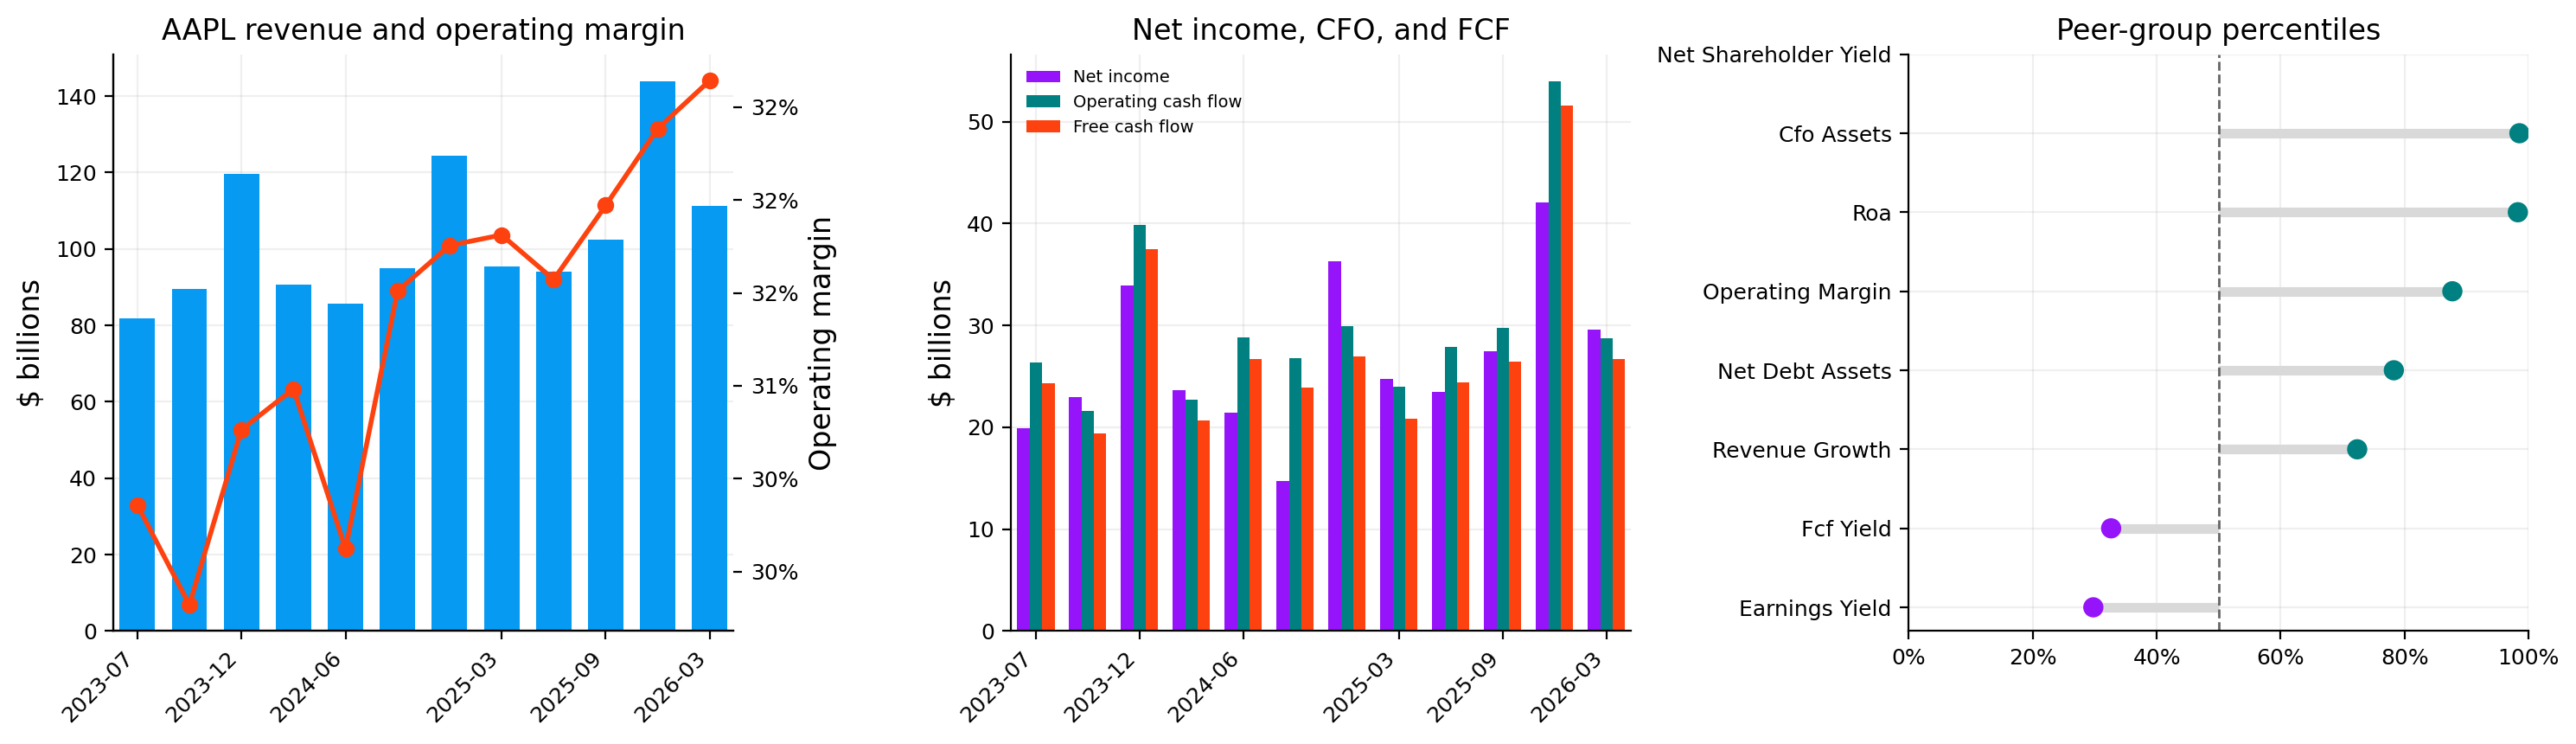

In [39]:
corporate_report("AAPL")


,Value
Price,$356.65
Market Cap,$4.36T
Enterprise Value,$4.32T
Latest Filing Date,2026-07-23
Latest Period End,2026-06-30
Industry,"SERVICES-COMPUTER PROGRAMMING, DATA PROCESSING, ETC."


,Value
Revenue Ttm,$445.87B
Operating Income Ttm,$147.63B
Net Income Ttm,$244.21B
Cfo Ttm,$185.68B
Fcf Ttm,$53.27B
Assets,$921.98B
Debt,$10.89B
Equity,$640.48B


,Company,Peer 25Th Percentile,Peer Median,Peer 75Th Percentile,Favorable Percentile
Operating Margin,33.1%,10.2%,17.9%,25.5%,88.3%
Roa,0.300,0.036,0.071,0.118,97.8%
Cfo Assets,22.8%,7.6%,11.5%,17.6%,90.0%
Revenue Growth,20.1%,3.9%,7.9%,14.2%,85.6%
Net Debt Assets,-4.9%,11.9%,22.6%,34.4%,93.4%
Earnings Yield,5.6%,2.5%,3.6%,5.2%,80.6%
Fcf Yield,1.2%,2.4%,3.8%,5.7%,15.5%
Net Shareholder Yield,—,2.2%,3.6%,5.2%,—


,Value
Piotroski F-Score,6.000000
Altman Z-Score,11.341004
Beneish M-Score,-1.719430
Weighted Red-Flag Points,5
Active Red Flags,Beneish Warning


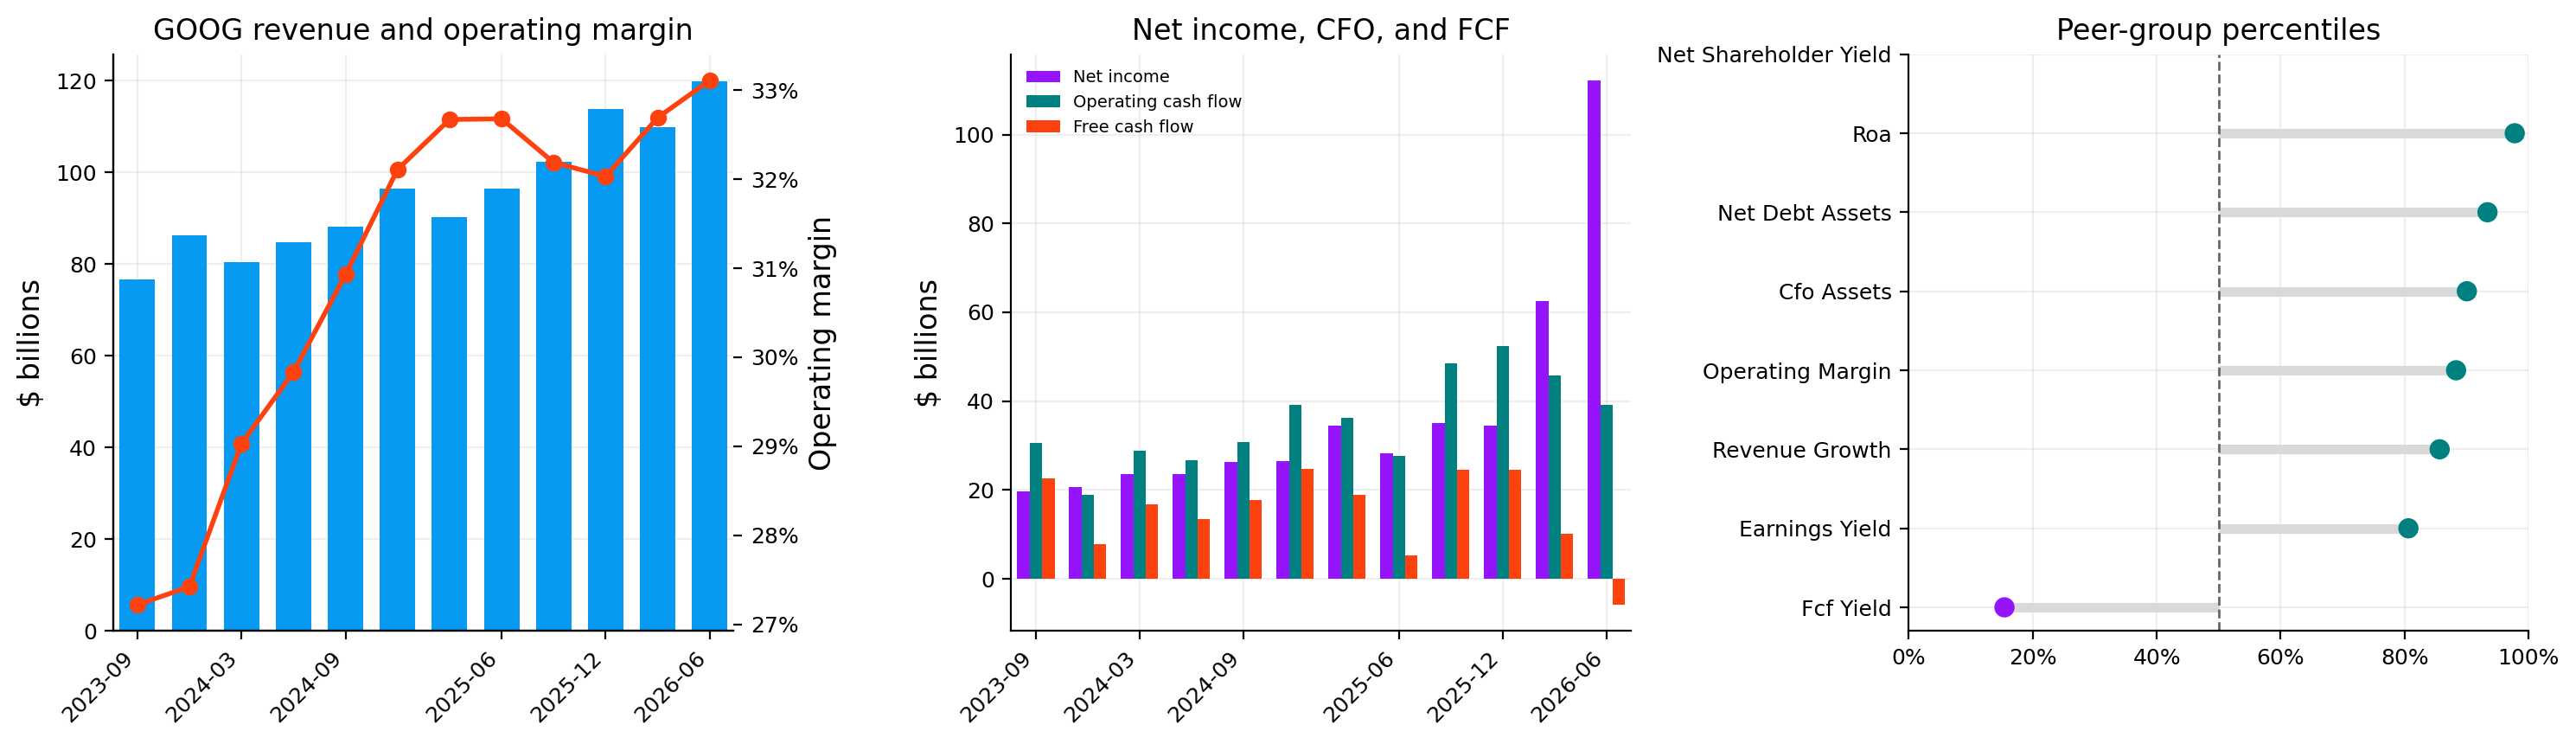

In [40]:
corporate_report("GOOG")


,Value
Price,"$1,148.84"
Market Cap,$1.08T
Enterprise Value,$1.12T
Latest Filing Date,2026-04-30
Latest Period End,2026-04-27
Industry,PHARMACEUTICAL PREPARATIONS


,Value
Revenue Ttm,$72.25B
Operating Income Ttm,—
Net Income Ttm,$25.28B
Cfo Ttm,$20.48B
Fcf Ttm,—
Assets,$116.58B
Debt,$43.37B
Equity,$31.20B


,Company,Peer 25Th Percentile,Peer Median,Peer 75Th Percentile,Favorable Percentile
Operating Margin,—,17.1%,24.4%,24.7%,—
Roa,0.221,0.050,0.105,0.137,100.0%
Cfo Assets,17.9%,10.5%,13.7%,16.0%,90.9%
Revenue Growth,47.4%,2.8%,6.6%,9.4%,100.0%
Net Debt Assets,32.7%,30.2%,34.0%,39.3%,55.6%
Earnings Yield,2.3%,2.4%,3.4%,4.8%,30.0%
Fcf Yield,—,4.0%,4.5%,6.9%,—
Net Shareholder Yield,—,2.9%,3.5%,6.3%,—


,Value
Piotroski F-Score,8.000000
Altman Z-Score,nan
Beneish M-Score,-1.773866
Weighted Red-Flag Points,5
Active Red Flags,Beneish Warning


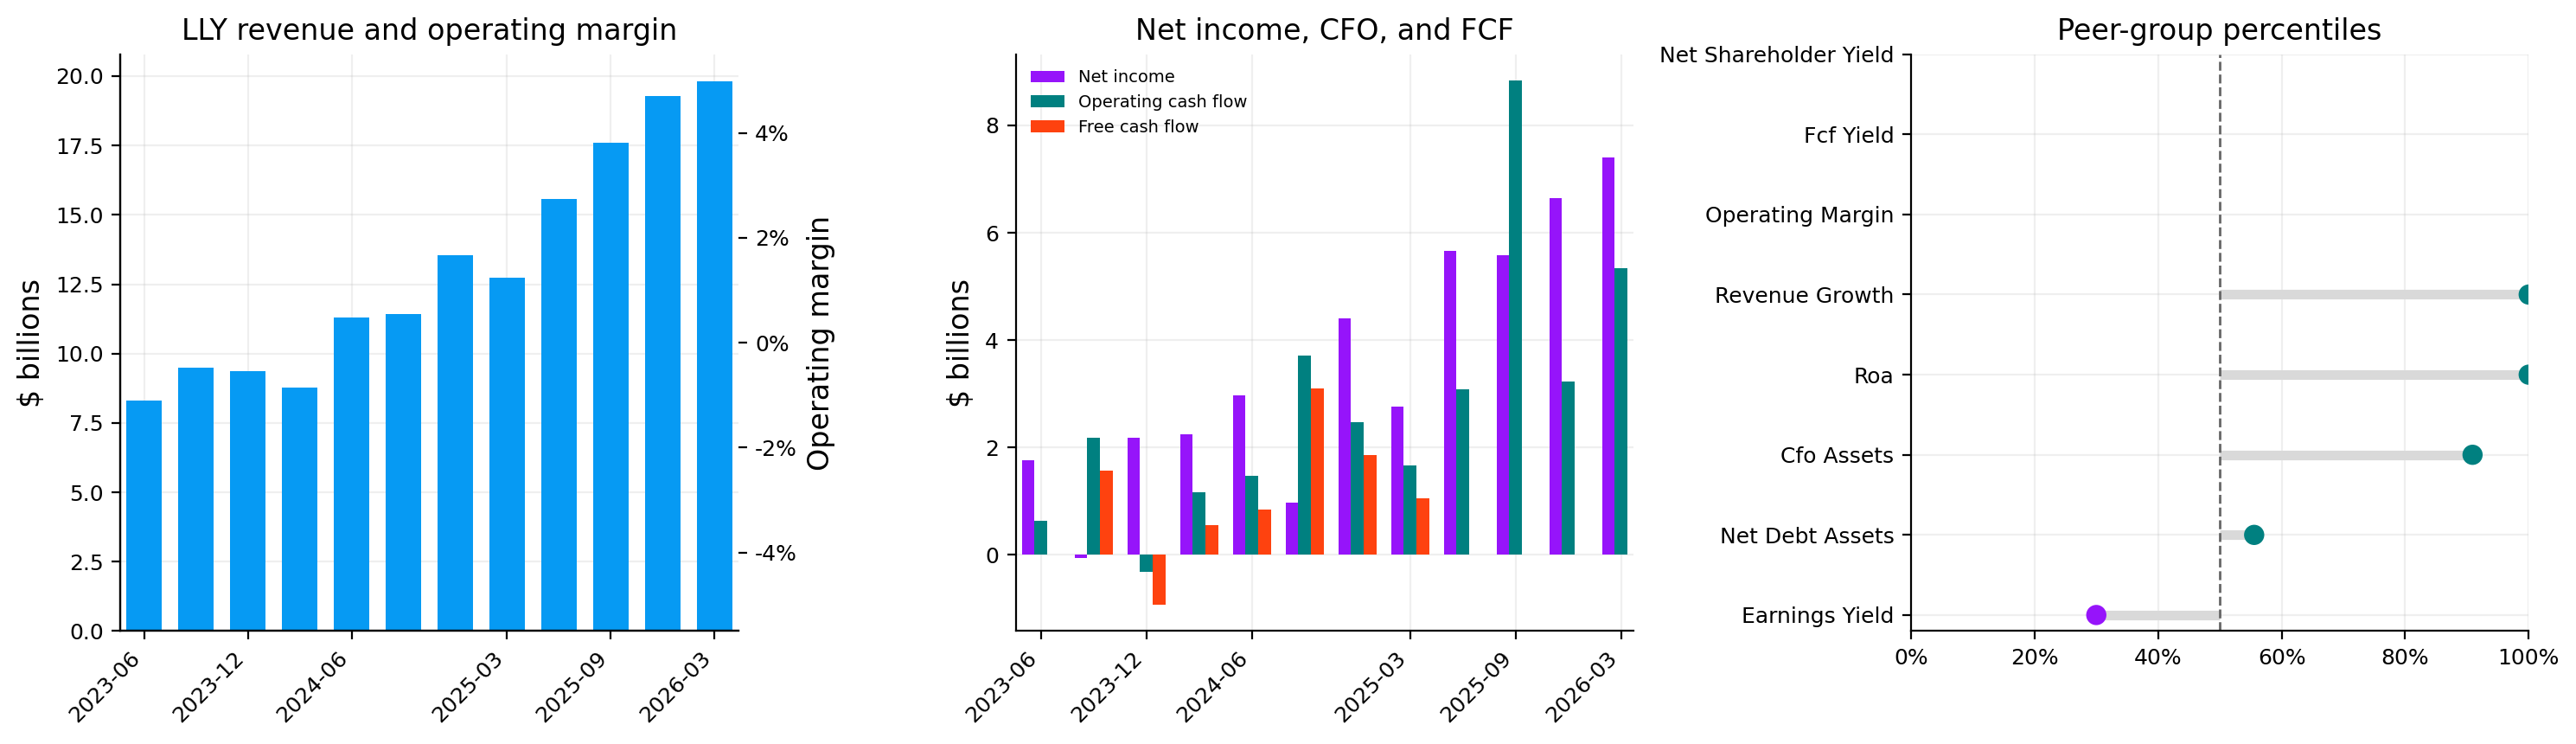

In [41]:
corporate_report("LLY")


,Value
Price,$814.81
Market Cap,$375.33B
Enterprise Value,$407.47B
Latest Filing Date,2026-05-06
Latest Period End,2026-03-31
Industry,CONSTRUCTION MACHINERY & EQUIP


,Value
Revenue Ttm,$70.75B
Operating Income Ttm,$11.66B
Net Income Ttm,$9.43B
Cfo Ttm,$12.32B
Fcf Ttm,$9.48B
Assets,$95.55B
Debt,$36.21B
Equity,—


,Company,Peer 25Th Percentile,Peer Median,Peer 75Th Percentile,Favorable Percentile
Operating Margin,16.5%,10.2%,17.9%,25.5%,43.8%
Roa,0.097,0.036,0.071,0.118,64.2%
Cfo Assets,12.7%,7.6%,11.5%,17.6%,56.9%
Revenue Growth,11.8%,3.9%,7.9%,14.2%,68.6%
Net Debt Assets,33.6%,11.9%,22.6%,34.4%,26.6%
Earnings Yield,2.5%,2.5%,3.6%,5.2%,26.0%
Fcf Yield,2.5%,2.4%,3.8%,5.7%,28.0%
Net Shareholder Yield,—,2.2%,3.6%,5.2%,—


,Value
Piotroski F-Score,5.000000
Altman Z-Score,5.227309
Beneish M-Score,-2.334820
Weighted Red-Flag Points,0
Active Red Flags,None


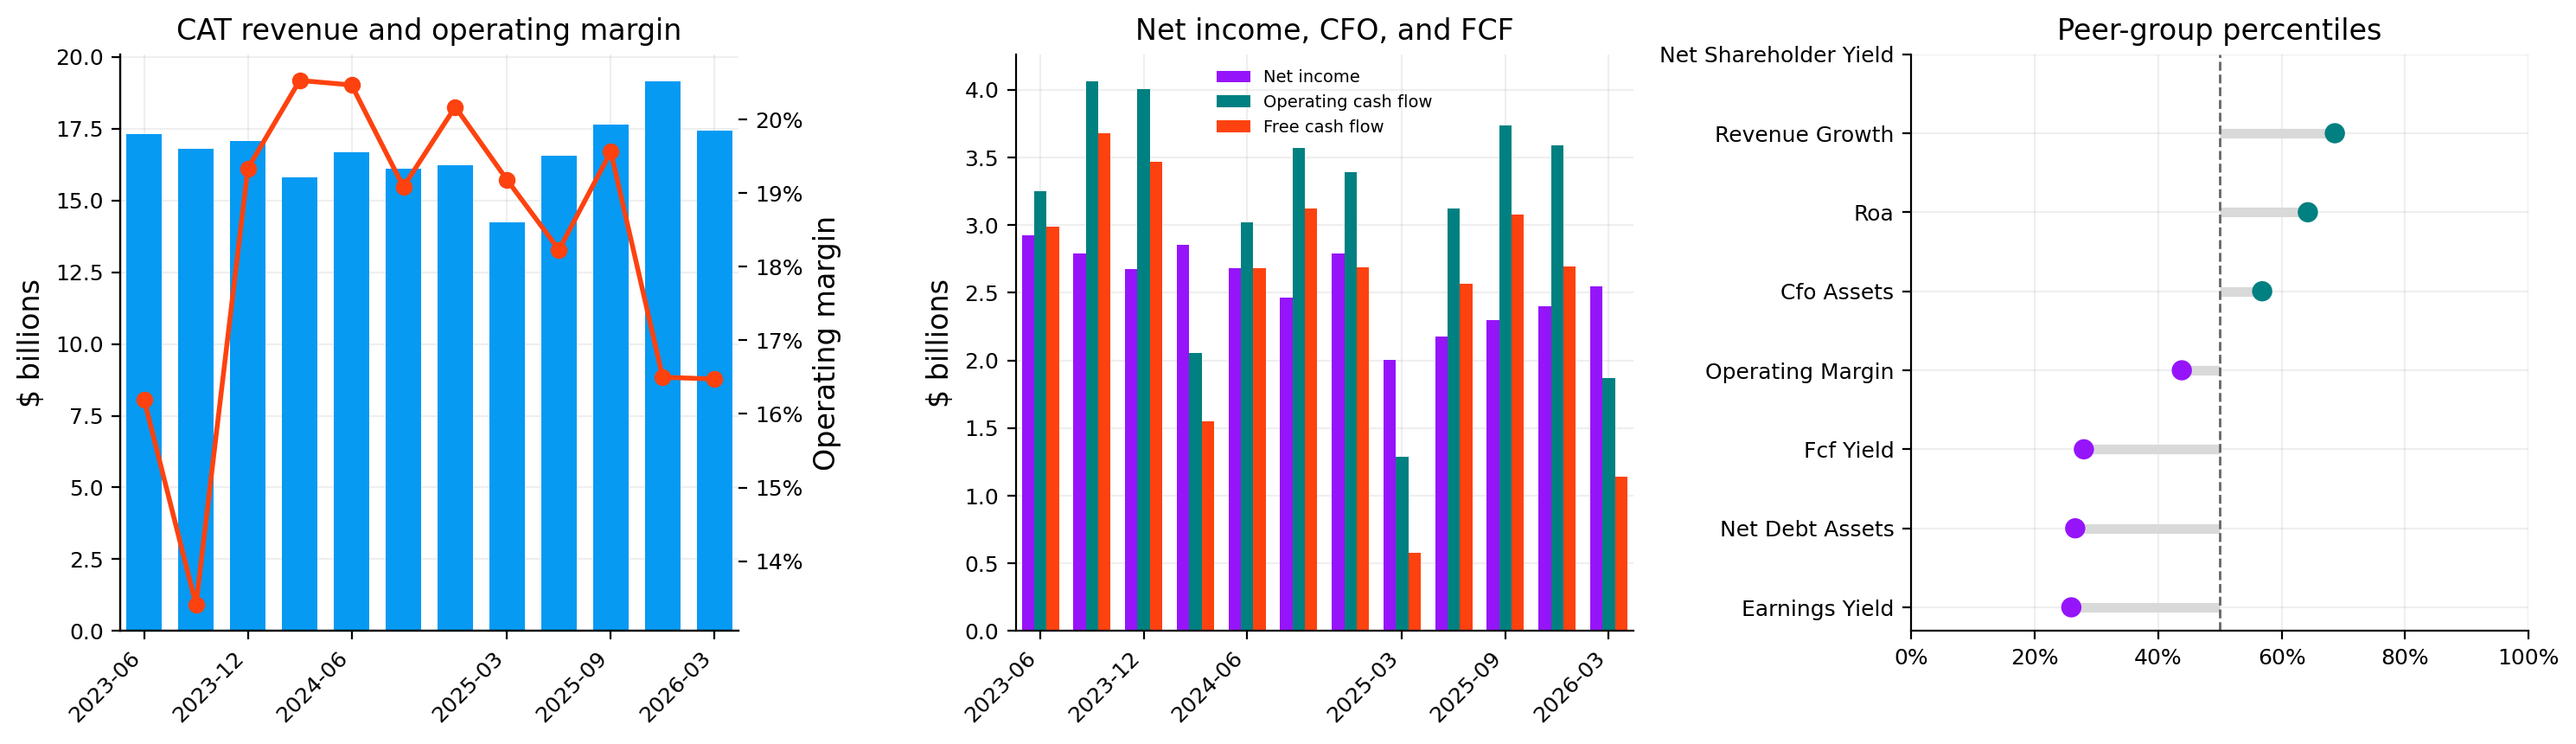

In [42]:
corporate_report("CAT")


,Value
Price,$351.79
Market Cap,$942.63B
Enterprise Value,—
Latest Filing Date,2026-05-01
Latest Period End,2026-03-31
Industry,NATIONAL COMMERCIAL BANKS


,Value
Revenue Ttm,$182.45B
Operating Income Ttm,—
Net Income Ttm,$58.90B
Cfo Ttm,$-107.70B
Fcf Ttm,—
Assets,$4.90T
Debt,—
Equity,$364.04B


,Company,Peer 25Th Percentile,Peer Median,Peer 75Th Percentile,Favorable Percentile
Fin Roa,0.013,0.010,0.022,0.041,35.3%
Fin Roe,0.162,0.097,0.141,0.199,62.1%
Fin Equity Assets,7.4%,9.5%,16.4%,26.6%,16.7%
Fin Assets Equity,1346.1%,375.3%,608.9%,1049.7%,15.2%
Fin Bvps Growth,7.4%,6.2%,8.8%,14.0%,42.1%
Fin Earnings Yield,6.2%,4.4%,6.4%,8.2%,45.9%
Fin Book To Market,0.386,0.345,0.465,0.689,33.9%
Fin Net Payout Yield,—,3.8%,5.4%,6.2%,—
Fin Share Dilution,-3.6%,-4.6%,-2.5%,-0.3%,61.0%


,Value
Weighted Red-Flag Points,0
Active Red Flags,None
Net Payout Yield,—
Share Dilution,-3.6%


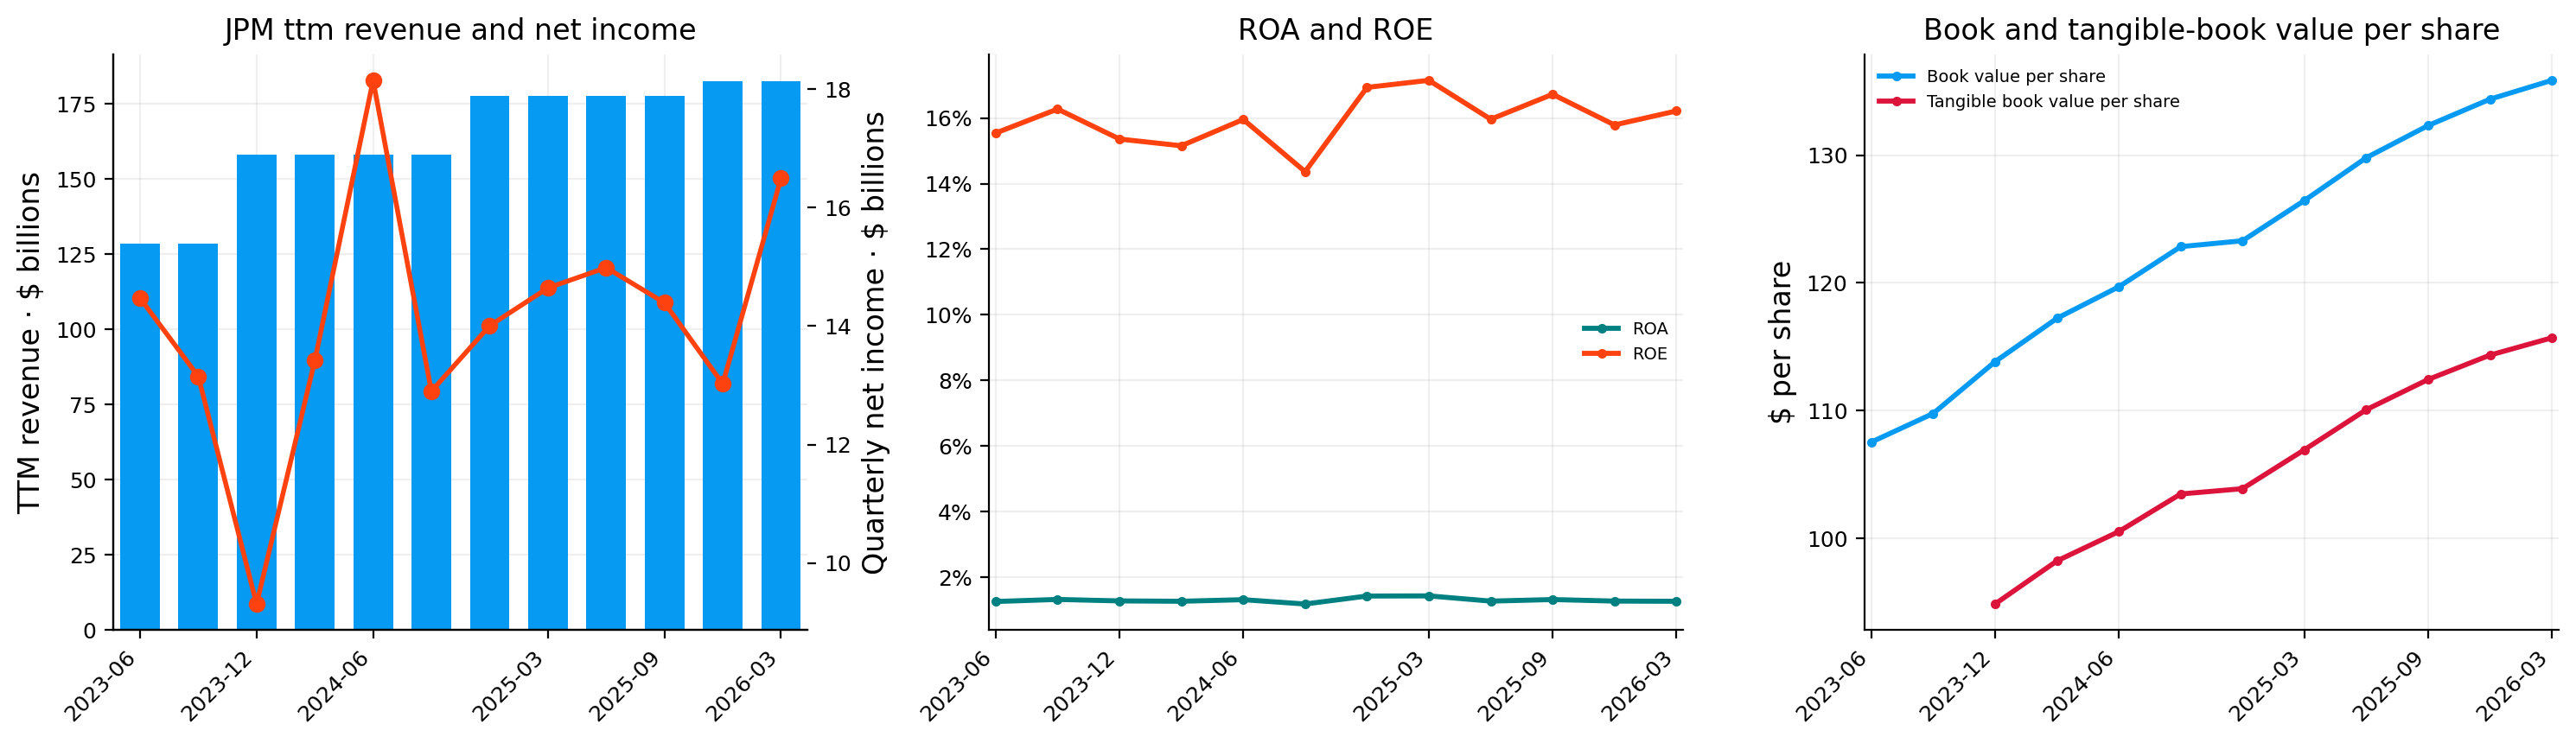

In [43]:
financial_report("JPM")


,Value
Price,"$1,018.38"
Market Cap,$300.43B
Enterprise Value,—
Latest Filing Date,2026-05-01
Latest Period End,2026-04-17
Industry,"SECURITY BROKERS, DEALERS & FLOTATION COMPANIES"


,Value
Revenue Ttm,—
Operating Income Ttm,—
Net Income Ttm,$18.07B
Cfo Ttm,$-39.79B
Fcf Ttm,$-41.92B
Assets,$2.06T
Debt,—
Equity,$122.78B


,Company,Peer 25Th Percentile,Peer Median,Peer 75Th Percentile,Favorable Percentile
Fin Roa,0.009,0.010,0.022,0.041,23.5%
Fin Roe,0.146,0.097,0.141,0.199,51.5%
Fin Equity Assets,6.0%,9.5%,16.4%,26.6%,10.6%
Fin Assets Equity,1677.9%,375.3%,608.9%,1049.7%,9.1%
Fin Bvps Growth,2.7%,6.2%,8.8%,14.0%,12.3%
Fin Earnings Yield,6.0%,4.4%,6.4%,8.2%,41.0%
Fin Book To Market,0.409,0.345,0.465,0.689,37.3%
Fin Net Payout Yield,—,3.8%,5.4%,6.2%,—
Fin Share Dilution,-3.9%,-4.6%,-2.5%,-0.3%,67.8%


,Value
Weighted Red-Flag Points,0
Active Red Flags,None
Net Payout Yield,—
Share Dilution,-3.9%


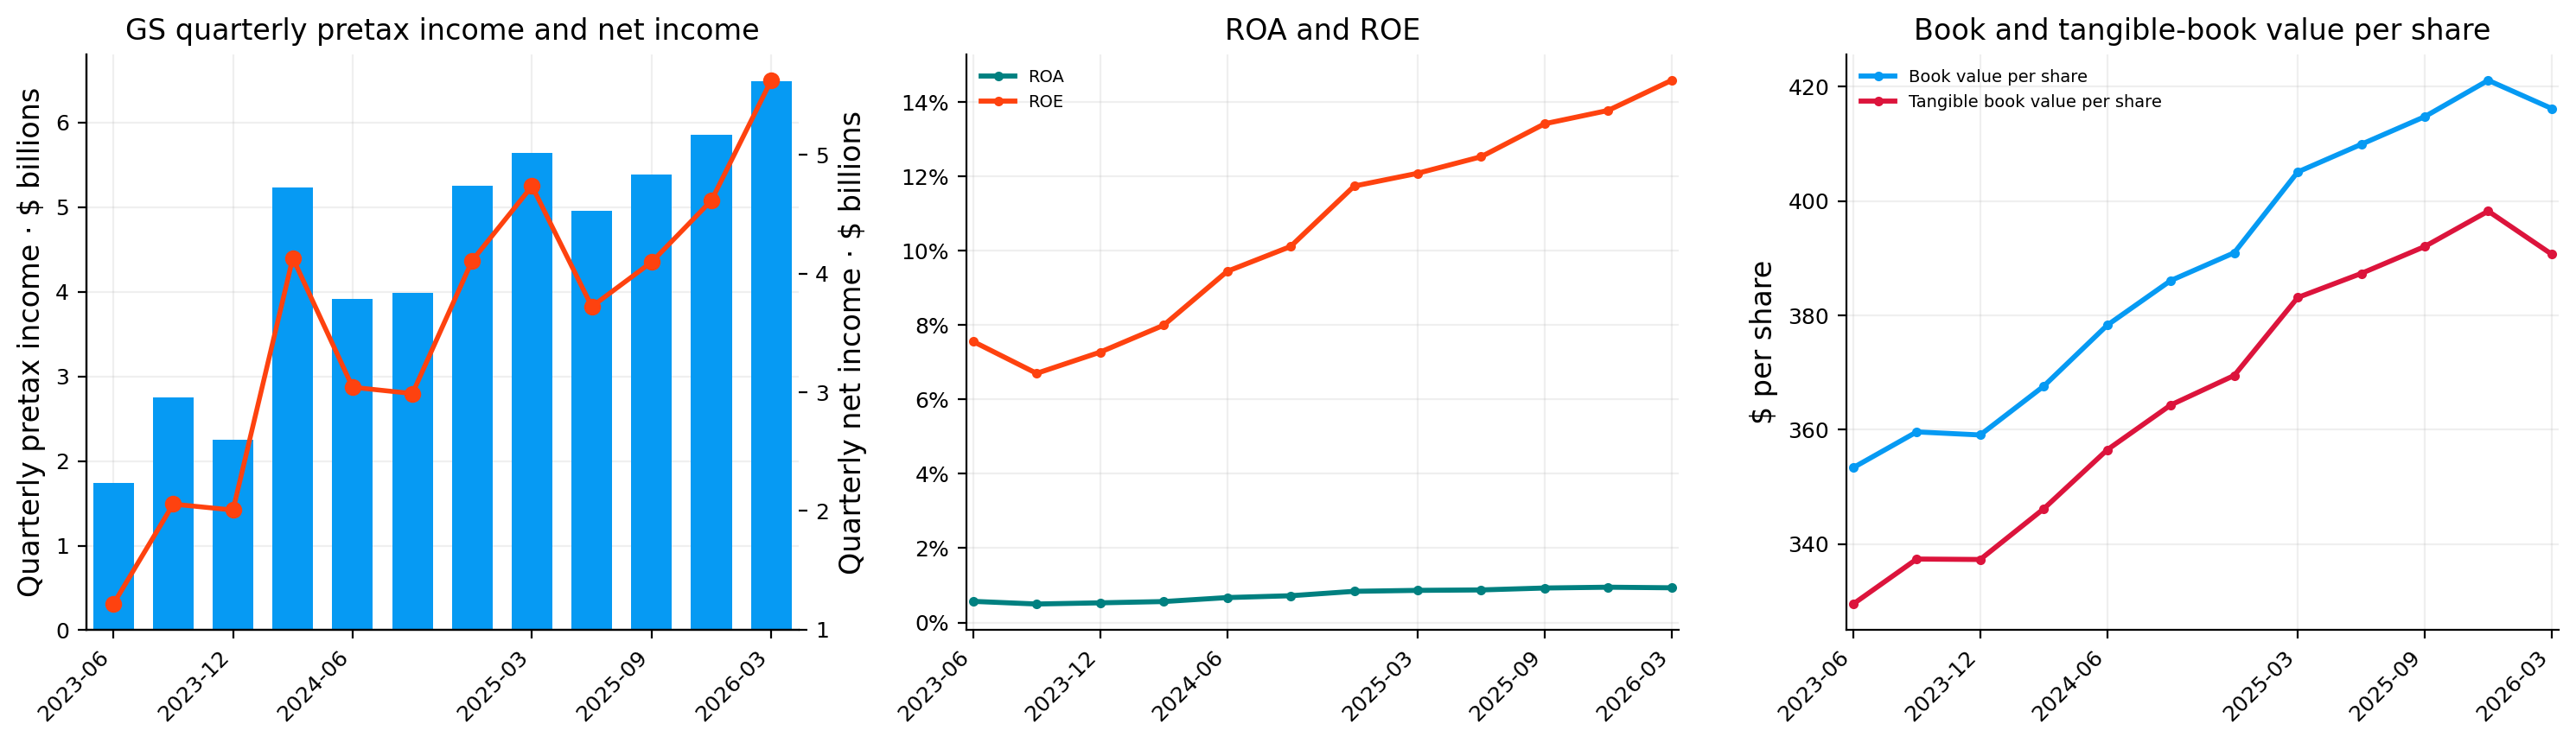

In [44]:
financial_report("GS")


In [45]:
corporate_blocks = {
    "profitability": {
        "gross_profitability_assets": 1.0, "roa": 1.0, "roe": 0.8,
        "roic_proxy": 1.0, "operating_margin": 0.8, "fcf_margin": 0.8,
    },
    "cash_quality": {
        "cfo_assets": 1.0, "fcf_assets": 1.0, "cfo_net_income": 0.8,
        "fcf_conversion": 0.8, "total_accruals": 1.0,
        "positive_cfo_frequency": 0.7, "positive_fcf_frequency": 0.7,
    },
    "growth": {
        "revenue_growth": 1.0, "gross_profit_growth": 0.7,
        "operating_income_growth": 0.8, "cfo_growth": 0.8, "fcf_growth": 0.8,
        "eps_growth": 0.8, "operating_margin_change": 0.7,
        "roa_change": 0.7, "roic_change": 0.7, "cash_conversion_change": 0.5,
    },
    "strength": {
        "net_debt_assets": 1.0, "debt_assets": 0.8, "liabilities_assets": 0.8,
        "interest_coverage": 0.8, "cfo_debt": 0.8, "current_ratio": 0.6,
        "cash_assets": 0.7, "tangible_equity_assets": 0.8,
    },
    "efficiency": {
        "asset_turnover": 1.0, "receivable_turnover": 0.7,
        "inventory_turnover": 0.7, "cash_conversion_cycle": 0.7,
    },
    "capital_allocation": {
        "net_shareholder_yield": 1.0, "share_count_dilution": 1.0,
        "dividend_coverage_cfo": 0.6, "repurchase_yield": 0.7,
        "per_share_growth_spread": 0.7,
    },
    "valuation": {
        "earnings_yield": 1.0, "fcf_yield": 1.0, "ebit_ev": 0.9,
        "sales_ev": 0.6, "book_to_market": 0.7, "tangible_book_to_market": 0.6,
    },
}
corporate_block_weights = {
    "profitability": 0.35, "cash_quality": 0.20, "growth": 0.15,
    "strength": 0.10, "efficiency": 0.05, "capital_allocation": 0.05,
    "valuation": 0.10,
}
financial_blocks = {
    "profitability": {
        "fin_roa": 1.0, "fin_roe": 1.0, "fin_pretax_assets": 0.8, "fin_net_margin": 0.6,
    },
    "capital_strength": {
        "fin_equity_assets": 1.0, "fin_tangible_equity_assets": 1.0,
        "fin_liabilities_assets": 0.8, "fin_assets_equity": 0.8,
    },
    "growth": {
        "fin_revenue_growth": 0.8, "fin_net_income_growth": 0.8,
        "fin_equity_growth": 0.8, "fin_bvps_growth": 1.0, "fin_tbvps_growth": 0.8,
        "fin_roa_change": 0.7, "fin_roe_change": 0.7, "fin_equity_assets_change": 0.8,
    },
    "stability": {
        "fin_roa_variability": 1.0, "fin_roe_variability": 0.8,
        "fin_net_income_variability": 0.8, "fin_positive_earnings_frequency": 1.0,
    },
    "efficiency": {
        "fin_operating_expense_ratio": 1.0, "fin_pretax_margin": 0.8,
        "fin_revenue_assets": 0.8,
    },
    "valuation_return": {
        "fin_earnings_yield": 1.0, "fin_book_to_market": 1.0,
        "fin_tangible_book_to_market": 0.8, "fin_revenue_market_cap": 0.6,
        "fin_net_payout_yield": 0.8, "fin_share_dilution": 0.8,
    },
}
financial_block_weights = {
    "profitability": 0.20, "capital_strength": 0.15, "growth": 0.05,
    "stability": 0.15, "efficiency": 0.15, "valuation_return": 0.30,
}
lower_is_better = {
    "total_accruals", "net_debt_assets", "debt_assets", "liabilities_assets",
    "cash_conversion_cycle", "share_count_dilution",
    "fin_liabilities_assets", "fin_assets_equity", "fin_roa_variability",
    "fin_roe_variability", "fin_net_income_variability",
    "fin_operating_expense_ratio", "fin_share_dilution",
}
all_score_metrics = sorted({
    metric for block in list(corporate_blocks.values()) + list(financial_blocks.values())
    for metric in block
})
metric_directions = {metric: (-1 if metric in lower_is_better else 1) for metric in all_score_metrics}
min_peer_size = 10
min_corporate_metrics = 12
min_financial_metrics = 8
score_metric_coverage = fundamental_metrics.groupby("score_family")[all_score_metrics].agg(
    lambda values: values.notna().mean()
).T
display(score_metric_coverage.style.format("{:.1%}"))


score_family,corporate,financial,unclassified
asset_turnover,91.1%,78.1%,0.0%
book_to_market,85.8%,89.8%,0.0%
cash_assets,97.6%,82.3%,0.0%
cash_conversion_change,73.8%,79.2%,0.0%
cash_conversion_cycle,35.6%,0.0%,0.0%
cfo_assets,94.3%,93.2%,0.0%
cfo_debt,79.0%,30.4%,0.0%
cfo_growth,84.4%,80.8%,0.0%
cfo_net_income,86.3%,90.0%,0.0%
current_ratio,95.9%,20.5%,0.0%


In [46]:
ranked_fundamentals = fundamental_metrics.copy()
raw_metrics = ranked_fundamentals[all_score_metrics].apply(
    pd.to_numeric, errors="coerce"
)
family_groups = [
    ranked_fundamentals["decision_date"],
    ranked_fundamentals["score_family"],
]
peer_groups = family_groups + [ranked_fundamentals["industry"]]

family_metric_groups = raw_metrics.groupby(family_groups, sort=False)
family_count = family_metric_groups.transform("count")
lower = family_metric_groups.transform("quantile", q=0.01)
upper = family_metric_groups.transform("quantile", q=0.99)
clipped = raw_metrics.clip(lower=lower, upper=upper).where(
    family_count.ge(20), raw_metrics
)
family_percentile = clipped.groupby(
    family_groups, sort=False
).rank(pct=True)
peer_metric_groups = clipped.groupby(peer_groups, sort=False)
peer_count = peer_metric_groups.transform("count")
peer_percentile = peer_metric_groups.rank(pct=True).where(
    peer_count.ge(min_peer_size)
)
metric_scores = 100.0 * (
    0.70 * peer_percentile + 0.30 * family_percentile
).fillna(family_percentile)
metric_scores = metric_scores.where(family_count.ge(10))
negative_metrics = [
    metric for metric, direction in metric_directions.items()
    if direction < 0
]
metric_scores[negative_metrics] = 100.0 - metric_scores[negative_metrics]
metric_scores = metric_scores.add_suffix("_score")
ranked_fundamentals = pd.concat([
    ranked_fundamentals, metric_scores,
], axis=1)
assert ranked_fundamentals.groupby(
    ["decision_date", "score_family"]
).ngroups > 0
display(metric_scores.describe().T[[
    "count", "mean", "std", "min", "max",
]])


,count,mean,std,min,max
asset_turnover_score,62374.0,53.029401,27.812710,0.654450,100.000000
book_to_market_score,60356.0,49.591379,28.530753,0.666667,100.000000
cash_assets_score,66671.0,51.350381,27.442266,0.625000,100.000000
cash_conversion_change_score,52091.0,50.783837,28.569426,0.671141,100.000000
cash_conversion_cycle_score,21340.0,50.394026,28.799664,0.000000,99.025974
...,...,...,...,...,...
sales_ev_score,44721.0,51.590708,28.901858,0.682594,100.000000
share_count_dilution_score,58819.0,50.643301,28.573684,0.000000,99.333333
tangible_book_to_market_score,49505.0,50.165130,28.977476,0.677966,100.000000
tangible_equity_assets_score,53225.0,50.116083,28.633218,0.666667,100.000000


In [47]:
def score_blocks(frame, blocks, prefix):
    weights = pd.DataFrame(blocks).fillna(0.0)
    metric_values = frame[
        [f"{metric}_score" for metric in weights.index]
    ].copy()
    metric_values.columns = weights.index
    numerator = metric_values.fillna(0.0).dot(weights)
    denominator = metric_values.notna().astype(float).dot(weights)
    scores = numerator.div(denominator).where(denominator.gt(0))
    scores.columns = [
        f"{prefix}_{block}_score" for block in scores.columns
    ]
    return scores


corporate_rows = ranked_fundamentals["score_family"].eq("corporate")
corporate_scores = score_blocks(
    ranked_fundamentals, corporate_blocks, "corporate"
).where(corporate_rows)
ranked_fundamentals = pd.concat([
    ranked_fundamentals, corporate_scores,
], axis=1)
corporate_block_columns = list(corporate_scores)
corporate_block_weights = pd.Series({
    f"corporate_{block}_score": weight
    for block, weight in corporate_block_weights.items()
})
corporate_numerator = ranked_fundamentals[
    corporate_block_columns
].mul(corporate_block_weights, axis=1).sum(axis=1, min_count=1)
corporate_denominator = ranked_fundamentals[
    corporate_block_columns
].notna().mul(corporate_block_weights, axis=1).sum(axis=1)
corporate_metrics = {
    metric for block in corporate_blocks.values() for metric in block
}
corporate_metric_count = ranked_fundamentals[
    [f"{metric}_score" for metric in corporate_metrics]
].notna().sum(axis=1)
corporate_block_count = ranked_fundamentals[
    corporate_block_columns
].notna().sum(axis=1)
corporate_required = (
    corporate_rows
    & corporate_block_count.ge(4)
    & corporate_metric_count.ge(min_corporate_metrics)
    & ranked_fundamentals["corporate_profitability_score"].notna()
    & (
        ranked_fundamentals["corporate_cash_quality_score"].notna()
        | ranked_fundamentals["corporate_strength_score"].notna()
    )
)
ranked_fundamentals["corporate_base_score"] = (
    corporate_numerator / corporate_denominator
).where(corporate_required)
ranked_fundamentals["corporate_valid_metrics"] = corporate_metric_count.where(
    corporate_rows
)
ranked_fundamentals["corporate_valid_blocks"] = corporate_block_count.where(
    corporate_rows
)

display(
    ranked_fundamentals[
        ranked_fundamentals["decision_date"].eq(
            ranked_fundamentals["decision_date"].max()
        ) & corporate_rows
    ][
        [
            "ticker", "corporate_base_score", "corporate_valid_metrics",
            "corporate_valid_blocks",
        ] + corporate_block_columns
    ]
    .sort_values("corporate_base_score", ascending=False).head(20)
    .style.format({
        column: "{:.1f}" for column in [
            "corporate_base_score", "corporate_valid_metrics",
            "corporate_valid_blocks", *corporate_block_columns,
        ]
    }, na_rep="—")
)


,ticker,corporate_base_score,corporate_valid_metrics,corporate_valid_blocks,corporate_profitability_score,corporate_cash_quality_score,corporate_growth_score,corporate_strength_score,corporate_efficiency_score,corporate_capital_allocation_score,corporate_valuation_score
69756,NEM,78.9,32.0,7.0,81.3,67.9,84.1,90.0,55.2,84.9,82.5
69691,VLO,78.5,35.0,7.0,76.3,64.4,88.7,77.6,88.8,90.5,89.0
69861,APP,77.7,29.0,7.0,98.4,71.1,97.5,67.9,43.1,49.8,29.4
69724,DXCM,76.1,36.0,7.0,84.4,79.1,85.0,72.6,41.6,66.1,53.4
69572,MU,76.0,44.0,7.0,94.1,47.3,92.8,87.5,49.6,34.7,66.7
69762,FTNT,75.8,42.0,7.0,93.0,78.7,76.1,78.3,43.3,79.1,21.2
69700,NVDA,75.2,45.0,7.0,98.2,50.6,76.0,79.9,65.7,69.8,44.9
69596,ADBE,74.2,35.0,7.0,94.6,70.9,39.1,47.2,87.6,91.4,74.0
69655,DECK,74.2,36.0,7.0,85.4,64.2,45.7,93.5,75.4,70.1,79.7
69751,MA,73.9,33.0,6.0,94.3,56.5,69.2,52.6,54.2,76.6,—


In [48]:
financial_rows = ranked_fundamentals["score_family"].eq("financial")
financial_scores = score_blocks(
    ranked_fundamentals, financial_blocks, "financial"
).where(financial_rows)
ranked_fundamentals = pd.concat([
    ranked_fundamentals, financial_scores,
], axis=1)
financial_block_columns = list(financial_scores)
financial_block_weights = pd.Series({
    f"financial_{block}_score": weight
    for block, weight in financial_block_weights.items()
})
financial_numerator = ranked_fundamentals[
    financial_block_columns
].mul(financial_block_weights, axis=1).sum(axis=1, min_count=1)
financial_denominator = ranked_fundamentals[
    financial_block_columns
].notna().mul(financial_block_weights, axis=1).sum(axis=1)
financial_metrics = {
    metric for block in financial_blocks.values() for metric in block
}
financial_metric_count = ranked_fundamentals[
    [f"{metric}_score" for metric in financial_metrics]
].notna().sum(axis=1)
financial_block_count = ranked_fundamentals[
    financial_block_columns
].notna().sum(axis=1)
financial_required = (
    financial_rows
    & financial_block_count.ge(4)
    & financial_metric_count.ge(min_financial_metrics)
    & ranked_fundamentals["financial_profitability_score"].notna()
    & ranked_fundamentals["financial_capital_strength_score"].notna()
)
ranked_fundamentals["financial_base_score"] = (
    financial_numerator / financial_denominator
).where(financial_required)
ranked_fundamentals["financial_valid_metrics"] = financial_metric_count.where(
    financial_rows
)
ranked_fundamentals["financial_valid_blocks"] = financial_block_count.where(
    financial_rows
)

display(
    ranked_fundamentals[
        ranked_fundamentals["decision_date"].eq(
            ranked_fundamentals["decision_date"].max()
        ) & financial_rows
    ][
        [
            "ticker", "financial_base_score", "financial_valid_metrics",
            "financial_valid_blocks",
        ] + financial_block_columns
    ]
    .sort_values("financial_base_score", ascending=False)
    .style.format({
        column: "{:.1f}" for column in [
            "financial_base_score", "financial_valid_metrics",
            "financial_valid_blocks", *financial_block_columns,
        ]
    }, na_rep="—")
)


,ticker,financial_base_score,financial_valid_metrics,financial_valid_blocks,financial_profitability_score,financial_capital_strength_score,financial_growth_score,financial_stability_score,financial_efficiency_score,financial_valuation_return_score
69736,TROW,74.9,28.0,6.0,85.9,99.3,38.7,84.3,69.3,59.4
69663,ERIE,73.9,16.0,4.0,84.2,97.6,29.1,—,51.5,—
69675,ACGL,71.2,27.0,6.0,69.6,82.8,67.9,59.9,58.3,79.0
69836,SYF,70.8,22.0,5.0,66.2,52.9,52.7,65.5,—,88.5
69868,HOOD,68.9,13.0,4.0,77.9,56.4,71.8,—,68.5,—
69766,RF,65.9,22.0,5.0,74.7,66.4,45.8,63.3,—,64.5
69558,GL,63.4,25.0,6.0,64.8,57.0,57.2,79.0,49.1,66.2
69425,AFL,63.2,26.0,6.0,64.9,70.5,75.5,42.0,69.2,64.0
69515,TRV,62.2,28.0,6.0,68.5,51.6,76.3,51.1,64.6,65.1
69442,CINF,61.9,25.0,6.0,77.5,86.9,85.3,23.8,69.6,50.2


In [49]:
ranked_fundamentals = ranked_fundamentals.copy()
ranked_fundamentals["base_score"] = ranked_fundamentals[
    "corporate_base_score"
].combine_first(ranked_fundamentals["financial_base_score"])
f_score = ranked_fundamentals["piotroski_f_score"]
ranked_fundamentals["piotroski_penalty"] = (
    5.0 - f_score
).clip(lower=0).fillna(0.0) * 0.50
ranked_fundamentals.loc[~corporate_rows, "piotroski_penalty"] = 0.0
ranked_fundamentals["red_flag_penalty"] = (
    0.10 * ranked_fundamentals["warning_penalty"].fillna(0.0)
)
ranked_fundamentals["uncapped_score"] = (
    ranked_fundamentals["base_score"]
    - ranked_fundamentals["piotroski_penalty"]
    - ranked_fundamentals["red_flag_penalty"]
)
family_keys = [
    ranked_fundamentals["decision_date"],
    ranked_fundamentals["score_family"],
]
ranked_fundamentals["final_score"] = (
    ranked_fundamentals["uncapped_score"].groupby(family_keys).rank(pct=True) * 100.0
)
ranked_fundamentals["score_rank"] = ranked_fundamentals.groupby(
    "decision_date"
)["final_score"].rank(ascending=False, method="first")

score_columns = [
    "decision_date", "cik", "ticker", "display_ticker", "entity_name", "industry",
    "score_family", "market_cap", "price", "base_score", "corporate_base_score",
    "financial_base_score", "piotroski_penalty", "red_flag_penalty",
    "warning_penalty", "severe_warning_count", "uncapped_score", "final_score",
    "score_rank",
] + corporate_block_columns + financial_block_columns
fundamental_scores = ranked_fundamentals[score_columns].copy()
assert not fundamental_scores["industry"].isin(reit_industries).any()
assert not any(column.startswith("forward_") for column in fundamental_scores)

latest_scores = fundamental_scores[
    fundamental_scores["decision_date"].eq(fundamental_scores["decision_date"].max())
]
display(latest_scores.nlargest(20, "final_score"))
display(latest_scores.nsmallest(20, "final_score"))


,decision_date,cik,ticker,display_ticker,entity_name,industry,score_family,market_cap,price,base_score,corporate_base_score,financial_base_score,piotroski_penalty,red_flag_penalty,warning_penalty,severe_warning_count,uncapped_score,final_score,score_rank,corporate_profitability_score,corporate_cash_quality_score,corporate_growth_score,corporate_strength_score,corporate_efficiency_score,corporate_capital_allocation_score,corporate_valuation_score,financial_profitability_score,financial_capital_strength_score,financial_growth_score,financial_stability_score,financial_efficiency_score,financial_valuation_return_score
69736,2026-07-31,1113169,TROW,TROW,PRICE T ROWE GROUP INC,INVESTMENT ADVICE,financial,2.394429e+10,111.750000,74.867755,NaN,74.867755,0.0,0.0,0,0,74.867755,100.000000,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,85.895460,99.331625,38.684577,84.329468,69.258558,59.388290
69756,2026-07-31,1164727,NEM,NEM,NEWMONT Corp /DE/,GOLD AND SILVER ORES,corporate,9.874150e+10,93.709999,78.900808,78.900808,NaN,0.0,0.0,0,0,78.900808,100.000000,2.0,81.295505,67.888609,84.108483,89.952818,55.228074,84.862440,82.535796,NaN,NaN,NaN,NaN,NaN,NaN
69691,2026-07-31,1035002,VLO,VLO,VALERO ENERGY CORP/TX,PETROLEUM REFINING,corporate,9.009250e+10,312.899994,78.521213,78.521213,NaN,0.0,0.0,0,0,78.521213,99.750623,3.0,76.299783,64.434683,88.725348,77.554105,88.839286,90.486616,88.988442,NaN,NaN,NaN,NaN,NaN,NaN
69861,2026-07-31,1751008,APP,APP,AppLovin Corp,"SERVICES-COMPUTER PROGRAMMING, DATA PROCESSING...",corporate,1.331388e+11,395.899994,77.652867,77.652867,NaN,0.0,0.0,0,0,77.652867,99.501247,4.0,98.390697,71.105363,97.482201,67.863066,43.125702,49.842271,29.380153,NaN,NaN,NaN,NaN,NaN,NaN
69572,2026-07-31,723125,MU,MU,MICRON TECHNOLOGY INC,SEMICONDUCTORS & RELATED DEVICES,corporate,9.295245e+11,823.030029,75.956128,75.956128,NaN,0.0,0.0,0,0,75.956128,99.251870,5.0,94.144882,47.291703,92.754193,87.458239,49.565439,34.748516,66.724285,NaN,NaN,NaN,NaN,NaN,NaN
69724,2026-07-31,1093557,DXCM,DXCM,DEXCOM INC,SURGICAL & MEDICAL INSTRUMENTS & APPARATUS,corporate,3.149075e+10,83.449997,76.094692,76.094692,NaN,0.0,0.3,3,0,75.794692,99.002494,6.0,84.373106,79.107982,85.041671,72.556338,41.598922,66.115856,53.448851,NaN,NaN,NaN,NaN,NaN,NaN
69762,2026-07-31,1262039,FTNT,FTNT,"Fortinet, Inc.","COMPUTER PERIPHERAL EQUIPMENT, NEC",corporate,1.188249e+11,161.949997,75.770023,75.770023,NaN,0.0,0.3,3,0,75.470023,98.753117,7.0,93.023741,78.668391,76.051550,78.293955,43.332639,79.117862,21.183827,NaN,NaN,NaN,NaN,NaN,NaN
69663,2026-07-31,922621,ERIE,ERIE,ERIE INDEMNITY CO,"INSURANCE AGENTS, BROKERS & SERVICE",financial,NaN,242.039993,73.933399,NaN,73.933399,0.0,0.8,8,2,73.133399,98.507463,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,84.224599,97.566364,29.141667,NaN,51.509410,NaN
69700,2026-07-31,1045810,NVDA,NVDA,NVIDIA CORP,SEMICONDUCTORS & RELATED DEVICES,corporate,4.858150e+12,200.750000,75.152777,75.152777,NaN,0.0,0.8,8,1,74.352777,98.503741,9.0,98.243201,50.589506,75.950815,79.945708,65.707654,69.818526,44.862529,NaN,NaN,NaN,NaN,NaN,NaN
69655,2026-07-31,910521,DECK,DECK,DECKERS OUTDOOR CORP,RUBBER & PLASTICS FOOTWEAR,corporate,1.321581e+10,96.879997,74.151320,74.151320,NaN,0.0,0.0,0,0,74.151320,98.254364,10.0,85.352439,64.185897,45.689437,93.474139,75.371558,70.072189,79.677701,NaN,NaN,NaN,NaN,NaN,NaN


,decision_date,cik,ticker,display_ticker,entity_name,industry,score_family,market_cap,price,base_score,corporate_base_score,financial_base_score,piotroski_penalty,red_flag_penalty,warning_penalty,severe_warning_count,uncapped_score,final_score,score_rank,corporate_profitability_score,corporate_cash_quality_score,corporate_growth_score,corporate_strength_score,corporate_efficiency_score,corporate_capital_allocation_score,corporate_valuation_score,financial_profitability_score,financial_capital_strength_score,financial_growth_score,financial_stability_score,financial_efficiency_score,financial_valuation_return_score
69607,2026-07-31,820318,COHR,COHR,COHERENT CORP.,OPTICAL INSTRUMENTS & LENSES,corporate,5.143162e+10,262.890015,19.357022,19.357022,NaN,0.0,0.8,8,1,18.557022,0.249377,468.0,8.754936,2.925826,NaN,60.423352,20.381032,71.335505,21.759138,NaN,NaN,NaN,NaN,NaN,NaN
69849,2026-07-31,1682852,MRNA,MRNA,"Moderna, Inc.","BIOLOGICAL PRODUCTS, (NO DISGNOSTIC SUBSTANCES)",corporate,2.175182e+10,54.820000,21.882341,21.882341,NaN,0.0,1.3,13,1,20.582341,0.498753,467.0,0.697351,23.138867,8.202011,90.027255,59.760025,9.741283,33.024025,NaN,NaN,NaN,NaN,NaN,NaN
69768,2026-07-31,1285785,MOS,MOS,MOSAIC CO,AGRICULTURAL CHEMICALS,corporate,7.030768e+09,22.120001,22.829855,22.829855,NaN,0.0,2.1,21,3,20.729855,0.748130,466.0,5.244862,29.358775,24.800461,45.580884,35.467809,33.161722,34.127642,NaN,NaN,NaN,NaN,NaN,NaN
69803,2026-07-31,1415404,ECHO,ECHO,EchoStar CORP,"COMMUNICATIONS SERVICES, NEC",corporate,NaN,84.089996,21.984670,21.984670,NaN,0.0,0.8,8,1,21.184670,0.997506,465.0,1.842551,35.329932,46.320324,18.772468,43.015900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69715,2026-07-31,1069183,AXON,AXON,"AXON ENTERPRISE, INC.","ORDNANCE & ACCESSORIES, (NO VEHICLES/GUIDED MI...",corporate,4.253855e+10,527.760010,22.670759,22.670759,NaN,0.5,0.8,8,1,21.370759,1.246883,464.0,17.114502,17.415709,29.155062,51.639000,28.270225,11.691522,16.622951,NaN,NaN,NaN,NaN,NaN,NaN
69874,2026-07-31,1858681,APO,APO,"Apollo Global Management, Inc.",INVESTMENT ADVICE,financial,7.240483e+10,125.589996,21.100326,NaN,21.100326,0.0,0.4,4,1,20.700326,1.492537,463.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.015309,11.338413,43.22504,NaN,36.215738,20.792803
69805,2026-07-31,1437107,WBD,WBD,"Warner Bros. Discovery, Inc.",CABLE & OTHER PAY TELEVISION SERVICES,corporate,6.593769e+10,26.299999,22.945775,22.945775,NaN,0.0,1.1,11,2,21.845775,1.496259,462.0,6.786467,36.360376,39.683554,25.398090,19.422572,12.957746,31.870782,NaN,NaN,NaN,NaN,NaN,NaN
69421,2026-07-31,2969,APD,APD,"Air Products & Chemicals, Inc.",INDUSTRIAL INORGANIC CHEMICALS,corporate,6.566774e+10,294.890015,24.102135,24.102135,NaN,0.0,1.7,17,1,22.402135,1.745636,461.0,4.937163,42.155764,23.339827,41.407850,42.311657,21.907513,30.902575,NaN,NaN,NaN,NaN,NaN,NaN
69812,2026-07-31,1489393,LYB,LYB,LyondellBasell Industries N.V.,INDUSTRIAL ORGANIC CHEMICALS,corporate,2.003848e+10,62.080002,25.945317,25.945317,NaN,1.5,1.7,17,2,22.745317,1.995012,460.0,5.008297,46.811020,4.802937,44.596497,75.031361,18.281090,49.844962,NaN,NaN,NaN,NaN,NaN,NaN
69740,2026-07-31,1123360,GPN,GPN,GLOBAL PAYMENTS INC,"SERVICES-BUSINESS SERVICES, NEC",corporate,2.299954e+10,84.080002,25.367862,25.367862,NaN,1.0,1.3,13,2,23.067862,2.244389,459.0,13.454730,33.097814,16.944296,33.050601,26.012474,60.898008,38.469151,NaN,NaN,NaN,NaN,NaN,NaN


,corporate,financial
corporate_profitability_score,18.4%,0.0%
corporate_cash_quality_score,15.3%,0.0%
corporate_growth_score,35.0%,0.0%
corporate_strength_score,7.5%,0.0%
corporate_efficiency_score,3.3%,0.0%
corporate_capital_allocation_score,12.1%,0.0%
corporate_valuation_score,8.4%,0.0%
financial_profitability_score,0.0%,14.0%
financial_capital_strength_score,0.0%,13.2%
financial_growth_score,0.0%,11.4%


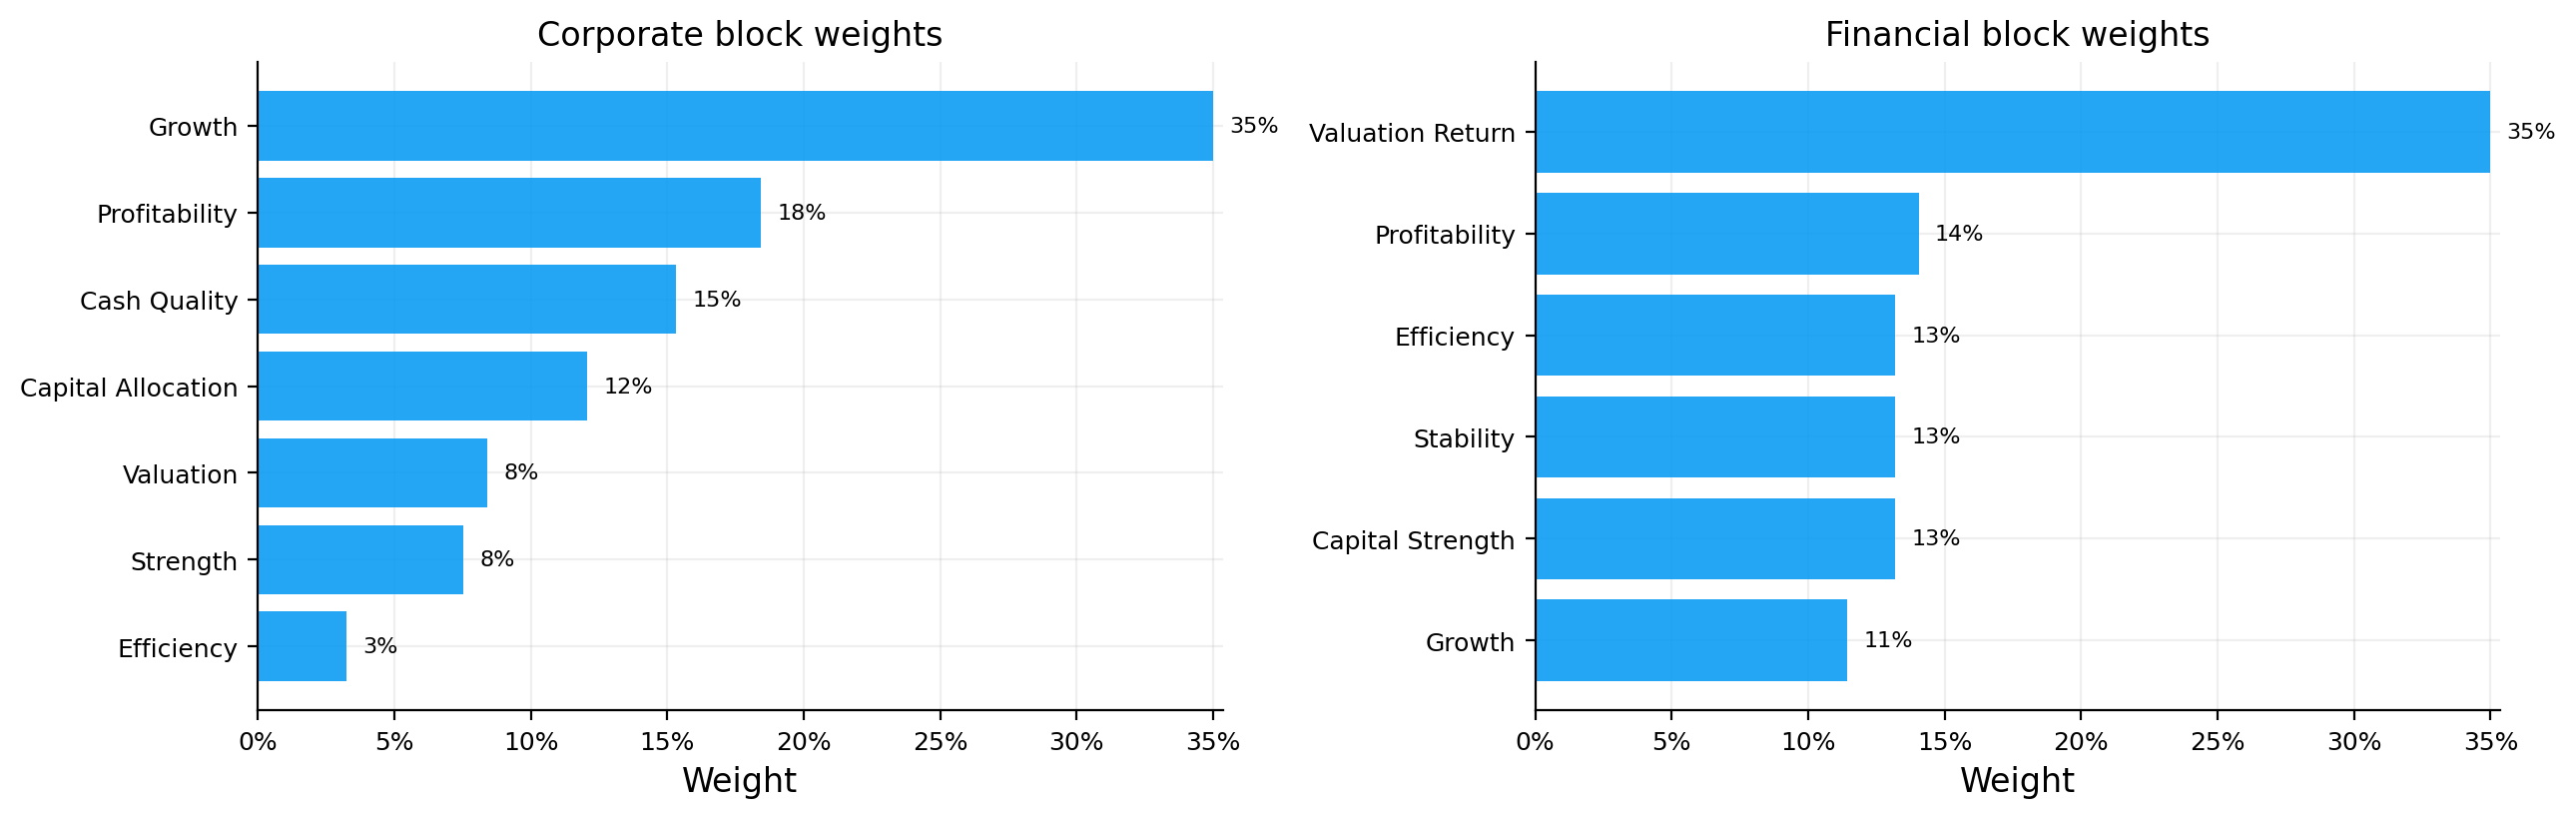

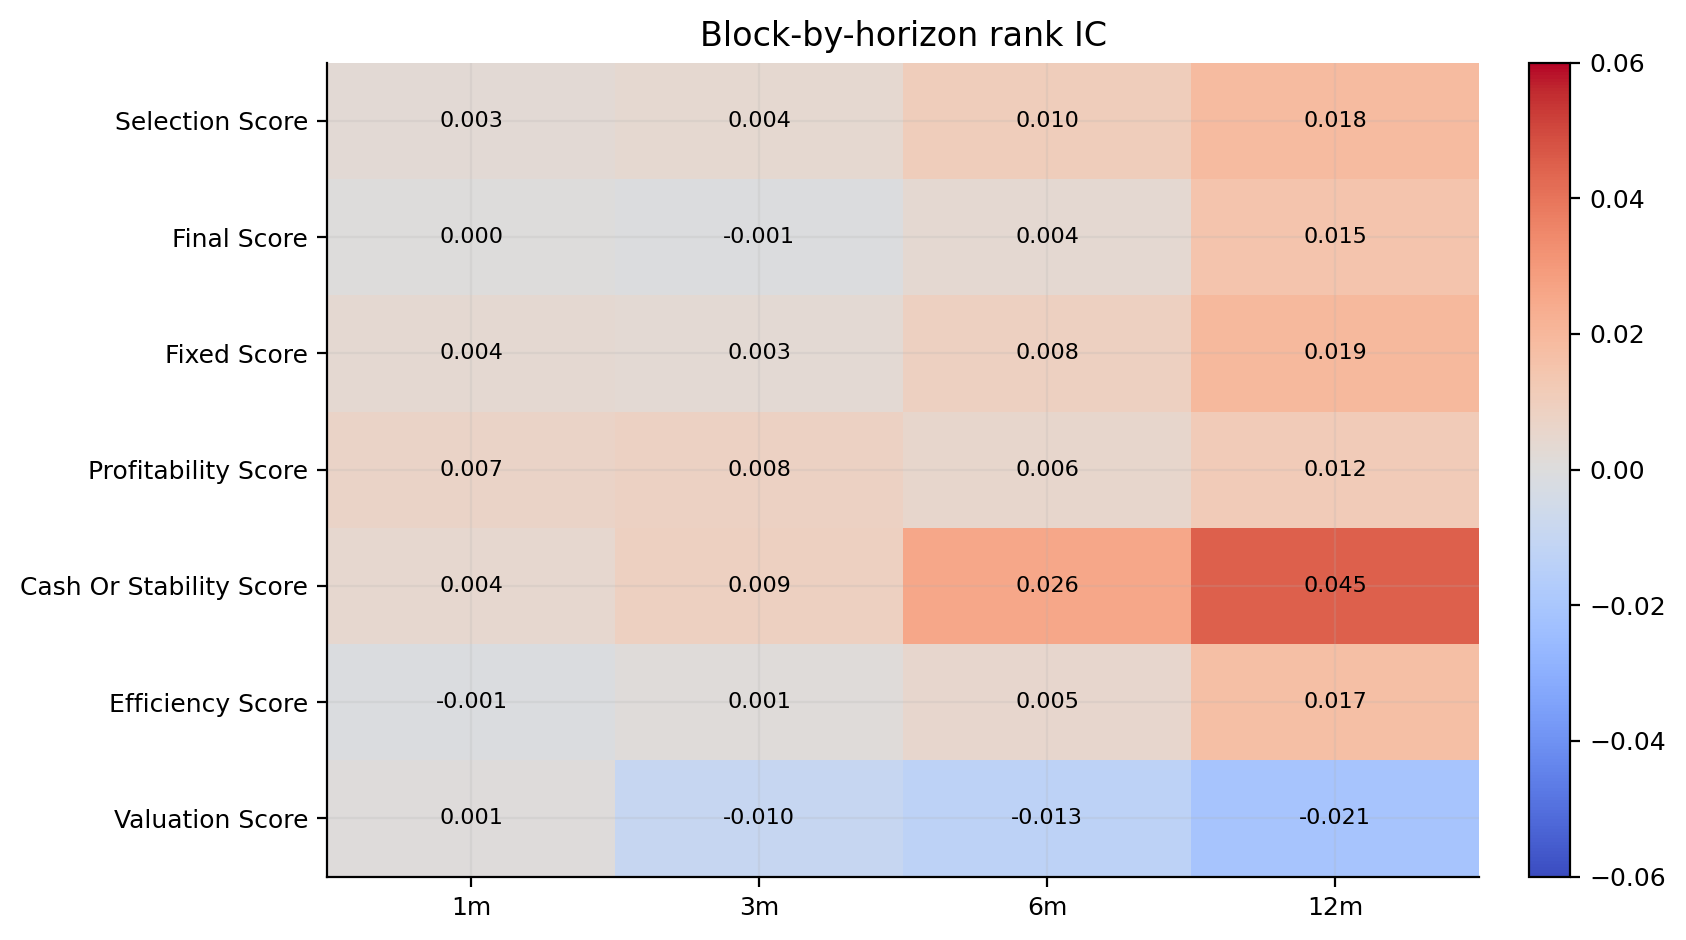

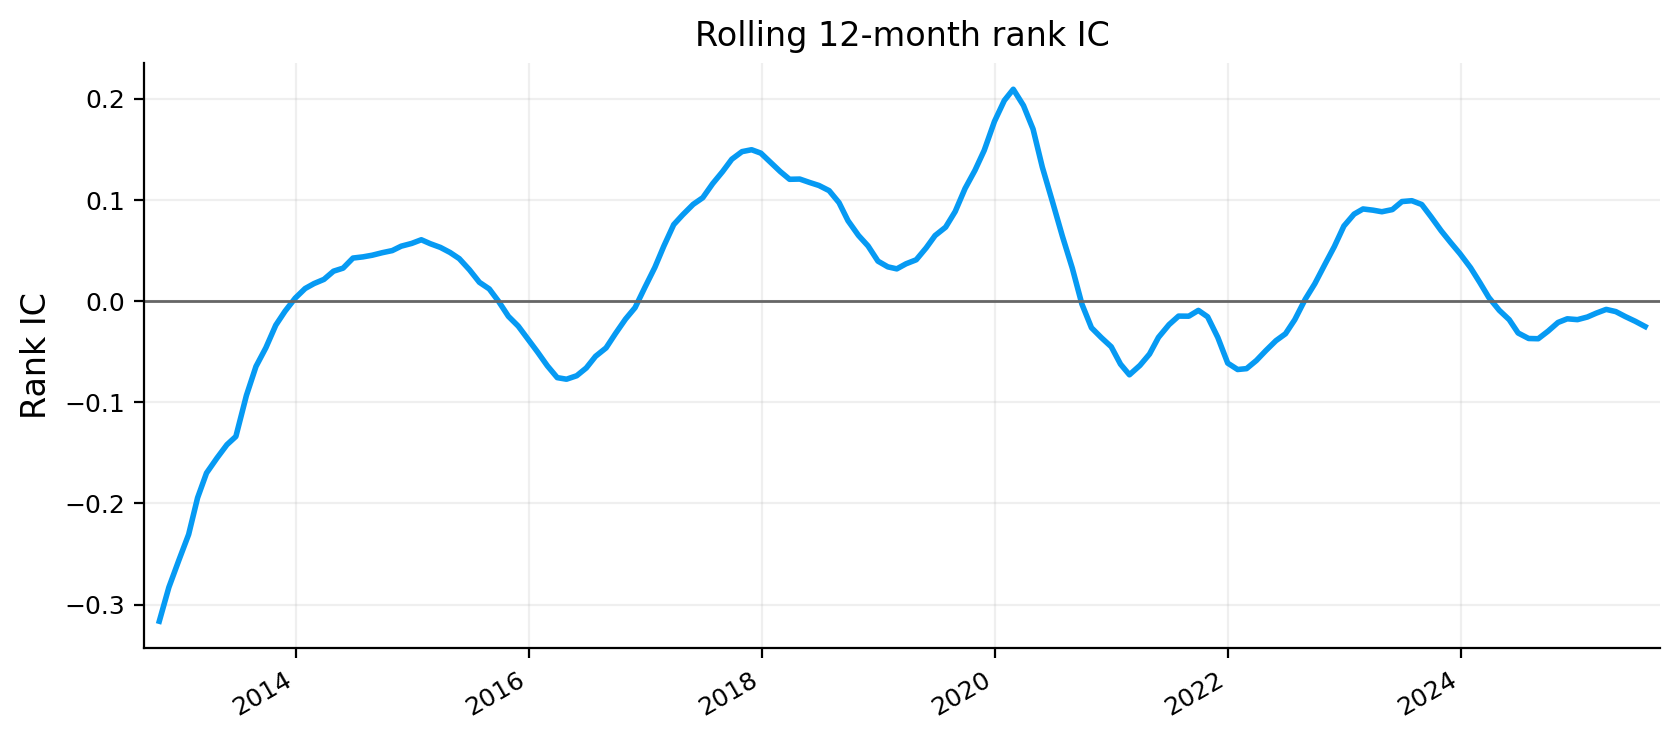

horizon_months,1,3,6,12
model,,,,
cash_or_stability_score,0.004,0.009,0.026,0.045
efficiency_score,-0.001,0.001,0.005,0.017
final_score,0.000,-0.001,0.004,0.015
fixed_score,0.004,0.003,0.008,0.019
profitability_score,0.007,0.008,0.006,0.012
selection_score,0.003,0.004,0.010,0.018
valuation_score,0.001,-0.010,-0.013,-0.021


67

In [50]:
monthly_prices = adj_close_filled.reindex(
    date_map["decision_date"]
)
price_signals = {}
for months in [1, 3, 6, 12]:
    if months in [3, 6, 12]:
        price_signals[f"momentum_{months}_1"] = (
            monthly_prices.shift(1) / monthly_prices.shift(months) - 1.0
        ).stack()
    price_signals[f"forward_{months}m"] = (
        monthly_prices.shift(-months) / monthly_prices - 1.0
    ).stack()
price_signals = pd.concat(price_signals, axis=1)
price_signals.index.names = ["decision_date", "ticker"]

score_validation_data = fundamental_scores.join(
    price_signals, on=["decision_date", "ticker"]
)
family_keys = [
    score_validation_data["decision_date"],
    score_validation_data["score_family"],
]
score_validation_data["momentum_score"] = (
    score_validation_data["momentum_6_1"]
    .groupby(family_keys).rank(pct=True) * 100.0
)
block_columns = {
    "corporate": corporate_block_columns,
    "financial": financial_block_columns,
}
prior_weights = {
    "corporate": corporate_block_weights,
    "financial": financial_block_weights,
}


def monthly_block_ic(family, months):
    rows = score_validation_data["score_family"].eq(family)
    columns = block_columns[family]
    values = {}
    for decision_date, month in score_validation_data.loc[
        rows, ["decision_date", f"forward_{months}m", *columns]
    ].groupby("decision_date"):
        values[decision_date] = month[columns].corrwith(
            month[f"forward_{months}m"], method="spearman"
        )
    return pd.DataFrame(values).T.sort_index()


def limit_score_weights(row, weight_cap=0.35):
    weights = row.copy()
    for _ in range(len(row)):
        excess = (weights - weight_cap).clip(lower=0.0).sum()
        weights = weights.clip(upper=weight_cap)
        if excess <= 1e-12:
            break
        room = (weight_cap - weights).clip(lower=0.0)
        weights = weights + excess * room / room.sum()
    return weights / weights.sum()


def walkforward_weights(family):
    observed_ic = (
        0.25 * monthly_block_ic(family, 3).shift(3)
        + 0.50 * monthly_block_ic(family, 6).shift(6)
        + 0.25 * monthly_block_ic(family, 12).shift(12)
    )
    strength = observed_ic.rolling(36, min_periods=12).mean().clip(lower=0.0)
    learned = strength.div(strength.sum(axis=1), axis=0)
    prior = prior_weights[family]
    learned = learned.fillna(pd.DataFrame(
        np.tile(prior.to_numpy(), (len(learned), 1)),
        index=learned.index,
        columns=learned.columns,
    ))
    weights = 0.25 * prior + 0.75 * learned
    weights = weights.div(weights.sum(axis=1), axis=0)
    return weights.apply(limit_score_weights, axis=1)


score_weight_history = {
    family: walkforward_weights(family)
    for family in block_columns
}
adaptive_base_score = pd.Series(
    np.nan, index=score_validation_data.index
)
for family, columns in block_columns.items():
    valid = (
        score_validation_data["score_family"].eq(family)
        & score_validation_data[f"{family}_base_score"].notna()
    )
    dates = score_validation_data.loc[valid, "decision_date"]
    row_weights = score_weight_history[family].reindex(
        dates
    ).set_axis(score_validation_data.index[valid])
    values = score_validation_data.loc[valid, columns]
    numerator = values.mul(row_weights).sum(axis=1, min_count=1)
    denominator = values.notna().mul(row_weights).sum(axis=1)
    adaptive_base_score.loc[valid] = numerator.div(
        denominator
    ).where(denominator.gt(0))
    for column in columns:
        score_validation_data[f"{column}_weight"] = row_weights[column]

penalty = (
    score_validation_data["piotroski_penalty"].fillna(0.0)
    + score_validation_data["red_flag_penalty"].fillna(0.0)
)
score_validation_data["fixed_score"] = score_validation_data["final_score"]
score_validation_data["final_score"] = (
    (adaptive_base_score - penalty)
    .groupby(family_keys).rank(pct=True) * 100.0
)
score_validation_data["selection_score"] = (
    0.90 * score_validation_data["final_score"]
    + 0.10 * score_validation_data["momentum_score"]
)
score_validation_data["profitability_score"] = score_validation_data[
    "corporate_profitability_score"
].combine_first(score_validation_data["financial_profitability_score"])
score_validation_data["efficiency_score"] = score_validation_data[
    "corporate_efficiency_score"
].combine_first(score_validation_data["financial_efficiency_score"])
score_validation_data["valuation_score"] = score_validation_data[
    "corporate_valuation_score"
].combine_first(score_validation_data["financial_valuation_return_score"])
score_validation_data["cash_or_stability_score"] = score_validation_data[
    "corporate_cash_quality_score"
].combine_first(score_validation_data["financial_stability_score"])

prediction_columns = [
    "selection_score", "final_score", "fixed_score",
    "profitability_score", "cash_or_stability_score",
    "efficiency_score", "valuation_score",
]
rank_tables = []
for months in [1, 3, 6, 12]:
    table = rank_metrics(
        score_validation_data,
        date_col="decision_date", asset_col="ticker",
        y_col=f"forward_{months}m", prediction_cols=prediction_columns,
        top_frac=0.20,
    ).reset_index()
    table["horizon_months"] = months
    rank_tables.append(table)
score_validation = pd.concat(rank_tables, ignore_index=True)
score_output_columns = [
    column for column in score_validation_data
    if not column.startswith("forward_")
    and not column.startswith("momentum_")
]
fundamental_scores = score_validation_data[
    score_output_columns
].copy()
latest_weights = pd.concat({
    family: history.tail(1).T.iloc[:, 0]
    for family, history in score_weight_history.items()
}, axis=1).fillna(0.0)
display(
    latest_weights.style.format("{:.1%}").set_caption(
        "Latest walk-forward block weights"
    )
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for axis, family in zip(axes, ["corporate", "financial"]):
    values = latest_weights[family]
    values = values[values.gt(0)].sort_values()
    labels = [
        clean_label(value)
        .replace("Corporate ", "")
        .replace("Financial ", "")
        .replace(" Score", "")
        for value in values.index
    ]
    axis.barh(labels, values, color=blue, alpha=0.88)
    axis.set_title(f"{family.title()} block weights")
    axis.set_xlabel("Weight")
    axis.xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
    for y, value in enumerate(values):
        axis.text(value + 0.006, y, f"{value:.0%}", va="center", fontsize=8)
    finish_axes(axis, axis="x")
plt.tight_layout()
plt.show()

rolling_ic_12m = rolling_rank_ic(
    score_validation_data,
    date_col="decision_date", asset_col="ticker",
    y_col="forward_12m", pred_col="selection_score", window=12,
)
ic_view = score_validation.pivot(
    index="model", columns="horizon_months", values="mean_rank_ic"
).reindex(prediction_columns)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
image = ax.imshow(
    ic_view, aspect="auto", cmap="coolwarm", vmin=-0.06, vmax=0.06
)
ax.set_yticks(
    range(len(ic_view)),
    [clean_label(value) for value in ic_view.index],
)
ax.set_xticks(
    range(len(ic_view.columns)),
    [f"{months}m" for months in ic_view.columns],
)
ax.set_title("Block-by-horizon rank IC")
for row in range(len(ic_view)):
    for column in range(len(ic_view.columns)):
        value = ic_view.iloc[row, column]
        ax.text(
            column, row, f"{value:.3f}",
            ha="center", va="center", fontsize=8,
        )
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 3.8))
rolling_ic_12m.plot(ax=ax, color=blue, linewidth=2)
ax.axhline(0, color=muted, linewidth=1)
ax.set_title("Rolling 12-month rank IC")
ax.set_xlabel("")
ax.set_ylabel("Rank IC")
finish_axes(ax)
plt.tight_layout()
plt.show()

display(
    score_validation.pivot(
        index="model", columns="horizon_months", values="mean_rank_ic"
    ).style.format("{:.3f}").set_caption(
        "Average rank IC by forward horizon"
    )
)




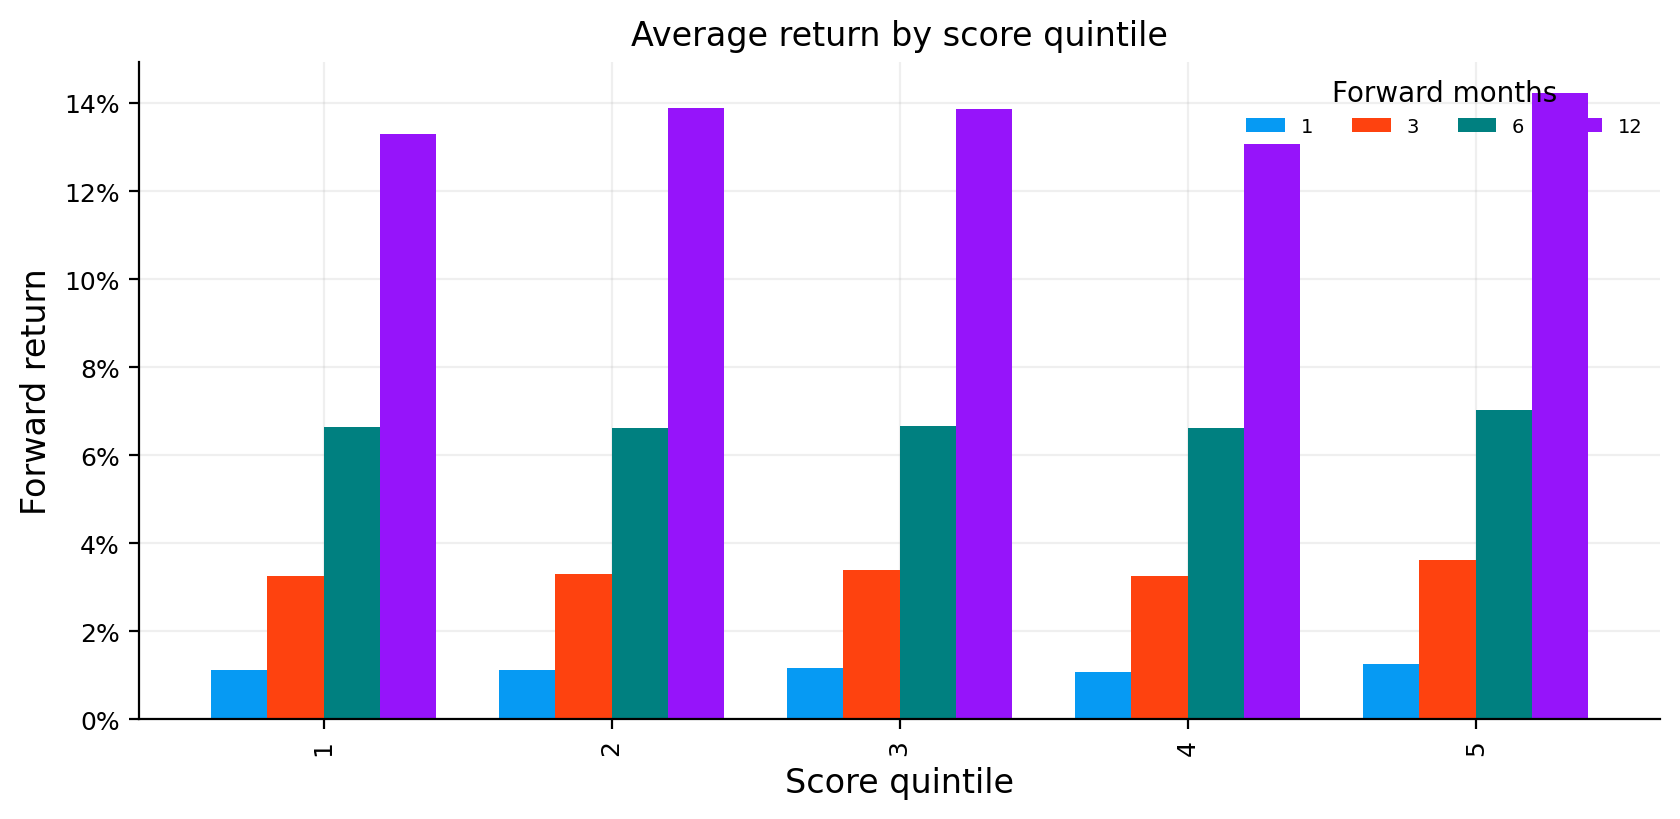

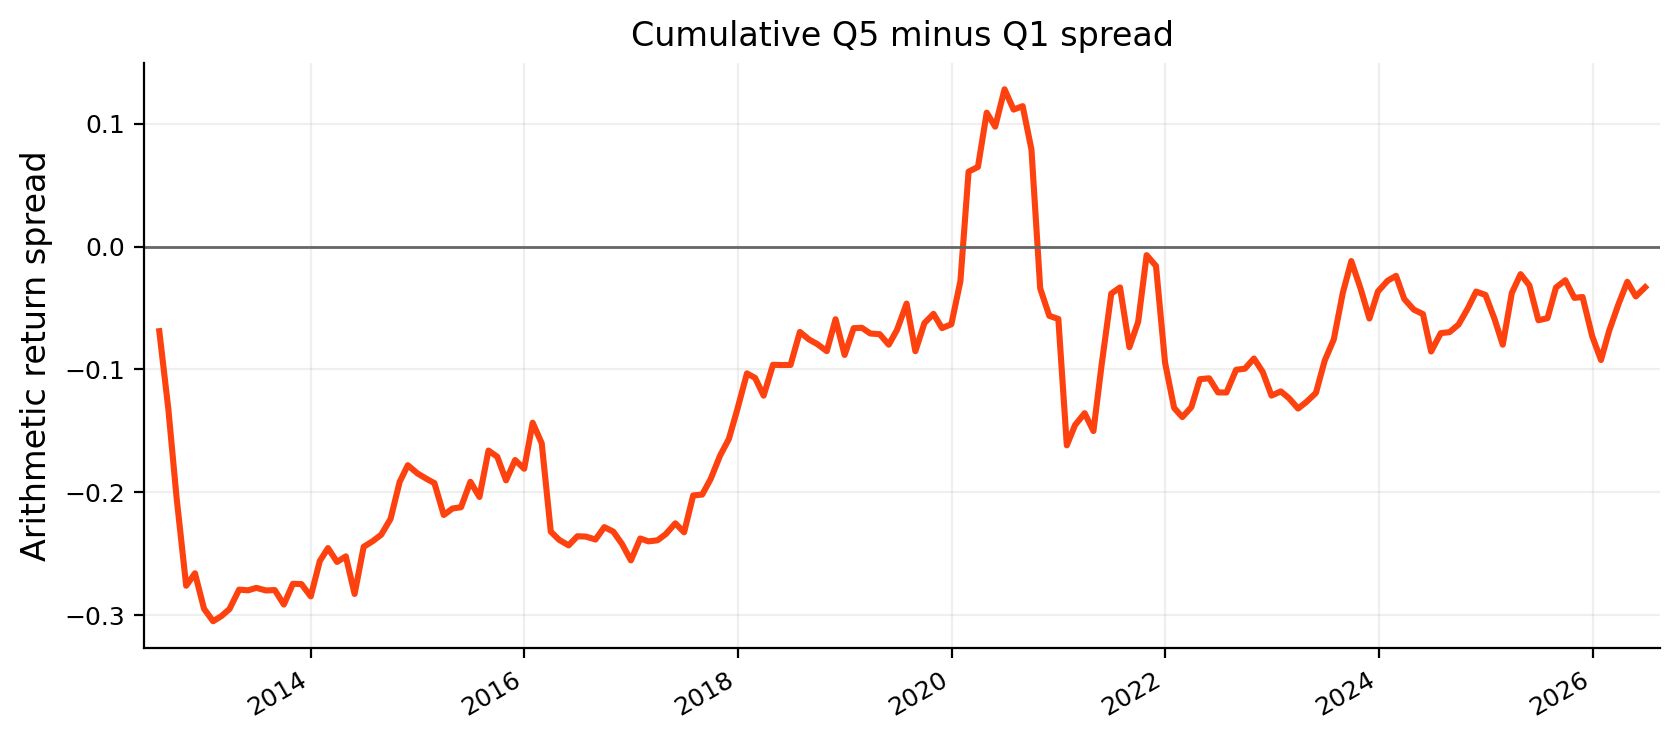

In [51]:
bucket_tables = []
for months in [1, 3, 6, 12]:
    table = forecast_buckets(
        score_validation_data,
        date_col="decision_date", y_col=f"forward_{months}m",
        score_col="selection_score", n_buckets=5,
    ).reset_index()
    table["horizon_months"] = months
    bucket_tables.append(table)
quintile_summary = pd.concat(bucket_tables, ignore_index=True)

monthly_bucket_rows = []
for decision_date, group in score_validation_data.dropna(
    subset=["selection_score", "forward_1m"]
).groupby("decision_date"):
    if len(group) < 25:
        continue
    bucket = pd.qcut(
        group["selection_score"].rank(method="first"), 5, labels=False
    ) + 1
    monthly_bucket_rows.append(
        group.assign(bucket=bucket)
        .groupby("bucket")["forward_1m"].mean().rename(decision_date)
    )
monthly_quintile_returns = pd.DataFrame(monthly_bucket_rows).sort_index()
monthly_quintile_returns.index = pd.to_datetime(monthly_quintile_returns.index)
quintile_spread = (
    monthly_quintile_returns[5] - monthly_quintile_returns[1]
).rename("Q5 − Q1")

return_by_quintile = quintile_summary.pivot(
    index="bucket", columns="horizon_months", values="mean"
)
fig, ax = plt.subplots(figsize=(8.5, 4.2))
return_by_quintile.plot.bar(
    ax=ax, color=[blue, gold, teal, coral], width=0.78,
)
ax.set_title("Average return by score quintile")
ax.set_xlabel("Score quintile")
ax.set_ylabel("Forward return")
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
ax.legend(title="Forward months", ncol=4, frameon=False)
finish_axes(ax)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 3.8))
quintile_spread.cumsum().plot(ax=ax, color=gold, linewidth=2.2)
ax.axhline(0, color=muted, linewidth=1)
ax.set_title("Cumulative Q5 minus Q1 spread")
ax.set_ylabel("Arithmetic return spread")
ax.set_xlabel("")
finish_axes(ax)
plt.tight_layout()
plt.show()


In [52]:
scoreable = score_validation_data[
    score_validation_data["decision_date"].ge(backtest_start)
    & score_validation_data["selection_score"].notna()
].sort_values(["decision_date", "selection_score"], ascending=[True, False])

selection_frames = []
for top_n in top_n_values:
    selected = scoreable.groupby("decision_date", group_keys=False).head(top_n).copy()
    selected["top_n"] = top_n
    selected["selection_rank"] = selected.groupby(
        "decision_date"
    )["selection_score"].rank(ascending=False, method="first")
    selection_frames.append(selected)
stock_selections = pd.concat(selection_frames, ignore_index=True)
selection_membership_check = stock_selections.merge(
    monthly_universe[[
        "decision_date", "ticker", "is_sp500_member", "score_family",
    ]],
    on=["decision_date", "ticker"], how="left", suffixes=("", "_universe"),
)
assert selection_membership_check["is_sp500_member"].eq(True).all()
assert stock_selections["score_family"].isin(["corporate", "financial"]).all()
assert stock_selections["score_family"].eq("financial").any()
assert not stock_selections["industry"].isin(reit_industries).any()
assert stock_selections.groupby(
    ["decision_date", "top_n"]
)["ticker"].nunique().le(
    stock_selections["top_n"].groupby([
        stock_selections["decision_date"], stock_selections["top_n"],
    ]).first()
).all()




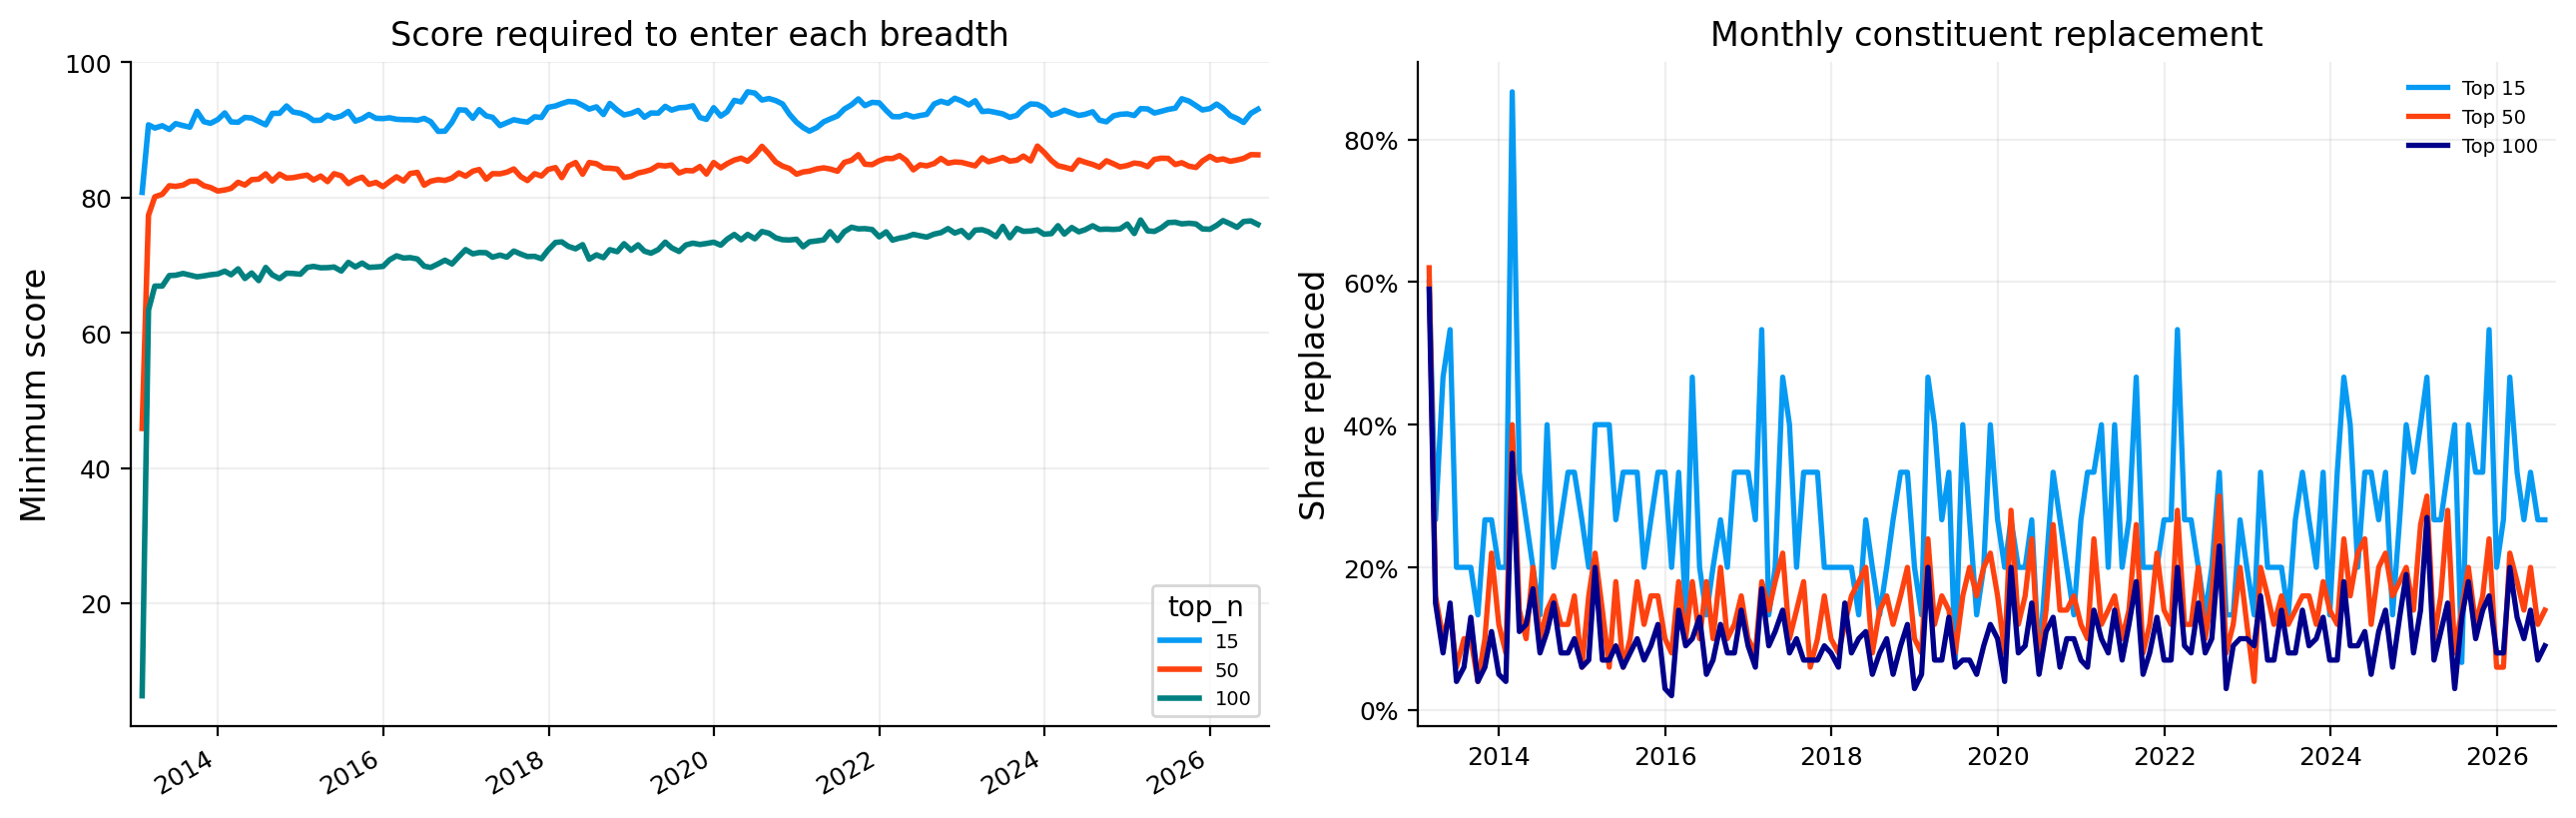

,ticker,entity_name,score_family,industry,market_cap,selection_score
selection_rank,,,,,,
1.000000,VLO,VALERO ENERGY CORP/TX,corporate,PETROLEUM REFINING,$90.09B,99.0
2.000000,MU,MICRON TECHNOLOGY INC,corporate,SEMICONDUCTORS & RELATED DEVICES,$929.52B,98.8
3.000000,FTNT,"Fortinet, Inc.",corporate,"COMPUTER PERIPHERAL EQUIPMENT, NEC",$118.82B,98.2
4.000000,SNDK,Sandisk Corp,corporate,COMPUTER STORAGE DEVICES,$179.90B,96.9
5.000000,APP,AppLovin Corp,corporate,"SERVICES-COMPUTER PROGRAMMING, DATA PROCESSING, ETC.",$133.14B,95.7
6.000000,STX,Seagate Technology Holdings plc,corporate,COMPUTER STORAGE DEVICES,$191.97B,95.5
7.000000,WDC,WESTERN DIGITAL CORP,corporate,COMPUTER STORAGE DEVICES,$187.80B,94.7
8.000000,VRT,Vertiv Holdings Co,corporate,"ELECTRONIC COMPONENTS, NEC",$93.00B,94.5
9.000000,ACGL,ARCH CAPITAL GROUP LTD.,financial,"FIRE, MARINE & CASUALTY INSURANCE",$35.12B,94.3


In [53]:
selection_cutoffs = stock_selections.groupby(
    ["decision_date", "top_n"]
)["selection_score"].min().unstack()
selection_turnover_rows = []
for top_n, group in stock_selections.groupby("top_n"):
    previous = None
    for decision_date, month in group.groupby("decision_date"):
        current = set(month["ticker"])
        if previous is not None:
            selection_turnover_rows.append({
                "decision_date": decision_date, "top_n": top_n,
                "constituent_turnover": 1.0 - len(current & previous) / len(current),
                "average_score": month["selection_score"].mean(),
            })
        previous = current
selection_turnover = pd.DataFrame(selection_turnover_rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
selection_cutoffs.plot(ax=axes[0], color=[blue, gold, teal], linewidth=2)
axes[0].set_title("Score required to enter each breadth")
axes[0].set_xlabel("")
axes[0].set_ylabel("Minimum score")
finish_axes(axes[0])
for top_n, group in selection_turnover.groupby("top_n"):
    axes[1].plot(
        group["decision_date"], group["constituent_turnover"],
        linewidth=1.9, label=f"Top {top_n}",
    )
axes[1].set_title("Monthly constituent replacement")
axes[1].set_xlabel("")
axes[1].set_ylabel("Share replaced")
axes[1].yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
axes[1].legend(frameon=False)
finish_axes(axes[1])
plt.tight_layout()
plt.show()

latest_selection_date = stock_selections["decision_date"].max()
latest_top15 = stock_selections[
    stock_selections["decision_date"].eq(latest_selection_date)
    & stock_selections["top_n"].eq(15)
]
latest_selection_table = latest_top15[[
    "selection_rank", "ticker", "entity_name", "score_family", "industry",
    "market_cap", "selection_score",
]].set_index("selection_rank")
display(
    latest_selection_table.style.format({
        "market_cap": money, "selection_score": "{:.1f}",
    }, na_rep="—").set_caption(
        f"Latest Top 15 constituents · {latest_selection_date:%B %Y}"
    )
)


In [54]:
decision_dates = pd.DatetimeIndex(sorted(
    set(stock_selections["decision_date"]) & set(date_map["decision_date"])
))
decision_dates = decision_dates[decision_dates >= backtest_start]
decision_to_execution = date_map.set_index("decision_date")["execution_date"]
portfolio_dates = pd.DatetimeIndex([
    decision_to_execution.loc[decision_date] for decision_date in decision_dates
])

universe_source = {
    pd.Timestamp(decision_date): group["ticker"].tolist()
    for decision_date, group in monthly_universe[
        monthly_universe["decision_date"].isin(decision_dates)
    ].groupby("decision_date")
}
selection_source = {
    top_n: {
        pd.Timestamp(decision_date): group["ticker"].tolist()
        for decision_date, group in stock_selections[
            stock_selections["top_n"].eq(top_n)
            & stock_selections["decision_date"].isin(decision_dates)
        ].groupby("decision_date")
    }
    for top_n in top_n_values
}

portfolio_universes = {"Full": {}, "Top15": {}, "Top50": {}, "Top100": {}}
seasoned_observations = (
    adj_close_filled.notna().rolling(cov_lookback + 1).sum()
)
for decision_date in decision_dates:
    execution_date = pd.Timestamp(decision_to_execution.loc[decision_date])
    observations = seasoned_observations.loc[decision_date]
    for label, candidates in [
        ("Full", universe_source.get(decision_date, [])),
        ("Top15", selection_source[15].get(decision_date, [])),
        ("Top50", selection_source[50].get(decision_date, [])),
        ("Top100", selection_source[100].get(decision_date, [])),
    ]:
        names = [
            ticker for ticker in candidates
            if observations.get(ticker, 0) >= min_model_obs
        ]
        if len(names) >= 10:
            portfolio_universes[label][execution_date] = {"tickers": names}

## Model selection through 2019

The portfolio rules are chosen only from January 2013 through December 2019. The objective rewards full-window Sharpe, the weaker of two subperiod Sharpes, and consistency between 2013–2016 and 2017–2019; it penalizes drawdown and turnover. This makes a setting earn its place across two different market regimes instead of winning on one favorable stretch.

For candidate setting $j$, the selection score is

$$
S_j = 0.50\,SR_j + 0.35\min(SR_{j,1},SR_{j,2})
      + 0.15\frac{SR_{j,1}+SR_{j,2}}{2}
      - 0.10\lvert SR_{j,1}-SR_{j,2}\rvert
      + 0.10\,MDD_j - 0.05\,TO_j.
$$

The search covers lookback, concentration cap, turnover penalty, covariance and expected-return estimators, mean–variance risk aversion, smoothing, and the advanced-model settings. The resulting dictionary is hashed and frozen before any 2020+ portfolio result is shown.


In [55]:
training_returns = returns.loc[:selection_end]
training_prices = adj_close_filled.loc[:selection_end]
rf_training = rf_daily.reindex(training_returns.index).fillna(0.0)


def period_metrics(result, start, end):
    values = pd.Series(result.net_returns, dtype=float).loc[start:end].dropna()
    rf_values = rf_daily.reindex(values.index).fillna(0.0)
    nav = (1.0 + values).cumprod()
    years = len(values) / annualization
    volatility = values.std(ddof=1) * np.sqrt(annualization)
    return {
        "observations": len(values),
        "cagr": nav.iloc[-1] ** (1.0 / years) - 1.0,
        "volatility": volatility,
        "sharpe": (values - rf_values).mean() / values.std(ddof=1) * np.sqrt(annualization),
        "max_drawdown": (nav / nav.cummax() - 1.0).min(),
        "turnover": pd.Series(result.turnover, dtype=float).loc[start:end].mean(),
    }


def training_candidate(name, family, result):
    full = period_metrics(result, selection_start, selection_end)
    early = period_metrics(result, selection_start, pd.Timestamp("2016-12-31"))
    late = period_metrics(result, pd.Timestamp("2017-01-01"), selection_end)
    stable_score = (
        0.50 * full["sharpe"]
        + 0.35 * min(early["sharpe"], late["sharpe"])
        + 0.15 * (early["sharpe"] + late["sharpe"]) / 2.0
        - 0.10 * abs(early["sharpe"] - late["sharpe"])
        + 0.10 * full["max_drawdown"]
        - 0.05 * full["turnover"]
    )
    return {
        "candidate": name,
        "family": family,
        "train_sharpe": full["sharpe"],
        "early_sharpe": early["sharpe"],
        "late_sharpe": late["sharpe"],
        "train_cagr": full["cagr"],
        "train_volatility": full["volatility"],
        "train_max_drawdown": full["max_drawdown"],
        "train_turnover": full["turnover"],
        "stable_score": stable_score,
    }


tuning_cov_models = {
    "Sample": covariance.sample_covariance,
    "LedoitWolf": covariance.ledoit_wolf_covariance,
    "OAS": covariance.oas_covariance,
    "EWMA": covariance.ewma_covariance,
}
tuning_mu_models = {
    "Momentum": expected_returns.momentum_mu,
    "BayesStein": expected_returns.bayes_stein_mu,
    "BayesSteinMomentum": expected_returns.bayes_stein_momentum_mu,
}
tuning_optimizers = {
    "MinVar": optimizers.minimum_variance,
    "MV": optimizers.mean_variance,
    "MaxSharpe": optimizers.max_sharpe_slsqp,
}


def core_candidate_specs():
    specs = [
        {"name": f"MinVar|{cov_model}", "optimizer": "MinVar", "cov_model": cov_model}
        for cov_model in tuning_cov_models
    ]
    specs.extend(
        {
            "name": f"MV|{cov_model}|{mu_model}",
            "optimizer": "MV",
            "cov_model": cov_model,
            "mu_model": mu_model,
        }
        for cov_model in tuning_cov_models
        for mu_model in tuning_mu_models
    )
    specs.extend(
        {
            "name": f"MaxSharpe|{cov_model}|{mu_model}",
            "optimizer": "MaxSharpe",
            "cov_model": cov_model,
            "mu_model": mu_model,
        }
        for cov_model in tuning_cov_models
        for mu_model in ("BayesStein", "BayesSteinMomentum")
    )
    return specs


def top15_universe_for_lookback(lookback):
    minimum = int(lookback) - 12
    observations = adj_close_filled.notna().rolling(int(lookback) + 1).sum()
    universe = {}
    for decision_date in decision_dates:
        names = [
            ticker
            for ticker in selection_source[15].get(decision_date, [])
            if observations.loc[decision_date].get(ticker, 0) >= minimum
        ]
        if len(names) >= 10:
            execution_date = pd.Timestamp(decision_to_execution.loc[decision_date])
            universe[execution_date] = {"tickers": names}
    return universe, minimum


def evaluate_training_grid(grid, extra):
    family_by_name = grid.diagnostics["Optimizer"].to_dict()
    rows = []
    for name, result in grid.backtests.items():
        rows.append({
            **training_candidate(name, family_by_name[name], result),
            **extra,
            "cov_model": result.metadata.get("cov_model"),
            "mu_model": result.metadata.get("mu_model"),
        })
    return pd.DataFrame(rows)


lookback_caches = {}
global_parts = []
for candidate_lookback in (126, 189, 252):
    candidate_universe, candidate_minimum = top15_universe_for_lookback(candidate_lookback)
    training_dates = [
        date for date in sorted(candidate_universe)
        if selection_start <= pd.Timestamp(date) <= selection_end
    ]
    state_cache = None
    for candidate_cap in (0.10, 0.15, 0.20):
        candidate_grid = run_walkforward_grid(
            returns=training_returns,
            close=training_prices,
            rebalance_dates=training_dates,
            universe_by_date=candidate_universe,
            cov_lookback=candidate_lookback,
            mu_lookback=candidate_lookback,
            min_cov_observations=candidate_minimum,
            min_mu_observations=candidate_minimum,
            max_weight=candidate_cap,
            min_weight=0.0,
            long_only=True,
            trading_cost_bps=cost_bps,
            turnover_penalty_bps=10.0,
            optimizer_params={"MV": {"mv_lambda": 10.0}},
            blend_by_optimizer={"MinVar": 0.0, "MV": 0.0, "MaxSharpe": 0.0},
            fallback="equal",
            rf_daily=rf_training,
            annualization=annualization,
            momentum_mode="6-1",
            cov_models=tuning_cov_models,
            mu_models=tuning_mu_models,
            optimizers=tuning_optimizers,
            strategy_specs=core_candidate_specs(),
            cache=state_cache,
        )
        state_cache = candidate_grid.cache
        global_parts.append(evaluate_training_grid(candidate_grid, {
            "lookback": candidate_lookback,
            "minimum_observations": candidate_minimum,
            "maximum_weight": candidate_cap,
            "turnover_penalty_bps": 10.0,
            "mv_lambda": 10.0,
            "blend": 0.0,
            "stage": "global lookback/cap",
        }))
    lookback_caches[candidate_lookback] = (candidate_universe, state_cache)

global_candidates = pd.concat(global_parts, ignore_index=True)
best_by_family = (
    global_candidates.sort_values("stable_score", ascending=False)
    .groupby(["lookback", "maximum_weight", "family"], as_index=False)
    .first()
)
global_summary = (
    best_by_family.groupby(["lookback", "maximum_weight"])["stable_score"]
    .agg(["mean", "min", "std"])
    .reset_index()
)
global_summary["configuration_score"] = (
    0.50 * global_summary["mean"]
    + 0.50 * global_summary["min"]
    - 0.05 * global_summary["std"].fillna(0.0)
)
global_winner = global_summary.sort_values(
    ["configuration_score", "lookback", "maximum_weight"],
    ascending=[False, False, True],
).iloc[0]
selected_global = {
    "lookback": int(global_winner["lookback"]),
    "minimum_observations": int(global_winner["lookback"] - 12),
    "maximum_weight": float(global_winner["maximum_weight"]),
}

selected_training_universe, selected_state_cache = lookback_caches[selected_global["lookback"]]
selected_training_dates = [
    date for date in sorted(selected_training_universe)
    if selection_start <= pd.Timestamp(date) <= selection_end
]
turnover_parts = []
for candidate_penalty in (0.0, 10.0, 25.0, 50.0):
    penalty_grid = run_walkforward_grid(
        returns=training_returns,
        close=training_prices,
        rebalance_dates=selected_training_dates,
        universe_by_date=selected_training_universe,
        cov_lookback=selected_global["lookback"],
        mu_lookback=selected_global["lookback"],
        min_cov_observations=selected_global["minimum_observations"],
        min_mu_observations=selected_global["minimum_observations"],
        max_weight=selected_global["maximum_weight"],
        min_weight=0.0,
        long_only=True,
        trading_cost_bps=cost_bps,
        turnover_penalty_bps=candidate_penalty,
        optimizer_params={"MV": {"mv_lambda": 10.0}},
        blend_by_optimizer={"MinVar": 0.0, "MV": 0.0, "MaxSharpe": 0.0},
        fallback="equal",
        rf_daily=rf_training,
        annualization=annualization,
        momentum_mode="6-1",
        cov_models=tuning_cov_models,
        mu_models=tuning_mu_models,
        optimizers=tuning_optimizers,
        strategy_specs=core_candidate_specs(),
        cache=selected_state_cache,
    )
    selected_state_cache = penalty_grid.cache
    turnover_parts.append(evaluate_training_grid(penalty_grid, {
        **selected_global,
        "turnover_penalty_bps": candidate_penalty,
        "mv_lambda": 10.0,
        "blend": 0.0,
        "stage": "turnover penalty",
    }))

turnover_candidates = pd.concat(turnover_parts, ignore_index=True)
turnover_best = (
    turnover_candidates.sort_values("stable_score", ascending=False)
    .groupby(["turnover_penalty_bps", "family"], as_index=False)
    .first()
)
turnover_summary = (
    turnover_best.groupby("turnover_penalty_bps")["stable_score"]
    .agg(["mean", "min", "std"])
    .reset_index()
)
turnover_summary["configuration_score"] = (
    0.50 * turnover_summary["mean"]
    + 0.50 * turnover_summary["min"]
    - 0.05 * turnover_summary["std"].fillna(0.0)
)
selected_global["turnover_penalty_bps"] = float(
    turnover_summary.sort_values(
        ["configuration_score", "turnover_penalty_bps"],
        ascending=[False, False],
    ).iloc[0]["turnover_penalty_bps"]
)

core_common = {
    "returns": training_returns,
    "close": training_prices,
    "rebalance_dates": selected_training_dates,
    "universe_by_date": selected_training_universe,
    "cov_lookback": selected_global["lookback"],
    "mu_lookback": selected_global["lookback"],
    "min_cov_observations": selected_global["minimum_observations"],
    "min_mu_observations": selected_global["minimum_observations"],
    "max_weight": selected_global["maximum_weight"],
    "min_weight": 0.0,
    "long_only": True,
    "trading_cost_bps": cost_bps,
    "turnover_penalty_bps": selected_global["turnover_penalty_bps"],
    "fallback": "equal",
    "rf_daily": rf_training,
    "annualization": annualization,
    "momentum_mode": "6-1",
    "cov_models": tuning_cov_models,
    "mu_models": tuning_mu_models,
    "optimizers": tuning_optimizers,
    "cache": selected_state_cache,
}
core_parts = []
core_base_grid = run_walkforward_grid(
    strategy_specs=core_candidate_specs(),
    optimizer_params={"MV": {"mv_lambda": 10.0}},
    blend_by_optimizer={"MinVar": 0.0, "MV": 0.0, "MaxSharpe": 0.0},
    **core_common,
)
core_base = evaluate_training_grid(core_base_grid, {
    **selected_global,
    "mv_lambda": 10.0,
    "blend": 0.0,
    "stage": "core estimator",
})
core_parts.append(core_base)

mv_parts = []
mv_specs = [spec for spec in core_candidate_specs() if spec["optimizer"] == "MV"]
for candidate_lambda in (3.0, 6.0, 10.0, 15.0):
    candidate_grid = run_walkforward_grid(
        strategy_specs=mv_specs,
        optimizer_params={"MV": {"mv_lambda": candidate_lambda}},
        blend_by_optimizer={"MV": 0.0},
        **core_common,
    )
    mv_parts.append(evaluate_training_grid(candidate_grid, {
        **selected_global,
        "mv_lambda": candidate_lambda,
        "blend": 0.0,
        "stage": "MV risk aversion",
    }))
mv_candidates = pd.concat(mv_parts, ignore_index=True)
core_parts.append(mv_candidates)

initial_core = {
    "MinVar": core_base[core_base["family"].eq("MinVar")].sort_values("stable_score", ascending=False).iloc[0],
    "MV": mv_candidates.sort_values("stable_score", ascending=False).iloc[0],
    "MaxSharpe": core_base[core_base["family"].eq("MaxSharpe")].sort_values("stable_score", ascending=False).iloc[0],
}
selected_core = {}
for family, row in initial_core.items():
    spec = {
        "name": family,
        "optimizer": family,
        "cov_model": row["cov_model"],
    }
    if family != "MinVar":
        spec["mu_model"] = row["mu_model"]
    smoothing_parts = []
    for candidate_blend in (0.0, 0.25, 0.50):
        candidate_grid = run_walkforward_grid(
            strategy_specs=[spec],
            optimizer_params=(
                {"MV": {"mv_lambda": float(row["mv_lambda"])}}
                if family == "MV" else {}
            ),
            blend_by_optimizer={family: candidate_blend},
            **core_common,
        )
        smoothing_parts.append(evaluate_training_grid(candidate_grid, {
            **selected_global,
            "mv_lambda": float(row["mv_lambda"]),
            "blend": candidate_blend,
            "stage": "core smoothing",
        }))
    smoothing_candidates = pd.concat(smoothing_parts, ignore_index=True)
    core_parts.append(smoothing_candidates)
    winner = smoothing_candidates.sort_values(
        ["stable_score", "blend"],
        ascending=[False, True],
    ).iloc[0]
    selected_core[family] = {
        "cov_model": str(winner["cov_model"]),
        "mu_model": None if family == "MinVar" else str(winner["mu_model"]),
        "mv_lambda": float(winner["mv_lambda"]) if family == "MV" else None,
        "blend": float(winner["blend"]),
    }

core_candidates = pd.concat(core_parts, ignore_index=True)
display(
    global_summary.sort_values("configuration_score", ascending=False).head(9).style
    .format({
        "maximum_weight": "{:.0%}",
        "mean": "{:.3f}",
        "min": "{:.3f}",
        "std": "{:.3f}",
        "configuration_score": "{:.3f}",
    })
    .set_caption("2013–2019 global-setting search")
)
display(
    pd.DataFrame(selected_core).T.style
    .format({"mv_lambda": "{:.1f}", "blend": "{:.0%}"}, na_rep="—")
    .set_caption("Core estimators selected only from 2013–2019")
)


,lookback,maximum_weight,mean,min,std,configuration_score
4,189.000000,15%,1.056,0.990,0.081,1.019
3,189.000000,10%,1.006,0.965,0.035,0.984
0,126.000000,10%,0.959,0.945,0.016,0.951
6,252.000000,10%,0.963,0.907,0.052,0.932
7,252.000000,15%,0.987,0.862,0.122,0.918
5,189.000000,20%,1.000,0.839,0.161,0.912
1,126.000000,15%,0.895,0.803,0.097,0.844
8,252.000000,20%,0.960,0.723,0.217,0.831
2,126.000000,20%,0.843,0.676,0.195,0.750


,blend,cov_model,mu_model,mv_lambda
MV,0%,LedoitWolf,BayesStein,10.0
MaxSharpe,0%,Sample,BayesStein,—
MinVar,0%,LedoitWolf,—,—


In [56]:
def evaluate_weight_candidates(weight_map, parameter_map, family):
    candidate_results = run_many_weights_backtests(
        weight_map,
        returns=training_returns,
        cost_bps=cost_bps,
        rf_daily=rf_training,
        w_min=0.0,
        w_max=selected_global["maximum_weight"],
        long_only=True,
        normalize=True,
        weight_timing="same_day",
    )
    rows = []
    for name, result in candidate_results.items():
        rows.append({
            **training_candidate(name, family, result),
            **parameter_map[name],
            "stage": "advanced model",
        })
    return pd.DataFrame(rows)


model_state_cache = core_base_grid.cache
advanced_parts = []
selected_advanced = {}

cvar_weights = {}
cvar_parameters = {}
with warnings.catch_warnings(record=True) as cvar_training_warnings:
    warnings.simplefilter("always")
    for candidate_cov in tuning_cov_models:
        for candidate_mu in ("BayesStein", "BayesSteinMomentum"):
            for candidate_alpha in (0.90, 0.95):
                for candidate_budget in (0.75, 1.0):
                    name = (
                        f"Mean-CVaR|{candidate_cov}|{candidate_mu}|"
                        f"a={candidate_alpha}|b={candidate_budget}"
                    )
                    cvar_parameters[name] = {
                        "cov_model": candidate_cov,
                        "mu_model": candidate_mu,
                        "alpha": candidate_alpha,
                        "budget_scale": candidate_budget,
                    }
                    cvar_weights[name] = mean_cvar_weight_frame(
                        cache=model_state_cache,
                        rebalance_dates=selected_training_dates,
                        cov_model=candidate_cov,
                        mu_model=candidate_mu,
                        reference="equal",
                        alpha=candidate_alpha,
                        budget_scale=candidate_budget,
                        w_min=0.0,
                        w_max=selected_global["maximum_weight"],
                    )
cvar_candidates = evaluate_weight_candidates(cvar_weights, cvar_parameters, "Mean-CVaR")
advanced_parts.append(cvar_candidates)
cvar_winner = cvar_candidates.sort_values("stable_score", ascending=False).iloc[0]["candidate"]
selected_advanced["Mean-CVaR"] = cvar_parameters[cvar_winner]

wro_weights = {}
wro_parameters = {}
for candidate_cov in tuning_cov_models:
    for candidate_mu in ("BayesStein", "BayesSteinMomentum"):
        for candidate_radius in (0.10, 0.25, 0.50, 0.75):
            for candidate_lambda in (3.0, 6.0, 10.0):
                name = (
                    f"WRO|{candidate_cov}|{candidate_mu}|"
                    f"r={candidate_radius}|l={candidate_lambda}"
                )
                wro_parameters[name] = {
                    "cov_model": candidate_cov,
                    "mu_model": candidate_mu,
                    "radius": candidate_radius,
                    "mv_lambda": candidate_lambda,
                    "radius_scale": "avg_vol",
                    "worst_case_variance": True,
                }
                wro_weights[name] = wasserstein_weight_frame(
                    cache=model_state_cache,
                    rebalance_dates=selected_training_dates,
                    cov_model=candidate_cov,
                    mu_model=candidate_mu,
                    radius=candidate_radius,
                    mv_lambda=candidate_lambda,
                    radius_scale="avg_vol",
                    worst_case_variance=True,
                    w_min=0.0,
                    w_max=selected_global["maximum_weight"],
                )
wro_candidates = evaluate_weight_candidates(wro_weights, wro_parameters, "WRO")
advanced_parts.append(wro_candidates)
wro_winner = wro_candidates.sort_values("stable_score", ascending=False).iloc[0]["candidate"]
selected_advanced["WRO"] = wro_parameters[wro_winner]

risk_parity_weights = {}
risk_parity_parameters = {}
for candidate_cov in tuning_cov_models:
    name = f"Risk Parity|{candidate_cov}"
    risk_parity_parameters[name] = {"cov_model": candidate_cov}
    risk_parity_weights[name] = risk_parity_weight_frame(
        cache=model_state_cache,
        rebalance_dates=selected_training_dates,
        cov_model=candidate_cov,
        w_min=0.0,
        w_max=selected_global["maximum_weight"],
    )
risk_parity_candidates = evaluate_weight_candidates(
    risk_parity_weights,
    risk_parity_parameters,
    "Risk Parity",
)
advanced_parts.append(risk_parity_candidates)
risk_parity_winner = risk_parity_candidates.sort_values("stable_score", ascending=False).iloc[0]["candidate"]
selected_advanced["Risk Parity"] = risk_parity_parameters[risk_parity_winner]

hrp_weights = {}
hrp_parameters = {}
for candidate_cov in tuning_cov_models:
    for candidate_linkage in ("single", "complete", "average"):
        name = f"HRP|{candidate_cov}|{candidate_linkage}"
        hrp_parameters[name] = {
            "cov_model": candidate_cov,
            "linkage_method": candidate_linkage,
        }
        hrp_weights[name] = hrp_weight_frame(
            cache=model_state_cache,
            rebalance_dates=selected_training_dates,
            cov_model=candidate_cov,
            linkage_method=candidate_linkage,
            w_min=0.0,
            w_max=selected_global["maximum_weight"],
        )
hrp_candidates = evaluate_weight_candidates(hrp_weights, hrp_parameters, "HRP")
advanced_parts.append(hrp_candidates)
hrp_winner = hrp_candidates.sort_values("stable_score", ascending=False).iloc[0]["candidate"]
selected_advanced["HRP"] = hrp_parameters[hrp_winner]

nco_seed_weights = {}
nco_seed_parameters = {}
for candidate_cov in ("LedoitWolf", "OAS", "EWMA"):
    for candidate_mu in tuning_mu_models:
        for candidate_clusters in (3, 4, 6):
            name = f"NCO|{candidate_cov}|{candidate_mu}|k={candidate_clusters}"
            nco_seed_parameters[name] = {
                "cov_model": candidate_cov,
                "mu_model": candidate_mu,
                "n_clusters": candidate_clusters,
                "inner_lambda": 6.0,
                "outer_lambda": 6.0,
                "cluster_cap": 0.50,
                "linkage_method": "average",
            }
            nco_seed_weights[name] = nco_mv_weight_frame(
                cache=model_state_cache,
                rebalance_dates=selected_training_dates,
                cov_model=candidate_cov,
                mu_model=candidate_mu,
                n_clusters=candidate_clusters,
                inner_lambda=6.0,
                outer_lambda=6.0,
                cluster_cap=0.50,
                linkage_method="average",
                w_min=0.0,
                w_max=selected_global["maximum_weight"],
            )
nco_seed_candidates = evaluate_weight_candidates(
    nco_seed_weights,
    nco_seed_parameters,
    "NCO",
)
advanced_parts.append(nco_seed_candidates)
nco_seed_name = nco_seed_candidates.sort_values("stable_score", ascending=False).iloc[0]["candidate"]
nco_seed = nco_seed_parameters[nco_seed_name]

nco_weights = {}
nco_parameters = {}
for candidate_lambda in (3.0, 6.0, 10.0):
    for candidate_linkage in ("single", "average"):
        for candidate_cluster_cap in (0.50, 0.75):
            name = (
                f"NCO-final|l={candidate_lambda}|{candidate_linkage}|"
                f"c={candidate_cluster_cap}"
            )
            nco_parameters[name] = {
                **nco_seed,
                "inner_lambda": candidate_lambda,
                "outer_lambda": candidate_lambda,
                "cluster_cap": candidate_cluster_cap,
                "linkage_method": candidate_linkage,
            }
            settings = nco_parameters[name]
            nco_weights[name] = nco_mv_weight_frame(
                cache=model_state_cache,
                rebalance_dates=selected_training_dates,
                cov_model=settings["cov_model"],
                mu_model=settings["mu_model"],
                n_clusters=settings["n_clusters"],
                inner_lambda=settings["inner_lambda"],
                outer_lambda=settings["outer_lambda"],
                cluster_cap=settings["cluster_cap"],
                linkage_method=settings["linkage_method"],
                w_min=0.0,
                w_max=selected_global["maximum_weight"],
            )
current_nco_name = "NCO-current-notebook"
nco_parameters[current_nco_name] = {
    "cov_model": "EWMA",
    "mu_model": "Momentum",
    "n_clusters": 6,
    "inner_lambda": 6.0,
    "outer_lambda": 6.0,
    "cluster_cap": 0.50,
    "linkage_method": "single",
}
current_nco = nco_parameters[current_nco_name]
nco_weights[current_nco_name] = nco_mv_weight_frame(
    cache=model_state_cache,
    rebalance_dates=selected_training_dates,
    cov_model=current_nco["cov_model"],
    mu_model=current_nco["mu_model"],
    n_clusters=current_nco["n_clusters"],
    inner_lambda=current_nco["inner_lambda"],
    outer_lambda=current_nco["outer_lambda"],
    cluster_cap=current_nco["cluster_cap"],
    linkage_method=current_nco["linkage_method"],
    w_min=0.0,
    w_max=selected_global["maximum_weight"],
)
nco_candidates = evaluate_weight_candidates(nco_weights, nco_parameters, "NCO")
advanced_parts.append(nco_candidates)
nco_winner = nco_candidates.sort_values("stable_score", ascending=False).iloc[0]["candidate"]
selected_advanced["NCO"] = nco_parameters[nco_winner]

advanced_candidates = pd.concat(advanced_parts, ignore_index=True)
training_candidates = pd.concat(
    [global_candidates, turnover_candidates, core_candidates, advanced_candidates],
    ignore_index=True,
)

frozen_settings = {
    "selection_window": [str(selection_start.date()), str(selection_end.date())],
    "holdout_window": [str(holdout_start.date()), "data_end"],
    "selection_objective": (
        "0.50 full Sharpe + 0.35 weaker subperiod Sharpe + 0.15 mean subperiod "
        "Sharpe - 0.10 subperiod gap + 0.10 max drawdown - 0.05 mean turnover"
    ),
    "global": selected_global,
    "core": selected_core,
    "advanced": selected_advanced,
}
assert selected_global == {
    "lookback": cov_lookback,
    "minimum_observations": min_model_obs,
    "maximum_weight": max_weight,
    "turnover_penalty_bps": turnover_penalty_bps,
}
assert selected_core == {
    "MinVar": {"cov_model": "LedoitWolf", "mu_model": None, "mv_lambda": None, "blend": 0.0},
    "MV": {"cov_model": "LedoitWolf", "mu_model": "BayesStein", "mv_lambda": 10.0, "blend": 0.0},
    "MaxSharpe": {"cov_model": "Sample", "mu_model": "BayesStein", "mv_lambda": None, "blend": 0.0},
}


def advanced_weight_schedule(cache, rebalance_dates, maximum_weight, settings):
    cvar = settings["Mean-CVaR"]
    wro = settings["WRO"]
    risk_parity = settings["Risk Parity"]
    hrp = settings["HRP"]
    nco = settings["NCO"]
    return {
        "Mean-CVaR": mean_cvar_weight_frame(
            cache=cache,
            rebalance_dates=rebalance_dates,
            cov_model=cvar["cov_model"],
            mu_model=cvar["mu_model"],
            reference="equal",
            alpha=cvar["alpha"],
            budget_scale=cvar["budget_scale"],
            w_min=0.0,
            w_max=maximum_weight,
        ),
        "WRO": wasserstein_weight_frame(
            cache=cache,
            rebalance_dates=rebalance_dates,
            cov_model=wro["cov_model"],
            mu_model=wro["mu_model"],
            radius=wro["radius"],
            mv_lambda=wro["mv_lambda"],
            radius_scale=wro["radius_scale"],
            worst_case_variance=wro["worst_case_variance"],
            w_min=0.0,
            w_max=maximum_weight,
        ),
        "Risk Parity": risk_parity_weight_frame(
            cache=cache,
            rebalance_dates=rebalance_dates,
            cov_model=risk_parity["cov_model"],
            w_min=0.0,
            w_max=maximum_weight,
        ),
        "HRP": hrp_weight_frame(
            cache=cache,
            rebalance_dates=rebalance_dates,
            cov_model=hrp["cov_model"],
            linkage_method=hrp["linkage_method"],
            w_min=0.0,
            w_max=maximum_weight,
        ),
        "NCO": nco_mv_weight_frame(
            cache=cache,
            rebalance_dates=rebalance_dates,
            cov_model=nco["cov_model"],
            mu_model=nco["mu_model"],
            n_clusters=nco["n_clusters"],
            inner_lambda=nco["inner_lambda"],
            outer_lambda=nco["outer_lambda"],
            cluster_cap=nco["cluster_cap"],
            linkage_method=nco["linkage_method"],
            w_min=0.0,
            w_max=maximum_weight,
        ),
    }


advanced_winners = (
    advanced_candidates.sort_values("stable_score", ascending=False)
    .groupby("family", as_index=False)
    .first()
    .set_index("family")
)
display(
    advanced_winners[[
        "candidate", "train_sharpe", "early_sharpe", "late_sharpe",
        "train_max_drawdown", "train_turnover", "stable_score",
    ]].style
    .format({
        "train_sharpe": "{:.2f}",
        "early_sharpe": "{:.2f}",
        "late_sharpe": "{:.2f}",
        "train_max_drawdown": "{:.1%}",
        "train_turnover": "{:.1%}",
        "stable_score": "{:.3f}",
    })
    .set_caption("Advanced settings selected on 2013–2019 only")
)


,candidate,train_sharpe,early_sharpe,late_sharpe,train_max_drawdown,train_turnover,stable_score
family,,,,,,,
HRP,HRP|Sample|complete,1.07,1.13,0.99,-22.1%,35.4%,0.983
Mean-CVaR,Mean-CVaR|EWMA|BayesStein|a=0.95|b=0.75,1.05,1.08,1.01,-25.1%,48.4%,0.975
NCO,NCO|LedoitWolf|BayesSteinMomentum|k=4,1.14,1.17,1.10,-23.0%,42.0%,1.073
Risk Parity,Risk Parity|Sample,1.04,1.14,0.92,-22.4%,31.3%,0.941
WRO,WRO|LedoitWolf|BayesStein|r=0.5|l=6.0,1.14,1.27,0.98,-23.0%,38.5%,1.013


## Frozen evaluation from 2020 onward

Everything below uses the sealed settings above. The portfolio objects are estimated through each rebalance date as usual, but no model choice, parameter choice, or ranking is allowed to use the 2020+ results. Tables and plots start from a common December 2019 base value so that CAGR and drawdown describe only the untouched holdout.


,CAGR,Vol,Sharpe,Max Drawdown,Turnover,Effective N
Strategy,,,,,,
Full EW,12.9%,21.0%,0.54,-39.4%,3.1%,442.8
Top15 EW,21.6%,25.5%,0.78,-31.7%,27.6%,15.0


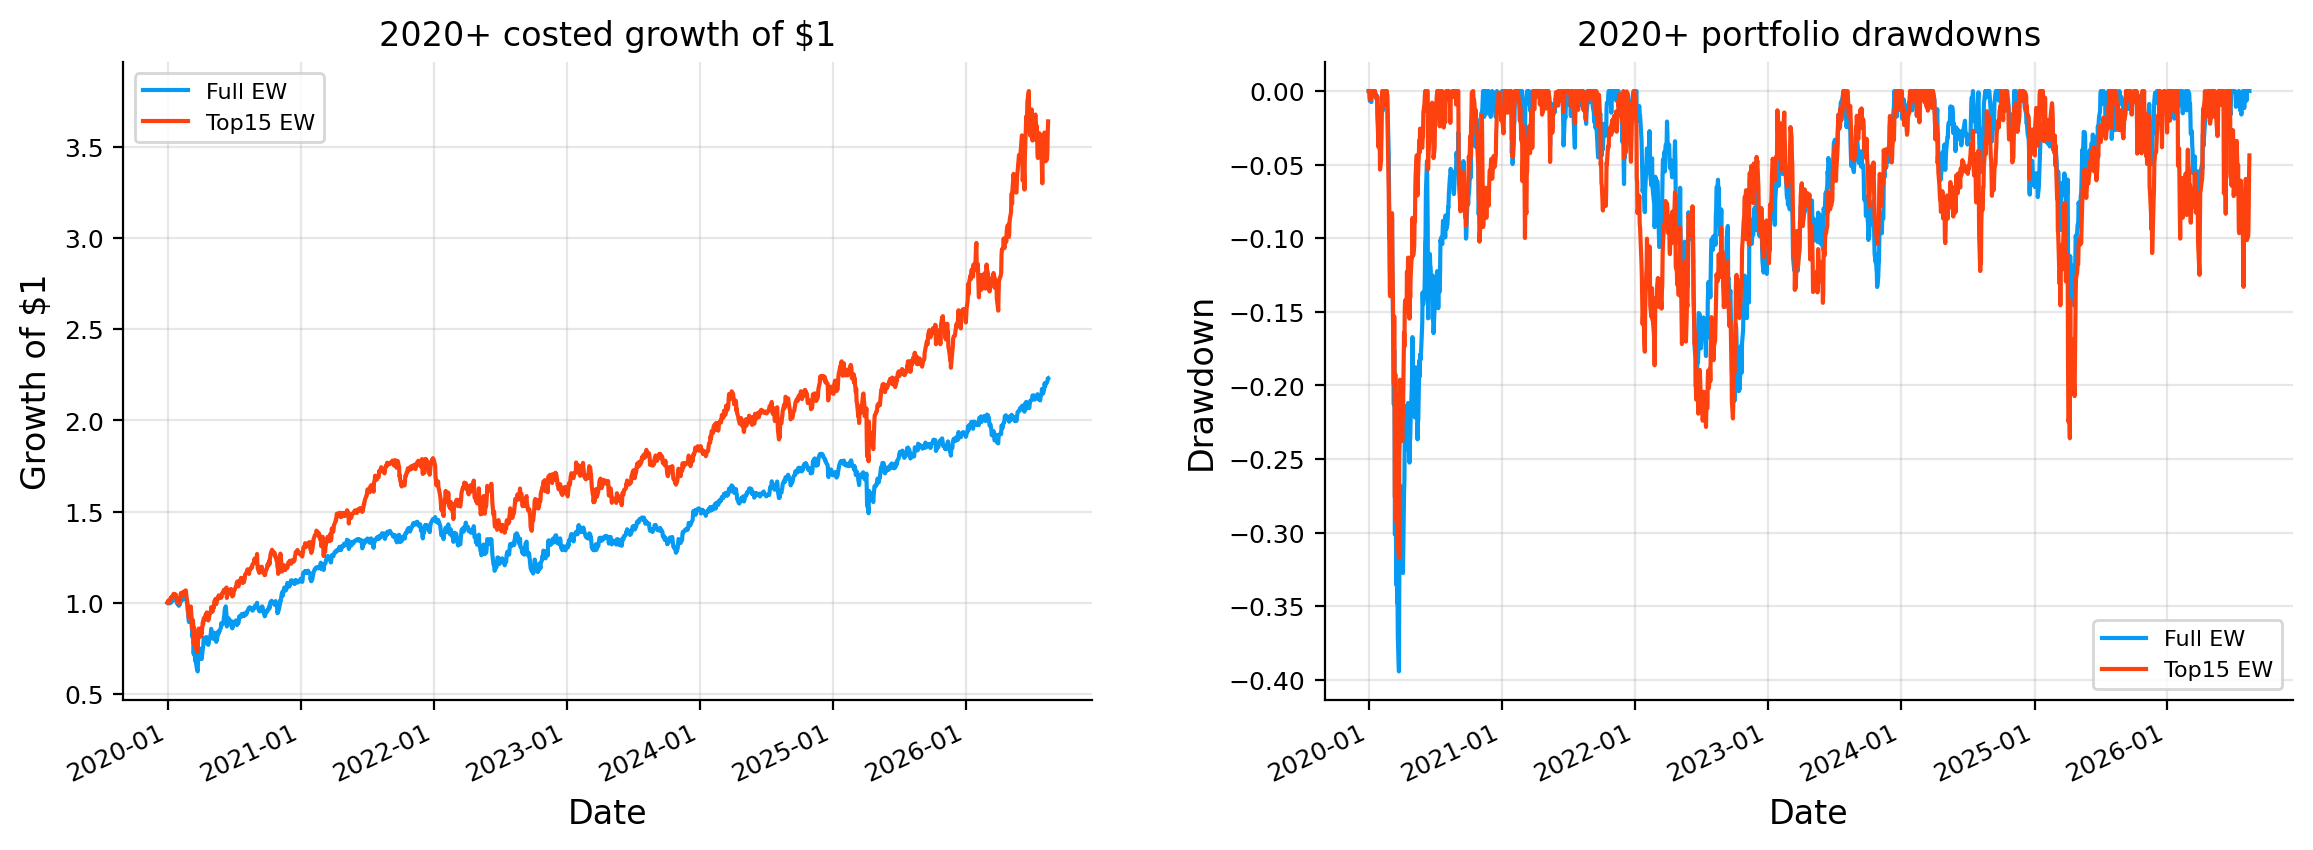

In [57]:
def backtest_from_date(result, start):
    net_returns = pd.Series(result.net_returns, dtype=float).loc[start:].copy()
    gross_returns = pd.Series(result.gross_returns, dtype=float).loc[start:].copy()
    earlier_dates = result.net_values.index[result.net_values.index < start]
    baseline_date = (
        pd.Timestamp(earlier_dates.max())
        if len(earlier_dates)
        else pd.Timestamp(net_returns.index.min()) - pd.Timedelta(days=1)
    )
    net_values = pd.concat([
        pd.Series([1.0], index=[baseline_date], name=result.net_values.name),
        (1.0 + net_returns).cumprod().rename(result.net_values.name),
    ])
    gross_values = pd.concat([
        pd.Series([1.0], index=[baseline_date], name=result.gross_values.name),
        (1.0 + gross_returns).cumprod().rename(result.gross_values.name),
    ])
    metadata_values = dict(result.metadata or {})
    metadata_values["evaluation_start"] = str(pd.Timestamp(start).date())
    return replace(
        result,
        net_returns=net_returns,
        gross_returns=gross_returns,
        net_values=net_values,
        gross_values=gross_values,
        weights=result.weights.loc[result.weights.index >= start].copy(),
        turnover=result.turnover.loc[result.turnover.index >= start].copy(),
        costs=result.costs.loc[result.costs.index >= start].copy(),
        metadata=metadata_values,
    )


def portfolio_table(performance, caption):
    columns = ["CAGR", "Vol", "Sharpe", "Max Drawdown", "Turnover", "Effective N"]
    return (
        performance[columns].style
        .format({
            "CAGR": "{:.1%}", "Vol": "{:.1%}", "Sharpe": "{:.2f}",
            "Max Drawdown": "{:.1%}", "Turnover": "{:.1%}",
            "Effective N": "{:.1f}",
        }, na_rep="—")
        .set_caption(caption)
    )


full_ew = run_equal_weight_walkforward(
    returns=returns,
    rebalance_dates=portfolio_dates,
    universe_by_date=portfolio_universes["Full"],
    max_weight=max_weight,
    min_weight=0.0,
    long_only=True,
    trading_cost_bps=cost_bps,
    rf_daily=rf_daily,
)
top15_ew = run_equal_weight_walkforward(
    returns=returns,
    rebalance_dates=portfolio_dates,
    universe_by_date=portfolio_universes["Top15"],
    max_weight=max_weight,
    min_weight=0.0,
    long_only=True,
    trading_cost_bps=cost_bps,
    rf_daily=rf_daily,
)
layer1_results = {
    "Full EW": backtest_from_date(full_ew, holdout_start),
    "Top15 EW": backtest_from_date(top15_ew, holdout_start),
}
layer1_performance = selection.build_strategy_summary(
    layer1_results, rf_daily=rf_daily, annualization=annualization
)
display(portfolio_table(
    layer1_performance,
    "Layer 1 · frozen evaluation from 2020",
))
layer1_nav = pd.DataFrame({
    name: result.net_values for name, result in layer1_results.items()
}).dropna(how="all")
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
portfolio_plots.plot_strategy_nav(
    layer1_nav, ax=axes[0], title="2020+ costed growth of $1",
    summary=layer1_performance, apply_style=False,
)
portfolio_plots.plot_strategy_drawdowns(
    layer1_nav, ax=axes[1], title="2020+ portfolio drawdowns",
    summary=layer1_performance, apply_style=False,
)
portfolio_plots.apply_portfolio_subplot_layout(
    fig, axes, hspace=0.28, wspace=0.24, bottom=0.18, top=0.94,
)
plt.show()


,CAGR,Vol,Sharpe,Max Drawdown,Turnover,Effective N
Strategy,,,,,,
Top15 EW,21.6%,25.5%,0.78,-31.7%,27.6%,15.0
Top50 EW,13.5%,21.7%,0.56,-34.8%,16.3%,50.0
Top100 EW,13.9%,20.5%,0.60,-34.8%,11.3%,100.0


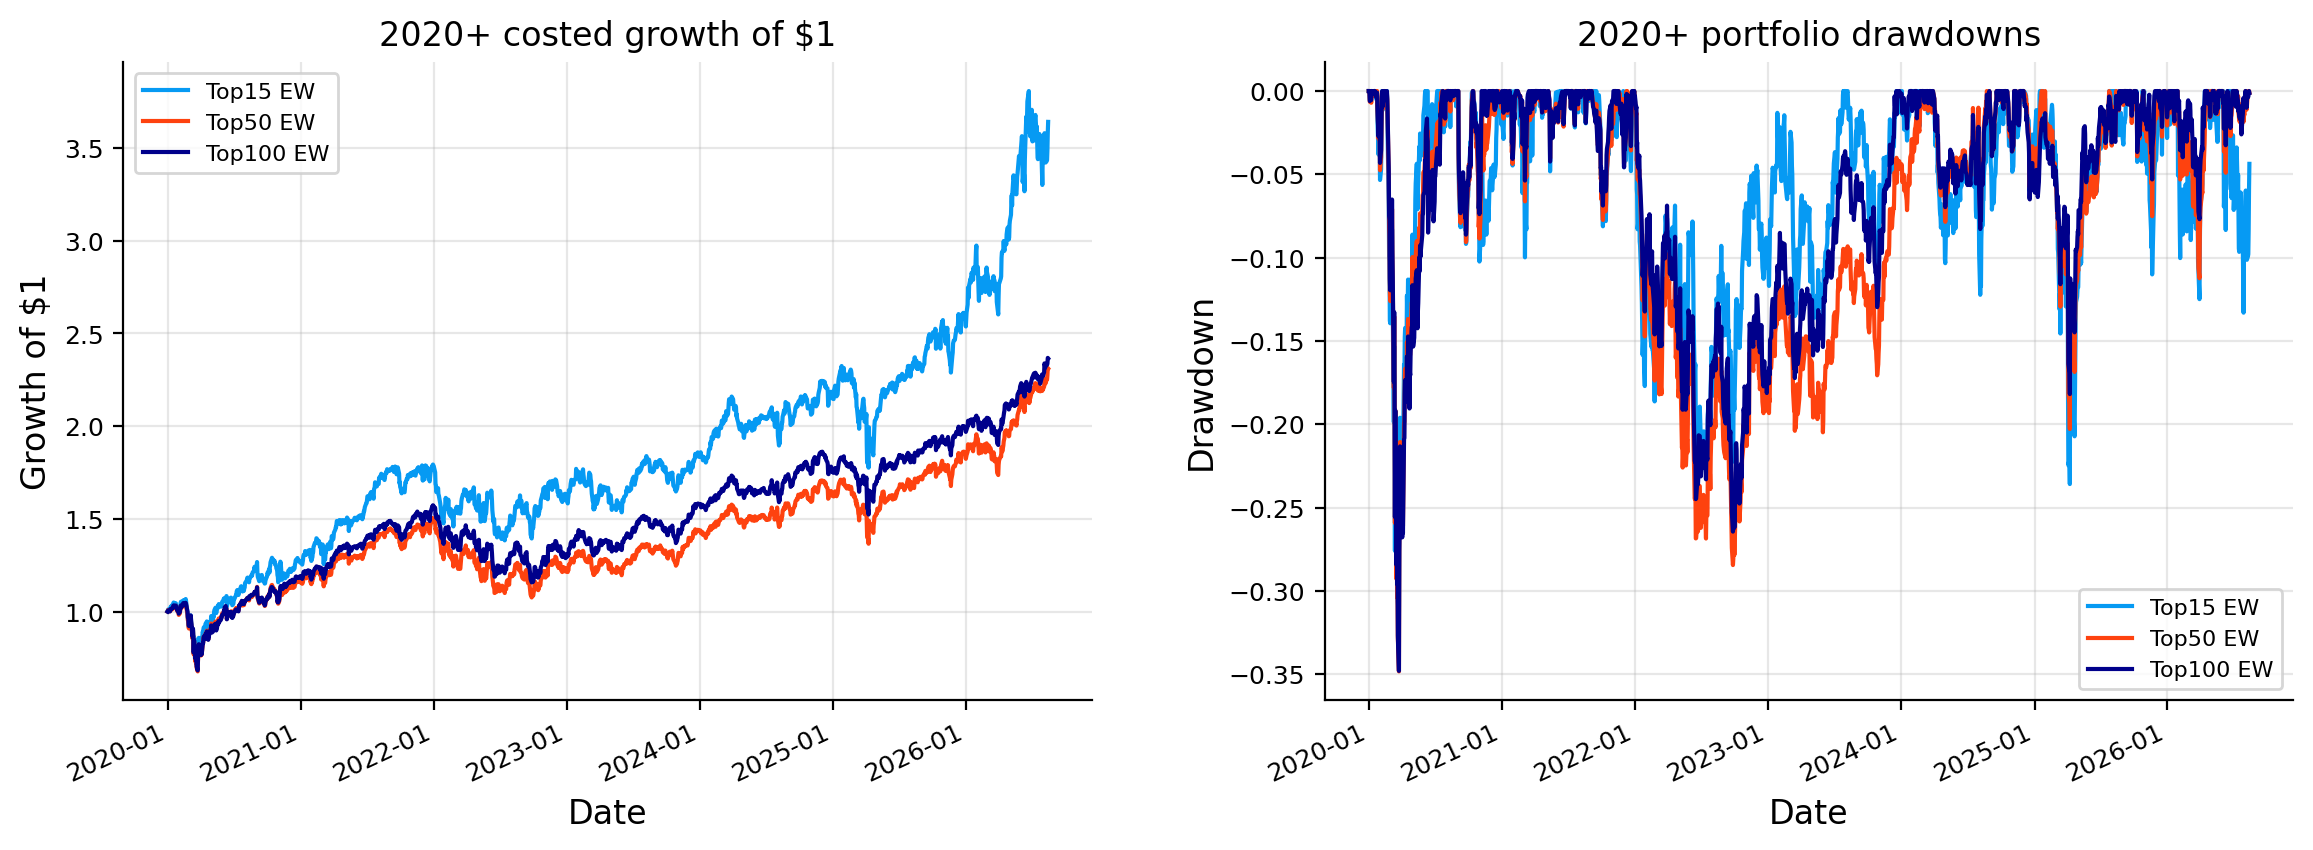

In [58]:
top50_ew = run_equal_weight_walkforward(
    returns=returns,
    rebalance_dates=portfolio_dates,
    universe_by_date=portfolio_universes["Top50"],
    max_weight=max_weight,
    min_weight=0.0,
    long_only=True,
    trading_cost_bps=cost_bps,
    rf_daily=rf_daily,
)
top100_ew = run_equal_weight_walkforward(
    returns=returns,
    rebalance_dates=portfolio_dates,
    universe_by_date=portfolio_universes["Top100"],
    max_weight=max_weight,
    min_weight=0.0,
    long_only=True,
    trading_cost_bps=cost_bps,
    rf_daily=rf_daily,
)
layer2_results = {
    "Top15 EW": backtest_from_date(top15_ew, holdout_start),
    "Top50 EW": backtest_from_date(top50_ew, holdout_start),
    "Top100 EW": backtest_from_date(top100_ew, holdout_start),
}
layer2_performance = selection.build_strategy_summary(
    layer2_results, rf_daily=rf_daily, annualization=annualization
)
display(portfolio_table(
    layer2_performance,
    "Layer 2 · frozen breadth comparison from 2020",
))
layer2_nav = pd.DataFrame({
    name: result.net_values for name, result in layer2_results.items()
}).dropna(how="all")
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
portfolio_plots.plot_strategy_nav(
    layer2_nav, ax=axes[0], title="2020+ costed growth of $1",
    summary=layer2_performance, apply_style=False,
)
portfolio_plots.plot_strategy_drawdowns(
    layer2_nav, ax=axes[1], title="2020+ portfolio drawdowns",
    summary=layer2_performance, apply_style=False,
)
portfolio_plots.apply_portfolio_subplot_layout(
    fig, axes, hspace=0.28, wspace=0.24, bottom=0.18, top=0.94,
)
plt.show()


,CAGR,Vol,Sharpe,Max Drawdown,Turnover,Effective N
Strategy,,,,,,
WRO,21.9%,22.9%,0.85,-28.3%,37.1%,8.1
Mean-CVaR,23.5%,25.2%,0.85,-32.5%,45.9%,7.6
MV,20.9%,22.0%,0.84,-28.3%,29.6%,8.1
NCO,21.3%,22.9%,0.83,-28.8%,42.8%,10.7
MaxSharpe,27.0%,32.3%,0.81,-30.6%,33.6%,7.0
Risk Parity,20.1%,22.6%,0.79,-31.3%,32.6%,13.3
EW,21.6%,25.5%,0.78,-31.7%,27.6%,15.0
MinVar,18.7%,21.2%,0.78,-30.1%,22.7%,7.9
HRP,18.4%,21.9%,0.75,-31.0%,36.8%,11.6


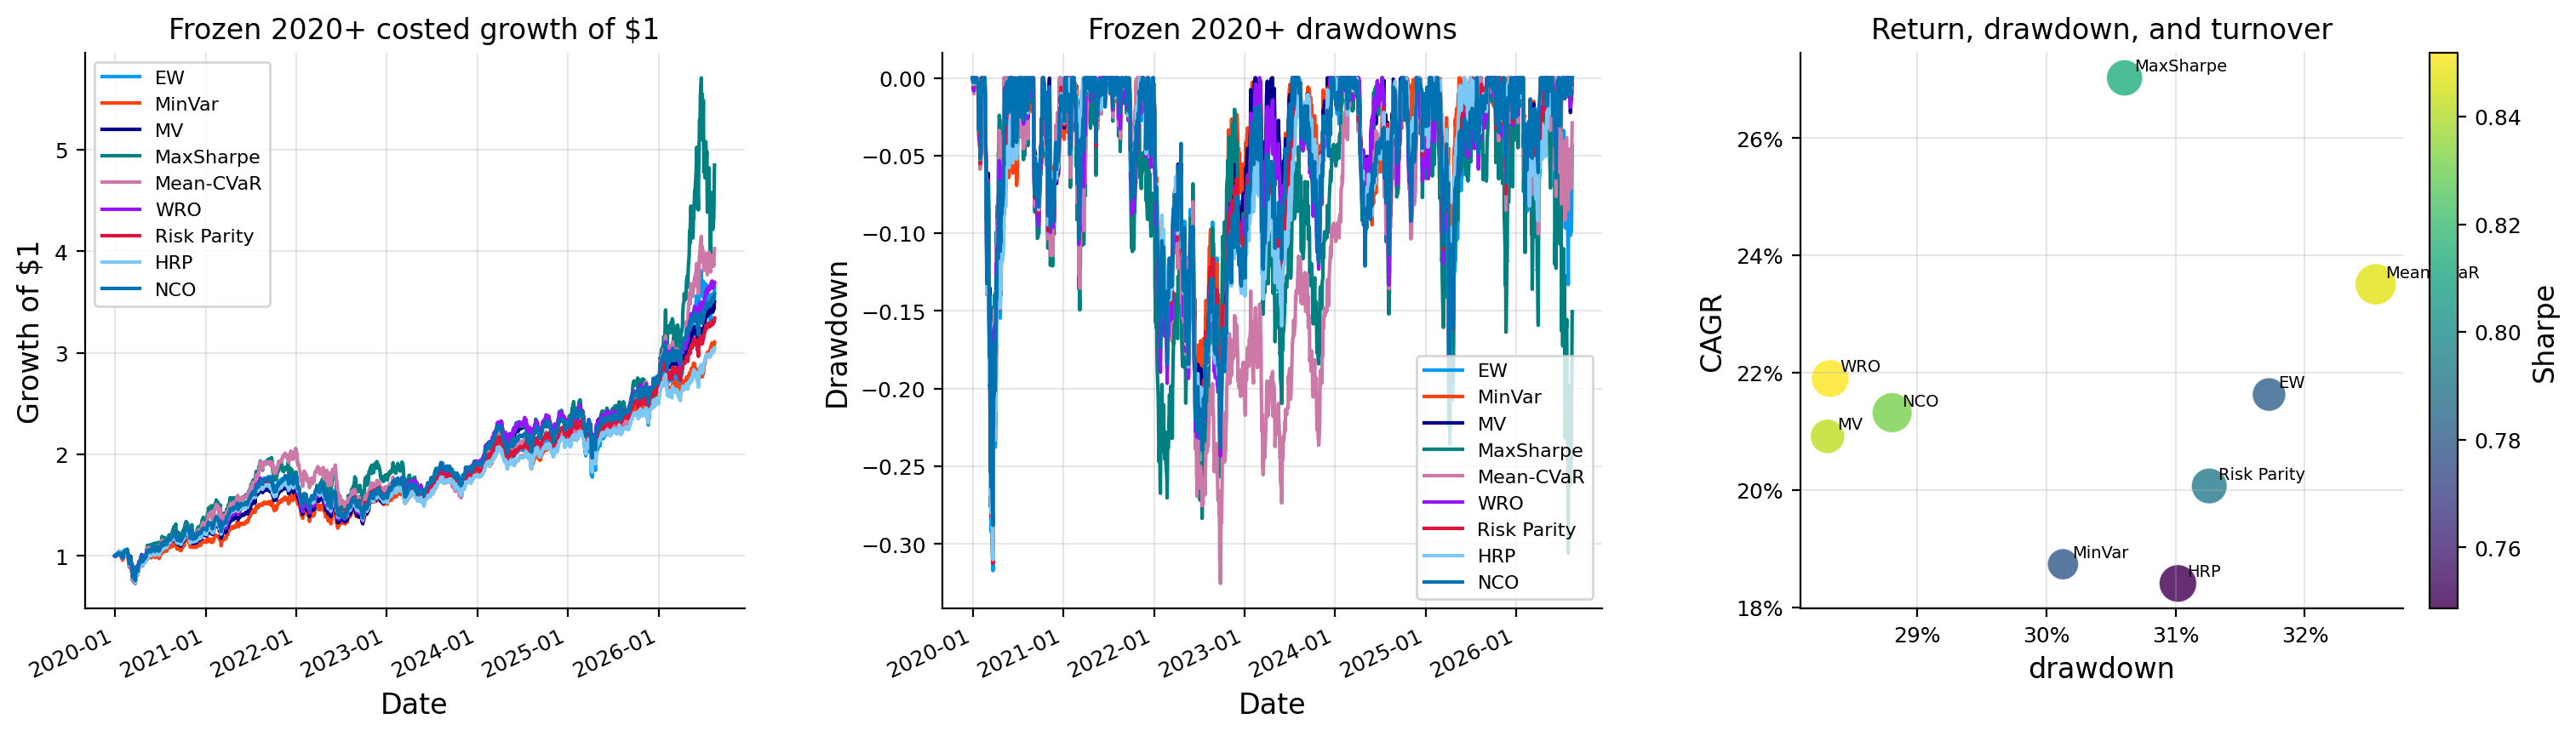

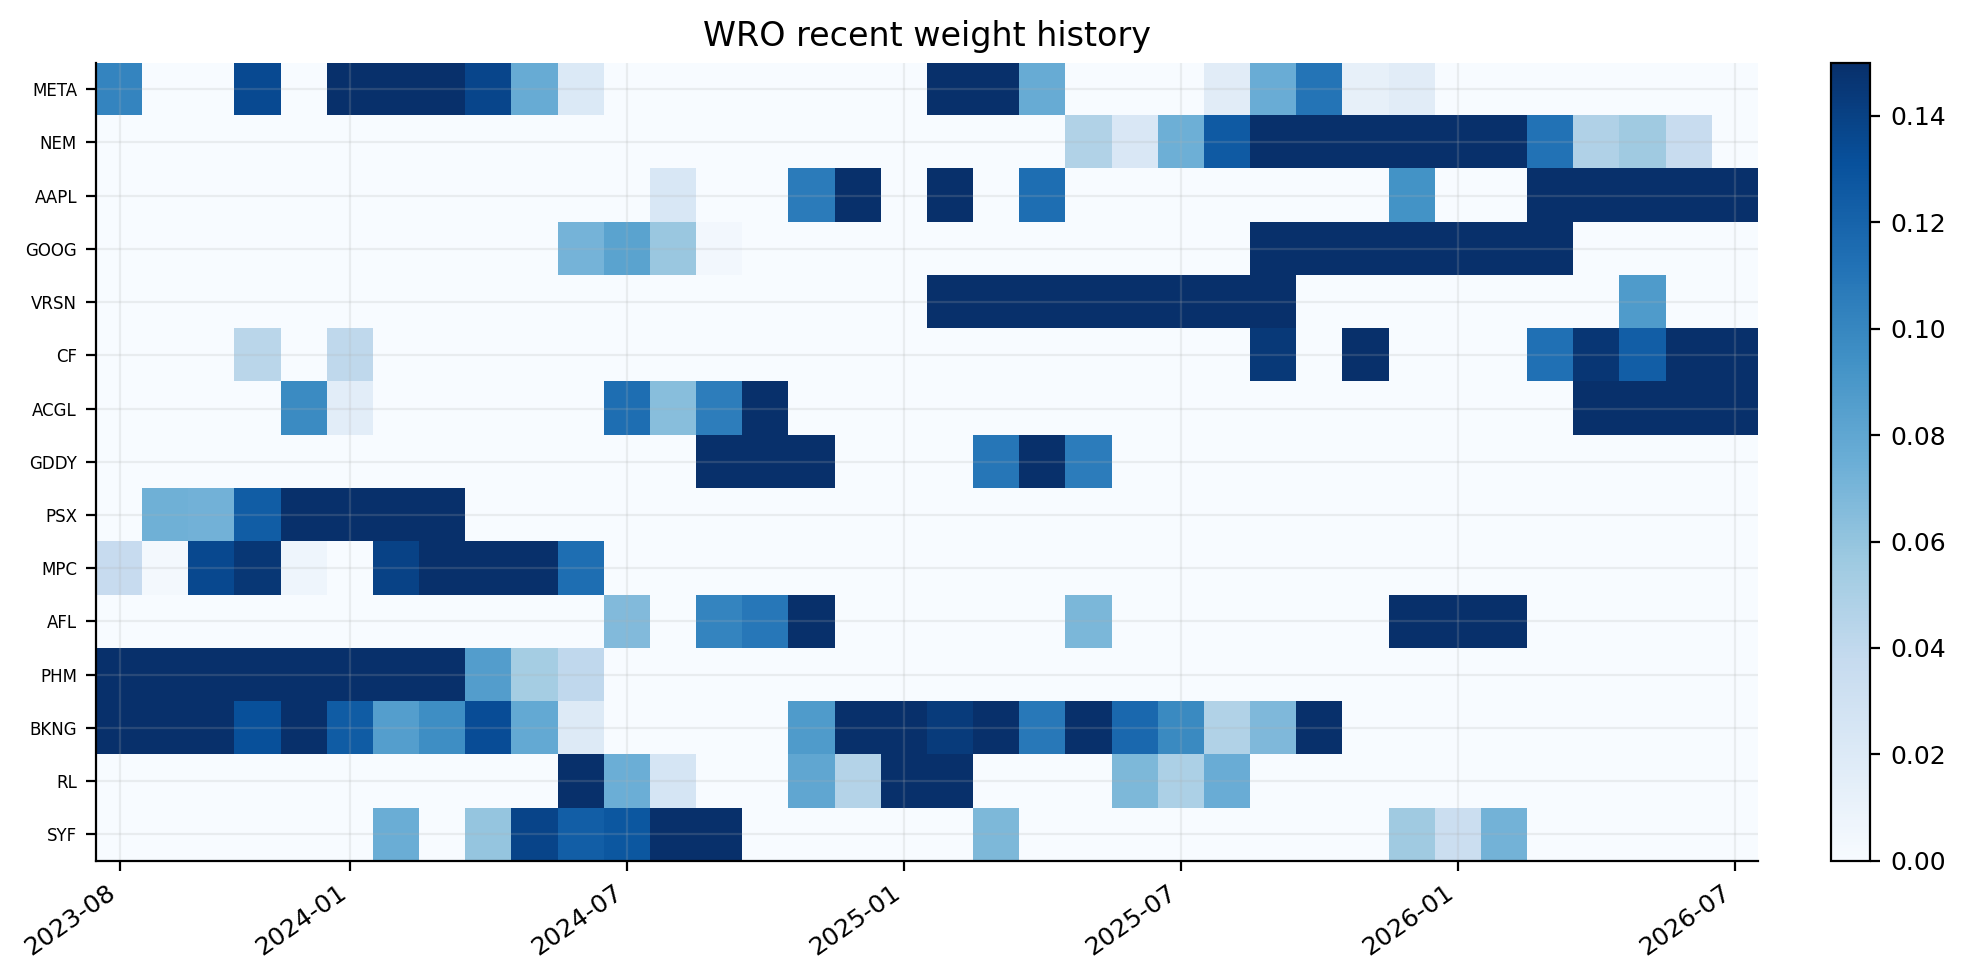

In [59]:
frozen_core_specs = []
for family in ("MinVar", "MV", "MaxSharpe"):
    family_settings = frozen_settings["core"][family]
    spec = {
        "name": family,
        "optimizer": family,
        "cov_model": family_settings["cov_model"],
    }
    if family != "MinVar":
        spec["mu_model"] = family_settings["mu_model"]
    frozen_core_specs.append(spec)

top15_grid = run_walkforward_grid(
    returns=returns,
    close=adj_close_filled,
    rebalance_dates=portfolio_dates,
    universe_by_date=portfolio_universes["Top15"],
    cov_lookback=frozen_settings["global"]["lookback"],
    mu_lookback=frozen_settings["global"]["lookback"],
    min_cov_observations=frozen_settings["global"]["minimum_observations"],
    min_mu_observations=frozen_settings["global"]["minimum_observations"],
    max_weight=frozen_settings["global"]["maximum_weight"],
    min_weight=0.0,
    long_only=True,
    trading_cost_bps=cost_bps,
    turnover_penalty_bps=frozen_settings["global"]["turnover_penalty_bps"],
    optimizer_params={"MV": {"mv_lambda": frozen_settings["core"]["MV"]["mv_lambda"]}},
    blend_by_optimizer={
        family: frozen_settings["core"][family]["blend"]
        for family in frozen_settings["core"]
    },
    fallback="equal",
    rf_daily=rf_daily,
    annualization=annualization,
    momentum_mode="6-1",
    cov_models=tuning_cov_models,
    mu_models=tuning_mu_models,
    optimizers=tuning_optimizers,
    strategy_specs=frozen_core_specs,
)
top15_results_full = {"EW": top15_ew, **top15_grid.backtests}
top15_dates = list(top15_grid.metadata["rebalance_dates"])

with warnings.catch_warnings(record=True) as holdout_cvar_warnings:
    warnings.simplefilter("always")
    additional_weights = advanced_weight_schedule(
        top15_grid.cache,
        top15_dates,
        frozen_settings["global"]["maximum_weight"],
        frozen_settings["advanced"],
    )
additional_results_full = run_many_weights_backtests(
    additional_weights,
    returns=returns,
    cost_bps=cost_bps,
    rf_daily=rf_daily,
    w_min=0.0,
    w_max=frozen_settings["global"]["maximum_weight"],
    long_only=True,
    normalize=True,
    weight_timing="same_day",
)
layer3_results_full = {**top15_results_full, **additional_results_full}
layer3_results = {
    name: backtest_from_date(result, holdout_start)
    for name, result in layer3_results_full.items()
}
layer3_performance = selection.build_strategy_summary(
    layer3_results, rf_daily=rf_daily, annualization=annualization
).sort_values(["Sharpe", "Max Drawdown"], ascending=[False, False])

strategy_returns = pd.DataFrame({
    name: result.net_returns for name, result in layer3_results.items()
}).dropna(how="all")
strategy_weights = pd.concat(
    {
        name: result.weights.stack().rename("weight")
        for name, result in layer3_results.items()
    },
    names=["strategy", "execution_date", "ticker"],
).reset_index()
weight_sums = strategy_weights.groupby(["strategy", "execution_date"])["weight"].sum()
assert np.allclose(weight_sums, 1.0, atol=1e-5)
assert strategy_returns.index.min() >= holdout_start
assert all(
    result.metadata.get("weight_timing") == "same_day"
    for result in additional_results_full.values()
)
display(portfolio_table(
    layer3_performance,
    "Layer 3 · settings selected in 2013–2019 and frozen for 2020+",
))
layer3_nav = pd.DataFrame({
    name: result.net_values for name, result in layer3_results.items()
}).dropna(how="all")
layer3_plot = layer3_performance.assign(
    drawdown=layer3_performance["Max Drawdown"].abs()
)
fig, axes = plt.subplots(1, 3, figsize=(18, 4.3))
portfolio_plots.plot_strategy_nav(
    layer3_nav, ax=axes[0], title="Frozen 2020+ costed growth of $1",
    summary=layer3_performance, apply_style=False,
)
portfolio_plots.plot_strategy_drawdowns(
    layer3_nav, ax=axes[1], title="Frozen 2020+ drawdowns",
    summary=layer3_performance, apply_style=False,
)
portfolio_plots.plot_risk_return_scatter(
    layer3_plot, ax=axes[2], title="Return, drawdown, and turnover",
    risk_col="drawdown", return_col="CAGR", color_col="Sharpe",
    size_col="Turnover", apply_style=False,
)
axes[2].xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
axes[2].yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
portfolio_plots.apply_portfolio_subplot_layout(
    fig, axes, hspace=0.28, wspace=0.30, bottom=0.18, top=0.94,
)
plt.show()

best_model = layer3_performance.index[0]
best_weights = layer3_results[best_model].weights.sort_index().tail(36)
main_tickers = best_weights.mean().nlargest(15).index
weight_view = best_weights[main_tickers].T
fig, ax = plt.subplots(figsize=(10, 5.0))
portfolio_plots.weight_heatmap(
    ax, weight_view, title=f"{best_model} recent weight history",
    top_n=15, cmap="Blues",
)
tick_positions = np.linspace(0, len(weight_view.columns) - 1, 7).astype(int)
ax.set_xticks(
    tick_positions,
    [weight_view.columns[position].strftime("%Y-%m") for position in tick_positions],
    rotation=35, ha="right",
)
plt.tight_layout()
plt.show()

top15_grid.cache.clear()
top15_grid.metadata.pop("_returns_source", None)


,ann_return,ann_vol,sharpe,sortino
object,,,,
EW,0.2163,0.2552,0.7806,1.1079
HRP,0.1841,0.2186,0.7486,1.0600
MV,0.2091,0.2196,0.8417,1.1949
MaxSharpe,0.2703,0.3229,0.8125,1.1538
Mean-CVaR,0.2351,0.2524,0.8474,1.1974
MinVar,0.1873,0.2120,0.7783,1.1073
NCO,0.2132,0.2289,0.8313,1.1768
Risk Parity,0.2007,0.2265,0.7920,1.1222
WRO,0.2190,0.2290,0.8519,1.2085


,hist_var5,hist_es5,cf_var5,cf_es5,fhs_var5,fhs_es5
object,,,,,,
EW,0.0245,0.0380,0.0234,0.0548,0.0362,0.0518
HRP,0.0196,0.0327,0.0192,0.0538,0.0122,0.0175
MV,0.0198,0.0322,0.0199,0.0508,0.0136,0.0193
MaxSharpe,0.0326,0.0487,0.0316,0.0574,0.0759,0.1103
Mean-CVaR,0.0242,0.0377,0.0244,0.0507,0.0292,0.0422
MinVar,0.0183,0.0311,0.0182,0.0541,0.0124,0.0174
NCO,0.0221,0.0339,0.0209,0.0520,0.0121,0.0177
Risk Parity,0.0206,0.0339,0.0199,0.0551,0.0119,0.0171
WRO,0.0212,0.0336,0.0212,0.0503,0.0122,0.0177


breach_count  breach_rate  coverage_error  abs_coverage_error  longest_breach_streak  avg_gap_days  kupiec_p  christoffersen_p  quantile_loss  accuracy_rank  \
object      method                                                                                                                                                                 
EW          cf                89       0.0631          0.0131              0.0131                      3       15.5341    0.0300            0.3093         0.0017            3.0   
            fhs               75       0.0532          0.0032              0.0032                      3       18.3243    0.5904            0.1457         0.0017            1.0   
            hist              80       0.0567          0.0067              0.0067                      3       17.3038    0.2580            0.2524         0.0017            2.0   
HRP         cf                79       0.0560          0.0060              0.0060                      3       16.4487    0.3108            0.2278         0.0014            3.0   
            fhs               74       0.0524          0.0024              0.0024                      3       18.5753    0.6758            0.0171         0.0014            2.0   
            hist              70       0.0496         -0.0004              0.0004                      3       18.5942    0.9464            0.1919         0.0014            1.0   
MV          cf                74       0.0524          0.0024              0.0024                      3       18.2466    0.6758            0.2900         0.0014            2.0   
            fhs               77       0.0546          0.0046              0.0046                      3       17.8421    0.4372            0.0028         0.0014            3.0   
            hist              70       0.0496         -0.0004              0.0004                      3       19.3043    0.9464            0.1919         0.0014            1.0   
MaxSharpe   cf                87       0.0617          0.0117              0.0117                      3       16.0465    0.0522            0.0534         0.0023            2.0   
            fhs               76       0.0539          0.0039              0.0039                      3       18.1200    0.5106            0.0079         0.0021            1.0   
            hist              88       0.0624          0.0124              0.0124                      3       15.8621    0.0398            0.0618         0.0023            3.0   
Mean-CVaR   cf                77       0.0546          0.0046              0.0046                      3       18.0395    0.4372            0.0289         0.0017            1.0   
            fhs               80       0.0567          0.0067              0.0067                      3       17.2025    0.2580            0.0169         0.0017            2.0   
            hist              80       0.0567          0.0067              0.0067                      3       17.3544    0.2580            0.0169         0.0017            3.0   
MinVar      cf                76       0.0539          0.0039              0.0039                      3       17.0000    0.5106            0.0079         0.0013            3.0   
            fhs               73       0.0517          0.0017              0.0017                      3       18.7222    0.7660            0.0011         0.0013            2.0   
            hist              70       0.0496         -0.0004              0.0004                      3       18.4783    0.9464            0.0021         0.0013            1.0   
NCO         cf                91       0.0645          0.0145              0.0145                      3       14.8444    0.0166            0.1963         0.0015            3.0   
            fhs               79       0.0560          0.0060              0.0060                      3       17.3846    0.3108            0.0400         0.0015            1.0   
            hist              79       0.0560          0.006

,object,cum_return,max_dd,worst_day,worst_week
window,,,,,
2022 inflation shock,EW,-0.0667,-0.2135,-0.0597,-0.0857
2022 inflation shock,HRP,-0.0998,-0.2208,-0.0528,-0.0730
2022 inflation shock,MV,-0.0705,-0.2066,-0.0529,-0.0752
2022 inflation shock,MaxSharpe,0.0228,-0.2312,-0.0948,-0.1297
2022 inflation shock,Mean-CVaR,-0.1703,-0.3084,-0.0697,-0.1287
2022 inflation shock,MinVar,-0.0298,-0.1997,-0.0513,-0.0701
2022 inflation shock,NCO,-0.0976,-0.2236,-0.0551,-0.0775
2022 inflation shock,Risk Parity,-0.0854,-0.2133,-0.0518,-0.0773
2022 inflation shock,WRO,-0.0751,-0.2156,-0.0542,-0.0776


,alpha_daily,alpha_ann,beta,r2,tracking_error,information_ratio,up_capture,down_capture,systematic_var_share
object,,,,,,,,,
EW,0.0004,0.0959,0.9395,0.5989,0.1621,0.5223,0.9952,0.9113,0.5989
HRP,0.0003,0.0682,0.8530,0.6729,0.1288,0.3813,0.8661,0.7989,0.6729
MV,0.0004,0.1000,0.7815,0.5596,0.1528,0.4602,0.8119,0.7162,0.5596
MaxSharpe,0.0006,0.1749,0.8829,0.3304,0.2654,0.5570,1.0062,0.8618,0.3304
Mean-CVaR,0.0005,0.1282,0.8141,0.4597,0.1896,0.5240,0.8682,0.7519,0.4597
MinVar,0.0003,0.0772,0.7909,0.6151,0.1387,0.3638,0.7885,0.7090,0.6151
NCO,0.0004,0.0984,0.8415,0.5972,0.1491,0.5082,0.8873,0.7969,0.5972
Risk Parity,0.0003,0.0817,0.8801,0.6674,0.1330,0.4873,0.9040,0.8267,0.6674
WRO,0.0004,0.1096,0.7952,0.5327,0.1624,0.4962,0.8400,0.7381,0.5327


,EW,MinVar,MV,MaxSharpe,Mean-CVaR,WRO,Risk Parity,HRP,NCO
EW,1.0000,0.8850,0.9112,0.9137,0.9266,0.9199,0.9652,0.9458,0.9460
MinVar,0.8850,1.0000,0.9642,0.7239,0.8684,0.9371,0.9588,0.9687,0.9461
MV,0.9112,0.9642,1.0000,0.8141,0.9265,0.9921,0.9632,0.9630,0.9672
MaxSharpe,0.9137,0.7239,0.8141,1.0000,0.9063,0.8517,0.8234,0.7937,0.8318
Mean-CVaR,0.9266,0.8684,0.9265,0.9063,1.0000,0.9431,0.9217,0.9109,0.9233
WRO,0.9199,0.9371,0.9921,0.8517,0.9431,1.0000,0.9568,0.9504,0.9660
Risk Parity,0.9652,0.9588,0.9632,0.8234,0.9217,0.9568,1.0000,0.9931,0.9798
HRP,0.9458,0.9687,0.9630,0.7937,0.9109,0.9504,0.9931,1.0000,0.9725
NCO,0.9460,0.9461,0.9672,0.8318,0.9233,0.9660,0.9798,0.9725,1.0000


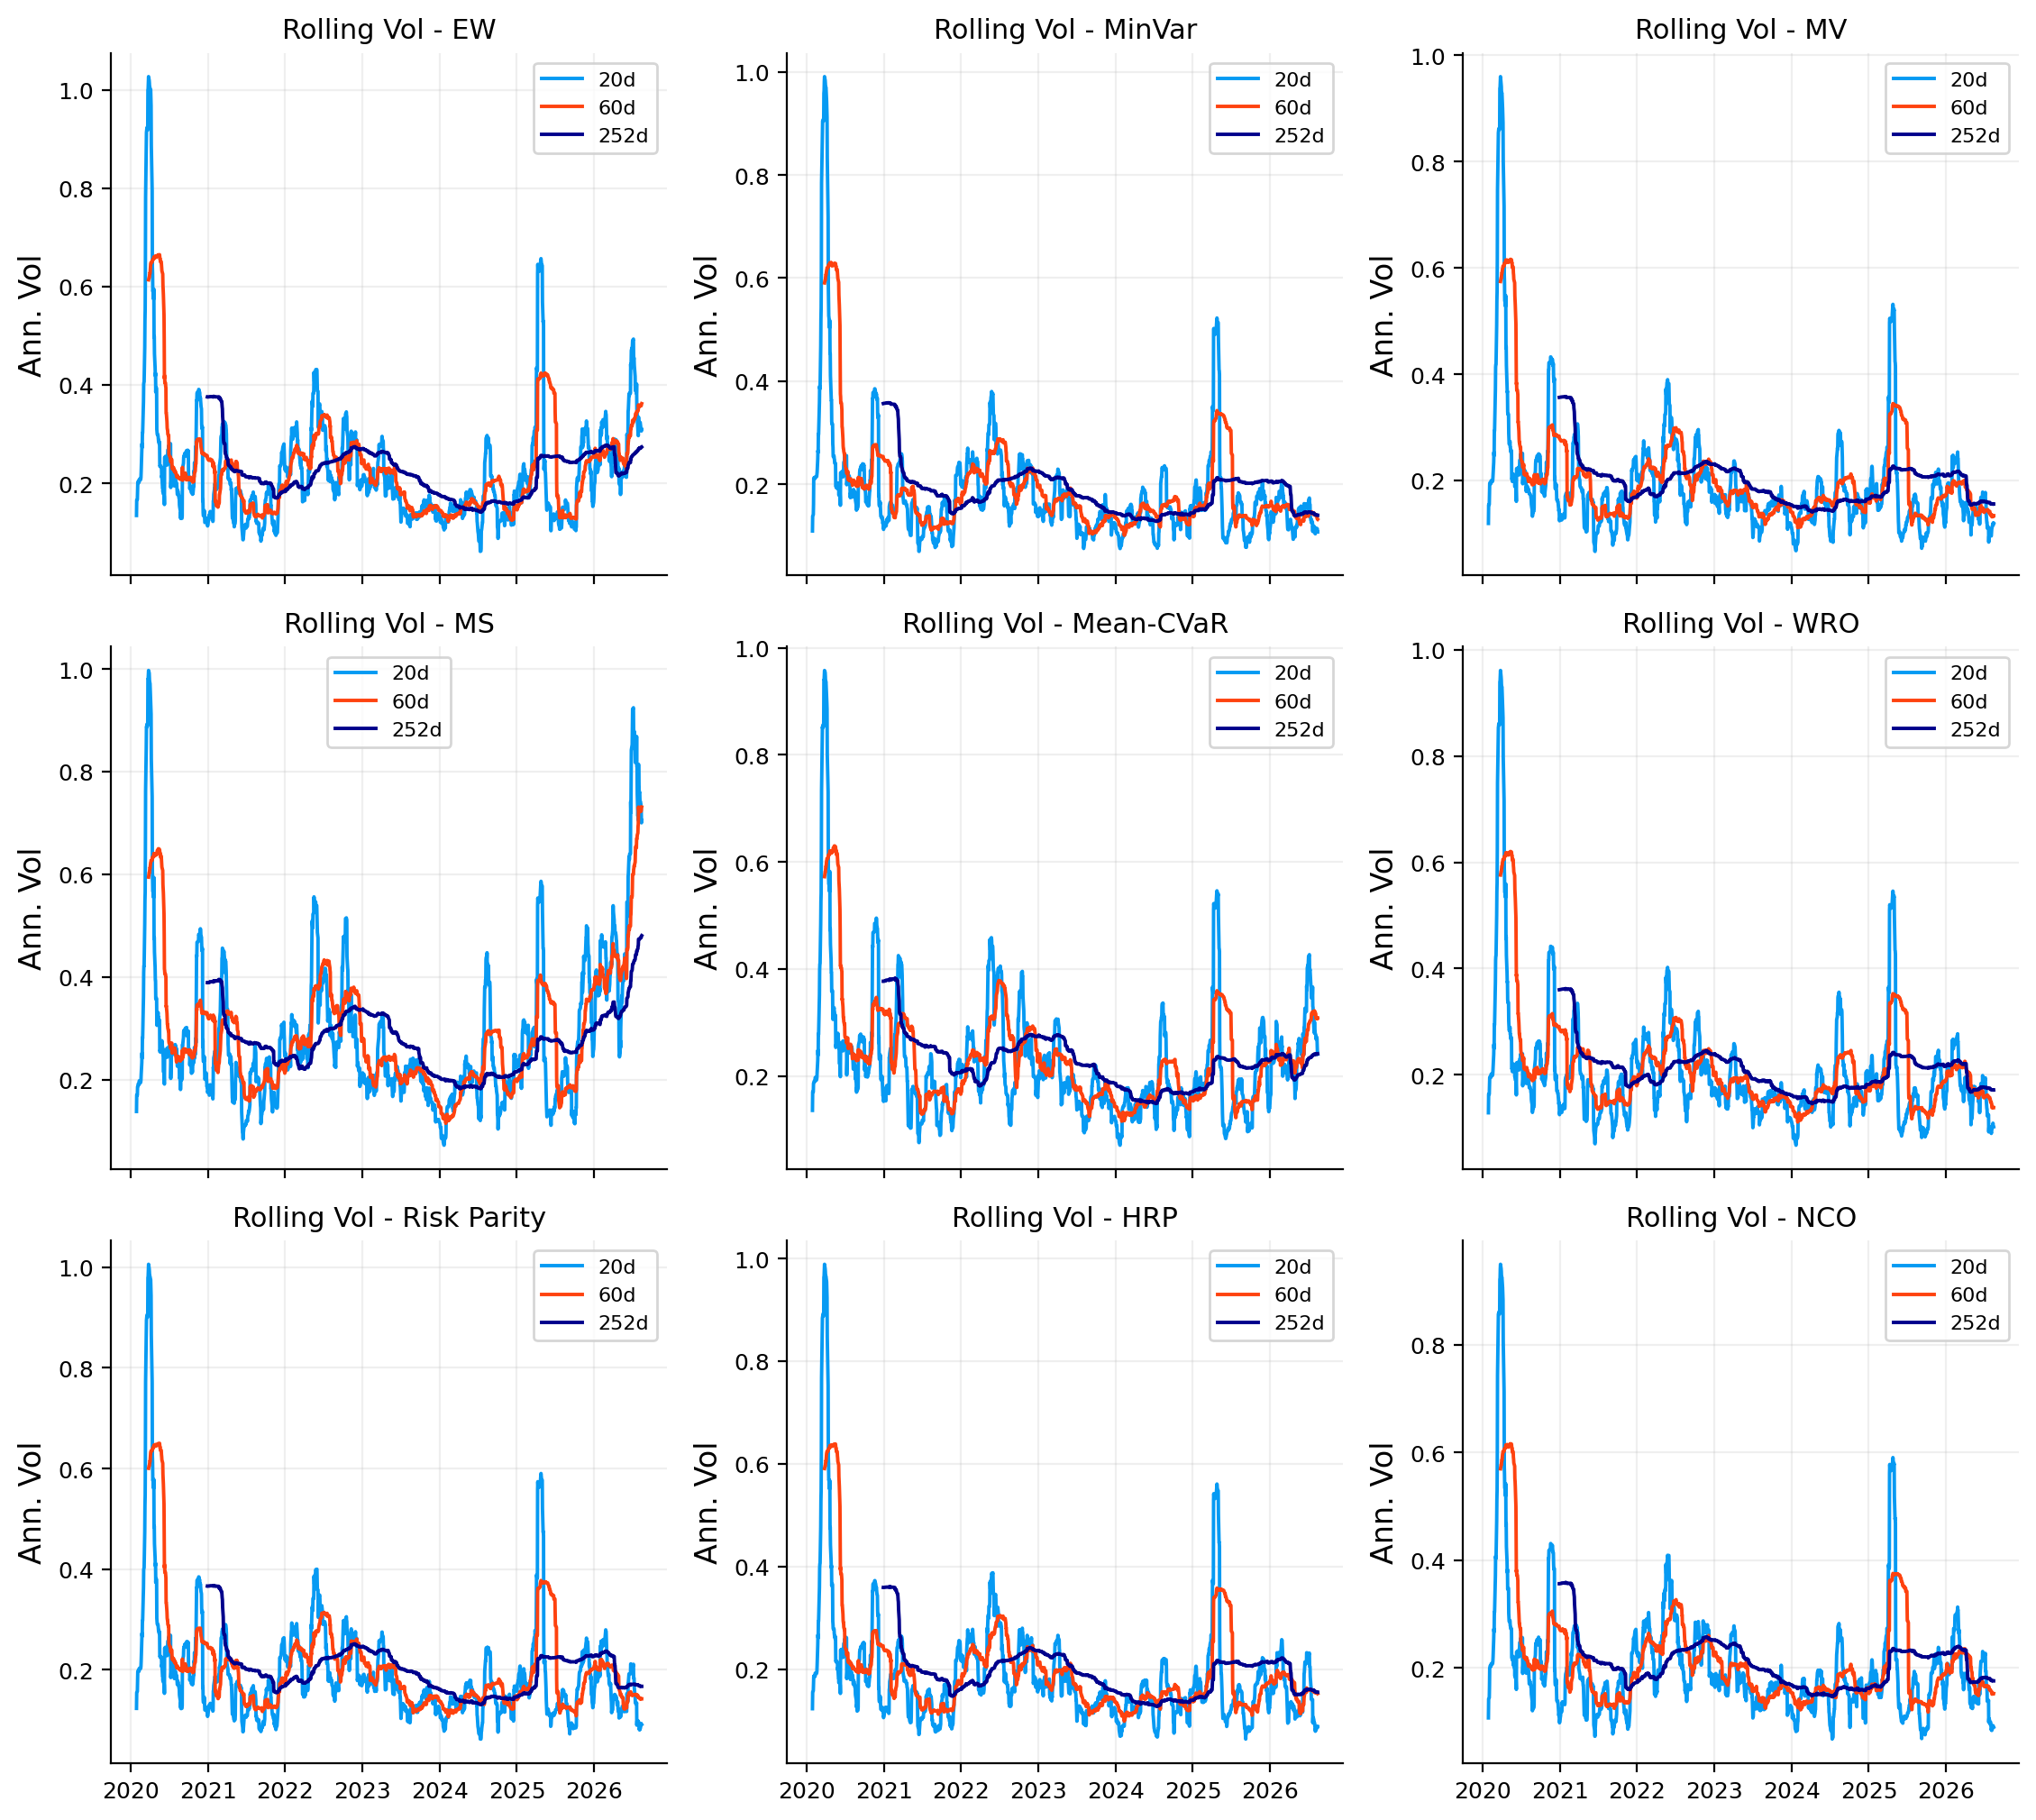

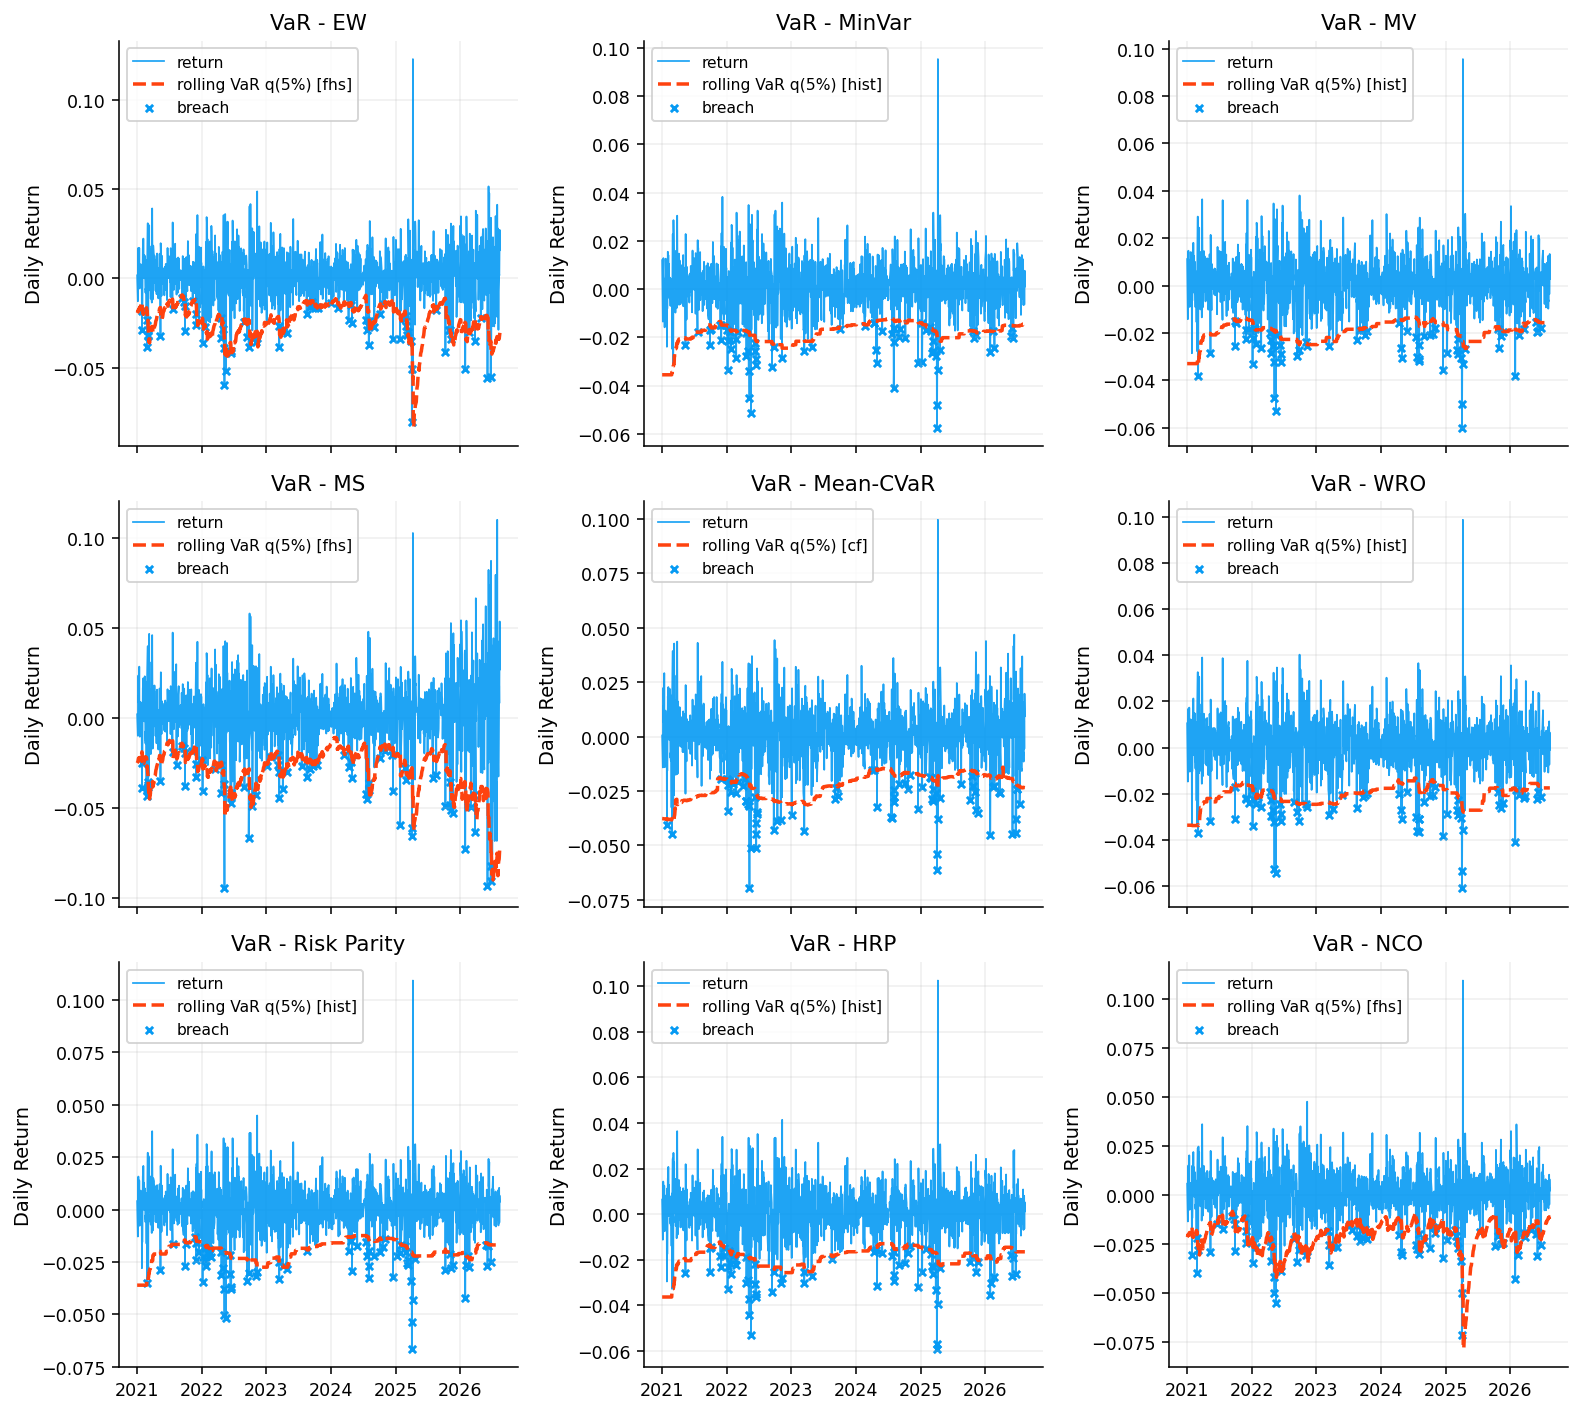

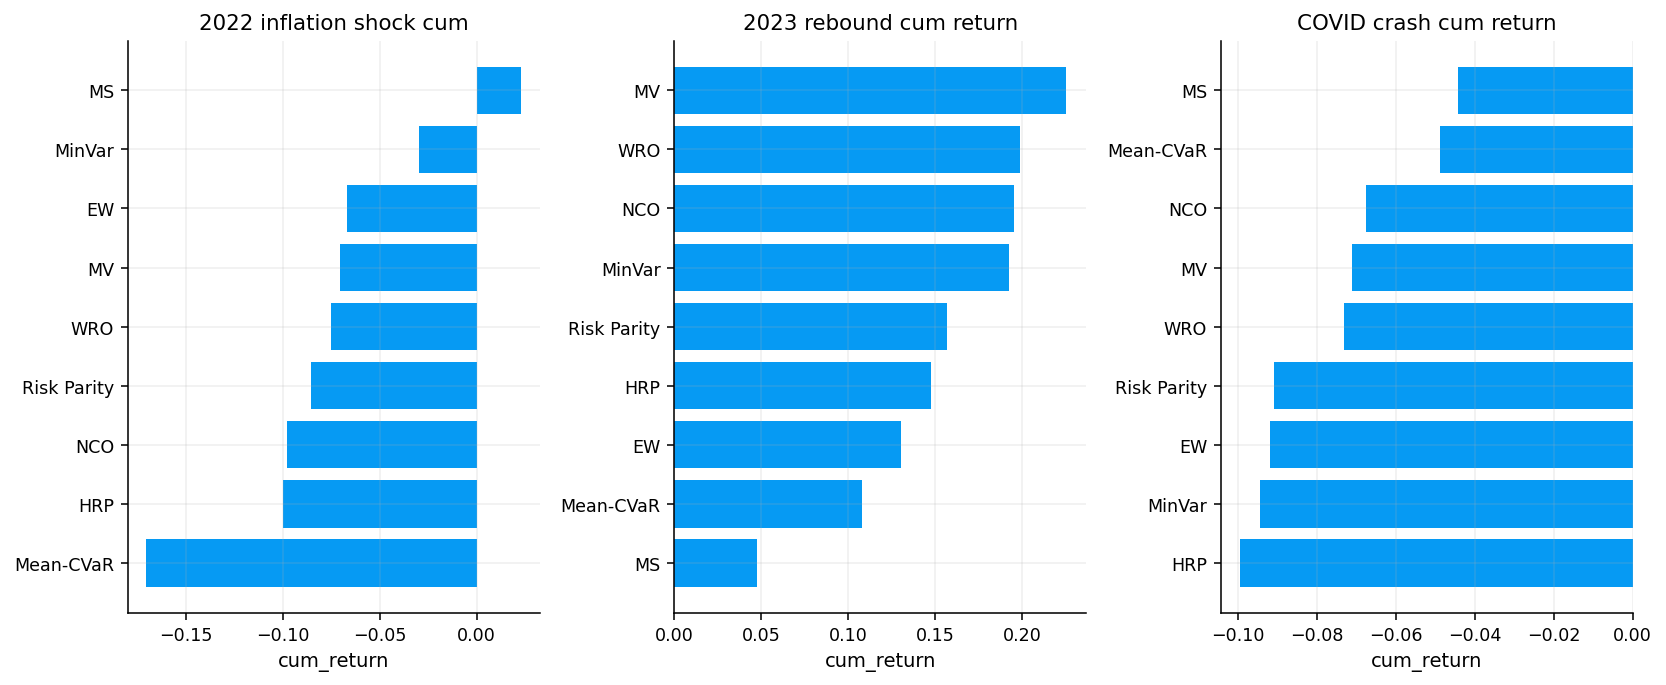

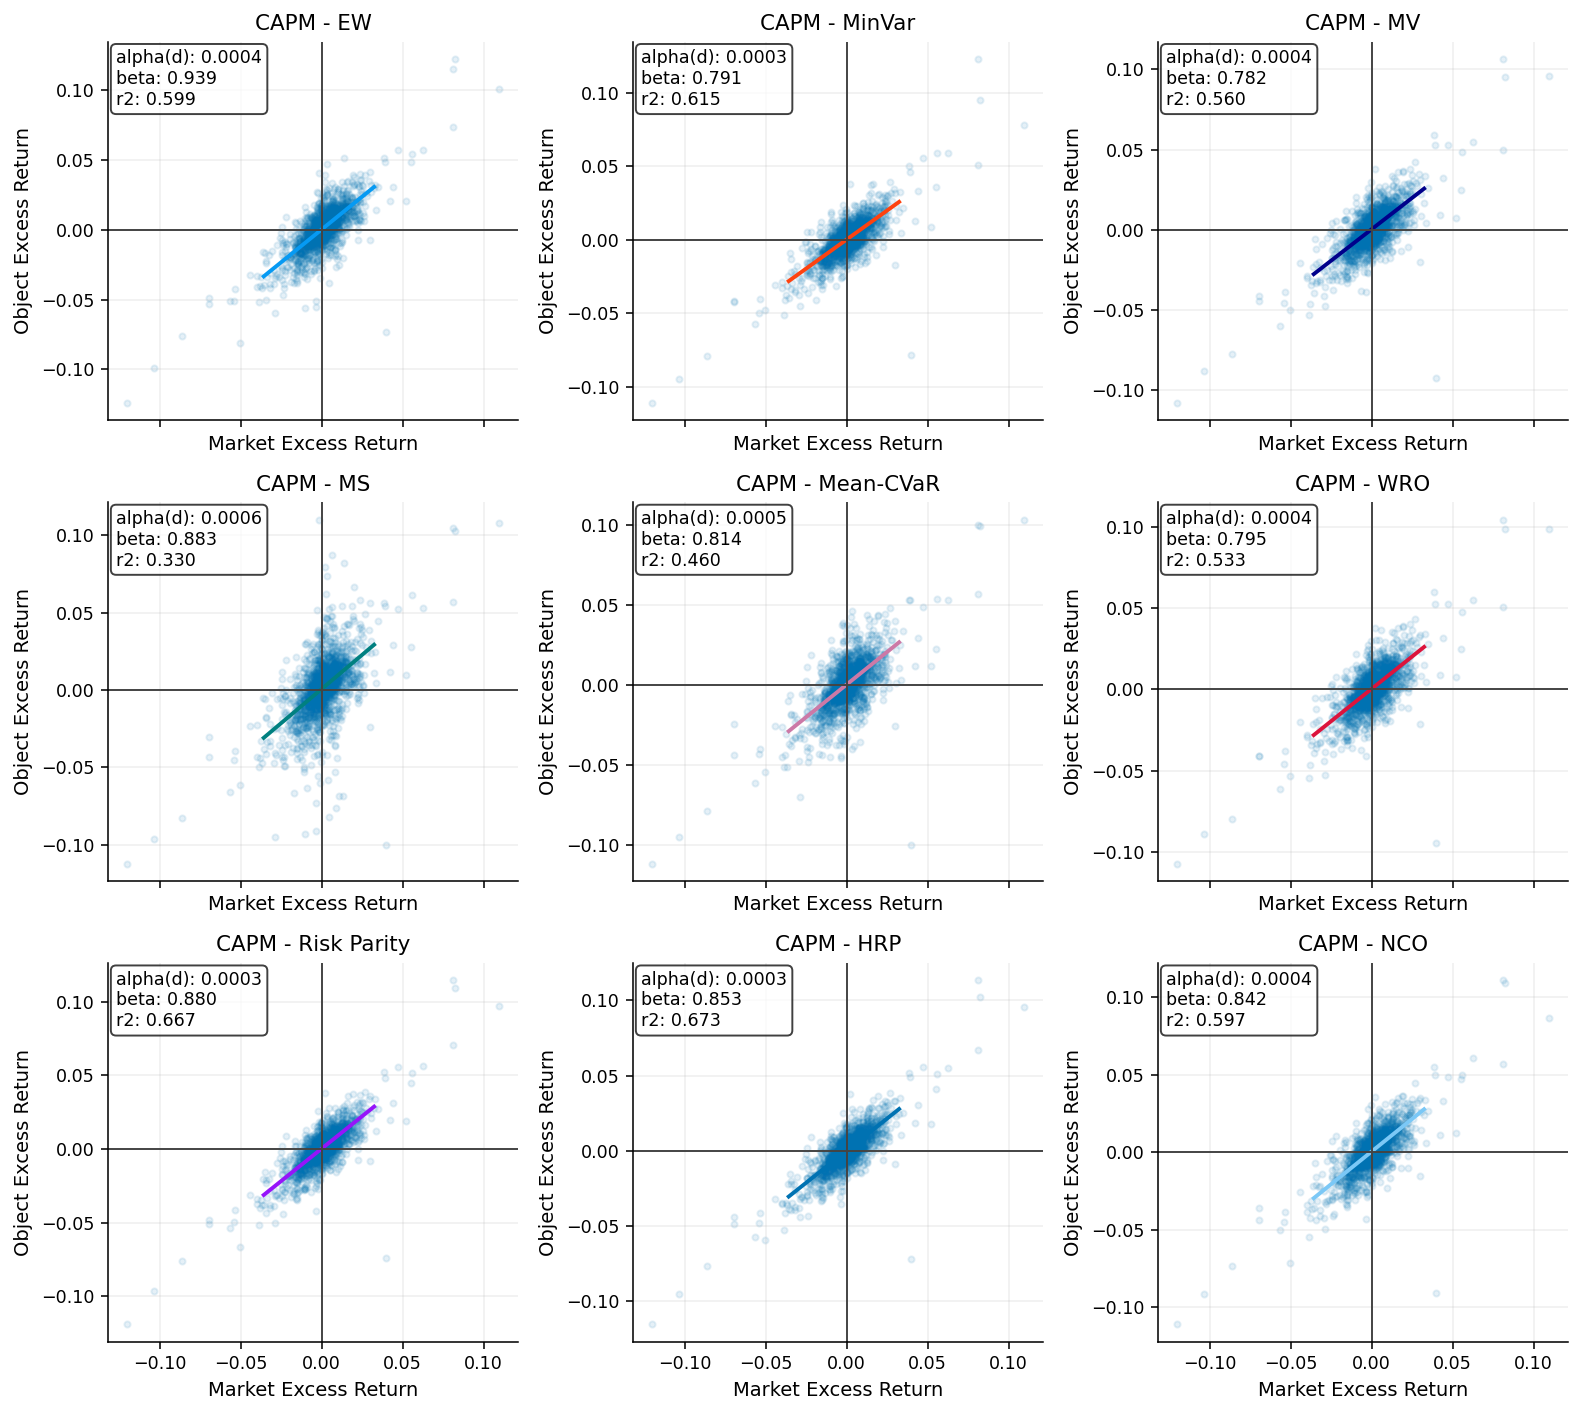

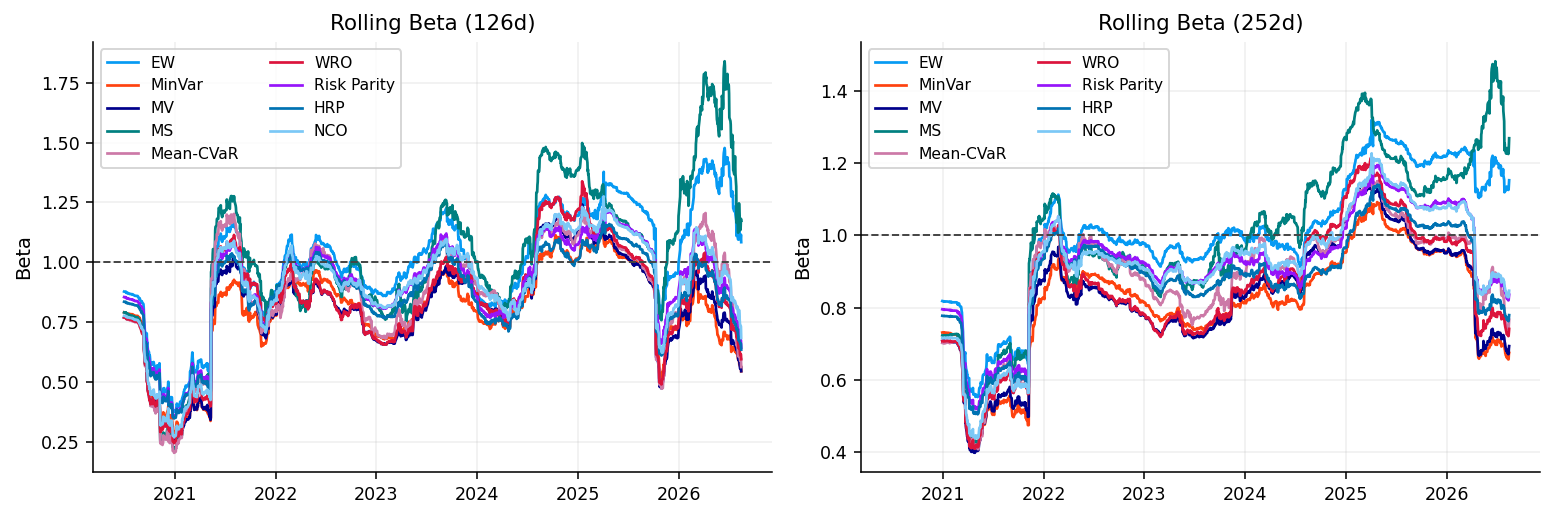

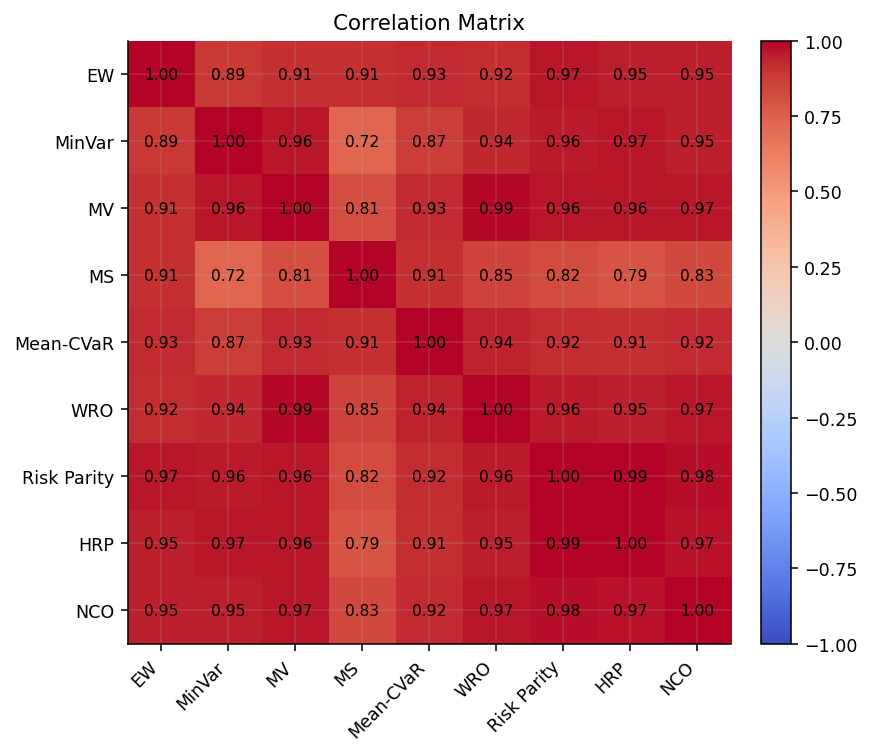

In [60]:
stress_windows = {
    "COVID crash": ("2020-02-20", "2020-04-30"),
    "2022 inflation shock": ("2022-01-03", "2022-10-31"),
    "2023 rebound": ("2023-01-03", "2023-12-29"),
}
available_stress_windows = {
    name: window for name, window in stress_windows.items()
    if strategy_returns.index.min() <= pd.Timestamp(window[1])
    and strategy_returns.index.max() >= pd.Timestamp(window[0])
}
full_market_return = full_ew.net_returns.reindex(strategy_returns.index)

layer3_risk_report = risk_report(
    objects={name: strategy_returns[name].dropna() for name in layer3_results},
    market_ret=full_market_return,
    rf_daily=rf_daily,
    include={
        "performance_tables": True,
        "shape_tables": False,
        "drawdowns": False,
        "rolling_vol": True,
        "drawdown_episodes": False,
        "var_es": True,
        "var_backtest": True,
        "stress": True,
        "capm": True,
        "rolling_beta": True,
        "correlation": True,
        "attribution": False,
        "exec_bullets": False,
    },
    var_settings={"alpha": 0.05, "methods": ["hist", "cf", "fhs"]},
    backtest_settings={
        "alpha": 0.05, "methods": ["hist", "cf", "fhs"],
        "lookback": 252, "plot_method": "best",
    },
    rolling_settings={
        "vol_windows": [20, 60, 252],
        "beta_windows": [126, 252],
    },
    stress_settings={
        "windows": available_stress_windows, "worst_only": False,
    },
    layout={"ncols": 3, "sharex": True, "sharey": False},
    output={
        "display_tables": True,
        "show_figures": True,
        "display_table_keys": [
            "performance", "var_es", "var_backtest", "stress", "capm", "corr",
        ],
        "print_exec_bullets": False,
        "short_labels": False,
        "round_tables": 4,
    },
)


,months,annual_alpha,alpha_hac_t,r_squared,Mkt-RF,SMB,HML,RMW,CMA,MOM
portfolio,,,,,,,,,,
EW,78,3.5%,0.78,76.6%,1.08,0.11,0.06,-0.02,0.15,0.36
MinVar,78,2.7%,0.68,64.8%,0.78,0.09,0.09,0.29,0.09,0.19
MV,78,4.0%,0.85,61.7%,0.84,0.08,0.00,0.21,0.17,0.28
MaxSharpe,78,8.0%,1.14,59.6%,1.21,0.22,0.05,-0.29,0.27,0.73
Mean-CVaR,78,4.6%,0.82,66.1%,1.06,0.04,0.09,-0.07,0.31,0.44
WRO,78,4.6%,0.92,62.9%,0.89,0.11,0.00,0.14,0.17,0.34
Risk Parity,78,2.7%,0.66,75.0%,0.94,0.10,0.05,0.21,0.13,0.24
HRP,78,1.7%,0.43,71.9%,0.89,0.05,0.06,0.24,0.16,0.21
NCO,78,3.7%,0.82,70.8%,0.92,0.14,0.02,0.26,0.10,0.29


,alpha_hac_t,Mkt-RF_hac_t,SMB_hac_t,HML_hac_t,RMW_hac_t,CMA_hac_t,MOM_hac_t
portfolio,,,,,,,
EW,0.78,17.88,0.68,0.39,-0.12,0.92,2.82
MinVar,0.68,10.99,0.63,0.65,2.76,0.65,1.78
MV,0.85,10.45,0.48,0.02,1.52,0.99,2.18
MaxSharpe,1.14,9.84,0.88,0.20,-0.82,0.96,3.74
Mean-CVaR,0.82,10.89,0.18,0.39,-0.34,1.26,3.99
WRO,0.92,11.19,0.67,0.02,0.99,0.86,2.58
Risk Parity,0.66,14.44,0.72,0.33,1.66,0.87,2.18
HRP,0.43,13.20,0.38,0.44,1.96,1.12,1.91
NCO,0.82,11.41,0.90,0.14,1.92,0.56,2.33


,alpha,Mkt-RF,SMB,HML,RMW,CMA,MOM,fitted_excess_return,realized_excess_return
portfolio,,,,,,,,,
EW,3.5%,14.2%,-0.2%,0.1%,-0.0%,0.1%,2.0%,19.7%,19.7%
MinVar,2.7%,10.2%,-0.1%,0.2%,0.5%,0.0%,1.1%,14.5%,14.5%
MV,4.0%,11.1%,-0.1%,0.0%,0.3%,0.1%,1.6%,16.9%,16.9%
MaxSharpe,8.0%,15.9%,-0.3%,0.1%,-0.5%,0.1%,4.1%,27.4%,27.4%
Mean-CVaR,4.6%,13.9%,-0.1%,0.2%,-0.1%,0.1%,2.4%,21.1%,21.1%
WRO,4.6%,11.7%,-0.2%,0.0%,0.2%,0.1%,1.9%,18.3%,18.3%
Risk Parity,2.7%,12.4%,-0.2%,0.1%,0.4%,0.1%,1.4%,16.7%,16.7%
HRP,1.7%,11.7%,-0.1%,0.1%,0.4%,0.1%,1.2%,15.1%,15.1%
NCO,3.7%,12.1%,-0.2%,0.1%,0.4%,0.0%,1.6%,17.7%,17.7%


,annualized_premium,annualized_hac_se,hac_t,ci_95_low,ci_95_high,positive_months,months,average_cross_section,average_industry_controls
characteristic,,,,,,,,,
size,1.7%,1.2%,1.46,-0.6%,4.0%,57.7%,78,363,17.1
momentum,2.1%,1.5%,1.46,-0.7%,5.0%,52.6%,78,363,17.1
value,-0.2%,1.7%,-0.10,-3.5%,3.2%,52.6%,78,363,17.1
beta,4.0%,3.1%,1.30,-2.0%,10.1%,50.0%,78,363,17.1
volatility,1.4%,2.3%,0.62,-3.2%,6.0%,48.7%,78,363,17.1


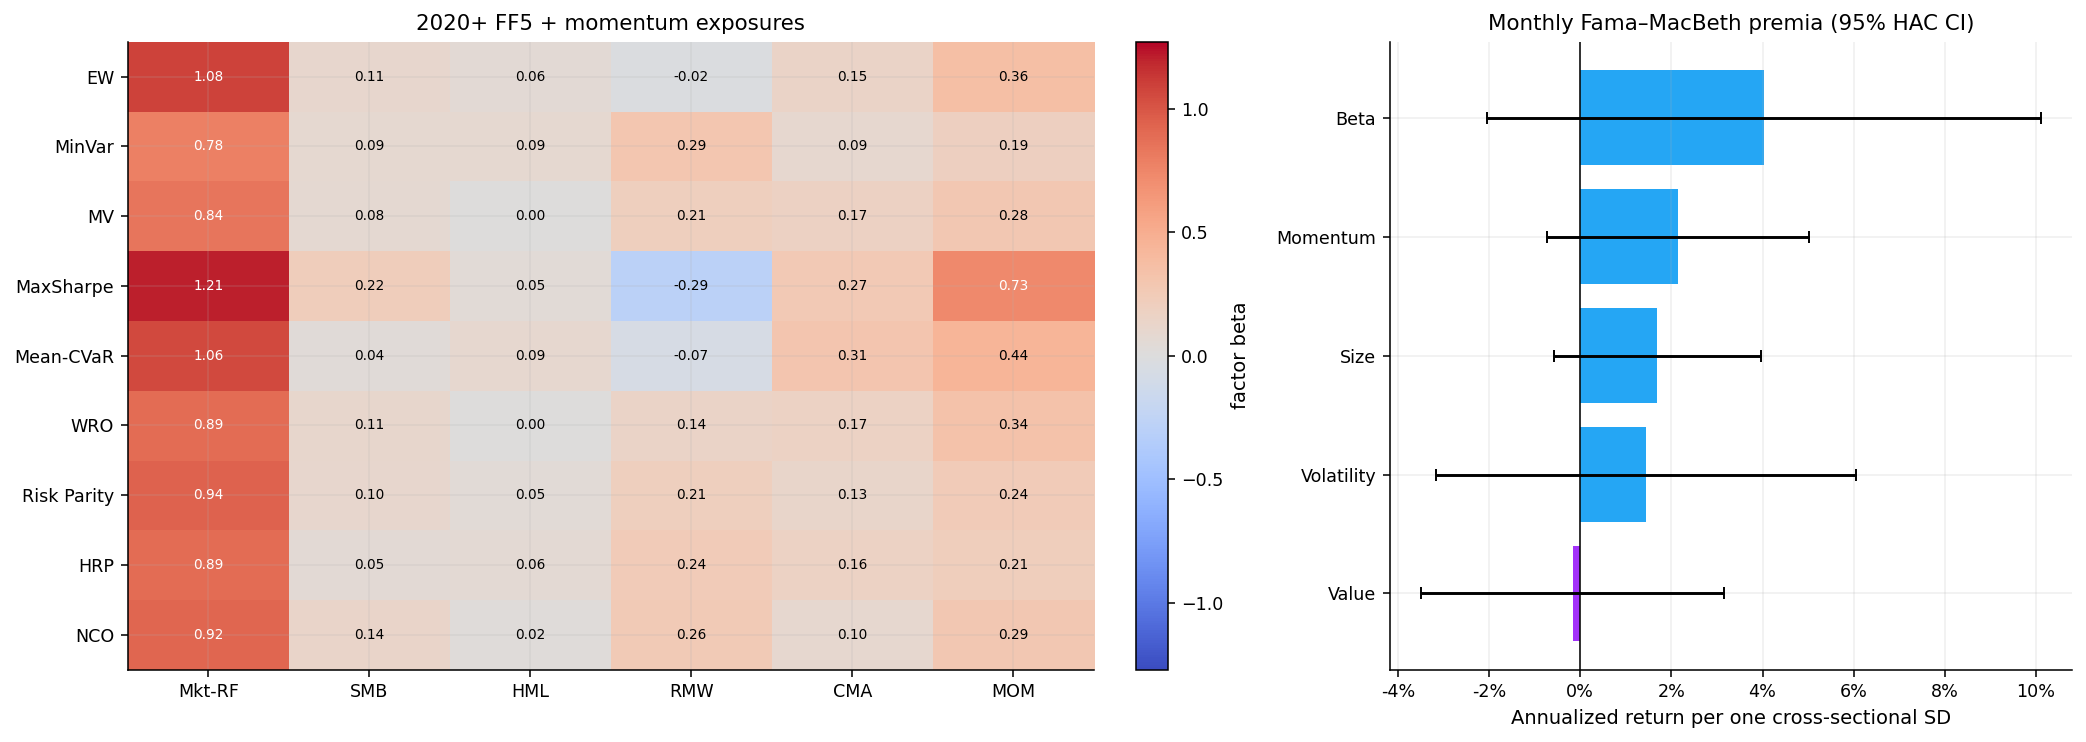

In [ ]:
factor_columns = ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "MOM"]
characteristic_columns = ["size", "momentum", "value", "beta", "volatility"]
hac_lags = 3


def normalized_factor_file(path, columns):
    frame = pd.read_csv(path, parse_dates=["date"]).set_index("date").sort_index()
    frame.columns = [str(column).strip() for column in frame.columns]
    return frame[columns].apply(pd.to_numeric, errors="coerce")


ff5 = normalized_factor_file(
    repo_root / "data" / "fama_french_us_5_factors.csv",
    ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "RF"],
)
momentum_factor_path = repo_root / "data" / "fama_french_us_momentum.csv"
if not momentum_factor_path.exists():
    raise FileNotFoundError(
        "Run `python data/fama_french_us/download.py` to build the U.S. momentum factor."
    )
momentum_factor = normalized_factor_file(momentum_factor_path, ["MOM"])
academic_factors = ff5.join(momentum_factor, how="inner")

monthly_portfolio_returns = (1.0 + strategy_returns).resample("ME").prod().sub(1.0)
factor_sample = monthly_portfolio_returns.join(academic_factors, how="inner").dropna(
    subset=[*factor_columns, "RF"]
)
portfolio_excess = excess_returns(
    factor_sample[monthly_portfolio_returns.columns],
    factor_sample["RF"],
)
annual_factor_premia = factor_sample[factor_columns].mean() * 12.0

exposure_rows = []
attribution_rows = []
inference_rows = []
for portfolio_name in monthly_portfolio_returns:
    sample = factor_sample[[portfolio_name, *factor_columns, "RF"]].dropna()
    design = sm.add_constant(sample[factor_columns], has_constant="add")
    fitted = sm.OLS(portfolio_excess.loc[sample.index, portfolio_name], design).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": hac_lags},
    )
    betas = fitted.params.reindex(factor_columns)
    contributions = betas * annual_factor_premia
    exposure_rows.append({
        "portfolio": portfolio_name,
        "months": len(sample),
        "annual_alpha": fitted.params["const"] * 12.0,
        "alpha_hac_t": fitted.tvalues["const"],
        "r_squared": fitted.rsquared,
        **{factor: betas[factor] for factor in factor_columns},
    })
    inference_rows.append({
        "portfolio": portfolio_name,
        "alpha_hac_t": fitted.tvalues["const"],
        **{f"{factor}_hac_t": fitted.tvalues[factor] for factor in factor_columns},
    })
    attribution_rows.append({
        "portfolio": portfolio_name,
        "alpha": fitted.params["const"] * 12.0,
        **{factor: contributions[factor] for factor in factor_columns},
        "fitted_excess_return": fitted.params["const"] * 12.0 + contributions.sum(),
        "realized_excess_return": (sample[portfolio_name] - sample["RF"]).mean() * 12.0,
    })

factor_exposures = pd.DataFrame(exposure_rows).set_index("portfolio")
factor_inference = pd.DataFrame(inference_rows).set_index("portfolio")
factor_attribution = pd.DataFrame(attribution_rows).set_index("portfolio")


def point_in_time_market_return(return_panel, issuers, mapping):
    market_return = pd.Series(np.nan, index=return_panel.index, name="eligible_market_return")
    issuer_map = {
        pd.Timestamp(date): group["ticker"].drop_duplicates().tolist()
        for date, group in issuers.groupby("decision_date", sort=True)
    }
    ordered_mapping = mapping.sort_values("decision_date").reset_index(drop=True)
    for position, row in ordered_mapping.iterrows():
        start = pd.Timestamp(row["execution_date"])
        stop = (
            pd.Timestamp(ordered_mapping.loc[position + 1, "execution_date"])
            if position + 1 < len(ordered_mapping)
            else return_panel.index.max() + pd.Timedelta(days=1)
        )
        tickers = return_panel.columns.intersection(
            issuer_map.get(pd.Timestamp(row["decision_date"]), [])
        )
        dates = return_panel.index[
            (return_panel.index >= start) & (return_panel.index < stop)
        ]
        if len(dates) and len(tickers):
            market_return.loc[dates] = return_panel.loc[dates, tickers].mean(axis=1)
    return market_return


eligible_market_return = point_in_time_market_return(returns, monthly_universe, date_map)
market_variance = eligible_market_return.rolling(252, min_periods=189).var()
beta_daily = returns.rolling(252, min_periods=189).cov(eligible_market_return).divide(
    market_variance, axis=0)
volatility_daily = returns.rolling(126, min_periods=84).std() * np.sqrt(252.0)

factor_decision_dates = pd.DatetimeIndex(date_map["decision_date"])
factor_execution_dates = pd.DatetimeIndex(date_map["execution_date"])
decision_prices = adj_close_filled.reindex(factor_decision_dates)
momentum_12_1 = decision_prices.shift(1).divide(decision_prices.shift(12)).sub(1.0)
execution_prices = adj_close_filled.reindex(factor_execution_dates)
execution_prices.index = factor_decision_dates
forward_returns = execution_prices.shift(-1).divide(execution_prices).sub(1.0)
decision_beta = beta_daily.reindex(factor_decision_dates)
decision_beta.index = factor_decision_dates
decision_volatility = volatility_daily.reindex(factor_decision_dates)
decision_volatility.index = factor_decision_dates

stock_factor_panel = pd.concat({
    "forward_return": forward_returns.stack(),
    "momentum": momentum_12_1.stack(),
    "beta": decision_beta.stack(),
    "volatility": decision_volatility.stack(),
}, axis=1)
stock_factor_panel.index.names = ["decision_date", "ticker"]
factor_metrics = fundamental_metrics[[
    "decision_date", "ticker", "industry", "market_cap", "book_to_market",
]].copy()
fama_macbeth_data = factor_metrics.join(
    stock_factor_panel, on=["decision_date", "ticker"])
fama_macbeth_data["size"] = np.log(
    fama_macbeth_data["market_cap"].where(fama_macbeth_data["market_cap"].gt(0.0)))
fama_macbeth_data["value"] = np.log(
    fama_macbeth_data["book_to_market"].where(
        fama_macbeth_data["book_to_market"].gt(0.0)))

monthly_slope_rows = []
monthly_diagnostic_rows = []
for decision_date, month in fama_macbeth_data[
    fama_macbeth_data["decision_date"].ge(holdout_start)].groupby("decision_date", sort=True):
    cross_section = month[[
        "forward_return", "industry", *characteristic_columns]].dropna()
    if len(cross_section) < 120:
        continue
    for column in ["forward_return", *characteristic_columns]:
        lower, upper = cross_section[column].quantile([0.01, 0.99])
        cross_section[column] = cross_section[column].clip(lower, upper)
    standardized = cross_section[characteristic_columns]
    standardized = standardized.subtract(standardized.mean()).divide(
        standardized.std(ddof=0).replace(0.0, np.nan))
    industry_counts = cross_section["industry"].value_counts()
    industry_group = cross_section["industry"].where(
        cross_section["industry"].map(industry_counts).ge(5),
        "Other")
    industry_dummies = pd.get_dummies(industry_group, prefix="industry", drop_first=True, dtype=float)
    regression = pd.concat([
        cross_section[["forward_return"]],
        standardized,
        industry_dummies,
    ], axis=1).dropna()
    design = sm.add_constant(
        regression[[*characteristic_columns, *industry_dummies.columns]],
        has_constant="add",
    )
    if len(regression) <= design.shape[1] + 20:
        continue
    coefficients = np.linalg.lstsq(
        design.to_numpy(dtype=float),
        regression["forward_return"].to_numpy(dtype=float),
        rcond=None,
    )[0]
    monthly_slope_rows.append(
        pd.Series(coefficients, index=design.columns, name=decision_date)
    )
    monthly_diagnostic_rows.append({
        "decision_date": decision_date,
        "cross_section": len(regression),
        "industry_controls": len(industry_dummies.columns),
        "design_rank": np.linalg.matrix_rank(design.to_numpy(dtype=float)),
        "design_columns": design.shape[1],
    })

monthly_fama_macbeth = pd.DataFrame(monthly_slope_rows).sort_index()
fama_macbeth_diagnostics = (
    pd.DataFrame(monthly_diagnostic_rows)
    .set_index("decision_date")
    .sort_index()
)
fama_macbeth_rows = []
for characteristic in characteristic_columns:
    monthly_slopes = monthly_fama_macbeth[characteristic].dropna()
    fitted_mean = sm.OLS(
        monthly_slopes.to_numpy(),
        np.ones((len(monthly_slopes), 1)),
    ).fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})
    fama_macbeth_rows.append({
        "characteristic": characteristic,
        "annualized_premium": fitted_mean.params[0] * 12.0,
        "annualized_hac_se": fitted_mean.bse[0] * 12.0,
        "hac_t": fitted_mean.tvalues[0],
        "ci_95_low": (fitted_mean.params[0] - 1.96 * fitted_mean.bse[0]) * 12.0,
        "ci_95_high": (fitted_mean.params[0] + 1.96 * fitted_mean.bse[0]) * 12.0,
        "positive_months": monthly_slopes.gt(0.0).mean(),
        "months": len(monthly_slopes),
        "average_cross_section": fama_macbeth_diagnostics["cross_section"].mean(),
        "average_industry_controls": fama_macbeth_diagnostics["industry_controls"].mean(),
    })
fama_macbeth_summary = pd.DataFrame(fama_macbeth_rows).set_index("characteristic")

assert (fama_macbeth_diagnostics["design_rank"] == fama_macbeth_diagnostics["design_columns"]).all()
assert fama_macbeth_summary["months"].min() >= 60

display(
    factor_exposures.style
    .format({
        "months": "{:,.0f}",
        "annual_alpha": "{:.1%}",
        "alpha_hac_t": "{:.2f}",
        "r_squared": "{:.1%}",
        **{factor: "{:.2f}" for factor in factor_columns},
    })
    .set_caption("2020+ FF5 + momentum exposures and HAC alpha inference")
)
display(
    factor_inference.style
    .format("{:.2f}")
    .set_caption("Newey–West HAC t-statistics for factor coefficients")
)
display(
    factor_attribution.style
    .format("{:.1%}")
    .set_caption("Annualized fitted excess-return attribution over the same sample")
)
display(
    fama_macbeth_summary.style
    .format({
        "annualized_premium": "{:.1%}",
        "annualized_hac_se": "{:.1%}",
        "hac_t": "{:.2f}",
        "ci_95_low": "{:.1%}",
        "ci_95_high": "{:.1%}",
        "positive_months": "{:.1%}",
        "months": "{:,.0f}",
        "average_cross_section": "{:,.0f}",
        "average_industry_controls": "{:.1f}",
    })
    .set_caption("Monthly stock-level Fama–MacBeth premia with industry controls")
)

fig, axes = plt.subplots(
    1, 2, figsize=(15, 5.4), gridspec_kw={"width_ratios": [1.55, 1.0]}
)
beta_view = factor_exposures[factor_columns]
beta_limit = max(1.1, np.nanmax(np.abs(beta_view.to_numpy())) * 1.05)
image = axes[0].imshow(
    beta_view,
    cmap="coolwarm",
    aspect="auto",
    vmin=-beta_limit,
    vmax=beta_limit,
)
axes[0].set_xticks(range(len(factor_columns)), factor_columns)
axes[0].set_yticks(range(len(beta_view)), beta_view.index)
axes[0].set_title("2020+ FF5 + momentum exposures")
for row in range(len(beta_view)):
    for column in range(len(factor_columns)):
        value = beta_view.iloc[row, column]
        color = "white" if abs(value) > 0.55 * beta_limit else "black"
        axes[0].text(
            column, row, f"{value:.2f}",
            ha="center", va="center", color=color, fontsize=7,
        )
fig.colorbar(image, ax=axes[0], fraction=0.046, pad=0.04, label="factor beta")

premium_view = fama_macbeth_summary["annualized_premium"].sort_values()
premium_error = 1.96 * fama_macbeth_summary.loc[
    premium_view.index, "annualized_hac_se"
]
bar_colors = np.where(premium_view.ge(0.0), blue, coral)
axes[1].barh(
    premium_view.index.str.title(),
    premium_view,
    xerr=premium_error,
    color=bar_colors,
    alpha=0.88,
    capsize=3,
)
axes[1].axvline(0.0, color="black", linewidth=0.8)
axes[1].set_title("Monthly Fama–MacBeth premia (95% HAC CI)")
axes[1].set_xlabel("Annualized return per one cross-sectional SD")
axes[1].xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
plt.tight_layout()
plt.show()


{'captured Mean-CVaR solver warnings': 34}


,section,value
metric,,
gross_margin,profitability,0.4291
operating_margin,profitability,NaN
net_margin,profitability,0.0670
fcf_margin,profitability,0.0471
gross_profitability_assets,profitability,0.5276
roa,profitability,0.0824
roe,profitability,0.2147
roic_proxy,profitability,NaN
cfo_assets,cash_quality,0.0760


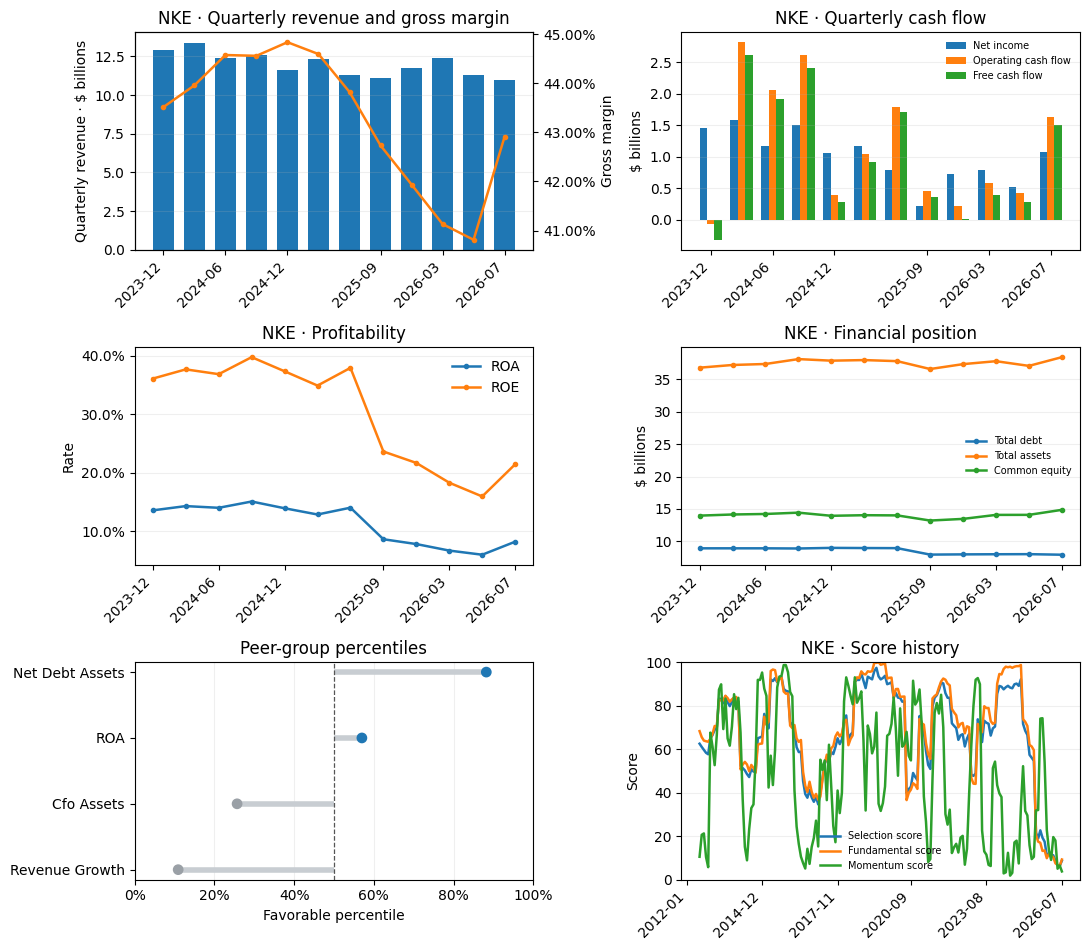

NKE fundamental report as of 2026-07-31.
selection score: 8.68.
Active reported warnings: 1.


,section,value
metric,,
fin_roa,profitability,0.0371
fin_roe,profitability,0.3353
fin_pretax_assets,profitability,0.0478
fin_net_margin,profitability,0.2656
fin_positive_earnings_frequency,profitability,1.0000
fin_net_income_variability,cash_quality,0.1233
fin_roa_variability,cash_quality,0.0646
fin_roe_variability,cash_quality,0.0607
positive_earnings_frequency,cash_quality,1.0000


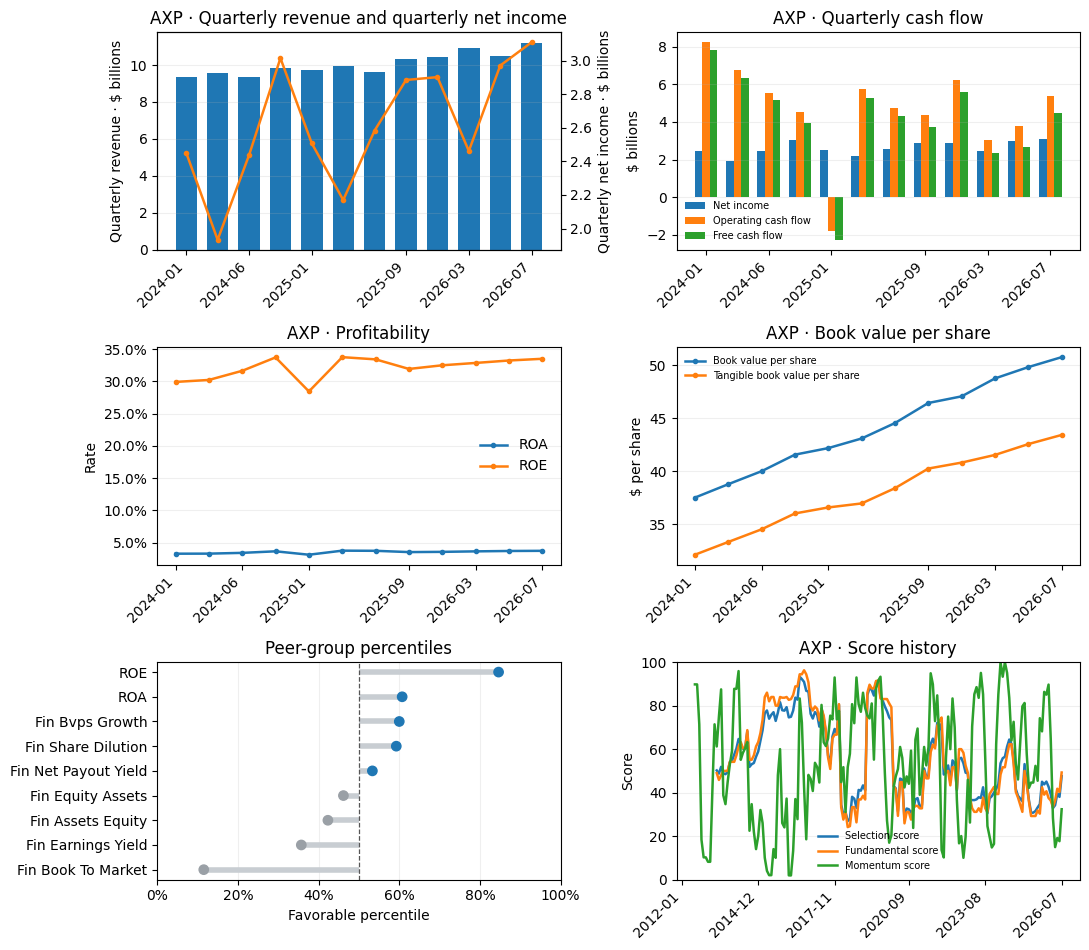

AXP fundamental report as of 2026-07-31.
selection score: 47.56.
Active reported warnings: 0.


In [ ]:
from dataclasses import replace
from pathlib import Path as path_cls

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.ticker import PercentFormatter as percent_formatter

from quantfinlab.backtest.portfolio import run_many_weights_backtests
from quantfinlab.dataio import (
    load_par_yield_curve,
    read_equity_history,
    read_sec_facts,
    read_sec_metadata,
    risk_free_returns,
)
from quantfinlab.fundamentals import (
    diagnostic_model_metrics,
    financial_company_metrics,
    classify_duration_facts,
    issuer_universe,
    monthly_statement_values,
    periodic_forms,
    profitability_growth_metrics,
    reconstruct_quarters,
    scoring as score_math,
    select_filing_facts,
    statement_concepts,
    statement_metrics,
    statement_reconstruction_checks,
    strength_efficiency_metrics,
)
from quantfinlab.plotting import fundamentals as fundamental_plots, portfolio as portfolio_plots
from quantfinlab.portfolio import (
    covariance, expected_returns, factors as factor_math, optimizers, selection,
)
from quantfinlab.portfolio.cvar import mean_cvar_weight_frame
from quantfinlab.portfolio.hrp import hrp_weight_frame, nco_mv_weight_frame
from quantfinlab.portfolio.risk_parity import risk_parity_weight_frame
from quantfinlab.portfolio.robust import wasserstein_weight_frame
from quantfinlab.portfolio.walkforward import (
    run_equal_weight_walkforward, run_walkforward_grid,
)
from quantfinlab.reports import fundamental_report, risk_report

repo_root = path_cls.cwd()
if not (repo_root / "data" / "sp500_market_data.parquet").exists():
    repo_root = repo_root.parent

market_path = repo_root / "data" / "sp500_market_data.parquet"
fundamentals_path = repo_root / "data" / "sp500_fundamentals.parquet"
treasury_path = repo_root / "data" / "us_treasury_yields.csv"
statement_cache = (
    repo_root / "data" / "datasets" / "project21" / "monthly_filing_financials_v2.parquet"
)

warmup_start = pd.Timestamp("2012-01-01")
backtest_start = pd.Timestamp("2013-01-01")
holdout_start = pd.Timestamp("2020-01-01")
top_n_values = (15, 50, 100)
lookback = 189
minimum_observations = 177
maximum_weight = 0.15
mean_variance_lambda = 10.0
trading_cost_bps = 10.0
turnover_penalty_bps = 10.0
annualization = 252.0

equity_data = read_equity_history(
    market_path,
    start=warmup_start,
    columns=[
        "date", "ticker", "adj_close", "is_sp500_member",
        "industry", "market_cap",
    ],
    drop_partial_last_date=True,
    validate=True,
)
market_data = equity_data["market"]
adj_close = equity_data["adj_close"]
adj_close_filled = equity_data["adj_close_filled"]
volume = equity_data["volume"]
returns = equity_data["returns"]
date_map = equity_data["date_map"]
sec_data = read_sec_metadata(
    fundamentals_path,
    include_concepts=False,
    include_mappings=True,
    validate=True,
)
monthly_issuers = issuer_universe(
    market_data,
    sec_data["mappings"],
    date_map,
    exclude_reits=True,
)
required_concepts = sorted(
    {
        concept
        for statement_group in statement_concepts.values()
        for candidates in statement_group.values()
        for concept in candidates
    }
)
sec_facts = read_sec_facts(
    fundamentals_path,
    concepts=required_concepts,
    ciks=monthly_issuers["cik"].unique(),
    forms=periodic_forms,
    period_start=warmup_start,
    validate=True,
)
classified_facts = classify_duration_facts(sec_facts)
latest_facts = select_filing_facts(classified_facts)
_, quarter_candidates = reconstruct_quarters(latest_facts)
monthly_statements = monthly_statement_values(
    classified_facts,
    monthly_issuers,
    cache=statement_cache,
    force=False,
)
statement_checks = statement_reconstruction_checks(
    quarter_candidates,
    monthly_statements,
)
fundamental_metrics = (
    monthly_issuers.merge(
        monthly_statements,
        on=["decision_date", "cik"],
        how="left",
        validate="one_to_one",
    )
    .pipe(statement_metrics)
    .pipe(profitability_growth_metrics)
    .pipe(strength_efficiency_metrics)
    .pipe(financial_company_metrics)
    .pipe(diagnostic_model_metrics)
)
financial_rows = fundamental_metrics["score_family"].eq("financial")
corporate_rows = fundamental_metrics["score_family"].eq("corporate")
score_configs = {
    "corporate": score_math.corporate_score,
    "financial": score_math.financial_score,
}
score_metrics = sorted(
    {
        metric_name
        for score_config in score_configs.values()
        for block_metrics in score_config["blocks"].values()
        for metric_name in block_metrics
    }
)
lower_is_better = sorted(
    {
        metric_name
        for score_config in score_configs.values()
        for metric_name in score_config["lower_is_better"]
    }
)
metric_scores = score_math.metric_percentile_scores(
    fundamental_metrics,
    score_metrics,
    lower_is_better=lower_is_better,
    peer_weight=0.70,
    minimum_peers=10,
    winsor_limits=(0.01, 0.99),
)
fundamental_scores = pd.concat(
    [
        fundamental_metrics,
        metric_scores,
    ],
    axis=1,
)
corporate_block_scores = score_math.block_scores(
    fundamental_scores,
    score_math.corporate_score["blocks"],
    prefix="corporate",
).where(corporate_rows, axis=0)
financial_block_scores = score_math.block_scores(
    fundamental_scores,
    score_math.financial_score["blocks"],
    prefix="financial",
).where(financial_rows, axis=0)
fundamental_scores = pd.concat(
    [
        fundamental_scores,
        corporate_block_scores,
        financial_block_scores,
    ],
    axis=1,
)
corporate_base = score_math.family_composite_score(
    fundamental_scores,
    corporate_block_scores,
    score_math.corporate_score,
)
financial_base = score_math.family_composite_score(
    fundamental_scores,
    financial_block_scores,
    score_math.financial_score,
)
fundamental_scores = pd.concat(
    [
        fundamental_scores,
        corporate_base,
        financial_base,
    ],
    axis=1,
)
fundamental_scores["base_score"] = fundamental_scores["corporate_base_score"].combine_first(
    fundamental_scores["financial_base_score"]
)
fundamental_scores["piotroski_penalty"] = score_math.piotroski_penalty(
    fundamental_scores,
)
fundamental_scores["red_flag_penalty"] = score_math.red_flag_penalty(
    fundamental_scores,
)
total_penalty = fundamental_scores["piotroski_penalty"] + fundamental_scores["red_flag_penalty"]
fixed_uncapped = fundamental_scores["base_score"] - total_penalty
family_keys = [
    fundamental_scores["decision_date"],
    fundamental_scores["score_family"],
]
fundamental_scores["fixed_score"] = fixed_uncapped.groupby(family_keys).rank(pct=True) * 100.0

price_signals = score_math.price_signal_frame(
    adj_close_filled,
    decision_dates=date_map["decision_date"],
    horizons=(1, 3, 6, 12),
    momentum_horizons=(3, 6, 12),
    skip_recent_months=1,
)
fundamental_scores = fundamental_scores.join(
    price_signals,
    on=["decision_date", "ticker"],
)
score_weights = {}
adaptive_parts = []
for company_type, score_config in score_configs.items():
    block_columns = [
        f"{company_type}_{block_name}_score" for block_name in score_config["block_weights"]
    ]
    weight_history = score_math.walkforward_block_weights(
        fundamental_scores,
        block_columns,
        score_config["block_weights"],
        family=company_type,
        horizons=(3, 6, 12),
        horizon_weights=(0.25, 0.50, 0.25),
        window=36,
        minimum_periods=12,
        adaptive_share=0.75,
        weight_cap=0.35,
    )
    score_weights[company_type] = weight_history
    adaptive_parts.append(
        score_math.adaptive_family_score(
            fundamental_scores,
            fundamental_scores,
            weight_history,
            score_config,
            penalties=total_penalty,
        )
    )

adaptive_values = pd.concat(adaptive_parts)
adaptive_values = adaptive_values.groupby(level=0).first().reindex(fundamental_scores.index)
fundamental_scores["adaptive_base_score"] = adaptive_values["adaptive_base_score"]
fundamental_scores["uncapped_score"] = adaptive_values["uncapped_score"]
fundamental_scores["final_score"] = adaptive_values["final_score"]
selection_values = score_math.definitive_selection_score(
    fundamental_scores,
    fundamental_column="final_score",
    momentum_column="momentum_6_1",
    momentum_weight=0.10,
)
fundamental_scores = pd.concat(
    [
        fundamental_scores,
        selection_values,
    ],
    axis=1,
)
fundamental_scores["score_rank"] = fundamental_scores.groupby("decision_date")[
    "selection_score"
].rank(ascending=False, method="first")
fundamental_scores["profitability_score"] = fundamental_scores[
    "corporate_profitability_score"
].combine_first(fundamental_scores["financial_profitability_score"])
fundamental_scores["efficiency_score"] = fundamental_scores[
    "corporate_efficiency_score"
].combine_first(fundamental_scores["financial_efficiency_score"])
fundamental_scores["valuation_score"] = fundamental_scores[
    "corporate_valuation_score"
].combine_first(fundamental_scores["financial_valuation_return_score"])
fundamental_scores["cash_or_stability_score"] = fundamental_scores[
    "corporate_cash_quality_score"
].combine_first(fundamental_scores["financial_stability_score"])

prediction_columns = [
    "selection_score",
    "final_score",
    "fixed_score",
    "profitability_score",
    "cash_or_stability_score",
    "efficiency_score",
    "valuation_score",
]
score_validation = score_math.rank_ic_table(
    fundamental_scores,
    score_columns=prediction_columns,
    horizons=(1, 3, 6, 12),
    top_fraction=0.20,
)
bucket_returns = score_math.bucket_return_table(
    fundamental_scores,
    score_column="selection_score",
    horizons=(1, 3, 6, 12),
    buckets=5,
)
stock_selections = score_math.select_stocks(
    fundamental_scores,
    top_n=top_n_values,
    score_column="selection_score",
    start=backtest_start,
)
universes = score_math.investment_universes(
    monthly_issuers,
    stock_selections,
    returns,
    date_map,
    top_n=top_n_values,
    lookback=lookback,
    minimum_observations=minimum_observations,
    minimum_assets=10,
    prices=adj_close_filled,
)
treasury_curve = load_par_yield_curve(
    treasury_path,
    source="us_treasury",
)
rf_daily = risk_free_returns(
    treasury_curve["3M"],
    returns.index,
).ffill().ffill().ffill().ffill()

selection_dates = pd.DatetimeIndex(
    sorted(set(stock_selections["decision_date"]) & set(date_map["decision_date"]))
)
selection_dates = selection_dates[selection_dates >= backtest_start]
execution_by_decision = date_map.set_index("decision_date")["execution_date"]
portfolio_dates = [
    pd.Timestamp(execution_by_decision.loc[decision_date]) for decision_date in selection_dates
]

equal_weight_settings = {
    "returns": returns,
    "rebalance_dates": portfolio_dates,
    "max_weight": maximum_weight,
    "min_weight": 0.0,
    "long_only": True,
    "trading_cost_bps": trading_cost_bps,
    "rf_daily": rf_daily,
}

latest_date = fundamental_scores["decision_date"].max()
latest_top15 = stock_selections[
    stock_selections["decision_date"].eq(latest_date) & stock_selections["top_n"].eq(15)
].sort_values("selection_rank")
latest_top15 = latest_top15[
    [
        "selection_rank",
        "ticker",
        "entity_name",
        "score_family",
        "industry",
        "market_cap",
        "final_score",
        "momentum_score",
        "selection_score",
    ]
].set_index("selection_rank")

def holdout_result(result, start):
    net_returns = pd.Series(result.net_returns, dtype=float).loc[start:].copy()
    gross_returns = pd.Series(result.gross_returns, dtype=float).loc[start:].copy()
    earlier_dates = result.net_values.index[result.net_values.index < start]
    baseline_date = pd.Timestamp(earlier_dates.max())
    net_values = pd.concat([
        pd.Series([1.0], index=[baseline_date]),
        (1.0 + net_returns).cumprod(),
    ])
    gross_values = pd.concat([
        pd.Series([1.0], index=[baseline_date]),
        (1.0 + gross_returns).cumprod(),
    ])
    return replace(
        result,
        net_returns=net_returns,
        gross_returns=gross_returns,
        net_values=net_values,
        gross_values=gross_values,
        weights=result.weights.loc[result.weights.index >= start],
        turnover=result.turnover.loc[result.turnover.index >= start],
        costs=result.costs.loc[result.costs.index >= start],
    )


full_ew = run_equal_weight_walkforward(
    universe_by_date=universes["full"],
    **equal_weight_settings,
)
top15_ew = run_equal_weight_walkforward(
    universe_by_date=universes["top15"],
    **equal_weight_settings,
)
layer1_results = {
    "Full EW": holdout_result(full_ew, holdout_start),
    "Top15 EW": holdout_result(top15_ew, holdout_start),
}
layer1_performance = selection.build_strategy_summary(
    layer1_results,
    rf_daily=rf_daily,
    annualization=annualization,
)

top50_ew = run_equal_weight_walkforward(
    universe_by_date=universes["top50"],
    **equal_weight_settings,
)
top100_ew = run_equal_weight_walkforward(
    universe_by_date=universes["top100"],
    **equal_weight_settings,
)
layer2_results = {
    "Top15 EW": holdout_result(top15_ew, holdout_start),
    "Top50 EW": holdout_result(top50_ew, holdout_start),
    "Top100 EW": holdout_result(top100_ew, holdout_start),
}
layer2_performance = selection.build_strategy_summary(
    layer2_results,
    rf_daily=rf_daily,
    annualization=annualization,
)

cov_models = {
    "Sample": covariance.sample_covariance,
    "LedoitWolf": covariance.ledoit_wolf_covariance,
    "OAS": covariance.oas_covariance,
    "EWMA": covariance.ewma_covariance,
}
mu_models = {
    "Momentum": expected_returns.momentum_mu,
    "BayesStein": expected_returns.bayes_stein_mu,
    "BayesSteinMomentum": expected_returns.bayes_stein_momentum_mu,
}
top15_optimizers = {
    "MinVar": optimizers.minimum_variance,
    "MV": optimizers.mean_variance,
    "MaxSharpe": optimizers.max_sharpe_slsqp,
}
fixed_core_specs = [
    {"name": "MinVar", "optimizer": "MinVar", "cov_model": "LedoitWolf"},
    {
        "name": "MV", "optimizer": "MV", "cov_model": "LedoitWolf",
        "mu_model": "BayesStein",
    },
    {
        "name": "MaxSharpe", "optimizer": "MaxSharpe", "cov_model": "Sample",
        "mu_model": "BayesStein",
    },
]
top15_grid = run_walkforward_grid(
    returns=returns,
    close=adj_close_filled,
    rebalance_dates=portfolio_dates,
    universe_by_date=universes["top15"],
    cov_lookback=lookback,
    mu_lookback=lookback,
    min_cov_observations=minimum_observations,
    min_mu_observations=minimum_observations,
    max_weight=maximum_weight,
    min_weight=0.0,
    long_only=True,
    trading_cost_bps=trading_cost_bps,
    turnover_penalty_bps=turnover_penalty_bps,
    optimizer_params={"MV": {"mv_lambda": mean_variance_lambda}},
    blend_by_optimizer={"MinVar": 0.0, "MV": 0.0, "MaxSharpe": 0.0},
    fallback="equal",
    rf_daily=rf_daily,
    annualization=annualization,
    momentum_mode="6-1",
    cov_models=cov_models,
    mu_models=mu_models,
    optimizers=top15_optimizers,
    strategy_specs=fixed_core_specs,
)
top15_core = {"EW": top15_ew, **top15_grid.backtests}

top15_dates = list(top15_grid.metadata["rebalance_dates"])
with warnings.catch_warnings(record=True) as library_cvar_warnings:
    warnings.simplefilter("always")
    mean_cvar_weights = mean_cvar_weight_frame(
        cache=top15_grid.cache,
        rebalance_dates=top15_dates,
        cov_model="EWMA",
        mu_model="BayesStein",
        reference="equal",
        alpha=0.95,
        budget_scale=0.75,
        w_min=0.0,
        w_max=maximum_weight,
    )
print({"captured Mean-CVaR solver warnings": len(library_cvar_warnings)})
wro_weights = wasserstein_weight_frame(
    cache=top15_grid.cache,
    rebalance_dates=top15_dates,
    cov_model="LedoitWolf",
    mu_model="BayesStein",
    radius=0.50,
    mv_lambda=6.0,
    radius_scale="avg_vol",
    worst_case_variance=True,
    w_min=0.0,
    w_max=maximum_weight,
)
risk_parity_weights = risk_parity_weight_frame(
    cache=top15_grid.cache,
    rebalance_dates=top15_dates,
    cov_model="Sample",
    w_min=0.0,
    w_max=maximum_weight,
)
hrp_weights = hrp_weight_frame(
    cache=top15_grid.cache,
    rebalance_dates=top15_dates,
    cov_model="Sample",
    linkage_method="complete",
    w_min=0.0,
    w_max=maximum_weight,
)
nco_weights = nco_mv_weight_frame(
    cache=top15_grid.cache,
    rebalance_dates=top15_dates,
    cov_model="LedoitWolf",
    mu_model="BayesSteinMomentum",
    n_clusters=4,
    inner_lambda=6.0,
    outer_lambda=6.0,
    cluster_cap=0.50,
    linkage_method="average",
    w_min=0.0,
    w_max=maximum_weight,
)
advanced_results = run_many_weights_backtests(
    {
        "Mean-CVaR": mean_cvar_weights,
        "WRO": wro_weights,
        "Risk Parity": risk_parity_weights,
        "HRP": hrp_weights,
        "NCO": nco_weights,
    },
    returns=returns,
    cost_bps=trading_cost_bps,
    rf_daily=rf_daily,
    w_min=0.0,
    w_max=maximum_weight,
    long_only=True,
    normalize=True,
    weight_timing="same_day",
)
top15_grid.cache.clear()
top15_grid.metadata.pop("_returns_source", None)
layer3_results_full = {**top15_core, **advanced_results}
layer3_results = {
    name: holdout_result(result, holdout_start)
    for name, result in layer3_results_full.items()
}
layer3_performance = selection.build_strategy_summary(
    layer3_results,
    rf_daily=rf_daily,
    annualization=annualization,
).sort_values(
    ["Sharpe", "Max Drawdown"],
    ascending=[False, False],
)
layer3_nav = pd.DataFrame(
    {strategy_name: result.net_values for strategy_name, result in layer3_results.items()}
).dropna(how="all")
layer3_plot = layer3_performance.assign(drawdown=layer3_performance["Max Drawdown"].abs())


fig, axes = plt.subplots(5, 2, figsize=(16, 20))
fundamental_plots.plot_statement_coverage(
    statement_checks["coverage"],
    ax=axes[0, 0],
)
fundamental_plots.plot_reconstruction_sources(
    statement_checks["ttm_sources"],
    ax=axes[0, 1],
)
fundamental_plots.plot_score_counts(
    fundamental_scores,
    ax=axes[1, 0],
)
fundamental_plots.plot_score_weights(
    score_weights,
    company_type="corporate",
    ax=axes[1, 1],
)
fundamental_plots.plot_score_weights(
    score_weights,
    company_type="financial",
    ax=axes[2, 0],
)
fundamental_plots.plot_rank_ic(
    score_validation,
    score="selection_score",
    ax=axes[2, 1],
)
fundamental_plots.plot_bucket_returns(
    bucket_returns,
    horizon=12,
    ax=axes[3, 0],
)
portfolio_plots.plot_strategy_nav(
    layer3_nav,
    ax=axes[3, 1],
    title="Costed growth of $1",
    summary=layer3_performance,
    apply_style=False,
)
portfolio_plots.plot_strategy_drawdowns(
    layer3_nav,
    ax=axes[4, 0],
    title="Portfolio drawdowns",
    summary=layer3_performance,
    apply_style=False,
)
portfolio_plots.plot_risk_return_scatter(
    layer3_plot,
    ax=axes[4, 1],
    title="Return, drawdown, and turnover",
    risk_col="drawdown",
    return_col="CAGR",
    color_col="Sharpe",
    size_col="Turnover",
    apply_style=False,
)
axes[4, 1].xaxis.set_major_formatter(percent_formatter(1.0))
axes[4, 1].yaxis.set_major_formatter(percent_formatter(1.0))
portfolio_plots.apply_portfolio_subplot_layout(
    fig,
    axes,
    hspace=0.45,
    wspace=0.28,
    bottom=0.04,
    top=0.98,
)
plt.close(fig)

report_include = {
    "snapshot": True,
    "statements": True,
    "profitability": True,
    "cash_quality": True,
    "growth": True,
    "financial_strength": True,
    "efficiency": True,
    "capital_allocation": True,
    "valuation": True,
    "dupont": True,
    "traditional_models": True,
    "warnings": True,
    "peer_comparison": True,
    "score": True,
    "score_history": True,
    "summary": True,
}
report_statement_settings = {
    "scale": "billions",
    "periods": 8,
    "show_common_size": True,
    "show_growth": True,
}
report_history_settings = {
    "periods": 12,
    "frequency": "quarterly",
    "rolling_periods": 4,
    "show_latest_value": True,
}
report_peer_settings = {
    "group": "industry",
    "minimum_peers": 10,
    "percentiles": (0.25, 0.50, 0.75),
    "market_cap_band": (0.25, 4.0),
}
report_score_settings = {
    "score": "selection_score",
    "fundamental_score": "final_score",
    "momentum_score": "momentum_score",
    "show_blocks": True,
    "show_rank": True,
    "show_weight_history": True,
}
report_warning_settings = {
    "active_only": True,
    "minimum_severity": 1,
    "show_history": True,
    "show_penalty": True,
}
report_layout = {
    "ncols": 2,
    "sharex": False,
    "sharey": False,
    "figure_width": 11.0,
    "panel_height": 3.2,
    "combine_figures": True,
}
report_output = {
    "round_tables": 4,
    "display_tables": True,
    "display_table_keys": ["fundamental_summary"],
    "show_figures": True,
    "display_figure_keys": ["overview"],
    "print_summary": True,
    "short_labels": False,
}

nke_report = fundamental_report(
    metrics=fundamental_metrics,
    scores=fundamental_scores,
    ticker="NKE",
    asof=latest_date,
    include=report_include,
    statement_settings=report_statement_settings,
    history_settings=report_history_settings,
    peer_settings=report_peer_settings,
    score_settings=report_score_settings,
    warning_settings=report_warning_settings,
    layout=report_layout,
    output=report_output,
)
axp_report = fundamental_report(
    metrics=fundamental_metrics,
    scores=fundamental_scores,
    ticker="AXP",
    asof=latest_date,
    include=report_include,
    statement_settings=report_statement_settings,
    history_settings=report_history_settings,
    peer_settings=report_peer_settings,
    score_settings=report_score_settings,
    warning_settings=report_warning_settings,
    layout=report_layout,
    output=report_output,
)

strategy_returns = pd.DataFrame(
    {strategy_name: result.net_returns for strategy_name, result in layer3_results.items()}
).dropna(how="all")
market_return = layer1_results["Full EW"].net_returns.reindex(strategy_returns.index)
stress_windows = {
    "2018 Q4": ("2018-10-01", "2018-12-31"),
    "COVID crash": ("2020-02-20", "2020-04-30"),
    "2022 inflation shock": ("2022-01-03", "2022-10-31"),
    "2023 rebound": ("2023-01-03", "2023-12-29"),
}
available_stress_windows = {
    stress_name: stress_dates
    for stress_name, stress_dates in stress_windows.items()
    if strategy_returns.index.min() <= pd.Timestamp(stress_dates[1])
    and strategy_returns.index.max() >= pd.Timestamp(stress_dates[0])
}
layer3_risk_report = risk_report(
    objects={
        strategy_name: strategy_returns[strategy_name].dropna() for strategy_name in layer3_results
    },
    market_ret=market_return,
    rf_daily=rf_daily,
    include={
        "performance_tables": True,
        "shape_tables": False,
        "drawdowns": False,
        "rolling_vol": True,
        "drawdown_episodes": False,
        "var_es": True,
        "var_backtest": True,
        "stress": True,
        "capm": True,
        "rolling_beta": True,
        "correlation": True,
        "attribution": False,
        "exec_bullets": False,
    },
    var_settings={
        "alpha": 0.05,
        "methods": ["hist", "cf", "fhs"],
    },
    backtest_settings={
        "alpha": 0.05,
        "methods": ["hist", "cf", "fhs"],
        "lookback": 252,
        "plot_method": "best",
    },
    rolling_settings={
        "vol_windows": [20, 60, 252],
        "beta_windows": [126, 252],
    },
    stress_settings={
        "windows": available_stress_windows,
        "worst_only": False,
    },
    layout={
        "ncols": 3,
        "sharex": True,
        "sharey": False,
    },
    output={
        "display_tables": False,
        "display_table_keys": [
            "var_es",
            "stress",
            "capm",
            "corr",
        ],
        "show_figures": False,
        "print_exec_bullets": False,
        "short_labels": False,
        "round_tables": 4,
    },
)
plt.close("all")

factor_columns = ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "MOM"]
characteristic_columns = ["size", "momentum", "value", "beta", "volatility"]
ff5 = (
    pd.read_csv(
        repo_root / "data" / "fama_french_us_5_factors.csv",
        parse_dates=["date"],
    )
    .set_index("date")
    .sort_index()
)
momentum = (
    pd.read_csv(
        repo_root / "data" / "fama_french_us_momentum.csv",
        parse_dates=["date"],
    )
    .set_index("date")
    .sort_index()
)
academic_factors = ff5.join(momentum, how="inner")
monthly_returns = (1.0 + strategy_returns).resample("ME").prod().sub(1.0)
factor_results = factor_math.factor_attribution(
    monthly_returns,
    academic_factors,
    factor_columns=factor_columns,
    hac_lags=3,
)

market_return = factor_math.point_in_time_market_return(
    returns,
    monthly_issuers,
    date_map,
)
market_variance = market_return.rolling(
    252,
    min_periods=189,
).var()
beta_daily = returns.rolling(252, min_periods=189).cov(
    market_return
).divide(market_variance, axis=0)
volatility_daily = returns.rolling(
    126,
    min_periods=84,
).std() * np.sqrt(252.0)

decision_dates = pd.DatetimeIndex(date_map["decision_date"])
execution_dates = pd.DatetimeIndex(date_map["execution_date"])
decision_prices = adj_close_filled.reindex(decision_dates)
momentum_12_1 = decision_prices.shift(1).divide(
    decision_prices.shift(12)
).sub(1.0)
execution_prices = adj_close_filled.reindex(execution_dates)
execution_prices.index = decision_dates
forward_returns = execution_prices.shift(-1).divide(
    execution_prices
).sub(1.0)
decision_beta = beta_daily.reindex(decision_dates)
decision_beta.index = decision_dates
decision_volatility = volatility_daily.reindex(decision_dates)
decision_volatility.index = decision_dates

stock_factor_panel = pd.concat({
    "forward_return": forward_returns.stack(),
    "momentum": momentum_12_1.stack(),
    "beta": decision_beta.stack(),
    "volatility": decision_volatility.stack(),
}, axis=1)
stock_factor_panel.index.names = ["decision_date", "ticker"]
fama_macbeth_data = fundamental_metrics[[
    "decision_date", "ticker", "industry", "market_cap", "book_to_market",
]].join(stock_factor_panel, on=["decision_date", "ticker"])

fama_macbeth_data["size"] = np.log(
    fama_macbeth_data["market_cap"].where(
        fama_macbeth_data["market_cap"].gt(0.0)
    )
)
fama_macbeth_data["value"] = np.log(
    fama_macbeth_data["book_to_market"].where(
        fama_macbeth_data["book_to_market"].gt(0.0)
    )
)
fama_macbeth = factor_math.fama_macbeth(
    fama_macbeth_data,
    date_column="decision_date",
    return_column="forward_return",
    characteristics=characteristic_columns,
    industry_column="industry",
    start=holdout_start,
    min_cross_section=120,
    min_industry_size=5,
    hac_lags=3,
)

display(
    factor_results.exposures.style
    .format({
        "months": "{:,.0f}", "annual_alpha": "{:.1%}",
        "alpha_hac_t": "{:.2f}", "r_squared": "{:.1%}",
        **{factor: "{:.2f}" for factor in factor_columns},
    })
    .set_caption("Library FF5 + momentum exposures and HAC alpha inference")
)
display(
    factor_results.inference.style
    .format("{:.2f}")
    .set_caption("Library Newey–West HAC coefficient t-statistics")
)
display(
    factor_results.attribution.style
    .format("{:.1%}")
    .set_caption("Library annualized factor attribution")
)
display(
    fama_macbeth.summary.style
    .format({
        "annualized_premium": "{:.1%}", "annualized_hac_se": "{:.1%}",
        "hac_t": "{:.2f}", "ci_95_low": "{:.1%}", "ci_95_high": "{:.1%}",
        "positive_months": "{:.1%}", "months": "{:,.0f}",
        "average_cross_section": "{:,.0f}",
        "average_industry_controls": "{:.1f}",
    })
    .set_caption("Library monthly Fama–MacBeth premia with industry controls")
)
